In [ ]:
betas = []

for date, group in panel.groupby("Date"):
    group = group.dropna()
    
    if len(group) > 10:
        X = group[["beta","mom12","vol","idio_vol"]]
        X = sm.add_constant(X)
        y = group["excess"]

        res = sm.OLS(y, X).fit()
        betas.append(res.params)

fm = pd.DataFrame(betas)

print("Coefficients:")
print(fm.mean())

print("\nT-stats:")
print(fm.mean() / (fm.std() / np.sqrt(len(fm))))

In [ ]:
panel.rename(columns={'level_1':'ticker'}, inplace=True)

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Load data
reit = pd.read_csv("A_REIT_2016_2025_monthly_total_returns_survivorship_free.csv")
rfr = pd.read_csv("rfr_au_monthly.csv")

# Date formatting
reit["Date"] = pd.to_datetime(reit["Date"])
rfr["Date"] = pd.to_datetime(rfr["Date"])

reit.set_index("Date", inplace=True)
rfr.set_index("Date", inplace=True)

# Align
rfr = rfr.loc[reit.index]

# Monthly RF
rfr["rf_m"] = (1 + rfr["RFR_AU"])**(1/12) - 1

# Excess returns
excess = reit.sub(rfr["rf_m"], axis=0)

# Market proxy
market = reit.mean(axis=1)

# Momentum
mom12 = (1 + reit).rolling(12).apply(np.prod) - 1

# Volatility
vol = reit.rolling(12).std()

# Drawdown
cum = (1 + reit).cumprod()
peak = cum.cummax()
drawdown = cum / peak - 1

# Rolling beta
window = 36
beta = reit.apply(lambda x: x.rolling(window).cov(market) / market.rolling(window).var())

# Idiosyncratic volatility
idio_vol = pd.DataFrame(index=reit.index, columns=reit.columns)

for col in reit.columns:
    df_temp = pd.concat([reit[col], market], axis=1).dropna()
    df_temp.columns = ["ret", "mkt"]

    for i in range(window, len(df_temp)):
        sub = df_temp.iloc[i-window:i]
        y = sub["ret"]
        X = sm.add_constant(sub["mkt"])
        res = sm.OLS(y, X).fit()
        idio_vol.loc[sub.index[-1], col] = res.resid.std()

# ✅ BUILD PANEL (this is what you were missing)
panel = reit.stack().rename("ret").reset_index()

panel = panel.merge(excess.stack().rename("excess").reset_index(), on=["Date","level_1"])
panel = panel.merge(beta.stack().rename("beta").reset_index(), on=["Date","level_1"])
panel = panel.merge(mom12.stack().rename("mom12").reset_index(), on=["Date","level_1"])
panel = panel.merge(vol.stack().rename("vol").reset_index(), on=["Date","level_1"])
panel = panel.merge(idio_vol.stack().rename("idio_vol").reset_index(), on=["Date","level_1"])
panel = panel.merge(drawdown.stack().rename("drawdown").reset_index(), on=["Date","level_1"])

panel.rename(columns={"level_1": "ticker"}, inplace=True)

# ✅ Confirm it exists


In [ ]:
---------------------------------------------------------------------------
ModuleNotFoundError                       Traceback (most recent call last)
Cell In[3], line 3
      1 import pandas as pd
      2 import numpy as np
----> 3 import statsmodels.api as sm
      5 # Load data
      6 reit = pd.read_csv("A_REIT_2016_2025_monthly_total_returns_survivorship_free.csv")

ModuleNotFoundError: No module named 'statsmodels'

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Load data
reit = pd.read_csv("A_REIT_2016_2025_monthly_total_returns_survivorship_free.csv")
rfr = pd.read_csv("rfr_au_monthly.csv")

reit["Date"] = pd.to_datetime(reit["Date"])
rfr["Date"] = pd.to_datetime(rfr["Date"])

reit.set_index("Date", inplace=True)
rfr.set_index("Date", inplace=True)

# Align dates
rfr = rfr.loc[reit.index]

# Convert RF
rfr["rf_m"] = (1 + rfr["RFR_AU"])**(1/12) - 1

# Excess returns
excess = reit.sub(rfr["rf_m"], axis=0)

# Market index
market = reit.mean(axis=1)

# Momentum
mom12 = (1 + reit).rolling(12).apply(np.prod) - 1

# Volatility
vol = reit.rolling(12).std()

# Drawdown
cum = (1 + reit).cumprod()
peak = cum.cummax()
drawdown = cum / peak - 1

# Beta
window = 36
beta = reit.apply(lambda x: x.rolling(window).cov(market) / market.rolling(window).var())

# Idiosyncratic volatility
idio_vol = pd.DataFrame(index=reit.index, columns=reit.columns)

for col in reit.columns:
    df_temp = pd.concat([reit[col], market], axis=1).dropna()
    df_temp.columns = ["ret", "mkt"]

    for i in range(window, len(df_temp)):
        sub = df_temp.iloc[i-window:i]
        y = sub["ret"]
        X = sm.add_constant(sub["mkt"])
        result = sm.OLS(y, X).fit()
        idio_vol.loc[sub.index[-1], col] = result.resid.std()

# Build panel
panel = reit.stack().rename("ret").reset_index()

panel = panel.merge(excess.stack().rename("excess").reset_index(), on=["Date","level_1"])
panel = panel.merge(beta.stack().rename("beta").reset_index(), on=["Date","level_1"])
panel = panel.merge(mom12.stack().rename("mom12").reset_index(), on=["Date","level_1"])
panel = panel.merge(vol.stack().rename("vol").reset_index(), on=["Date","level_1"])
panel = panel.merge(idio_vol.stack().rename("idio_vol").reset_index(), on=["Date","level_1"])
panel = panel.merge(drawdown.stack().rename("drawdown").reset_index(), on=["Date","level_1"])

panel.rename(columns={"level_1": "ticker"}, inplace=True)

print(panel.head())

In [ ]:
!pip install statsmodels

In [ ]:
betas = []

for date, group in panel.groupby("Date"):
    group = group.dropna()

    if len(group) > 10:
        X = group[["beta","mom12","vol","idio_vol"]].values
        X = np.column_stack((np.ones(len(X)), X))  # add constant
        y = group["excess"].values

        # OLS using numpy
        try:
            coef = np.linalg.inv(X.T @ X) @ (X.T @ y)
            betas.append(coef)
        except:
            continue

# Convert to DataFrame
fm = pd.DataFrame(betas, columns=["const","beta","mom12","vol","idio_vol"])

# Results
coef_mean = fm.mean()
t_stats = coef_mean / (fm.std() / np.sqrt(len(fm)))

print("Coefficients:")
print(coef_mean)

print("\nT-stats:")
print(t_stats)


In [ ]:
print(len(betas))

In [1]:
import pandas as pd
import numpy as np

# Load data
reit = pd.read_csv("A_REIT_2016_2025_monthly_total_returns_survivorship_free.csv")
rfr = pd.read_csv("rfr_au_monthly.csv")

# Format dates
reit["Date"] = pd.to_datetime(reit["Date"])
rfr["Date"] = pd.to_datetime(rfr["Date"])

reit.set_index("Date", inplace=True)
rfr.set_index("Date", inplace=True)

# Align
rfr = rfr.loc[reit.index]

# Monthly RF
rfr["rf_m"] = (1 + rfr["RFR_AU"])**(1/12) - 1

# Excess returns
excess = reit.sub(rfr["rf_m"], axis=0)

# Market proxy
market = reit.mean(axis=1)

# Momentum
mom12 = (1 + reit).rolling(12).apply(np.prod) - 1

# Volatility
vol = reit.rolling(12).std()

# Drawdown
cum = (1 + reit).cumprod()
peak = cum.cummax()
drawdown = cum / peak - 1

# Rolling beta (36m)
window = 36
beta = reit.apply(lambda x: x.rolling(window).cov(market) / market.rolling(window).var())

# ✅ Build panel (simpler — no idio_vol yet)
panel = reit.stack().rename("ret").reset_index()

panel = panel.merge(excess.stack().rename("excess").reset_index(), on=["Date","level_1"])
panel = panel.merge(beta.stack().rename("beta").reset_index(), on=["Date","level_1"])
panel = panel.merge(mom12.stack().rename("mom12").reset_index(), on=["Date","level_1"])
panel = panel.merge(vol.stack().rename("vol").reset_index(), on=["Date","level_1"])
panel = panel.merge(drawdown.stack().rename("drawdown").reset_index(), on=["Date","level_1"])

panel.rename(columns={"level_1": "ticker"}, inplace=True)

print("✅ Panel created successfully")
print(panel.head())

FileNotFoundError: [Errno 2] No such file or directory: 'A_REIT_2016_2025_monthly_total_returns_survivorship_free.csv'

In [2]:
pd.read_csv("C:/Users/Daniel/Downloads/A_REIT_2016_2025_monthly_total_returns_survivorship_free.csv")
pd.read_csv("C:/Users/Daniel/Downloads/rfr_au_monthly.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/Daniel/Downloads/A_REIT_2016_2025_monthly_total_returns_survivorship_free.csv'

In [3]:
reit = pd.read_csv(r"C:\Users\Daniel\Downloads\A_REIT_2016_2025_monthly_total_returns_survivorship_free (1).csv")
rfr = pd.read_csv(r"C:\Users\Daniel\Downloads\rfr_au_monthly (1).csv")

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Daniel\\Downloads\\A_REIT_2016_2025_monthly_total_returns_survivorship_free (1).csv'

In [4]:
import pandas as pd
import numpy as np

# Load files (they are already available now)
reit = pd.read_csv("A_REIT_2016_2025_monthly_total_returns_survivorship_free.csv")
rfr = pd.read_csv("rfr_au_monthly.csv")

# Convert dates
reit["Date"] = pd.to_datetime(reit["Date"])
rfr["Date"] = pd.to_datetime(rfr["Date"])

reit.set_index("Date", inplace=True)
rfr.set_index("Date", inplace=True)

# Align dates
rfr = rfr.loc[reit.index]

# Convert RF annual → monthly
rfr["rf_m"] = (1 + rfr["RFR_AU"])**(1/12) - 1

# Excess returns
excess = reit.sub(rfr["rf_m"], axis=0)

# Market (equal-weight REIT index)
market = reit.mean(axis=1)

# Momentum
mom12 = (1 + reit).rolling(12).apply(np.prod) - 1

# Volatility
vol = reit.rolling(12).std()

# Drawdown
cum = (1 + reit).cumprod()
peak = cum.cummax()
drawdown = cum / peak - 1

# Rolling beta
window = 36
beta = reit.apply(lambda x: x.rolling(window).cov(market) / market.rolling(window).var())

# ✅ Build panel
panel = reit.stack().rename("ret").reset_index()

panel = panel.merge(excess.stack().rename("excess").reset_index(), on=["Date","level_1"])
panel = panel.merge(beta.stack().rename("beta").reset_index(), on=["Date","level_1"])
panel = panel.merge(mom12.stack().rename("mom12").reset_index(), on=["Date","level_1"])
panel = panel.merge(vol.stack().rename("vol").reset_index(), on=["Date","level_1"])
panel = panel.merge(drawdown.stack().rename("drawdown").reset_index(), on=["Date","level_1"])

panel.rename(columns={"level_1": "ticker"}, inplace=True)

print("✅ PANEL CREATED")
print(panel.head())

✅ PANEL CREATED
        Date  ticker  ret  excess  beta  mom12  vol  drawdown
0 2016-01-31  CQR.AX  NaN     NaN   NaN    NaN  NaN       NaN
1 2016-01-31  SCG.AX  NaN     NaN   NaN    NaN  NaN       NaN
2 2016-01-31  VCX.AX  NaN     NaN   NaN    NaN  NaN       NaN
3 2016-01-31  DXS.AX  NaN     NaN   NaN    NaN  NaN       NaN
4 2016-01-31  GMG.AX  NaN     NaN   NaN    NaN  NaN       NaN


In [5]:
panel.dropna().head()

,Date,ticker,ret,excess,beta,mom12,vol,drawdown
1044,2019-01-31,CQR.AX,0.015625,0.014155,0.994313,0.266789,0.028093,0.000000
1045,2019-01-31,SCG.AX,0.017949,0.016479,1.352155,0.009639,0.032918,-0.150909
1046,2019-01-31,VCX.AX,0.003846,0.002376,1.066094,0.031487,0.044081,-0.121716
1047,2019-01-31,DXS.AX,0.080980,0.079510,1.586200,0.265964,0.035023,0.000000
1048,2019-01-31,GMG.AX,0.096896,0.095426,1.602593,0.482925,0.043830,0.000000


In [6]:
print("Total rows:", len(panel))
print("Usable rows:", len(panel.dropna()))


Total rows: 3480
Usable rows: 2436


In [7]:
betas = []

for date, group in panel.groupby("Date"):
    group = group.dropna(subset=["beta","mom12","vol","excess"])

    if len(group) > 5:
        X = group[["beta","mom12","vol"]].values
        X = np.column_stack((np.ones(len(X)), X))
        y = group["excess"].values

        coef = np.linalg.inv(X.T @ X) @ (X.T @ y)
        betas.append(coef)

fm = pd.DataFrame(betas, columns=["const","beta","mom12","vol"])

print("Number of regressions:", len(fm))
print("\nCoefficients:")
print(fm.mean())

print("\nT-stats:")
print(fm.mean() / (fm.std() / np.sqrt(len(fm))))

Number of regressions: 84

Coefficients:
const   -0.004130
beta    -0.011727
mom12    0.080033
vol      0.210551
dtype: float64

T-stats:
const   -1.857701
beta    -1.793637
mom12    8.007803
vol      2.170343
dtype: float64


In [8]:
corr = panel[["mom12","beta","vol"]].corr()
print(corr)


          mom12      beta       vol
mom12  1.000000  0.208499 -0.212434
beta   0.208499  1.000000  0.624602
vol   -0.212434  0.624602  1.000000


In [1]:
import pandas as pd

df = pd.read_excel(
    "msci_research_dataset_v3.xlsx",
    sheet_name="Analysis_Master"
)

print(df.columns.tolist())

['quarter_end', 'sector', 'total_return', 'capital_return', 'income_return', 'capital_value_m', 'num_investments', 'cap_rate', 'discount_rate', 'year', 'quarter', 'quarter_label', 'cap_rate_spread', 'capital_value_growth_qoq', 'capital_value_growth_yoy', 'investment_growth_yoy', 'log_capital_value', 'return_check', 'return_difference', 'return_check_geometric', 'return_difference_geometric', 'cash_rate', 'bond_10y', 'cap_rate_spread_bond', 'discount_rate_spread_bond']


In [2]:
df["sector"].unique()

<StringArray>
['Industrial', 'Office', 'Retail']
Length: 3, dtype: str

In [3]:
df.head()

,quarter_end,sector,total_return,capital_return,income_return,capital_value_m,num_investments,cap_rate,discount_rate,year,...,investment_growth_yoy,log_capital_value,return_check,return_difference,return_check_geometric,return_difference_geometric,cash_rate,bond_10y,cap_rate_spread_bond,discount_rate_spread_bond
0,1985-12-01,Industrial,14.753422,6.211565,8.084208,255.164609,49,NaN,NaN,1985,...,NaN,5.541909,14.295772,0.457650,14.797928,-0.044506,NaN,14.816667,NaN,NaN
1,1986-03-01,Industrial,15.954124,6.794845,8.625343,259.752100,49,NaN,NaN,1986,...,NaN,5.559728,15.420188,0.533936,16.006266,-0.052142,NaN,13.466667,NaN,NaN
2,1986-06-01,Industrial,16.367541,7.225124,8.578112,328.465496,63,NaN,NaN,1986,...,NaN,5.794432,15.803236,0.564306,16.423015,-0.055474,NaN,12.616667,NaN,NaN
3,1986-09-01,Industrial,17.133640,7.556796,8.960349,334.334900,63,NaN,NaN,1986,...,NaN,5.812143,16.517145,0.616495,17.194260,-0.060620,NaN,14.050000,NaN,NaN
4,1986-12-01,Industrial,17.209568,7.706414,8.880107,391.922357,70,NaN,NaN,1986,...,0.428571,5.971064,16.586521,0.623047,17.270858,-0.061291,NaN,13.533333,NaN,NaN


In [4]:
df.groupby("quarter_label")["sector"].count().value_counts()

sector
3    162
Name: count, dtype: int64

In [5]:
df["total_capital_value"] = (
    df.groupby("quarter_label")["capital_value_m"]
    .transform("sum")
)

df["sector_weight"] = (
    df["capital_value_m"]
    / df["total_capital_value"]
)

df[
    [
        "quarter_label",
        "sector",
        "capital_value_m",
        "sector_weight"
    ]
].head(10)

,quarter_label,sector,capital_value_m,sector_weight
0,1985Q4,Industrial,255.164609,0.039670
1,1986Q1,Industrial,259.752100,0.038463
2,1986Q2,Industrial,328.465496,0.038940
3,1986Q3,Industrial,334.334900,0.038581
4,1986Q4,Industrial,391.922357,0.039098
5,1987Q1,Industrial,499.401243,0.041261
6,1987Q2,Industrial,576.508164,0.042610
7,1987Q3,Industrial,580.561120,0.041964
8,1987Q4,Industrial,691.449420,0.043217
9,1988Q1,Industrial,668.010946,0.039541


In [6]:
df["weighted_return"] = (
    df["sector_weight"]
    * df["total_return"]
)

benchmark_returns = (
    df.groupby("quarter_label")["weighted_return"]
    .sum()
    .reset_index()
)

benchmark_returns.columns = [
    "quarter_label",
    "benchmark_return"
]

benchmark_returns.head()

,quarter_label,benchmark_return
0,1985Q4,16.024201
1,1986Q1,16.596139
2,1986Q2,16.943642
3,1986Q3,17.727357
4,1986Q4,18.286398


In [7]:
df = df.merge(
    benchmark_returns,
    on="quarter_label",
    how="left"
)

df["excess_return"] = (
    df["total_return"]
    - df["benchmark_return"]
)

In [8]:
df[
    [
        "quarter_label",
        "sector",
        "total_return",
        "benchmark_return",
        "excess_return"
    ]
].head(10)

,quarter_label,sector,total_return,benchmark_return,excess_return
0,1985Q4,Industrial,14.753422,16.024201,-1.270779
1,1986Q1,Industrial,15.954124,16.596139,-0.642015
2,1986Q2,Industrial,16.367541,16.943642,-0.576101
3,1986Q3,Industrial,17.133640,17.727357,-0.593717
4,1986Q4,Industrial,17.209568,18.286398,-1.076831
5,1987Q1,Industrial,17.519418,19.698149,-2.178731
6,1987Q2,Industrial,17.947634,21.126014,-3.178379
7,1987Q3,Industrial,18.150044,23.818815,-5.668770
8,1987Q4,Industrial,18.380742,26.300268,-7.919527
9,1988Q1,Industrial,20.004413,28.472684,-8.468272


In [9]:
df.groupby("sector")["excess_return"].mean()


sector
Industrial    1.760306
Office       -1.042869
Retail        0.900524
Name: excess_return, dtype: float64

In [10]:
df["quarter_end"] = pd.to_datetime(df["quarter_end"])

def assign_regime(date):

    if date <= pd.Timestamp("2007-12-31"):
        return "Pre-GFC Expansion"

    elif date <= pd.Timestamp("2012-12-31"):
        return "GFC & Recovery"

    elif date <= pd.Timestamp("2019-12-31"):
        return "Low-Rate Expansion"

    elif date <= pd.Timestamp("2021-12-31"):
        return "COVID"

    else:
        return "Rate Shock"

df["regime"] = df["quarter_end"].apply(assign_regime)

In [11]:
df["quarter_end"] = pd.to_datetime(df["quarter_end"])

def assign_regime(date):

    if date <= pd.Timestamp("2007-12-31"):
        return "Pre-GFC Expansion"

    elif date <= pd.Timestamp("2012-12-31"):
        return "GFC & Recovery"

    elif date <= pd.Timestamp("2019-12-31"):
        return "Low-Rate Expansion"

    elif date <= pd.Timestamp("2021-12-31"):
        return "COVID"

    else:
        return "Rate Shock"

df["regime"] = df["quarter_end"].apply(assign_regime)

In [12]:
df["regime"].value_counts()

regime
Pre-GFC Expansion     267
Low-Rate Expansion     84
GFC & Recovery         60
Rate Shock             51
COVID                  24
Name: count, dtype: int64

In [13]:
regime_validation = (
    df.groupby("regime")
    .agg({
        "cash_rate": "mean",
        "bond_10y": "mean",
        "cap_rate": "mean",
        "discount_rate": "mean",
        "cap_rate_spread_bond": "mean",
        "discount_rate_spread_bond": "mean"
    })
    .round(2)
)

regime_validation


,cash_rate,bond_10y,cap_rate,discount_rate,cap_rate_spread_bond,discount_rate_spread_bond
regime,,,,,,
COVID,0.21,1.20,5.09,6.34,3.89,5.14
GFC & Recovery,4.54,4.90,7.48,9.19,2.59,4.29
Low-Rate Expansion,1.89,2.75,6.42,7.95,3.67,5.20
Pre-GFC Expansion,6.14,8.39,8.29,11.21,1.82,4.55
Rate Shock,3.37,3.98,5.32,6.61,1.34,2.63


In [14]:
sector_regime_returns = (
    df.groupby(
        ["sector", "regime"]
    )["excess_return"]
    .mean()
    .unstack()
    .round(2)
)

sector_regime_returns

regime,COVID,GFC & Recovery,Low-Rate Expansion,Pre-GFC Expansion,Rate Shock
sector,,,,,
Industrial,12.87,-0.90,1.86,0.70,5.07
Office,1.86,-0.18,1.26,-1.73,-3.64
Retail,-8.55,0.33,-1.78,2.57,1.68


In [15]:
income_regime = (
    df.groupby(
        ["sector", "regime"]
    )["income_return"]
    .mean()
    .unstack()
    .round(2)
)

income_regime

regime,COVID,GFC & Recovery,Low-Rate Expansion,Pre-GFC Expansion,Rate Shock
sector,,,,,
Industrial,5.39,8.06,7.16,9.01,4.17
Office,4.94,7.08,6.31,7.09,4.94
Retail,4.70,6.84,6.07,8.06,5.75


In [16]:
capital_regime = (
    df.groupby(
        ["sector", "regime"]
    )["capital_return"]
    .mean()
    .unstack()
    .round(2)
)

capital_regime


regime,COVID,GFC & Recovery,Low-Rate Expansion,Pre-GFC Expansion,Rate Shock
sector,,,,,
Industrial,12.61,-2.93,5.02,2.84,4.56
Office,2.53,-1.35,5.29,2.43,-4.53
Retail,-7.23,-0.65,2.64,5.48,-0.22


In [17]:
capital_regime = (
    df.groupby(
        ["sector", "regime"]
    )["capital_return"]
    .mean()
    .unstack()
    .round(2)
)

capital_regime

regime,COVID,GFC & Recovery,Low-Rate Expansion,Pre-GFC Expansion,Rate Shock
sector,,,,,
Industrial,12.61,-2.93,5.02,2.84,4.56
Office,2.53,-1.35,5.29,2.43,-4.53
Retail,-7.23,-0.65,2.64,5.48,-0.22


In [18]:
total_regime = (
    df.groupby(
        ["sector", "regime"]
    )["total_return"]
    .mean()
    .unstack()
    .round(2)
)

total_regime

regime,COVID,GFC & Recovery,Low-Rate Expansion,Pre-GFC Expansion,Rate Shock
sector,,,,,
Industrial,18.59,4.92,12.50,12.07,8.90
Office,7.58,5.65,11.90,9.64,0.20
Retail,-2.83,6.15,8.86,13.94,5.52


In [19]:
with pd.ExcelWriter(
    "Regime_Analysis_Results.xlsx"
) as writer:

    regime_validation.to_excel(
        writer,
        sheet_name="Regime_Validation"
    )

    sector_regime_returns.to_excel(
        writer,
        sheet_name="Excess_Returns"
    )

    income_regime.to_excel(
        writer,
        sheet_name="Income_Returns"
    )

    capital_regime.to_excel(
        writer,
        sheet_name="Capital_Returns"
    )

    total_regime.to_excel(
        writer,
        sheet_name="Total_Returns"
    )

In [20]:
total_regime = (
    df.groupby(
        ["sector", "regime"]
    )["total_return"]
    .mean()
    .unstack()
    .round(2)
)

total_regime

regime,COVID,GFC & Recovery,Low-Rate Expansion,Pre-GFC Expansion,Rate Shock
sector,,,,,
Industrial,18.59,4.92,12.50,12.07,8.90
Office,7.58,5.65,11.90,9.64,0.20
Retail,-2.83,6.15,8.86,13.94,5.52


In [21]:
with pd.ExcelWriter(
    "Regime_Analysis_Results.xlsx",
    engine="openpyxl"
) as writer:

    regime_validation.to_excel(
        writer,
        sheet_name="Regime_Validation"
    )

    sector_regime_returns.to_excel(
        writer,
        sheet_name="Excess_Returns"
    )

    income_regime.to_excel(
        writer,
        sheet_name="Income_Returns"
    )

    capital_regime.to_excel(
        writer,
        sheet_name="Capital_Returns"
    )

    total_regime.to_excel(
        writer,
        sheet_name="Total_Returns"
    )

print("Regime analysis workbook saved.")


Regime analysis workbook saved.


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(
    sector_regime_returns,
    annot=True,
    cmap="RdYlGn",
    center=0,
    fmt=".2f"
)

plt.title(
    "Mean Excess Returns by Sector and Economic Regime (%)"
)

plt.ylabel("")
plt.xlabel("")

plt.tight_layout()

plt.savefig(
    "Figure_Excess_Return_Heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

ModuleNotFoundError: No module named 'seaborn'

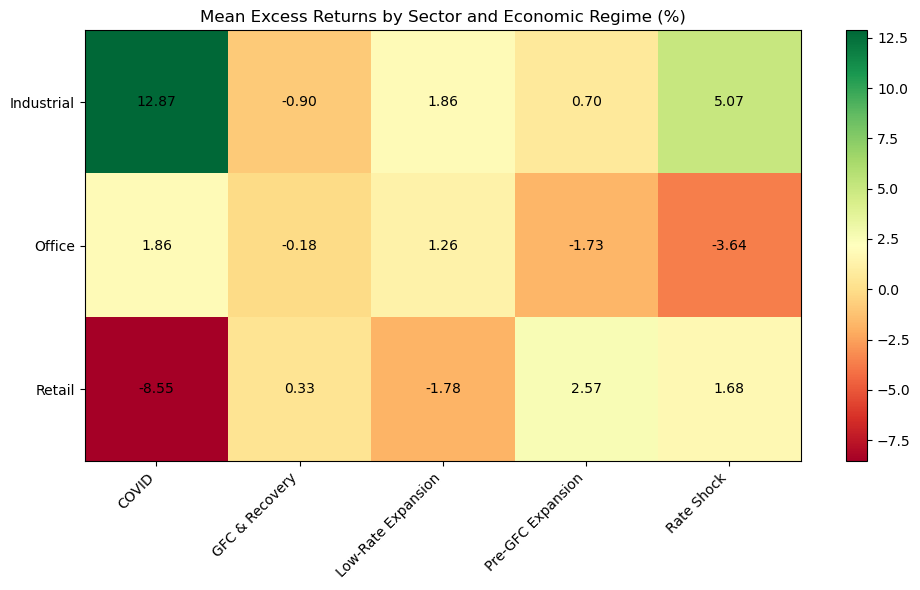

In [23]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))

data = sector_regime_returns.values

im = ax.imshow(data, cmap="RdYlGn", aspect="auto")

# Labels
ax.set_xticks(np.arange(len(sector_regime_returns.columns)))
ax.set_yticks(np.arange(len(sector_regime_returns.index)))

ax.set_xticklabels(sector_regime_returns.columns)
ax.set_yticklabels(sector_regime_returns.index)

# Rotate x labels
plt.setp(
    ax.get_xticklabels(),
    rotation=45,
    ha="right"
)

# Add values to cells
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        ax.text(
            j,
            i,
            f"{data[i,j]:.2f}",
            ha="center",
            va="center",
            color="black"
        )

plt.colorbar(im)

plt.title(
    "Mean Excess Returns by Sector and Economic Regime (%)"
)

plt.tight_layout()

plt.savefig(
    "Figure_Excess_Return_Heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
summary = pd.DataFrame({
    "Mean Excess Return":
        sector_regime_returns.mean(axis=1),

    "Regime Volatility":
        sector_regime_returns.std(axis=1),

    "Best Regime":
        sector_regime_returns.idxmax(axis=1),

    "Worst Regime":
        sector_regime_returns.idxmin(axis=1)
})

summary.round(2)

,Mean Excess Return,Regime Volatility,Best Regime,Worst Regime
sector,,,,
Industrial,3.92,5.46,COVID,GFC & Recovery
Office,-0.49,2.24,COVID,Rate Shock
Retail,-1.15,4.45,Pre-GFC Expansion,COVID


In [25]:
Regime_Analysis_Results.xlsx
Figure_Excess_Return_Heatmap.png

NameError: name 'Regime_Analysis_Results' is not defined

In [26]:
import os

os.listdir()

['.anaconda',
 '.conda',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.matplotlib',
 '.ms-ad',
 '3D Objects',
 'Air NZ Returns.xlsx',
 'Anixemenes Vintage 2026.xlsx',
 'AppData',
 'Application Data',
 'Aramco Data Book 1Q26.xlsx',
 'aramco_prices.xlsx',
 'Aware Real Estate',
 'A_REIT_2016_2025_monthly_total_returns_survivorship_free.csv',
 'benchmark_methodology_correlations.csv',
 'benchmark_returns.csv',
 'benchmark_weights_annual.csv',
 'benchmark_weights_quarterly.csv',
 'Contacts',
 'Cookies',
 'Data Preparation Research Report.ipynb',
 'Documents',
 'Downloads',
 'dynamic_erp_wacc_inputs.xlsx',
 'equal_weight_benchmark.csv',
 'equal_weight_excess_returns.csv',
 'excess_return_comparison_table.csv',
 'f01hist (2).xlsx',
 'f02hist.xlsx',
 'f02histhist.xls',
 'Favorites',
 'Figure_1_Benchmark_Evolution.png',
 'Figure_Excess_Return_Heatmap.png',
 'Final Research Report.ipynb',
 'final_dynamic_wacc.xlsx',
 'final_rolling_wacc.xlsx',
 'final_wacc_corrected.xlsx',
 'final_wacc_dam

In [27]:
os.path.exists("Regime_Analysis_Results.xlsx")

True

In [28]:
os.path.exists("Figure_Excess_Return_Heatmap.png")

True

In [29]:
summary = pd.DataFrame({
    "Mean Excess Return":
        sector_regime_returns.mean(axis=1),

    "Regime Volatility":
        sector_regime_returns.std(axis=1),

    "Best Regime":
        sector_regime_returns.idxmax(axis=1),

    "Worst Regime":
        sector_regime_returns.idxmin(axis=1)
})

summary.round(2)

,Mean Excess Return,Regime Volatility,Best Regime,Worst Regime
sector,,,,
Industrial,3.92,5.46,COVID,GFC & Recovery
Office,-0.49,2.24,COVID,Rate Shock
Retail,-1.15,4.45,Pre-GFC Expansion,COVID


In [30]:
summary = pd.DataFrame({
    "Mean Excess Return":
        sector_regime_returns.mean(axis=1),

    "Regime Volatility":
        sector_regime_returns.std(axis=1),

    "Best Regime":
        sector_regime_returns.idxmax(axis=1),

    "Worst Regime":
        sector_regime_returns.idxmin(axis=1)
})

summary.round(2)

,Mean Excess Return,Regime Volatility,Best Regime,Worst Regime
sector,,,,
Industrial,3.92,5.46,COVID,GFC & Recovery
Office,-0.49,2.24,COVID,Rate Shock
Retail,-1.15,4.45,Pre-GFC Expansion,COVID


In [31]:
total_regime = (
    df.groupby(
        ["sector", "regime"]
    )["total_return"]
    .mean()
    .unstack()
    .round(2)
)

total_regime

regime,COVID,GFC & Recovery,Low-Rate Expansion,Pre-GFC Expansion,Rate Shock
sector,,,,,
Industrial,18.59,4.92,12.50,12.07,8.90
Office,7.58,5.65,11.90,9.64,0.20
Retail,-2.83,6.15,8.86,13.94,5.52


In [32]:
summary = pd.DataFrame({
    "Mean Excess Return":
        sector_regime_returns.mean(axis=1),

    "Regime Volatility":
        sector_regime_returns.std(axis=1),

    "Best Regime":
        sector_regime_returns.idxmax(axis=1),

    "Worst Regime":
        sector_regime_returns.idxmin(axis=1)
})

summary.round(2)

,Mean Excess Return,Regime Volatility,Best Regime,Worst Regime
sector,,,,
Industrial,3.92,5.46,COVID,GFC & Recovery
Office,-0.49,2.24,COVID,Rate Shock
Retail,-1.15,4.45,Pre-GFC Expansion,COVID


In [33]:
import pandas as pd
import os

# =====================================================
# CREATE OUTPUT FOLDER
# =====================================================

output_dir = "Regime_Analysis_Output"

os.makedirs(output_dir, exist_ok=True)

# =====================================================
# CREATE SUMMARY TABLE
# =====================================================

summary = pd.DataFrame({
    "Mean Excess Return":
        sector_regime_returns.mean(axis=1),

    "Regime Volatility":
        sector_regime_returns.std(axis=1),

    "Best Regime":
        sector_regime_returns.idxmax(axis=1),

    "Worst Regime":
        sector_regime_returns.idxmin(axis=1)
})

summary = summary.round(2)

# =====================================================
# MASTER EXCEL FILE
# =====================================================

excel_file = os.path.join(
    output_dir,
    "Regime_Analysis_Results.xlsx"
)

with pd.ExcelWriter(
    excel_file,
    engine="openpyxl"
) as writer:

    regime_validation.to_excel(
        writer,
        sheet_name="Regime_Validation"
    )

    sector_regime_returns.to_excel(
        writer,
        sheet_name="Excess_Returns"
    )

    income_regime.to_excel(
        writer,
        sheet_name="Income_Returns"
    )

    capital_regime.to_excel(
        writer,
        sheet_name="Capital_Returns"
    )

    total_regime.to_excel(
        writer,
        sheet_name="Total_Returns"
    )

    summary.to_excel(
        writer,
        sheet_name="Summary"
    )

# =====================================================
# INDIVIDUAL CSV FILES
# =====================================================

regime_validation.to_csv(
    os.path.join(
        output_dir,
        "regime_validation.csv"
    )
)

sector_regime_returns.to_csv(
    os.path.join(
        output_dir,
        "excess_returns_by_regime.csv"
    )
)

income_regime.to_csv(
    os.path.join(
        output_dir,
        "income_returns_by_regime.csv"
    )
)

capital_regime.to_csv(
    os.path.join(
        output_dir,
        "capital_returns_by_regime.csv"
    )
)

total_regime.to_csv(
    os.path.join(
        output_dir,
        "total_returns_by_regime.csv"
    )
)

summary.to_csv(
    os.path.join(
        output_dir,
        "summary.csv"
    )
)

print("Exports saved successfully.")
print(f"Location: {os.path.abspath(output_dir)}")

Exports saved successfully.
Location: C:\Users\DanielKrivan\Regime_Analysis_Output


In [34]:
os.listdir("Regime_Analysis_Output")

['capital_returns_by_regime.csv',
 'excess_returns_by_regime.csv',
 'income_returns_by_regime.csv',
 'Regime_Analysis_Results.xlsx',
 'regime_validation.csv',
 'summary.csv',
 'total_returns_by_regime.csv']

In [35]:
ordered_cols = [
    "Pre-GFC Expansion",
    "GFC & Recovery",
    "Low-Rate Expansion",
    "COVID",
    "Rate Shock"
]

sector_regime_returns = sector_regime_returns[
    ordered_cols
]

In [36]:
ordered_cols = [
    "Pre-GFC Expansion",
    "GFC & Recovery",
    "Low-Rate Expansion",
    "COVID",
    "Rate Shock"
]

sector_regime_returns = sector_regime_returns[
    ordered_cols
]

sector_regime_returns

regime,Pre-GFC Expansion,GFC & Recovery,Low-Rate Expansion,COVID,Rate Shock
sector,,,,,
Industrial,0.70,-0.90,1.86,12.87,5.07
Office,-1.73,-0.18,1.26,1.86,-3.64
Retail,2.57,0.33,-1.78,-8.55,1.68


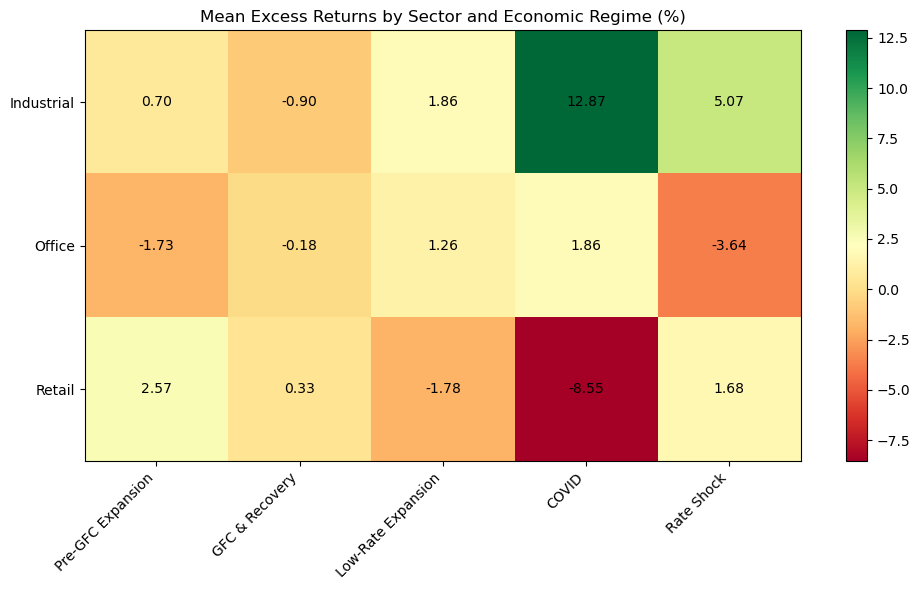

In [37]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))

data = sector_regime_returns.values

im = ax.imshow(
    data,
    cmap="RdYlGn",
    aspect="auto"
)

ax.set_xticks(np.arange(len(sector_regime_returns.columns)))
ax.set_yticks(np.arange(len(sector_regime_returns.index)))

ax.set_xticklabels(sector_regime_returns.columns)
ax.set_yticklabels(sector_regime_returns.index)

plt.setp(
    ax.get_xticklabels(),
    rotation=45,
    ha="right"
)

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        ax.text(
            j,
            i,
            f"{data[i,j]:.2f}",
            ha="center",
            va="center",
            color="black"
        )

plt.colorbar(im)

plt.title(
    "Mean Excess Returns by Sector and Economic Regime (%)"
)

plt.tight_layout()

plt.savefig(
    "Figure_Excess_Return_Heatmap_Chronological.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [38]:
import os

os.path.exists(
    "Figure_Excess_Return_Heatmap_Chronological.png"
)

True

In [39]:
regime_validation.round(2)

,cash_rate,bond_10y,cap_rate,discount_rate,cap_rate_spread_bond,discount_rate_spread_bond
regime,,,,,,
COVID,0.21,1.20,5.09,6.34,3.89,5.14
GFC & Recovery,4.54,4.90,7.48,9.19,2.59,4.29
Low-Rate Expansion,1.89,2.75,6.42,7.95,3.67,5.20
Pre-GFC Expansion,6.14,8.39,8.29,11.21,1.82,4.55
Rate Shock,3.37,3.98,5.32,6.61,1.34,2.63


In [40]:
regime_validation.round(2).to_excel(
    "Table_5_Economic_Regime_Characteristics.xlsx"
)


In [41]:
sector_regime_returns.round(2)

regime,Pre-GFC Expansion,GFC & Recovery,Low-Rate Expansion,COVID,Rate Shock
sector,,,,,
Industrial,0.70,-0.90,1.86,12.87,5.07
Office,-1.73,-0.18,1.26,1.86,-3.64
Retail,2.57,0.33,-1.78,-8.55,1.68


In [42]:
sector_regime_returns.round(2).to_excel(
    "Table_6_Excess_Returns.xlsx"
)

In [43]:
income_regime.round(2)

regime,COVID,GFC & Recovery,Low-Rate Expansion,Pre-GFC Expansion,Rate Shock
sector,,,,,
Industrial,5.39,8.06,7.16,9.01,4.17
Office,4.94,7.08,6.31,7.09,4.94
Retail,4.70,6.84,6.07,8.06,5.75


In [44]:
income_regime.round(2).to_excel(
    "Table_7_Income_Returns.xlsx"
)

In [45]:
capital_regime.round(2)


regime,COVID,GFC & Recovery,Low-Rate Expansion,Pre-GFC Expansion,Rate Shock
sector,,,,,
Industrial,12.61,-2.93,5.02,2.84,4.56
Office,2.53,-1.35,5.29,2.43,-4.53
Retail,-7.23,-0.65,2.64,5.48,-0.22


In [46]:
capital_regime.round(2).to_excel(
    "Table_8_Capital_Returns.xlsx"
)

In [47]:
total_regime.round(2)

regime,COVID,GFC & Recovery,Low-Rate Expansion,Pre-GFC Expansion,Rate Shock
sector,,,,,
Industrial,18.59,4.92,12.50,12.07,8.90
Office,7.58,5.65,11.90,9.64,0.20
Retail,-2.83,6.15,8.86,13.94,5.52


In [48]:
total_regime.round(2).to_excel(
    "Table_9_Total_Returns.xlsx"
)

In [49]:
summary = pd.DataFrame({
    "Mean Excess Return":
        sector_regime_returns.mean(axis=1),

    "Regime Volatility":
        sector_regime_returns.std(axis=1),

    "Best Regime":
        sector_regime_returns.idxmax(axis=1),

    "Worst Regime":
        sector_regime_returns.idxmin(axis=1)
})

summary.round(2)

,Mean Excess Return,Regime Volatility,Best Regime,Worst Regime
sector,,,,
Industrial,3.92,5.46,COVID,GFC & Recovery
Office,-0.49,2.24,COVID,Rate Shock
Retail,-1.15,4.45,Pre-GFC Expansion,COVID


In [50]:
summary.round(2).to_excel(
    "Table_10_Structural_Cyclical_Summary.xlsx"
)

In [51]:
import os

for file in os.listdir():
    if file.startswith("Table_"):
        print(file)

Table_10_Structural_Cyclical_Summary.xlsx
Table_1_Benchmark_Weights.csv
Table_1_Benchmark_Weights.png
Table_2_Benchmark_Robustness.csv
Table_2_Benchmark_Robustness.png
Table_3_Descriptive_Statistics.csv
Table_3_Descriptive_Statistics.png
Table_5_Economic_Regime_Characteristics.xlsx
Table_6_Excess_Returns.xlsx
Table_7_Income_Returns.xlsx
Table_8_Capital_Returns.xlsx
Table_9_Total_Returns.xlsx


In [52]:
summary.round(2)

,Mean Excess Return,Regime Volatility,Best Regime,Worst Regime
sector,,,,
Industrial,3.92,5.46,COVID,GFC & Recovery
Office,-0.49,2.24,COVID,Rate Shock
Retail,-1.15,4.45,Pre-GFC Expansion,COVID


In [53]:
summary.round(2).to_excel(
    "Table_10_Structural_Cyclical_Summary.xlsx"
)

In [54]:
import os

print(
    sorted(
        [f for f in os.listdir()
         if f.startswith("Table_")]
    )
)

['Table_10_Structural_Cyclical_Summary.xlsx', 'Table_1_Benchmark_Weights.csv', 'Table_1_Benchmark_Weights.png', 'Table_2_Benchmark_Robustness.csv', 'Table_2_Benchmark_Robustness.png', 'Table_3_Descriptive_Statistics.csv', 'Table_3_Descriptive_Statistics.png', 'Table_5_Economic_Regime_Characteristics.xlsx', 'Table_6_Excess_Returns.xlsx', 'Table_7_Income_Returns.xlsx', 'Table_8_Capital_Returns.xlsx', 'Table_9_Total_Returns.xlsx']


In [55]:
import pandas as pd

regime_definitions = pd.DataFrame({
    "Regime": [
        "Pre-GFC Expansion",
        "GFC and Recovery",
        "Low-Rate Expansion",
        "COVID",
        "Rate Shock"
    ],
    "Period": [
        "Q4 1985 – Q4 2007",
        "Q1 2008 – Q4 2012",
        "Q1 2013 – Q4 2019",
        "Q1 2020 – Q4 2021",
        "Q1 2022 – Q1 2026"
    ],
    "Description": [
        "Pre-GFC economic expansion",
        "Global Financial Crisis and recovery",
        "Prolonged low interest-rate environment",
        "COVID-19 disruption and policy response",
        "Interest-rate tightening and repricing"
    ]
})

regime_definitions

,Regime,Period,Description
0,Pre-GFC Expansion,Q4 1985 – Q4 2007,Pre-GFC economic expansion
1,GFC and Recovery,Q1 2008 – Q4 2012,Global Financial Crisis and recovery
2,Low-Rate Expansion,Q1 2013 – Q4 2019,Prolonged low interest-rate environment
3,COVID,Q1 2020 – Q4 2021,COVID-19 disruption and policy response
4,Rate Shock,Q1 2022 – Q1 2026,Interest-rate tightening and repricing


In [56]:
regime_definitions.to_excel(
    "Table_4_Economic_Regime_Definitions.xlsx",
    index=False
)

In [57]:
import os

print(os.path.exists(
    "Table_4_Economic_Regime_Definitions.xlsx"
))

True


In [58]:
regime_definitions = pd.DataFrame({
    "Regime": [
        "Pre-GFC Expansion",
        "GFC and Recovery",
        "Low-Rate Expansion",
        "COVID",
        "Rate Shock"
    ],
    "Period": [
        "Q4 1985 – Q4 2007",
        "Q1 2008 – Q4 2012",
        "Q1 2013 – Q4 2019",
        "Q1 2020 – Q4 2021",
        "Q1 2022 – Q1 2026"
    ],
    "Primary Characteristic": [
        "High-rate expansion",
        "Crisis and recovery",
        "Low-rate growth",
        "Pandemic disruption",
        "Monetary tightening"
    ]
})

regime_definitions

,Regime,Period,Primary Characteristic
0,Pre-GFC Expansion,Q4 1985 – Q4 2007,High-rate expansion
1,GFC and Recovery,Q1 2008 – Q4 2012,Crisis and recovery
2,Low-Rate Expansion,Q1 2013 – Q4 2019,Low-rate growth
3,COVID,Q1 2020 – Q4 2021,Pandemic disruption
4,Rate Shock,Q1 2022 – Q1 2026,Monetary tightening


In [59]:
[f for f in os.listdir() if f.startswith("Table_")]

['Table_10_Structural_Cyclical_Summary.xlsx',
 'Table_1_Benchmark_Weights.csv',
 'Table_1_Benchmark_Weights.png',
 'Table_2_Benchmark_Robustness.csv',
 'Table_2_Benchmark_Robustness.png',
 'Table_3_Descriptive_Statistics.csv',
 'Table_3_Descriptive_Statistics.png',
 'Table_4_Economic_Regime_Definitions.xlsx',
 'Table_5_Economic_Regime_Characteristics.xlsx',
 'Table_6_Excess_Returns.xlsx',
 'Table_7_Income_Returns.xlsx',
 'Table_8_Capital_Returns.xlsx',
 'Table_9_Total_Returns.xlsx']

NameError: name 'table_4' is not defined

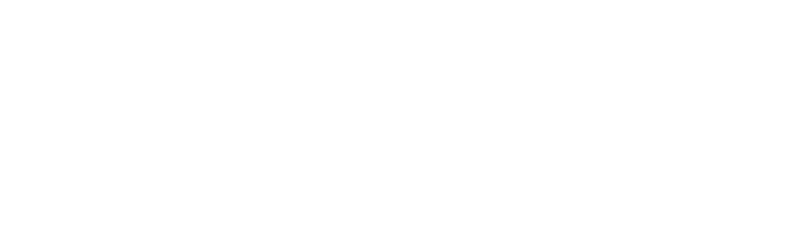

In [60]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,3))

ax.axis('off')

tbl = ax.table(
    cellText=table_4.values,
    colLabels=table_4.columns,
    loc='center'
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.8)

plt.savefig(
    "Table_4_Economic_Regime_Definitions.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [61]:
import pandas as pd

table_4 = pd.DataFrame({
    "Regime": [
        "Pre-GFC Expansion",
        "GFC and Recovery",
        "Low-Rate Expansion",
        "COVID",
        "Rate Shock"
    ],
    "Period": [
        "Q4 1985 – Q4 2007",
        "Q1 2008 – Q4 2012",
        "Q1 2013 – Q4 2019",
        "Q1 2020 – Q4 2021",
        "Q1 2022 – Q1 2026"
    ],
    "Primary Characteristic": [
        "High-rate expansion",
        "Financial crisis and recovery",
        "Low-rate growth environment",
        "Pandemic disruption",
        "Monetary tightening and repricing"
    ]
})

table_4

,Regime,Period,Primary Characteristic
0,Pre-GFC Expansion,Q4 1985 – Q4 2007,High-rate expansion
1,GFC and Recovery,Q1 2008 – Q4 2012,Financial crisis and recovery
2,Low-Rate Expansion,Q1 2013 – Q4 2019,Low-rate growth environment
3,COVID,Q1 2020 – Q4 2021,Pandemic disruption
4,Rate Shock,Q1 2022 – Q1 2026,Monetary tightening and repricing


In [62]:
table_4.to_excel(
    "Table_4_Economic_Regime_Definitions.xlsx",
    index=False
)

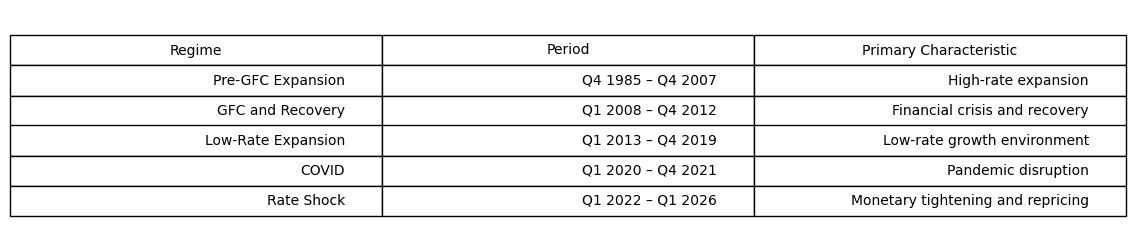

In [63]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 3))

ax.axis('off')

tbl = ax.table(
    cellText=table_4.values,
    colLabels=table_4.columns,
    loc='center'
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.8)

plt.savefig(
    "Table_4_Economic_Regime_Definitions.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [64]:
import os

sorted(
    [f for f in os.listdir()
     if f.startswith("Table_4")]
)

['Table_4_Economic_Regime_Definitions.png',
 'Table_4_Economic_Regime_Definitions.xlsx']

In [65]:
import matplotlib.pyplot as plt

def save_df_as_png(df,
                   filename,
                   title=None,
                   figsize=(12,4),
                   fontsize=9):

    fig, ax = plt.subplots(figsize=figsize)

    ax.axis('off')

    if title:
        ax.set_title(
            title,
            fontsize=12,
            pad=20
        )

    table = ax.table(
        cellText=df.values,
        rowLabels=df.index,
        colLabels=df.columns,
        cellLoc='center',
        loc='center'
    )

    table.auto_set_font_size(False)
    table.set_fontsize(fontsize)
    table.scale(1.2, 1.8)

    plt.savefig(
        filename,
        bbox_inches='tight',
        dpi=300
    )

    plt.close()

    print(f"Saved: {filename}")

In [66]:
save_df_as_png(
    regime_validation.round(2),
    "Table_5_Economic_Regime_Characteristics.png",
    title="Table 5. Economic Regime Characteristics",
    figsize=(14,4)
)

Saved: Table_5_Economic_Regime_Characteristics.png


In [67]:
save_df_as_png(
    sector_regime_returns.round(2),
    "Table_6_Excess_Returns.png",
    title="Table 6. Mean Sector Excess Returns by Economic Regime",
    figsize=(12,3)
)

Saved: Table_6_Excess_Returns.png


In [68]:
save_df_as_png(
    income_regime.round(2),
    "Table_7_Income_Returns.png",
    title="Table 7. Mean Sector Income Returns by Economic Regime",
    figsize=(12,3)
)

Saved: Table_7_Income_Returns.png


In [69]:
save_df_as_png(
    capital_regime.round(2),
    "Table_8_Capital_Returns.png",
    title="Table 8. Mean Sector Capital Returns by Economic Regime",
    figsize=(12,3)
)

Saved: Table_8_Capital_Returns.png


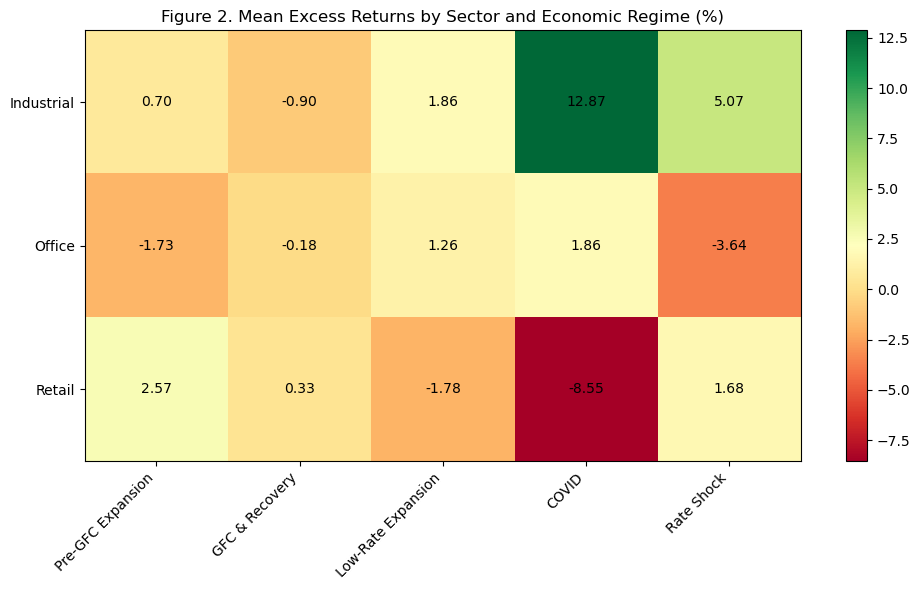

In [70]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))

data = sector_regime_returns.values

im = ax.imshow(
    data,
    cmap="RdYlGn",
    aspect="auto"
)

ax.set_xticks(np.arange(len(sector_regime_returns.columns)))
ax.set_yticks(np.arange(len(sector_regime_returns.index)))

ax.set_xticklabels(sector_regime_returns.columns)
ax.set_yticklabels(sector_regime_returns.index)

plt.setp(
    ax.get_xticklabels(),
    rotation=45,
    ha="right"
)

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        ax.text(
            j,
            i,
            f"{data[i,j]:.2f}",
            ha="center",
            va="center"
        )

plt.colorbar(im)

plt.title(
    "Figure 2. Mean Excess Returns by Sector and Economic Regime (%)"
)

plt.tight_layout()

plt.savefig(
    "Figure_2_Mean_Excess_Returns_by_Regime.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [71]:
import os

for f in sorted(os.listdir()):
    if f.endswith(".png"):
        print(f)


Figure_1_Benchmark_Evolution.png
Figure_2_Mean_Excess_Returns_by_Regime.png
Figure_Excess_Return_Heatmap_Chronological.png
Table_1_Benchmark_Weights.png
Table_2_Benchmark_Robustness.png
Table_3_Descriptive_Statistics.png
Table_4_Economic_Regime_Definitions.png
Table_5_Economic_Regime_Characteristics.png
Table_6_Excess_Returns.png
Table_7_Income_Returns.png
Table_8_Capital_Returns.png


In [72]:
save_df_as_png(
    benchmark_robustness.round(3),
    "Table_3_Benchmark_Robustness.png",
    title="Table 3. Robustness of Sector Excess Returns to Benchmark Construction",
    figsize=(12,3)
)

NameError: name 'benchmark_robustness' is not defined

In [73]:
import pandas as pd

benchmark_robustness = pd.DataFrame({
    "Correlation": [
        0.956,
        0.968,
        0.975
    ],
    "MSCI Benchmark Mean Excess Return (%)": [
        -1.04,
         0.90,
         1.76
    ],
    "Equal-Weight Mean Excess Return (%)": [
        -0.73,
         0.55,
         1.22
    ]
},
index=[
    "Office",
    "Retail",
    "Industrial"
])

benchmark_robustness

,Correlation,MSCI Benchmark Mean Excess Return (%),Equal-Weight Mean Excess Return (%)
Office,0.956,-1.04,-0.73
Retail,0.968,0.90,0.55
Industrial,0.975,1.76,1.22


In [74]:
save_df_as_png(
    benchmark_robustness.round(3),
    "Table_3_Benchmark_Robustness.png",
    title="Table 3. Robustness of Sector Excess Returns to Benchmark Construction",
    figsize=(14,3)
)

Saved: Table_3_Benchmark_Robustness.png


In [75]:
benchmark_robustness.to_excel(
    "Table_3_Benchmark_Robustness.xlsx"
)

In [76]:
df["total_capital_value"] = (
    df.groupby("quarter_label")["capital_value_m"]
    .transform("sum")
)

df["sector_weight"] = (
    df["capital_value_m"]
    / df["total_capital_value"]
) * 100

In [77]:
annual_weights = (
    df.groupby(["year", "sector"])["sector_weight"]
    .mean()
    .reset_index()
)

In [78]:
table_1_weights = (
    annual_weights
    .pivot(
        index="year",
        columns="sector",
        values="sector_weight"
    )
    .round(1)
)

table_1_weights.head()


sector,Industrial,Office,Retail
year,,,
1985,4.0,69.4,26.6
1986,3.9,70.7,25.5
1987,4.2,72.5,23.3
1988,3.7,73.9,22.4
1989,3.3,73.2,23.5


In [79]:
selected_years = [
    1986,
    1990,
    1995,
    2000,
    2005,
    2010,
    2015,
    2020,
    2025
]

table_1_summary = (
    table_1_weights
    .loc[selected_years]
)

table_1_summary

sector,Industrial,Office,Retail
year,,,
1986,3.9,70.7,25.5
1990,3.3,71.0,25.7
1995,4.9,54.6,40.5
2000,8.9,53.0,38.0
2005,9.3,44.3,46.3
2010,10.3,44.9,44.8
2015,10.0,45.6,44.3
2020,13.3,51.1,35.6
2025,25.3,42.5,32.2


In [80]:
table_1_summary.to_excel(
    "Table_1_Benchmark_Weights.xlsx"
)


In [81]:
save_df_as_png(
    table_1_summary,
    "Table_1_Benchmark_Weights.png",
    title="Table 1. MSCI Australia All Property Index Sector Weights (%)",
    figsize=(10,4)
)

Saved: Table_1_Benchmark_Weights.png


In [82]:
table_1_key_years = (
    table_1_weights
    .loc[[1986, 1995, 2005, 2015, 2025]]
    .round(1)
)

table_1_key_years

sector,Industrial,Office,Retail
year,,,
1986,3.9,70.7,25.5
1995,4.9,54.6,40.5
2005,9.3,44.3,46.3
2015,10.0,45.6,44.3
2025,25.3,42.5,32.2


In [83]:
import pandas as pd

# Load data
df = pd.read_excel("property_data.xlsx")

# Select predictors
vars_to_check = [
    "Income_Return",
    "Capital_Return",
    "Cap_Rate",
    "Discount_Rate"
]

corr_matrix = df[vars_to_check].corr()

print(corr_matrix)

corr_matrix.to_excel("correlation_matrix.xlsx")

FileNotFoundError: [Errno 2] No such file or directory: 'property_data.xlsx'

In [84]:
import os

print(os.getcwd())
print(os.listdir())


C:\Users\DanielKrivan
['.anaconda', '.conda', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.ms-ad', '3D Objects', 'Air NZ Returns.xlsx', 'Anixemenes Vintage 2026.xlsx', 'AppData', 'Application Data', 'Aramco Data Book 1Q26.xlsx', 'aramco_prices.xlsx', 'Aware Real Estate', 'A_REIT_2016_2025_monthly_total_returns_survivorship_free.csv', 'benchmark_methodology_correlations.csv', 'benchmark_returns.csv', 'benchmark_weights_annual.csv', 'benchmark_weights_quarterly.csv', 'Contacts', 'Cookies', 'Data Preparation Research Report.ipynb', 'Documents', 'Downloads', 'dynamic_erp_wacc_inputs.xlsx', 'equal_weight_benchmark.csv', 'equal_weight_excess_returns.csv', 'excess_return_comparison_table.csv', 'f01hist (2).xlsx', 'f02hist.xlsx', 'f02histhist.xls', 'Favorites', 'Figure_1_Benchmark_Evolution.png', 'Figure_2_Mean_Excess_Returns_by_Regime.png', 'Figure_Excess_Return_Heatmap_Chronological.png', 'Final Research Report.ipynb', 'final_dynamic_wacc.xlsx', 'final_rolling_wacc.xlsx', '

In [85]:
import pandas as pd

df = pd.read_excel("msci_research_dataset_v3.xlsx")

print(df.columns.tolist())
print()
print(df.head())

['quarter_end', 'sector', 'total_return', 'capital_return', 'income_return', 'capital_value_m', 'num_investments', 'cap_rate', 'discount_rate', 'year', 'quarter', 'quarter_label', 'cap_rate_spread', 'capital_value_growth_qoq', 'capital_value_growth_yoy', 'investment_growth_yoy', 'log_capital_value', 'return_check', 'return_difference', 'return_check_geometric', 'return_difference_geometric', 'cash_rate', 'bond_10y', 'cap_rate_spread_bond', 'discount_rate_spread_bond']

  quarter_end      sector  total_return  capital_return  income_return  \
0  1985-12-01  Industrial     14.753422        6.211565       8.084208   
1  1986-03-01  Industrial     15.954124        6.794845       8.625343   
2  1986-06-01  Industrial     16.367541        7.225124       8.578112   
3  1986-09-01  Industrial     17.133640        7.556796       8.960349   
4  1986-12-01  Industrial     17.209568        7.706414       8.880107   

   capital_value_m  num_investments  cap_rate  discount_rate  year  ...  \
0     

In [86]:
import pandas as pd

er = pd.read_csv("sector_excess_returns.csv")

print(er.columns.tolist())
print()
print(er.head())
print()
print(er.shape)

['quarter_end', 'Office_MSCI_Excess', 'Retail_MSCI_Excess', 'Industrial_MSCI_Excess', 'Office_EW_Excess', 'Retail_EW_Excess', 'Industrial_EW_Excess']

  quarter_end  Office_MSCI_Excess  Retail_MSCI_Excess  Industrial_MSCI_Excess  \
0  1985-12-01           -1.111046            3.083821               -1.270779   
1  1986-03-01           -1.177699            3.267621               -0.642015   
2  1986-06-01           -1.092932            3.213815               -0.576101   
3  1986-09-01           -0.824816            2.461464               -0.593717   
4  1986-12-01           -0.541768            1.619463               -1.076831   

   Office_EW_Excess  Retail_EW_Excess  Industrial_EW_Excess  
0         -1.345045          2.849822             -1.504777  
1         -1.660335          2.784985             -1.124650  
2         -1.607860          2.698888             -1.091028  
3         -1.172460          2.113820             -0.941361  
4         -0.542056          1.619175             -1

In [87]:
import pandas as pd

# Load datasets
msci = pd.read_excel("msci_research_dataset_v3.xlsx")
er = pd.read_csv("sector_excess_returns.csv")

# Convert dates
msci["quarter_end"] = pd.to_datetime(msci["quarter_end"])
er["quarter_end"] = pd.to_datetime(er["quarter_end"])

# Convert excess returns from wide to long
er_long = er.melt(
    id_vars="quarter_end",
    value_vars=[
        "Office_MSCI_Excess",
        "Retail_MSCI_Excess",
        "Industrial_MSCI_Excess"
    ],
    var_name="series",
    value_name="excess_return"
)

# Map sector names
er_long["sector"] = (
    er_long["series"]
      .str.replace("_MSCI_Excess", "", regex=False)
)

# Merge
reg_df = msci.merge(
    er_long[["quarter_end", "sector", "excess_return"]],
    on=["quarter_end", "sector"],
    how="left"
)

print(reg_df.shape)
print(reg_df.head())

reg_df.to_excel("regression_dataset.xlsx", index=False)

(486, 26)
  quarter_end      sector  total_return  capital_return  income_return  \
0  1985-12-01  Industrial     14.753422        6.211565       8.084208   
1  1986-03-01  Industrial     15.954124        6.794845       8.625343   
2  1986-06-01  Industrial     16.367541        7.225124       8.578112   
3  1986-09-01  Industrial     17.133640        7.556796       8.960349   
4  1986-12-01  Industrial     17.209568        7.706414       8.880107   

   capital_value_m  num_investments  cap_rate  discount_rate  year  ...  \
0       255.164609               49       NaN            NaN  1985  ...   
1       259.752100               49       NaN            NaN  1986  ...   
2       328.465496               63       NaN            NaN  1986  ...   
3       334.334900               63       NaN            NaN  1986  ...   
4       391.922357               70       NaN            NaN  1986  ...   

   log_capital_value return_check  return_difference  return_check_geometric  \
0           5.

In [88]:
corr = reg_df[
    [
        "income_return",
        "capital_return",
        "cap_rate",
        "discount_rate"
    ]
].corr()

print(corr.round(3))

                income_return  capital_return  cap_rate  discount_rate
income_return           1.000          -0.049     0.967          0.885
capital_return         -0.049           1.000    -0.065         -0.168
cap_rate                0.967          -0.065     1.000          0.910
discount_rate           0.885          -0.168     0.910          1.000


In [89]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X = reg_df[
    [
        "income_return",
        "capital_return",
        "cap_rate",
        "discount_rate"
    ]
].dropna()

vif = pd.DataFrame()

vif["Variable"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif)

         Variable         VIF
0   income_return  455.049223
1  capital_return    1.589368
2        cap_rate  519.271594
3   discount_rate  123.979958


In [90]:
import statsmodels.api as sm

reg_df = reg_df.sort_values(
    ["sector", "quarter_end"]
)

reg_df["ER_L1"] = (
    reg_df.groupby("sector")["excess_return"]
          .shift(1)
)

model_df = reg_df.dropna(
    subset=["excess_return", "ER_L1"]
)

X = sm.add_constant(model_df["ER_L1"])
y = model_df["excess_return"]

model = sm.OLS(y, X).fit(
    cov_type="HAC",
    cov_kwds={"maxlags":4}
)

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          excess_return   R-squared:                       0.950
Model:                            OLS   Adj. R-squared:                  0.949
Method:                 Least Squares   F-statistic:                     1514.
Date:                Tue, 14 Jul 2026   Prob (F-statistic):          1.12e-150
Time:                        18:20:36   Log-Likelihood:                -654.49
No. Observations:                 483   AIC:                             1313.
Df Residuals:                     481   BIC:                             1321.
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0137      0.066      0.207      0.8

In [91]:
corr.to_excel("Correlation_Matrix.xlsx")

In [92]:
vif.to_excel("VIF_Results.xlsx", index=False)

In [93]:
with open("Persistence_Regression.txt","w") as f:
    f.write(model.summary().as_text())
``

SyntaxError: invalid syntax (276538098.py, line 3)

In [94]:
with open("Persistence_Regression.txt","w") as f:
    f.write(model.summary().as_text())

In [95]:
reg_df.to_excel(
    "Final_Regression_Dataset.xlsx",
    index=False
)

In [1]:
df.head()

NameError: name 'df' is not defined

In [2]:
%who

Interactive namespace is empty.


In [3]:
import os

for f in os.listdir():
    print(f)

.anaconda
.conda
.ipynb_checkpoints
.ipython
.jupyter
.matplotlib
.ms-ad
3D Objects
Air NZ Returns.xlsx
Anixemenes Vintage 2026.xlsx
AppData
Application Data
Aramco Data Book 1Q26.xlsx
aramco_prices.xlsx
Aware Real Estate
A_REIT_2016_2025_monthly_total_returns_survivorship_free.csv
benchmark_methodology_correlations.csv
benchmark_returns.csv
benchmark_weights_annual.csv
benchmark_weights_quarterly.csv
Contacts
Cookies
Correlation_Matrix.xlsx
Data Preparation Research Report.ipynb
Documents
Downloads
dynamic_erp_wacc_inputs.xlsx
equal_weight_benchmark.csv
equal_weight_excess_returns.csv
excess_return_comparison_table.csv
f01hist (2).xlsx
f02hist.xlsx
f02histhist.xls
Favorites
Figure_1_Benchmark_Evolution.png
Figure_2_Mean_Excess_Returns_by_Regime.png
Figure_Excess_Return_Heatmap_Chronological.png
Final Research Report.ipynb
final_dynamic_wacc.xlsx
Final_Regression_Dataset.xlsx
final_rolling_wacc.xlsx
final_wacc_corrected.xlsx
final_wacc_damodaran.xlsx
Links
Local Settings
market_prices.

In [4]:
import pandas as pd

df = pd.read_excel("Final_Regression_Dataset.xlsx")

print(df.shape)
display(df.head())

print(df.columns.tolist())

(486, 27)


,quarter_end,sector,total_return,capital_return,income_return,capital_value_m,num_investments,cap_rate,discount_rate,year,...,return_check,return_difference,return_check_geometric,return_difference_geometric,cash_rate,bond_10y,cap_rate_spread_bond,discount_rate_spread_bond,excess_return,ER_L1
0,1985-12-01,Industrial,14.753422,6.211565,8.084208,255.164609,49,NaN,NaN,1985,...,14.295772,0.457650,14.797928,-0.044506,NaN,14.816667,NaN,NaN,-1.270779,NaN
1,1986-03-01,Industrial,15.954124,6.794845,8.625343,259.752100,49,NaN,NaN,1986,...,15.420188,0.533936,16.006266,-0.052142,NaN,13.466667,NaN,NaN,-0.642015,-1.270779
2,1986-06-01,Industrial,16.367541,7.225124,8.578112,328.465496,63,NaN,NaN,1986,...,15.803236,0.564306,16.423015,-0.055474,NaN,12.616667,NaN,NaN,-0.576101,-0.642015
3,1986-09-01,Industrial,17.133640,7.556796,8.960349,334.334900,63,NaN,NaN,1986,...,16.517145,0.616495,17.194260,-0.060620,NaN,14.050000,NaN,NaN,-0.593717,-0.576101
4,1986-12-01,Industrial,17.209568,7.706414,8.880107,391.922357,70,NaN,NaN,1986,...,16.586521,0.623047,17.270858,-0.061291,NaN,13.533333,NaN,NaN,-1.076831,-0.593717


['quarter_end', 'sector', 'total_return', 'capital_return', 'income_return', 'capital_value_m', 'num_investments', 'cap_rate', 'discount_rate', 'year', 'quarter', 'quarter_label', 'cap_rate_spread', 'capital_value_growth_qoq', 'capital_value_growth_yoy', 'investment_growth_yoy', 'log_capital_value', 'return_check', 'return_difference', 'return_check_geometric', 'return_difference_geometric', 'cash_rate', 'bond_10y', 'cap_rate_spread_bond', 'discount_rate_spread_bond', 'excess_return', 'ER_L1']


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure date format
df["quarter_end"] = pd.to_datetime(df["quarter_end"])

# Sort
df = df.sort_values(["sector", "quarter_end"])

# Create cumulative return index (starting at 100)
def build_index(group):
    group = group.copy()
    group["total_return_decimal"] = group["total_return"] / 100
    group["index"] = 100 * (1 + group["total_return_decimal"]).cumprod()
    return group

plot_df = (
    df.groupby("sector", group_keys=False)
      .apply(build_index)
)

# Plot
plt.figure(figsize=(12, 6))

for sector in ["Industrial", "Office", "Retail"]:
    sector_data = plot_df[plot_df["sector"] == sector]
    plt.plot(
        sector_data["quarter_end"],
        sector_data["index"],
        linewidth=2,
        label=sector
    )

plt.title(
    "Sector Total Return Indices (Q4 1985–Q1 2026)",
    fontsize=14
)
plt.xlabel("")
plt.ylabel("Index (Q4 1985 = 100)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "Figure_2_Sector_Total_Return_Indices.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

KeyError: 'sector'

<Figure size 1200x600 with 0 Axes>

In [6]:
print(plot_df.columns)
print(plot_df.head())

Index(['quarter_end', 'total_return', 'capital_return', 'income_return',
       'capital_value_m', 'num_investments', 'cap_rate', 'discount_rate',
       'year', 'quarter', 'quarter_label', 'cap_rate_spread',
       'capital_value_growth_qoq', 'capital_value_growth_yoy',
       'investment_growth_yoy', 'log_capital_value', 'return_check',
       'return_difference', 'return_check_geometric',
       'return_difference_geometric', 'cash_rate', 'bond_10y',
       'cap_rate_spread_bond', 'discount_rate_spread_bond', 'excess_return',
       'ER_L1', 'total_return_decimal', 'index'],
      dtype='str')
  quarter_end  total_return  capital_return  income_return  capital_value_m  \
0  1985-12-01     14.753422        6.211565       8.084208       255.164609   
1  1986-03-01     15.954124        6.794845       8.625343       259.752100   
2  1986-06-01     16.367541        7.225124       8.578112       328.465496   
3  1986-09-01     17.133640        7.556796       8.960349       334.334900   
4

In [7]:
print(df.columns.tolist())
print(df[['quarter_end', 'sector', 'total_return']].head())
print(df['sector'].unique())

['quarter_end', 'sector', 'total_return', 'capital_return', 'income_return', 'capital_value_m', 'num_investments', 'cap_rate', 'discount_rate', 'year', 'quarter', 'quarter_label', 'cap_rate_spread', 'capital_value_growth_qoq', 'capital_value_growth_yoy', 'investment_growth_yoy', 'log_capital_value', 'return_check', 'return_difference', 'return_check_geometric', 'return_difference_geometric', 'cash_rate', 'bond_10y', 'cap_rate_spread_bond', 'discount_rate_spread_bond', 'excess_return', 'ER_L1']
  quarter_end      sector  total_return
0  1985-12-01  Industrial     14.753422
1  1986-03-01  Industrial     15.954124
2  1986-06-01  Industrial     16.367541
3  1986-09-01  Industrial     17.133640
4  1986-12-01  Industrial     17.209568
<StringArray>
['Industrial', 'Office', 'Retail']
Length: 3, dtype: str


In [8]:
df.groupby('sector')['total_return'].describe()

,count,mean,std,min,25%,50%,75%,max
sector,,,,,,,,
Industrial,162.0,11.248144,6.941328,-8.718820,9.439595,12.180522,15.280411,30.461718
Office,162.0,8.444968,8.985008,-13.657233,6.565847,9.397509,12.587556,32.685293
Retail,162.0,10.388361,6.283797,-9.978078,8.033780,10.179880,13.878506,24.317391


In [9]:
df[['cap_rate','discount_rate']].describe()

,cap_rate,discount_rate
count,383.000000,409.000000
mean,7.156696,9.387175
std,1.558104,2.228827
min,4.065511,5.558385
25%,5.852082,7.326208
50%,7.100000,9.214146
75%,8.077764,10.873587
max,11.853570,15.778733


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Date format
df["quarter_end"] = pd.to_datetime(df["quarter_end"])

# Sort
df = df.sort_values(["sector", "quarter_end"]).copy()

# Four-quarter rolling average
df["total_return_roll4"] = (
    df.groupby("sector")["total_return"]
      .transform(lambda x: x.rolling(4, min_periods=1).mean())
)

# Plot
plt.figure(figsize=(12,6))

for sector in ["Industrial", "Office", "Retail"]:
    d = df[df["sector"] == sector]

    plt.plot(
        d["quarter_end"],
        d["total_return_roll4"],
        linewidth=2,
        label=sector
    )

plt.title("Figure 2. Four-Quarter Rolling Total Returns by Sector")
plt.ylabel("Total Return (%)")
plt.xlabel("")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "Figure_2_Total_Returns_by_Sector.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
``

SyntaxError: invalid syntax (3352851843.py, line 44)

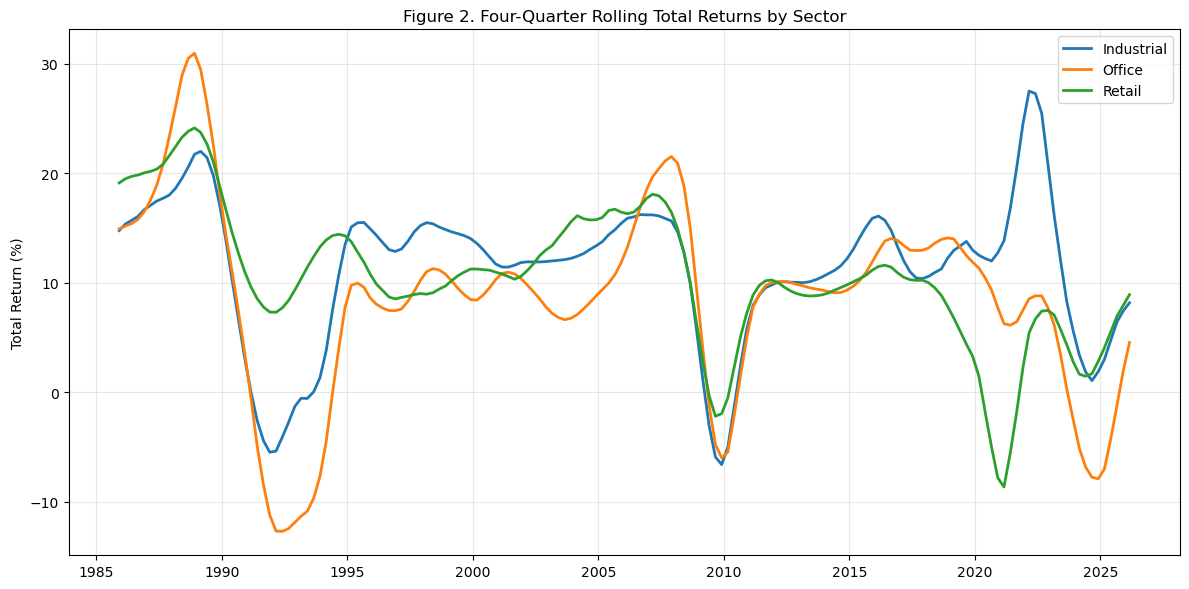

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Date format
df["quarter_end"] = pd.to_datetime(df["quarter_end"])

# Sort
df = df.sort_values(["sector", "quarter_end"]).copy()

# Four-quarter rolling average
df["total_return_roll4"] = (
    df.groupby("sector")["total_return"]
      .transform(lambda x: x.rolling(4, min_periods=1).mean())
)

# Plot
plt.figure(figsize=(12,6))

for sector in ["Industrial", "Office", "Retail"]:
    d = df[df["sector"] == sector]

    plt.plot(
        d["quarter_end"],
        d["total_return_roll4"],
        linewidth=2,
        label=sector
    )

plt.title("Figure 2. Four-Quarter Rolling Total Returns by Sector")
plt.ylabel("Total Return (%)")
plt.xlabel("")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "Figure_2_Total_Returns_by_Sector.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

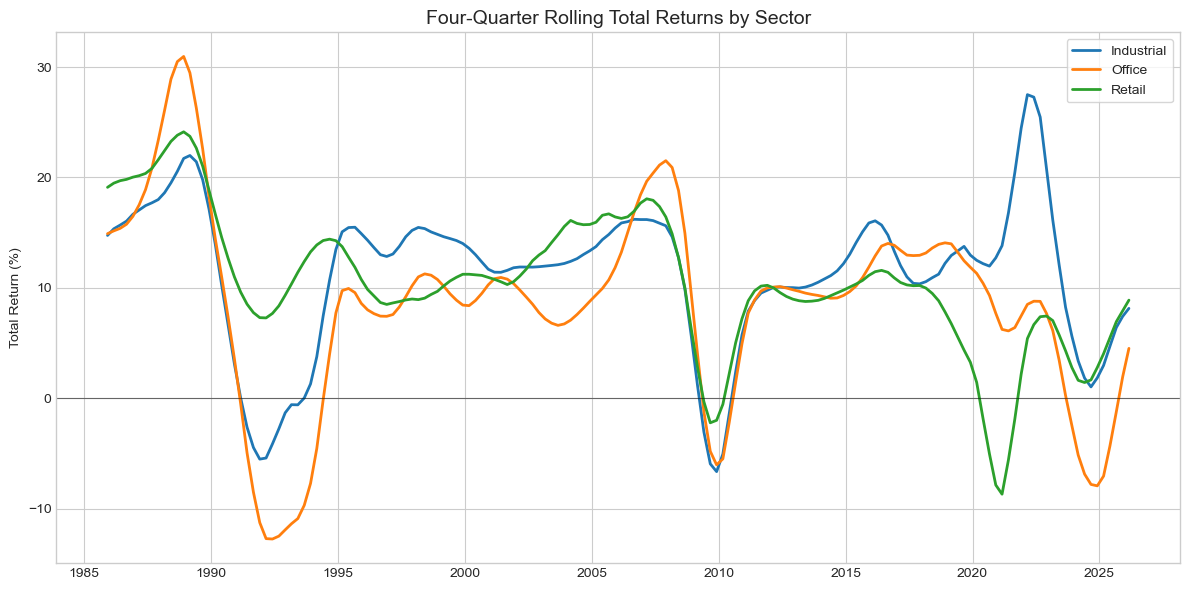

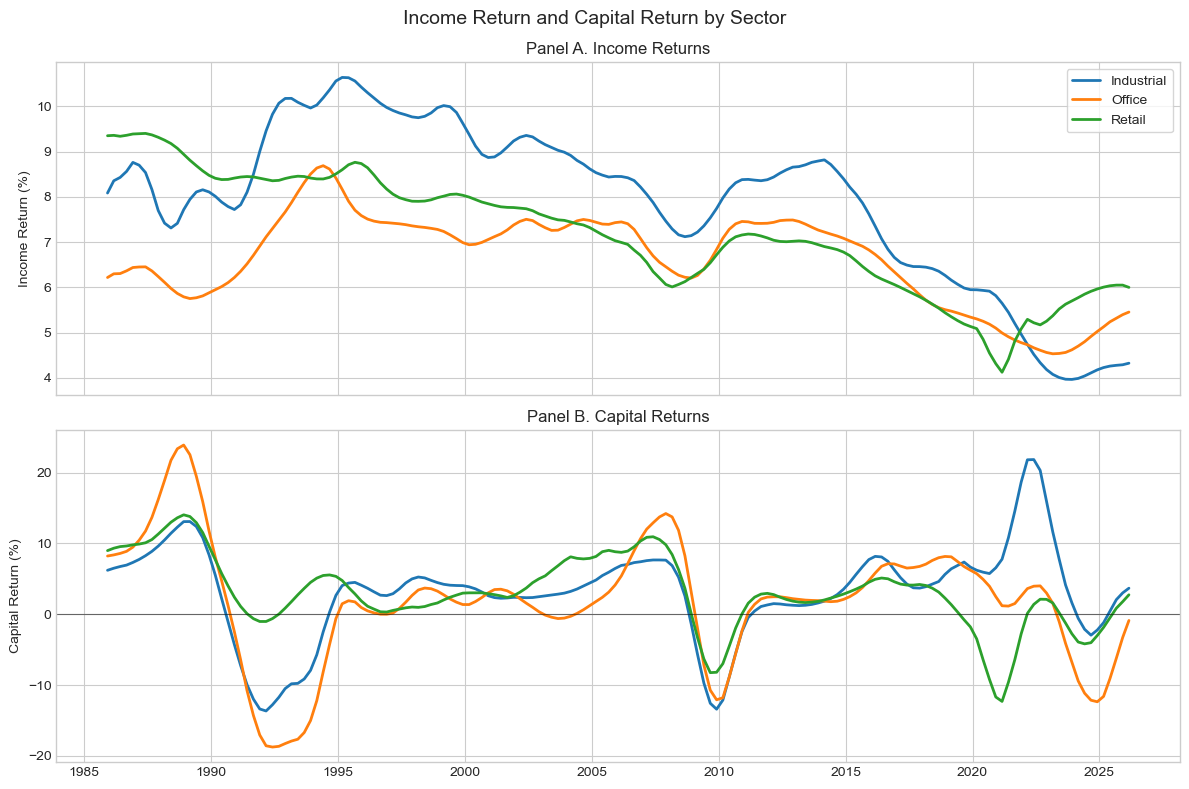

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Load Data
# -----------------------------
df = pd.read_excel("Final_Regression_Dataset.xlsx")

df["quarter_end"] = pd.to_datetime(df["quarter_end"])
df = df.sort_values(["sector", "quarter_end"]).copy()

# -----------------------------
# Style
# -----------------------------
plt.style.use("seaborn-v0_8-whitegrid")

sector_colors = {
    "Industrial": "#1f77b4",
    "Office": "#ff7f0e",
    "Retail": "#2ca02c"
}

# -----------------------------
# Rolling Series
# -----------------------------
df["total_return_roll4"] = (
    df.groupby("sector")["total_return"]
      .transform(lambda x: x.rolling(4, min_periods=1).mean())
)

df["income_return_roll4"] = (
    df.groupby("sector")["income_return"]
      .transform(lambda x: x.rolling(4, min_periods=1).mean())
)

df["capital_return_roll4"] = (
    df.groupby("sector")["capital_return"]
      .transform(lambda x: x.rolling(4, min_periods=1).mean())
)

# ====================================================
# FIGURE 2
# Four-Quarter Rolling Total Returns by Sector
# ====================================================

plt.figure(figsize=(12, 6))

for sector in ["Industrial", "Office", "Retail"]:
    d = df[df["sector"] == sector]

    plt.plot(
        d["quarter_end"],
        d["total_return_roll4"],
        linewidth=2,
        color=sector_colors[sector],
        label=sector
    )

plt.axhline(
    y=0,
    color="black",
    linewidth=0.8,
    alpha=0.5
)

plt.title("Four-Quarter Rolling Total Returns by Sector", fontsize=14)
plt.ylabel("Total Return (%)")
plt.xlabel("")
plt.legend(frameon=True)

plt.tight_layout()

plt.savefig(
    "Figure_2_Total_Returns_by_Sector.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ====================================================
# FIGURE 3
# Income Return and Capital Return by Sector
# ====================================================

fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 8),
    sharex=True
)

# Panel A
for sector in ["Industrial", "Office", "Retail"]:
    d = df[df["sector"] == sector]

    axes[0].plot(
        d["quarter_end"],
        d["income_return_roll4"],
        linewidth=2,
        color=sector_colors[sector],
        label=sector
    )

axes[0].set_title("Panel A. Income Returns")
axes[0].set_ylabel("Income Return (%)")
axes[0].legend(frameon=True)

# Panel B
for sector in ["Industrial", "Office", "Retail"]:
    d = df[df["sector"] == sector]

    axes[1].plot(
        d["quarter_end"],
        d["capital_return_roll4"],
        linewidth=2,
        color=sector_colors[sector]
    )

axes[1].axhline(
    y=0,
    color="black",
    linewidth=0.8,
    alpha=0.5
)

axes[1].set_title("Panel B. Capital Returns")
axes[1].set_ylabel("Capital Return (%)")

plt.suptitle(
    "Income Return and Capital Return by Sector",
    fontsize=14,
    y=0.98
)

plt.tight_layout()

plt.savefig(
    "Figure_3_Income_Capital_Returns.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ====================================================
# FIGURE 4
# 

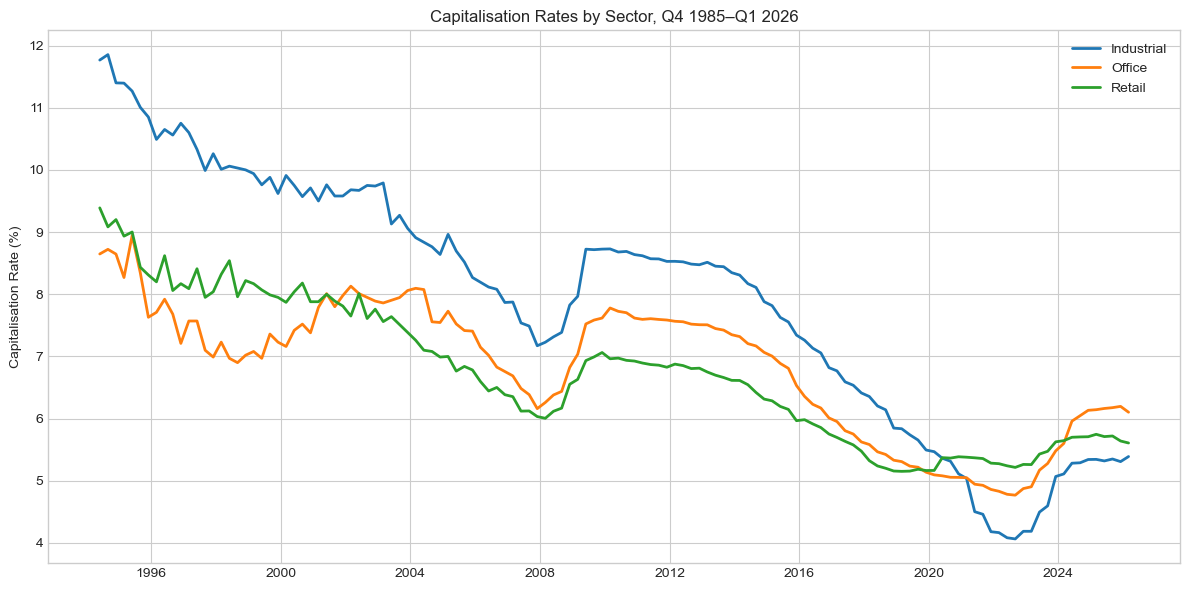

In [13]:
plt.figure(figsize=(12,6))

for sector in ["Industrial", "Office", "Retail"]:

    d = df[
        (df["sector"] == sector)
        & (df["cap_rate"].notna())
    ]

    plt.plot(
        d["quarter_end"],
        d["cap_rate"],
        linewidth=2,
        label=sector
    )

plt.title("Capitalisation Rates by Sector, Q4 1985–Q1 2026")
plt.ylabel("Capitalisation Rate (%)")
plt.xlabel("")
plt.legend()

plt.tight_layout()

plt.savefig(
    "Figure_4_Capitalisation_Rates_by_Sector.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

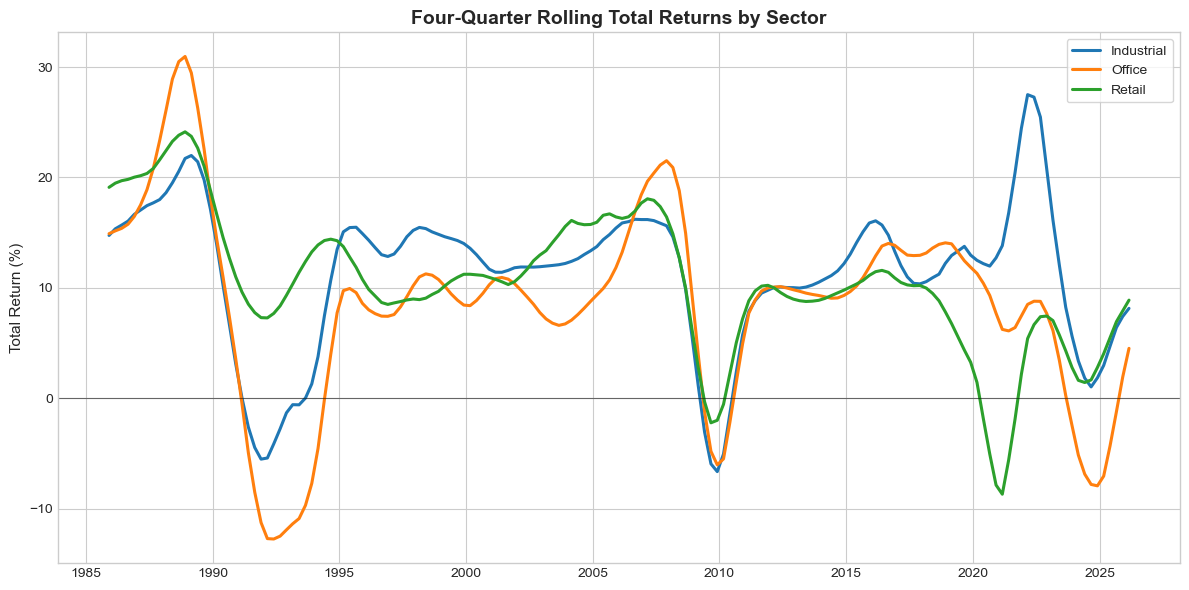

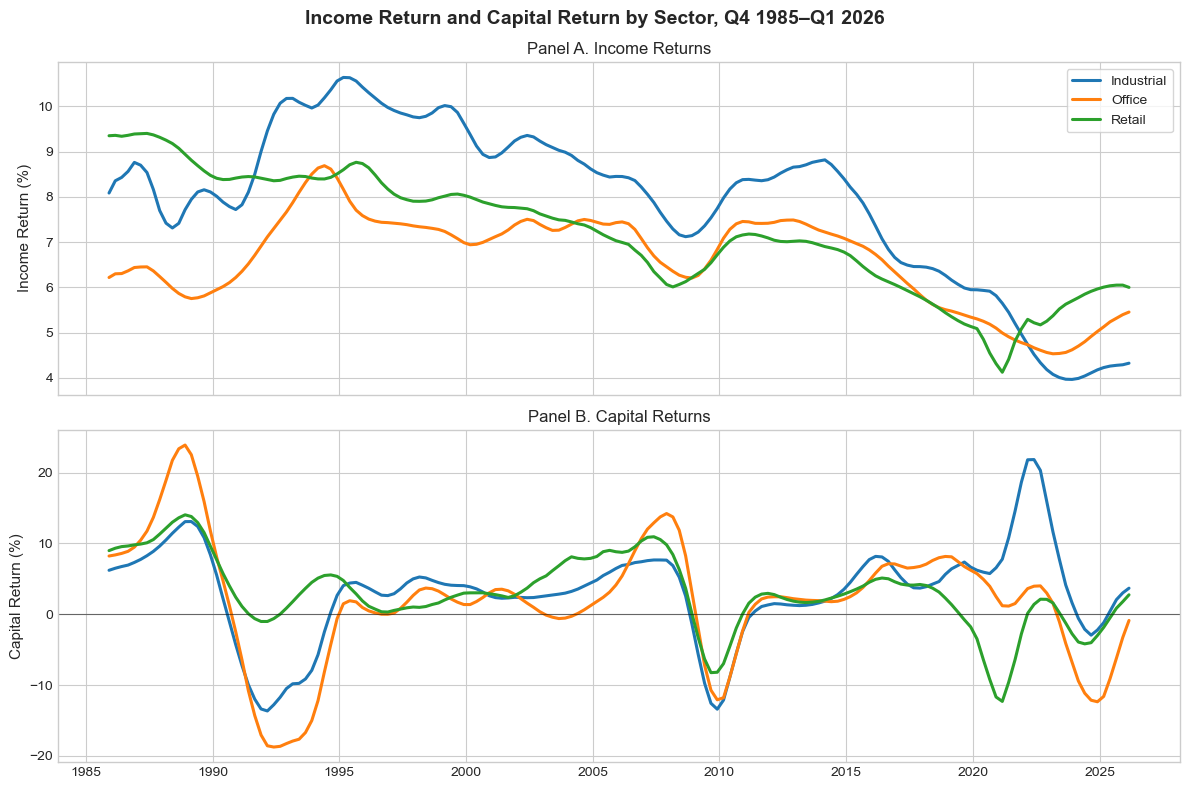

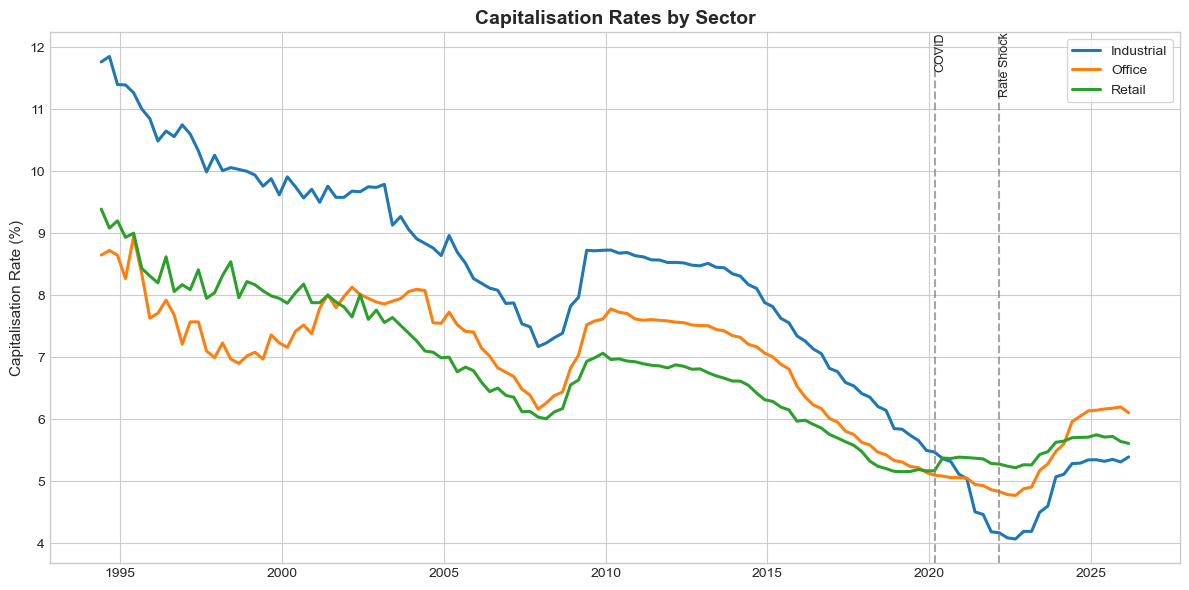

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --------------------------------------------------
# LOAD DATA
# --------------------------------------------------

df = pd.read_excel("Final_Regression_Dataset.xlsx")

df["quarter_end"] = pd.to_datetime(df["quarter_end"])
df = df.sort_values(["sector", "quarter_end"]).copy()

# --------------------------------------------------
# STYLE
# --------------------------------------------------

plt.style.use("seaborn-v0_8-whitegrid")

COLORS = {
    "Industrial": "#1f77b4",
    "Office": "#ff7f0e",
    "Retail": "#2ca02c"
}

# --------------------------------------------------
# ROLLING SERIES
# --------------------------------------------------

df["total_return_roll4"] = (
    df.groupby("sector")["total_return"]
      .transform(lambda x: x.rolling(4, min_periods=1).mean())
)

df["income_return_roll4"] = (
    df.groupby("sector")["income_return"]
      .transform(lambda x: x.rolling(4, min_periods=1).mean())
)

df["capital_return_roll4"] = (
    df.groupby("sector")["capital_return"]
      .transform(lambda x: x.rolling(4, min_periods=1).mean())
)

# --------------------------------------------------
# COMMON AXIS FORMATTING
# --------------------------------------------------

def format_dates(ax):
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="both", labelsize=10)

# ==================================================
# FIGURE 2
# ==================================================

fig, ax = plt.subplots(figsize=(12,6))

for sector in ["Industrial","Office","Retail"]:
    d = df[df["sector"] == sector]

    ax.plot(
        d["quarter_end"],
        d["total_return_roll4"],
        color=COLORS[sector],
        linewidth=2.2,
        label=sector
    )

ax.axhline(
    0,
    color="black",
    lw=0.8,
    alpha=0.5
)

ax.set_title(
    "Four-Quarter Rolling Total Returns by Sector",
    fontsize=14,
    fontweight="bold"
)

ax.set_ylabel("Total Return (%)", fontsize=11)

format_dates(ax)

ax.legend(
    frameon=True,
    fontsize=10
)

plt.tight_layout()

plt.savefig(
    "Figure_2_Total_Returns_by_Sector.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# ==================================================
# FIGURE 3
# ==================================================

fig, axes = plt.subplots(
    2,
    1,
    figsize=(12,8),
    sharex=True
)

# ---- Panel A

for sector in ["Industrial","Office","Retail"]:
    d = df[df["sector"] == sector]

    axes[0].plot(
        d["quarter_end"],
        d["income_return_roll4"],
        color=COLORS[sector],
        linewidth=2.2,
        label=sector
    )

axes[0].set_title(
    "Panel A. Income Returns",
    fontsize=12
)

axes[0].set_ylabel(
    "Income Return (%)",
    fontsize=11
)

axes[0].legend(
    frameon=True,
    fontsize=10
)

# ---- Panel B

for sector in ["Industrial","Office","Retail"]:
    d = df[df["sector"] == sector]

    axes[1].plot(
        d["quarter_end"],
        d["capital_return_roll4"],
        color=COLORS[sector],
        linewidth=2.2
    )

axes[1].axhline(
    0,
    color="black",
    lw=0.8,
    alpha=0.5
)

axes[1].set_title(
    "Panel B. Capital Returns",
    fontsize=12
)

axes[1].set_ylabel(
    "Capital Return (%)",
    fontsize=11
)

format_dates(axes[1])

fig.suptitle(
    "Income Return and Capital Return by Sector, Q4 1985–Q1 2026",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "Figure_3_Income_Capital_Returns.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# ==================================================
# FIGURE 4
# ==================================================

fig, ax = plt.subplots(figsize=(12,6))

for sector in ["Industrial","Office","Retail"]:

    d = df[
        (df["sector"] == sector)
        & (df["cap_rate"].notna())
    ]

    ax.plot(
        d["quarter_end"],
        d["cap_rate"],
        color=COLORS[sector],
        linewidth=2.2,
        label=sector
    )

# COVID marker
ax.axvline(
    pd.Timestamp("2020-03-01"),
    color="grey",
    linestyle="--",
    alpha=0.7
)

# Rate shock marker
ax.axvline(
    pd.Timestamp("2022-03-01"),
    color="grey",
    linestyle="--",
    alpha=0.7
)

ax.text(
    pd.Timestamp("2020-03-01"),
    ax.get_ylim()[1],
    "COVID",
    rotation=90,
    va="top",
    fontsize=9
)

ax.text(
    pd.Timestamp("2022-03-01"),
    ax.get_ylim()[1],
    "Rate Shock",
    rotation=90,
    va="top",
    fontsize=9
)

ax.set_title(
    "Capitalisation Rates by Sector",
    fontsize=14,
    fontweight="bold"
)

ax.set_ylabel(
    "Capitalisation Rate (%)",
    fontsize=11
)

format_dates(ax)

ax.legend(
    frameon=True,
    fontsize=10
)

plt.tight_layout()

plt.savefig(
    "Figure_4_Capitalisation_Rates_by_Sector.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ==================================================
# LOAD DATA
# ==================================================

df = pd.read_excel("Final_Regression_Dataset.xlsx")

df["quarter_end"] = pd.to_datetime(df["quarter_end"])
df = df.sort_values(["sector", "quarter_end"]).copy()

# ==================================================
# STYLE
# ==================================================

plt.style.use("seaborn-v0_8-whitegrid")

COLORS = {
    "Industrial": "#1f77b4",
    "Office": "#ff7f0e",
    "Retail": "#2ca02c"
}

# ==================================================
# ROLLING SERIES
# ==================================================

df["total_return_roll4"] = (
    df.groupby("sector")["total_return"]
      .transform(lambda x: x.rolling(4, min_periods=1).mean())
)

df["income_return_roll4"] = (
    df.groupby("sector")["income_return"]
      .transform(lambda x: x.rolling(4, min_periods=1).mean())
)

df["capital_return_roll4"] = (
    df.groupby("sector")["capital_return"]
      .transform(lambda x: x.rolling(4, min_periods=1).mean())
)

# ==================================================
# COMMON DATE FORMAT
# ==================================================

def format_dates(ax):
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="both", labelsize=10)

# ==================================================
# FIGURE 2
# Four-Quarter Rolling Total Returns
# ==================================================

fig, ax = plt.subplots(figsize=(12, 6))

for sector in ["Industrial", "Office", "Retail"]:
    d = df[df["sector"] == sector]

    ax.plot(
        d["quarter_end"],
        d["total_return_roll4"],
        color=COLORS[sector],
        linewidth=2.2,
        label=sector
    )

ax.axhline(
    y=0,
    color="black",
    linewidth=0.8,
    alpha=0.5
)

ax.set_title(
    "Four-Quarter Rolling Total Returns by Sector",
    fontsize=14,
    fontweight="bold"
)

ax.set_ylabel("Total Return (%)", fontsize=11)

format_dates(ax)

ax.legend(frameon=True)

plt.tight_layout()

plt.savefig(
    "Figure_2_Total_Returns_by_Sector.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

# ==================================================
# FIGURE 3
# Income Return and Capital Return
# ==================================================

fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 9),  # increased height
    sharex=True
)

# Panel A: Income Returns
for sector in ["Industrial", "Office", "Retail"]:
    d = df[df["sector"] == sector]

    axes[0].plot(
        d["quarter_end"],
        d["income_return_roll4"],
        color=COLORS[sector],
        linewidth=2.2,
        label=sector
    )

axes[0].set_title(
    "Panel A. Income Returns",
    fontsize=12
)

axes[0].set_ylabel(
    "Income Return (%)",
    fontsize=11
)

axes[0].legend(frameon=True)

# Panel B: Capital Returns
for sector in ["Industrial", "Office", "Retail"]:
    d = df[df["sector"] == sector]

    axes[1].plot(
        d["quarter_end"],
        d["capital_return_roll4"],
        color=COLORS[sector],
        linewidth=2.2
    )

axes[1].axhline(
    y=0,
    color="black",
    linewidth=0.8,
    alpha=0.5
)

axes[1].set_title(
    "Panel B. Capital Returns",
    fontsize=12
)

axes[1].set_ylabel(
    "Capital Return (%)",
 

_IncompleteInputError: incomplete input (1879487432.py, line 163)

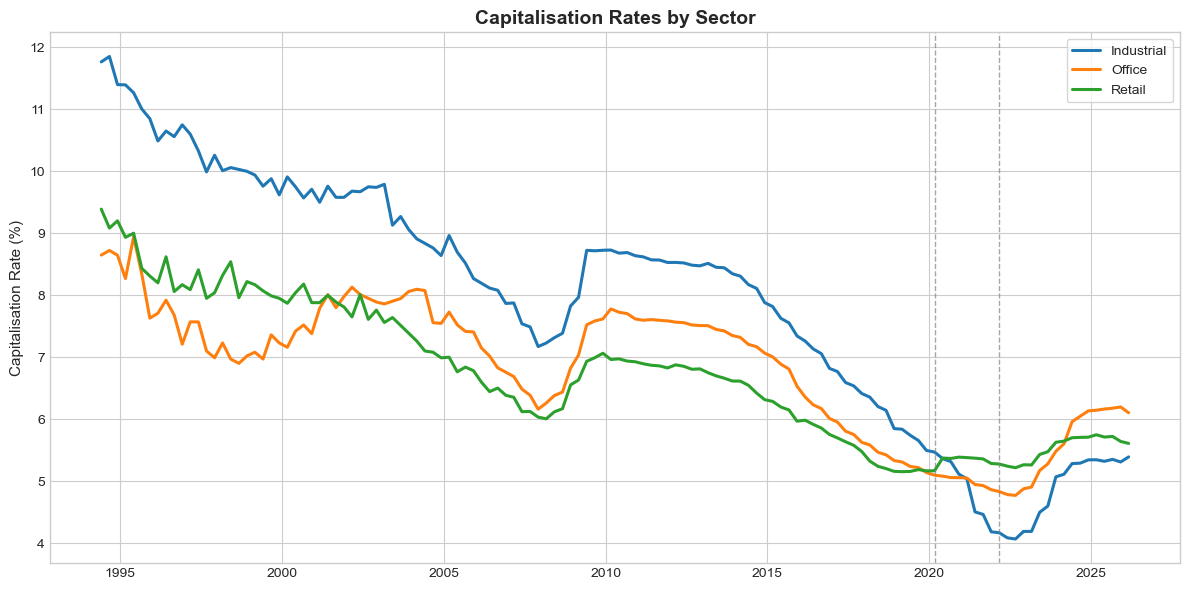

In [16]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")

COLORS = {
    "Industrial": "#1f77b4",
    "Office": "#ff7f0e",
    "Retail": "#2ca02c"
}

fig, ax = plt.subplots(figsize=(12, 6))

for sector in ["Industrial", "Office", "Retail"]:

    d = df[
        (df["sector"] == sector)
        & (df["cap_rate"].notna())
    ]

    ax.plot(
        d["quarter_end"],
        d["cap_rate"],
        color=COLORS[sector],
        linewidth=2.2,
        label=sector
    )

# COVID marker
ax.axvline(
    pd.Timestamp("2020-03-01"),
    color="grey",
    linestyle="--",
    linewidth=1,
    alpha=0.7
)

# Rate Shock marker
ax.axvline(
    pd.Timestamp("2022-03-01"),
    color="grey",
    linestyle="--",
    linewidth=1,
    alpha=0.7
)

ax.set_title(
    "Capitalisation Rates by Sector",
    fontsize=14,
    fontweight="bold"
)

ax.set_ylabel(
    "Capitalisation Rate (%)",
    fontsize=11
)

ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.legend(frameon=True)

plt.tight_layout()

plt.savefig(
    "Figure_4_Capitalisation_Rates_by_Sector.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

KeyError: 'sector'

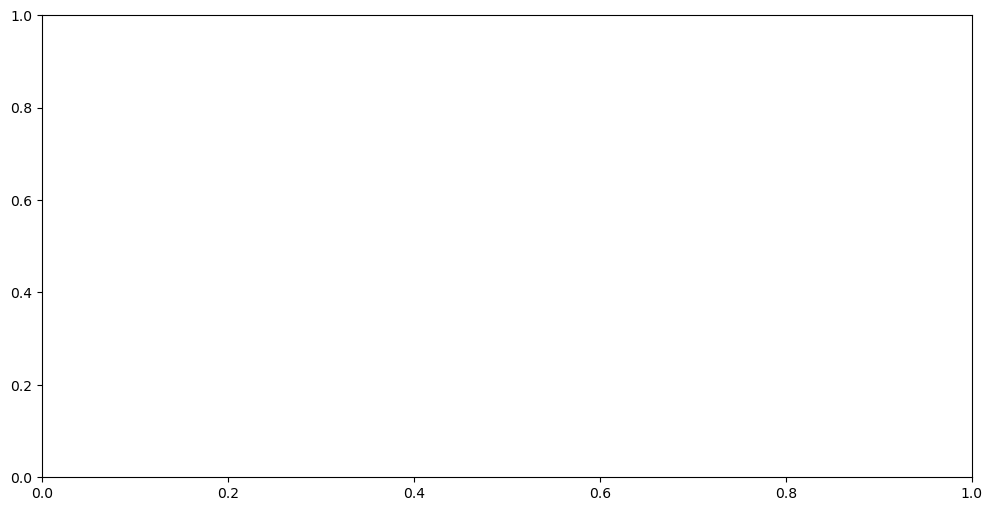

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

# =====================================================
# SETUP
# =====================================================

OUTPUT_DIR = Path("Dissertation_Figures")
OUTPUT_DIR.mkdir(exist_ok=True)

plt.style.use("default")

COLORS = {
    "Industrial": "#1f77b4",
    "Office": "#ff7f0e",
    "Retail": "#2ca02c"
}

# =====================================================
# LOAD DATA
# =====================================================

df = pd.read_excel("Final_Regression_Dataset.xlsx")

df["quarter_end"] = pd.to_datetime(df["quarter_end"])

df = df.sort_values(
    ["sector", "quarter_end"]
).copy()

# =====================================================
# HELPER FUNCTIONS
# =====================================================

def format_dates(ax):
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="both", labelsize=10)

def save_current_figure(filename):
    plt.savefig(
        OUTPUT_DIR / filename,
        dpi=600,
        bbox_inches="tight",
        facecolor="white"
    )

# =====================================================
# ROLLING SERIES
# =====================================================

df["total_return_roll4"] = (
    df.groupby("sector")["total_return"]
      .transform(lambda x: x.rolling(4, min_periods=1).mean())
)

df["income_return_roll4"] = (
    df.groupby("sector")["income_return"]
      .transform(lambda x: x.rolling(4, min_periods=1).mean())
)

df["capital_return_roll4"] = (
    df.groupby("sector")["capital_return"]
      .transform(lambda x: x.rolling(4, min_periods=1).mean())
)

# =====================================================
# FIGURE 1
# Benchmark Weights
# =====================================================

weights = pd.read_csv("benchmark_weights_quarterly.csv")

weights["quarter_end"] = pd.to_datetime(weights["quarter_end"])

fig, ax = plt.subplots(figsize=(12, 6))

for sector in ["Industrial", "Office", "Retail"]:
    d = weights[weights["sector"] == sector]

    ax.plot(
        d["quarter_end"],
        d["weight"],
        linewidth=2.2,
        color=COLORS[sector],
        label=sector
    )

ax.set_title(
    "Evolution of Sector Weights in the MSCI Australia All Property Index",
    fontsize=14,
    fontweight="bold"
)

ax.set_ylabel("Benchmark Weight (%)")

format_dates(ax)
ax.legend(frameon=True)

plt.tight_layout()

save_current_figure("Figure_1_Benchmark_Weights.png")
plt.show()

# =====================================================
# FIGURE 2
# Rolling Total Returns
# =====================================================

fig, ax = plt.subplots(figsize=(12, 6))

for sector in ["Industrial", "Office", "Retail"]:

    d = df[df["sector"] == sector]

    ax.plot(
        d["quarter_end"],
        d["total_return_roll4"],
        linewidth=2.2,
        color=COLORS[sector],
        label=sector
    )

ax.axhline(
    0,
    color="black",
    linewidth=0.8,
    alpha=0.5
)

ax.set_title(
    "Four-Quarter Rolling Total Returns by Sector",
    fontsize=14,
    fontweight="bold"
)

ax.set_ylabel("Total Return (%)")

format_dates(ax)

ax.legend(frameon=True)

plt.tight_layout()

save_current_figure("Figure_2_Total_Returns.png")
plt.show()

# =====================================================
# FIGURE 3
# Income & Capital Returns
# =====================================================

fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 9),
    sharex=True
)

# ---- PANEL A

for sector in ["Industrial", "Office", "Retail"]:

    d = df[df["sector"] == sector]

    axes[0].plot(
        d["quarter_end"],
        d["income_return_roll4"],
        linewidth=2.2,
        color=COLORS[sector],
        label=sector
    )

axes[0].set_title(
    "Panel A. Income Returns",
    fontsize=12
)

axes[0].set_ylabel("Income Return (%)")

axes[0].legend(frameon=True)

# ---- PANEL B

for sector in ["Industrial", "Office", "Retail"]:

    d = df[df["sector"] == sector]

    axes[1].plot(
        d["quarter_end"],
        d["capital_return_roll4"],
        linewidth=2.2,
        color=COLORS[sector]
    )

axes[1].axhline(
    0,
    color="black",
    linewidth=0.8,
    alpha=0.5
)

axes[1].set_title(
    "Panel B. Capital Returns",
    fontsize=12
)

axes[1].set_ylabel("Capital Return (%)")

format_dates(axes[1])

fig.suptitle(
    "Income Return and Capital Return by Sector",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

save_current_figure("Figure_3_Income_Capital_Returns.png")
plt.show()

# =====================================================
# FIGURE 4
# Capitalisation Rates
# =====================================================

fig, ax = plt.subplots(figsize=(12, 6))

for sector in ["Industrial", "Office", "Retail"]:

    d = df[
        (df["sector"] == sector)
        & (df["cap_rate"].notna())
    ]

    ax.plot(
        d["quarter_end"],
        d["cap_rate"],
        linewidth=2.2,
        color=COLORS[sector],
        label=sector
    )

# COVID
ax.axvline(
    pd.Timestamp("2020-03-01"),
    color="grey",
    linestyle="--",
    linewidth=1,
    alpha=0.6
)

# Rate Shock
ax.axvline(
    pd.Timestamp("2022-03-01"),
    color="grey",
    linestyle="--",
    linewidth=1,
    alpha=0.6
)

ax.set_title(
    "Capitalisation Rates by Sector",
    fontsize=14,
    fontweight="bold"
)

ax.set_ylabel(
    "Capitalisation Rate (%)"
)

format_dates(ax)

ax.legend(frameon=True)

plt.tight_layout()

save_current_figure("Figure_4_Capitalisation_Rates.png")
plt.show()

# =====================================================
# SUMMARY
# =====================================================

print("\nSaved files:")
for f in OUTPUT_DIR.iterdir():
    print(f.name)

In [18]:
import os

files = [
    "Figure_2_Total_Returns_by_Sector.png",
    "Figure_3_Income_Capital_Returns.png",
    "Figure_4_Capitalisation_Rates_by_Sector.png"
]

print("Saved figures:")
for f in files:
    if os.path.exists(f):
        print("✓", f)
    else:
        print("✗", f)

Saved figures:
✓ Figure_2_Total_Returns_by_Sector.png
✓ Figure_3_Income_Capital_Returns.png
✓ Figure_4_Capitalisation_Rates_by_Sector.png


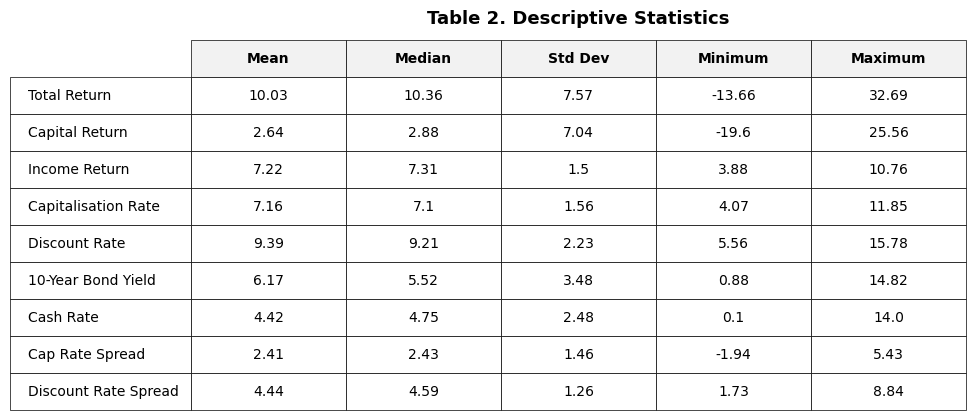

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------
# Load Data
# -------------------------------------------

df = pd.read_excel("Final_Regression_Dataset.xlsx")

variables = [
    "total_return",
    "capital_return",
    "income_return",
    "cap_rate",
    "discount_rate",
    "bond_10y",
    "cash_rate",
    "cap_rate_spread_bond",
    "discount_rate_spread_bond"
]

labels = {
    "total_return": "Total Return",
    "capital_return": "Capital Return",
    "income_return": "Income Return",
    "cap_rate": "Capitalisation Rate",
    "discount_rate": "Discount Rate",
    "bond_10y": "10-Year Bond Yield",
    "cash_rate": "Cash Rate",
    "cap_rate_spread_bond": "Cap Rate Spread",
    "discount_rate_spread_bond": "Discount Rate Spread"
}

# -------------------------------------------
# Summary Statistics
# -------------------------------------------

stats = pd.DataFrame({
    "Mean": df[variables].mean(),
    "Median": df[variables].median(),
    "Std Dev": df[variables].std(),
    "Minimum": df[variables].min(),
    "Maximum": df[variables].max()
}).round(2)

stats.index = [labels[x] for x in stats.index]

# -------------------------------------------
# Create Table
# -------------------------------------------

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.axis("off")

table = ax.table(
    cellText=stats.values,
    rowLabels=stats.index,
    colLabels=stats.columns,
    cellLoc="center",
    rowLoc="left",
    bbox=[0, 0, 1, 1]
)

table.auto_set_font_size(False)
table.set_fontsize(10)

# Style
for (r, c), cell in table.get_celld().items():

    cell.set_edgecolor("black")
    cell.set_linewidth(0.5)

    if r == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#F2F2F2")

plt.title(
    "Table 2. Descriptive Statistics",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.savefig(
    "Table_2_Descriptive_Statistics_Final.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

NameError: name 'regime_characteristics' is not defined

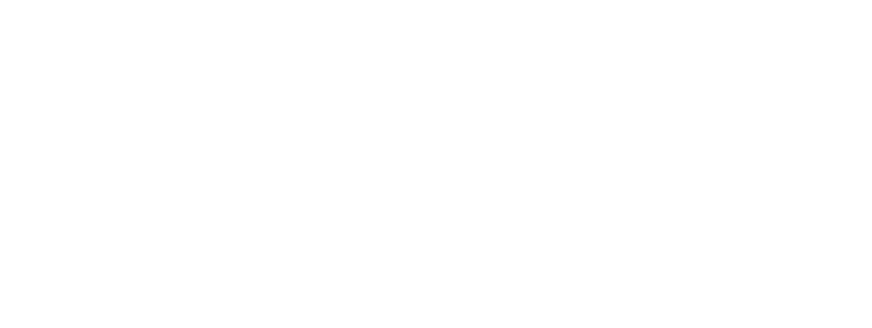

In [20]:
fig, ax = plt.subplots(figsize=(11,4))
ax.axis("off")

table = ax.table(
    cellText=regime_characteristics.values,
    rowLabels=regime_characteristics.index,
    colLabels=regime_characteristics.columns,
    cellLoc="center",
    rowLoc="left",
    bbox=[0,0,1,1]
)

table.auto_set_font_size(False)
table.set_fontsize(10)

for (r,c), cell in table.get_celld().items():

    cell.set_edgecolor("black")
    cell.set_linewidth(0.5)

    if r == 0:
        cell.set_facecolor("#F2F2F2")
        cell.set_text_props(weight="bold")

plt.title(
    "Table 5. Economic Regime Characteristics",
    fontsize=13,
    fontweight="bold"
)

plt.savefig(
    "Table_5_Economic_Regime_Characteristics_Final.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [21]:
import pandas as pd

regime_characteristics = pd.read_excel(
    "Table_5_Economic_Regime_Characteristics.xlsx"
)

display(regime_characteristics.head())

print(regime_characteristics.columns.tolist())

,regime,cash_rate,bond_10y,cap_rate,discount_rate,cap_rate_spread_bond,discount_rate_spread_bond
0,COVID,0.21,1.20,5.09,6.34,3.89,5.14
1,GFC & Recovery,4.54,4.90,7.48,9.19,2.59,4.29
2,Low-Rate Expansion,1.89,2.75,6.42,7.95,3.67,5.20
3,Pre-GFC Expansion,6.14,8.39,8.29,11.21,1.82,4.55
4,Rate Shock,3.37,3.98,5.32,6.61,1.34,2.63


['regime', 'cash_rate', 'bond_10y', 'cap_rate', 'discount_rate', 'cap_rate_spread_bond', 'discount_rate_spread_bond']


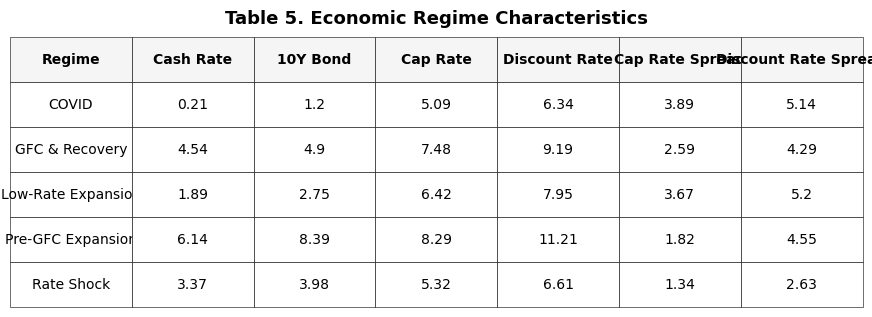

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# Load table
regime_characteristics = pd.read_excel(
    "Table_5_Economic_Regime_Characteristics.xlsx"
)

# Format numbers
display_df = regime_characteristics.copy()

for col in display_df.columns[1:]:
    display_df[col] = display_df[col].round(2)

# Create figure
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.axis("off")

table = ax.table(
    cellText=display_df.values,
    colLabels=[
        "Regime",
        "Cash Rate",
        "10Y Bond",
        "Cap Rate",
        "Discount Rate",
        "Cap Rate Spread",
        "Discount Rate Spread"
    ],
    cellLoc="center",
    bbox=[0, 0, 1, 1]
)

table.auto_set_font_size(False)
table.set_fontsize(10)

# Journal-style formatting
for (r, c), cell in table.get_celld().items():

    cell.set_linewidth(0.4)
    cell.set_edgecolor("black")

    if r == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#F5F5F5")

plt.title(
    "Table 5. Economic Regime Characteristics",
    fontsize=13,
    fontweight="bold",
    pad=10
)

plt.savefig(
    "Table_5_Economic_Regime_Characteristics_Final.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

heatmap_data = pd.DataFrame(
    {
        "Pre-GFC Expansion":[0.70,-1.73,2.57],
        "GFC and Recovery":[-0.90,-0.18,0.33],
        "Low-Rate Expansion":[1.86,1.26,-1.78],
        "COVID":[12.87,1.86,-8.55],
        "Rate Shock":[5.07,-3.64,1.68]
    },
    index=["Industrial","Office","Retail"]
)

# Put regimes in chronological order
heatmap_data = heatmap_data[
    [
        "Pre-GFC Expansion",
        "GFC and Recovery",
        "Low-Rate Expansion",
        "COVID",
        "Rate Shock"
    ]
]

plt.figure(figsize=(10,5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.7,
    linecolor="white",
    annot_kws={
        "fontsize":11,
        "fontweight":"bold"
    },
    cbar_kws={
        "label":"Mean Excess Return (%)"
    }
)

plt.title(
    "Mean Sector Excess Returns by Economic Regime",
    fontsize=13,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("")

plt.tight_layout()

plt.savefig(
    "Figure_5_Heatmap.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

ModuleNotFoundError: No module named 'seaborn'

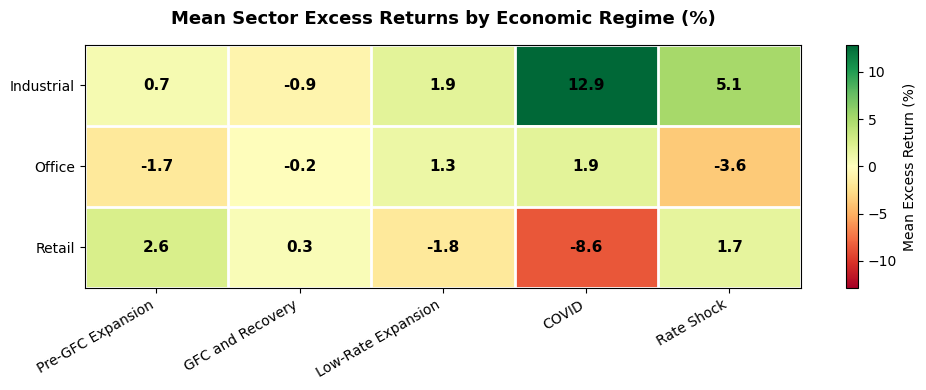

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --------------------------
# Data
# --------------------------

heatmap_data = pd.DataFrame(
    {
        "Pre-GFC Expansion": [0.70, -1.73, 2.57],
        "GFC and Recovery": [-0.90, -0.18, 0.33],
        "Low-Rate Expansion": [1.86, 1.26, -1.78],
        "COVID": [12.87, 1.86, -8.55],
        "Rate Shock": [5.07, -3.64, 1.68]
    },
    index=["Industrial", "Office", "Retail"]
)

# --------------------------
# Plot
# --------------------------

fig, ax = plt.subplots(figsize=(10, 4))

# Center colour scale around zero
max_abs = np.abs(heatmap_data.values).max()

im = ax.imshow(
    heatmap_data,
    cmap="RdYlGn",
    vmin=-max_abs,
    vmax=max_abs,
    aspect="auto"
)

# Labels
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(
    heatmap_data.columns,
    rotation=30,
    ha="right"
)

ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

# Cell values
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        value = heatmap_data.iloc[i, j]

        ax.text(
            j,
            i,
            f"{value:.1f}",
            ha="center",
            va="center",
            fontsize=11,
            fontweight="bold",
            color="black"
        )

# White grid lines
ax.set_xticks(np.arange(-.5, len(heatmap_data.columns), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(heatmap_data.index), 1), minor=True)

ax.grid(
    which="minor",
    color="white",
    linestyle="-",
    linewidth=2
)

ax.tick_params(which="minor", bottom=False, left=False)

# Title
ax.set_title(
    "Mean Sector Excess Returns by Economic Regime (%)",
    fontsize=13,
    fontweight="bold",
    pad=15
)

# Colour bar
cbar = fig.colorbar(im)
cbar.set_label("Mean Excess Return (%)")

plt.tight_layout()

plt.savefig(
    "Figure_5_Heatmap_Improved.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [1]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(df['Date'], df['Industrial_CapRate'],
        label='Industrial Cap Rate', linewidth=2)

ax.plot(df['Date'], df['Office_CapRate'],
        label='Office Cap Rate', linewidth=2)

ax.plot(df['Date'], df['Retail_CapRate'],
        label='Retail Cap Rate', linewidth=2)

ax.plot(df['Date'], df['Bond_10Y'],
        label='10-Year Bond Yield',
        linewidth=2,
        linestyle='--',
        color='black')

ax.set_title(
    'Capitalisation Rates and Australian 10-Year Government Bond Yield, Q4 1985–Q1 2026'
)

ax.set_ylabel('Percent (%)')
ax.legend(frameon=False)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

In [2]:
import pandas as pd
import matplotlib.pyplot as plt


NameError: name 'df' is not defined

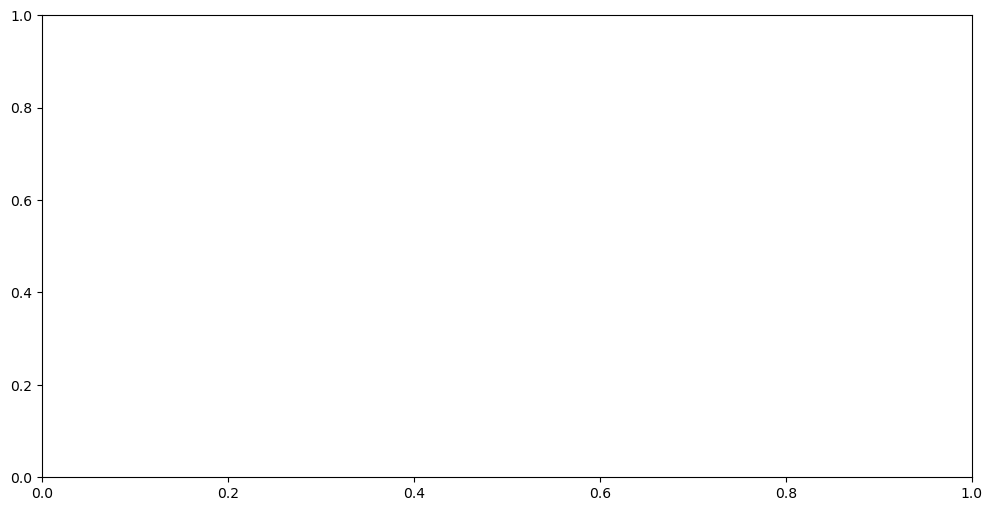

In [3]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(df['Date'], df['Industrial_CapRate'],
        label='Industrial Cap Rate', linewidth=2)

ax.plot(df['Date'], df['Office_CapRate'],
        label='Office Cap Rate', linewidth=2)

ax.plot(df['Date'], df['Retail_CapRate'],
        label='Retail Cap Rate', linewidth=2)

ax.plot(df['Date'], df['Bond_10Y'],
        label='10-Year Bond Yield',
        linewidth=2,
        linestyle='--',
        color='black')

ax.set_title(
    'Capitalisation Rates and Australian 10-Year Government Bond Yield, Q4 1985–Q1 2026'
)

ax.set_ylabel('Percent (%)')
ax.legend(frameon=False)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
df.columns.tolist()

NameError: name 'df' is not defined

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("your_data.xlsx")

print(df.columns.tolist())


FileNotFoundError: [Errno 2] No such file or directory: 'your_data.xlsx'

In [6]:
import os

for file in os.listdir():
    print(file)

.anaconda
.conda
.ipynb_checkpoints
.ipython
.jupyter
.matplotlib
.ms-ad
3D Objects
Air NZ Returns.xlsx
Anixemenes Vintage 2026.xlsx
AppData
Application Data
Aramco Data Book 1Q26.xlsx
aramco_prices.xlsx
Aware Real Estate
A_REIT_2016_2025_monthly_total_returns_survivorship_free.csv
benchmark_methodology_correlations.csv
benchmark_returns.csv
benchmark_weights_annual.csv
benchmark_weights_quarterly.csv
Contacts
Cookies
Correlation_Matrix.xlsx
Data Preparation Research Report.ipynb
Dissertation_Figures
Documents
Downloads
dynamic_erp_wacc_inputs.xlsx
equal_weight_benchmark.csv
equal_weight_excess_returns.csv
excess_return_comparison_table.csv
f01hist (2).xlsx
f02hist.xlsx
f02histhist.xls
Favorites
Figure_1_Benchmark_Evolution.png
Figure_2_Mean_Excess_Returns_by_Regime.png
Figure_2_Total_Returns_by_Sector.png
Figure_3_Income_Capital_Returns.png
Figure_4_Capitalisation_Rates_by_Sector.png
Figure_5_Heatmap_Improved.png
Figure_Excess_Return_Heatmap_Chronological.png
Final Research Report.ipy

In [7]:
import pandas as pd

df = pd.read_excel("Final_Regression_Dataset.xlsx")

print(df.columns.tolist())

['quarter_end', 'sector', 'total_return', 'capital_return', 'income_return', 'capital_value_m', 'num_investments', 'cap_rate', 'discount_rate', 'year', 'quarter', 'quarter_label', 'cap_rate_spread', 'capital_value_growth_qoq', 'capital_value_growth_yoy', 'investment_growth_yoy', 'log_capital_value', 'return_check', 'return_difference', 'return_check_geometric', 'return_difference_geometric', 'cash_rate', 'bond_10y', 'cap_rate_spread_bond', 'discount_rate_spread_bond', 'excess_return', 'ER_L1']


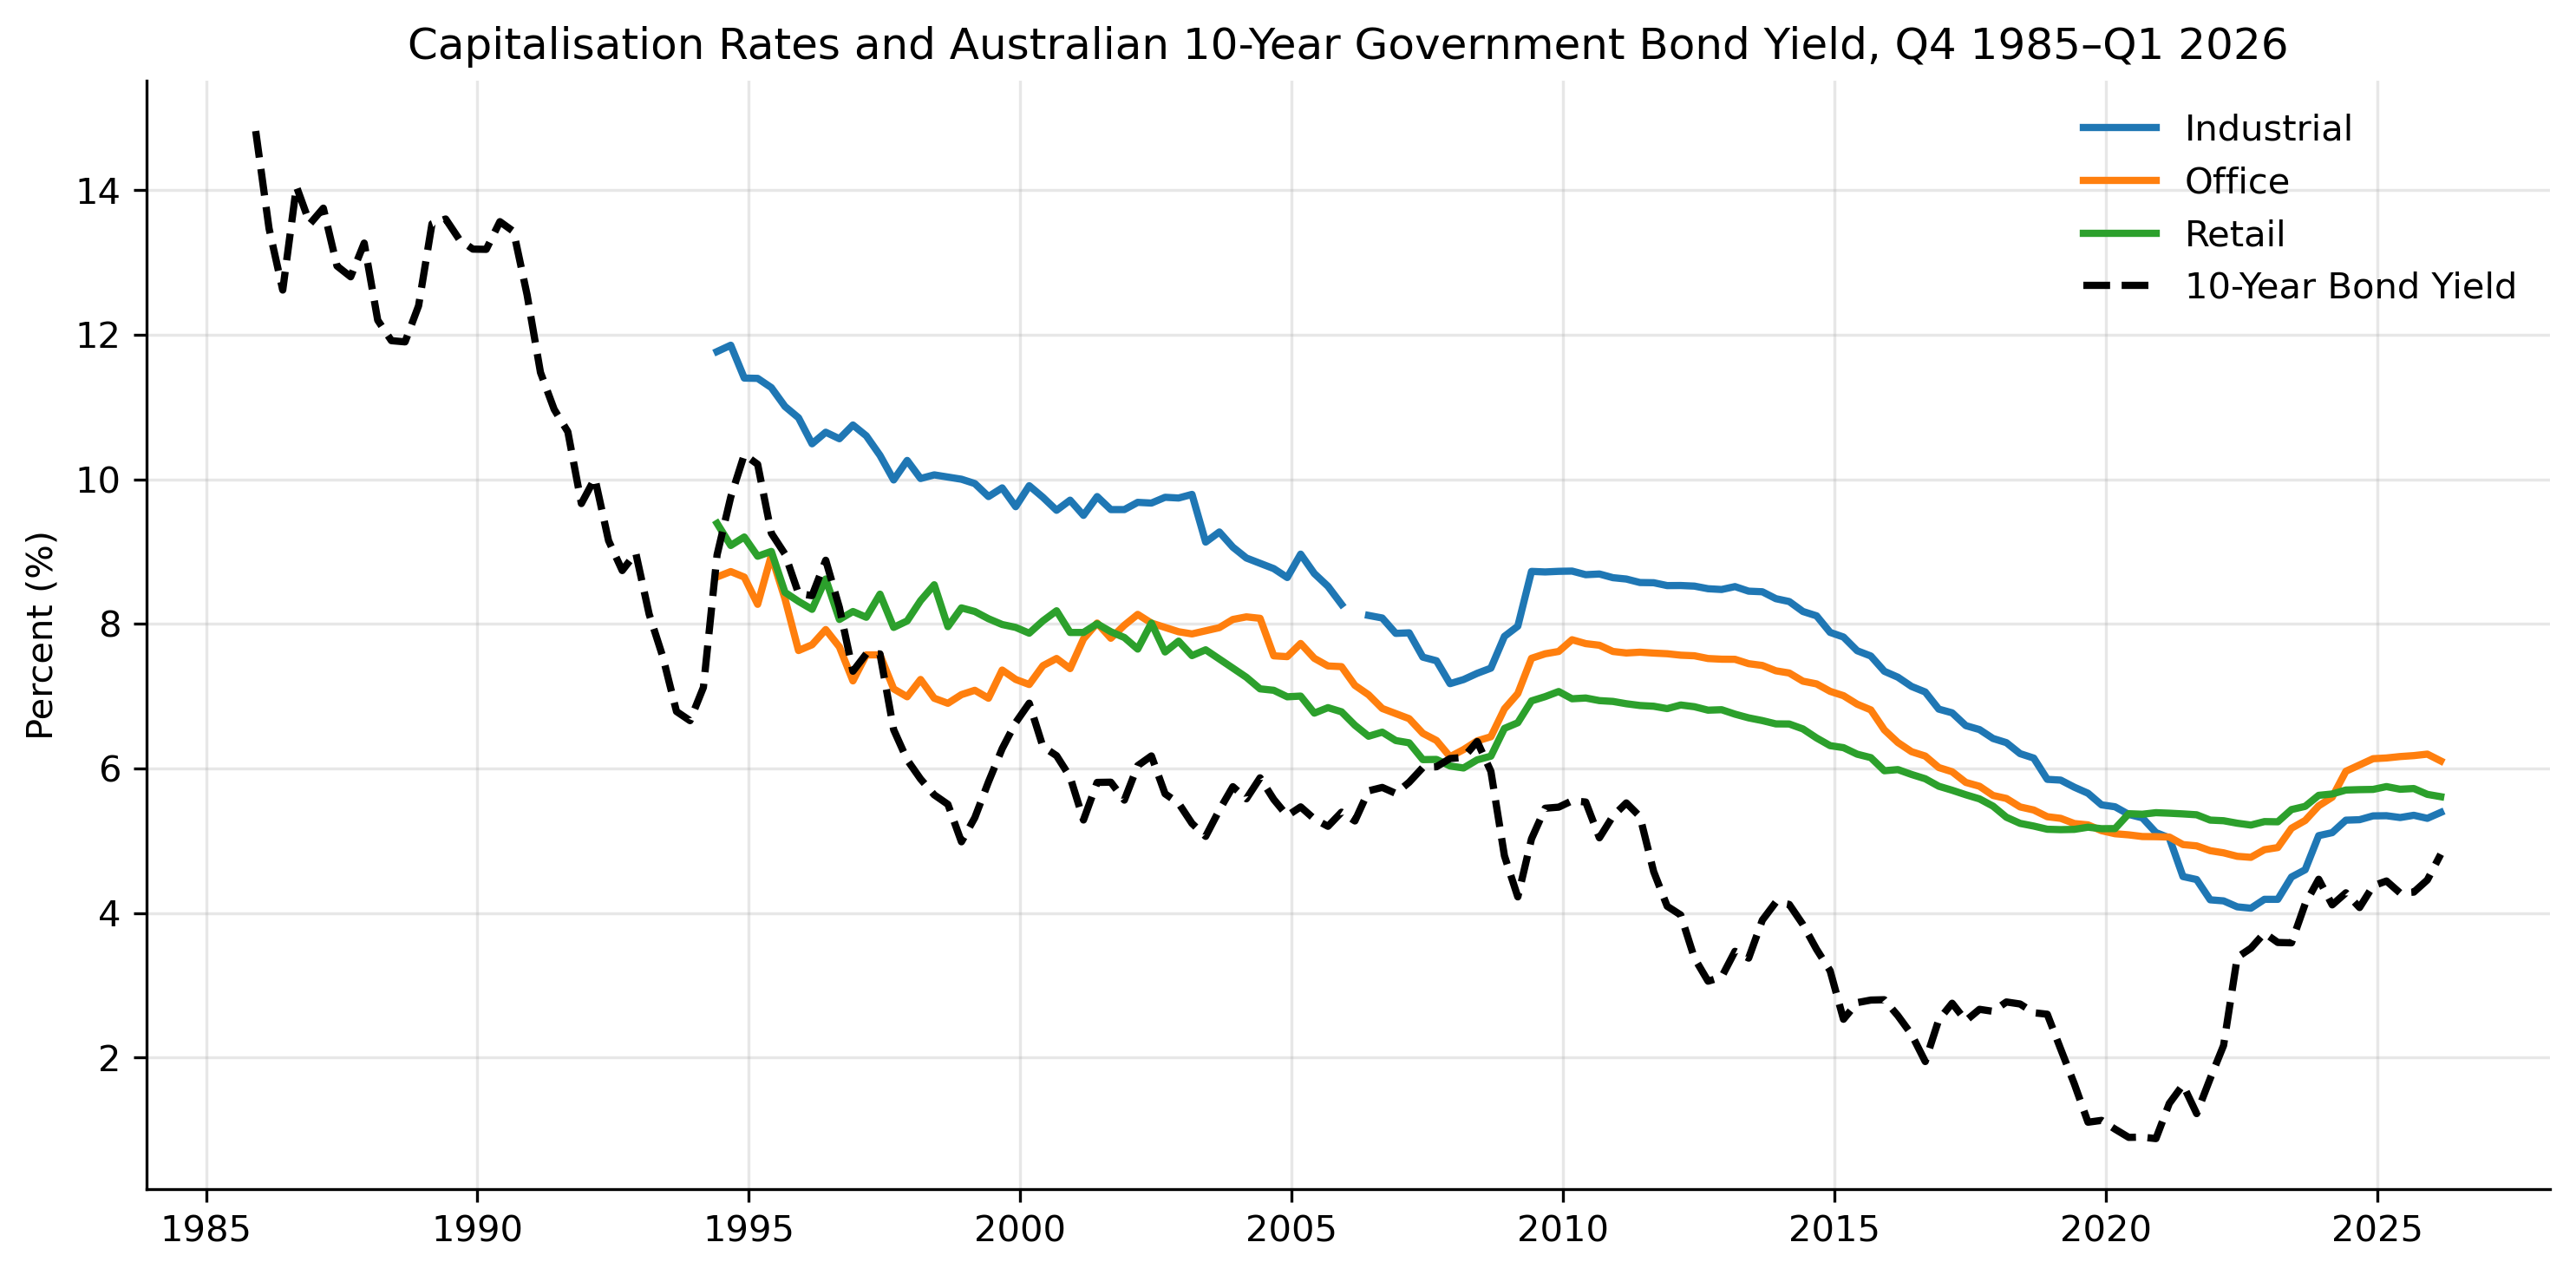

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Create separate series for each sector
pivot = df.pivot(
    index='quarter_end',
    columns='sector',
    values='cap_rate'
)

# Ensure dates are datetime
pivot.index = pd.to_datetime(pivot.index)

# Bond yield series (same for all sectors each quarter)
bond = (
    df.groupby('quarter_end')['bond_10y']
    .first()
)

bond.index = pd.to_datetime(bond.index)

# Plot
fig, ax = plt.subplots(figsize=(10, 5), dpi=300)

for sector in pivot.columns:
    ax.plot(
        pivot.index,
        pivot[sector],
        linewidth=2,
        label=sector.title()
    )

ax.plot(
    bond.index,
    bond.values,
    color='black',
    linestyle='--',
    linewidth=2,
    label='10-Year Bond Yield'
)

ax.set_title(
    'Capitalisation Rates and Australian 10-Year Government Bond Yield, Q4 1985–Q1 2026',
    fontsize=12
)

ax.set_ylabel('Percent (%)')
ax.set_xlabel('')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(alpha=0.3)
ax.legend(frameon=False)

plt.tight_layout()

plt.savefig(
    'Figure_5_Cap_Rates_vs_Bond_Yield.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [9]:
ax.axvspan(pd.Timestamp('2008-01-01'),
           pd.Timestamp('2012-12-31'),
           color='grey',
           alpha=0.08)

ax.axvspan(pd.Timestamp('2020-01-01'),
           pd.Timestamp('2021-12-31'),
           color='blue',
           alpha=0.05)

ax.axvspan(pd.Timestamp('2022-01-01'),
           pd.Timestamp('2026-03-31'),
           color='red',
           alpha=0.05)

In [10]:
# GFC & Recovery
ax.axvspan(
    pd.Timestamp('2008-01-01'),
    pd.Timestamp('2012-12-31'),
    color='grey',
    alpha=0.08,
    zorder=0
)

# COVID
ax.axvspan(
    pd.Timestamp('2020-01-01'),
    pd.Timestamp('2021-12-31'),
    color='steelblue',
    alpha=0.06,
    zorder=0
)

# Rate Shock
ax.axvspan(
    pd.Timestamp('2022-01-01'),
    pd.Timestamp('2026-03-31'),
    color='indianred',
    alpha=0.06,
    zorder=0
)

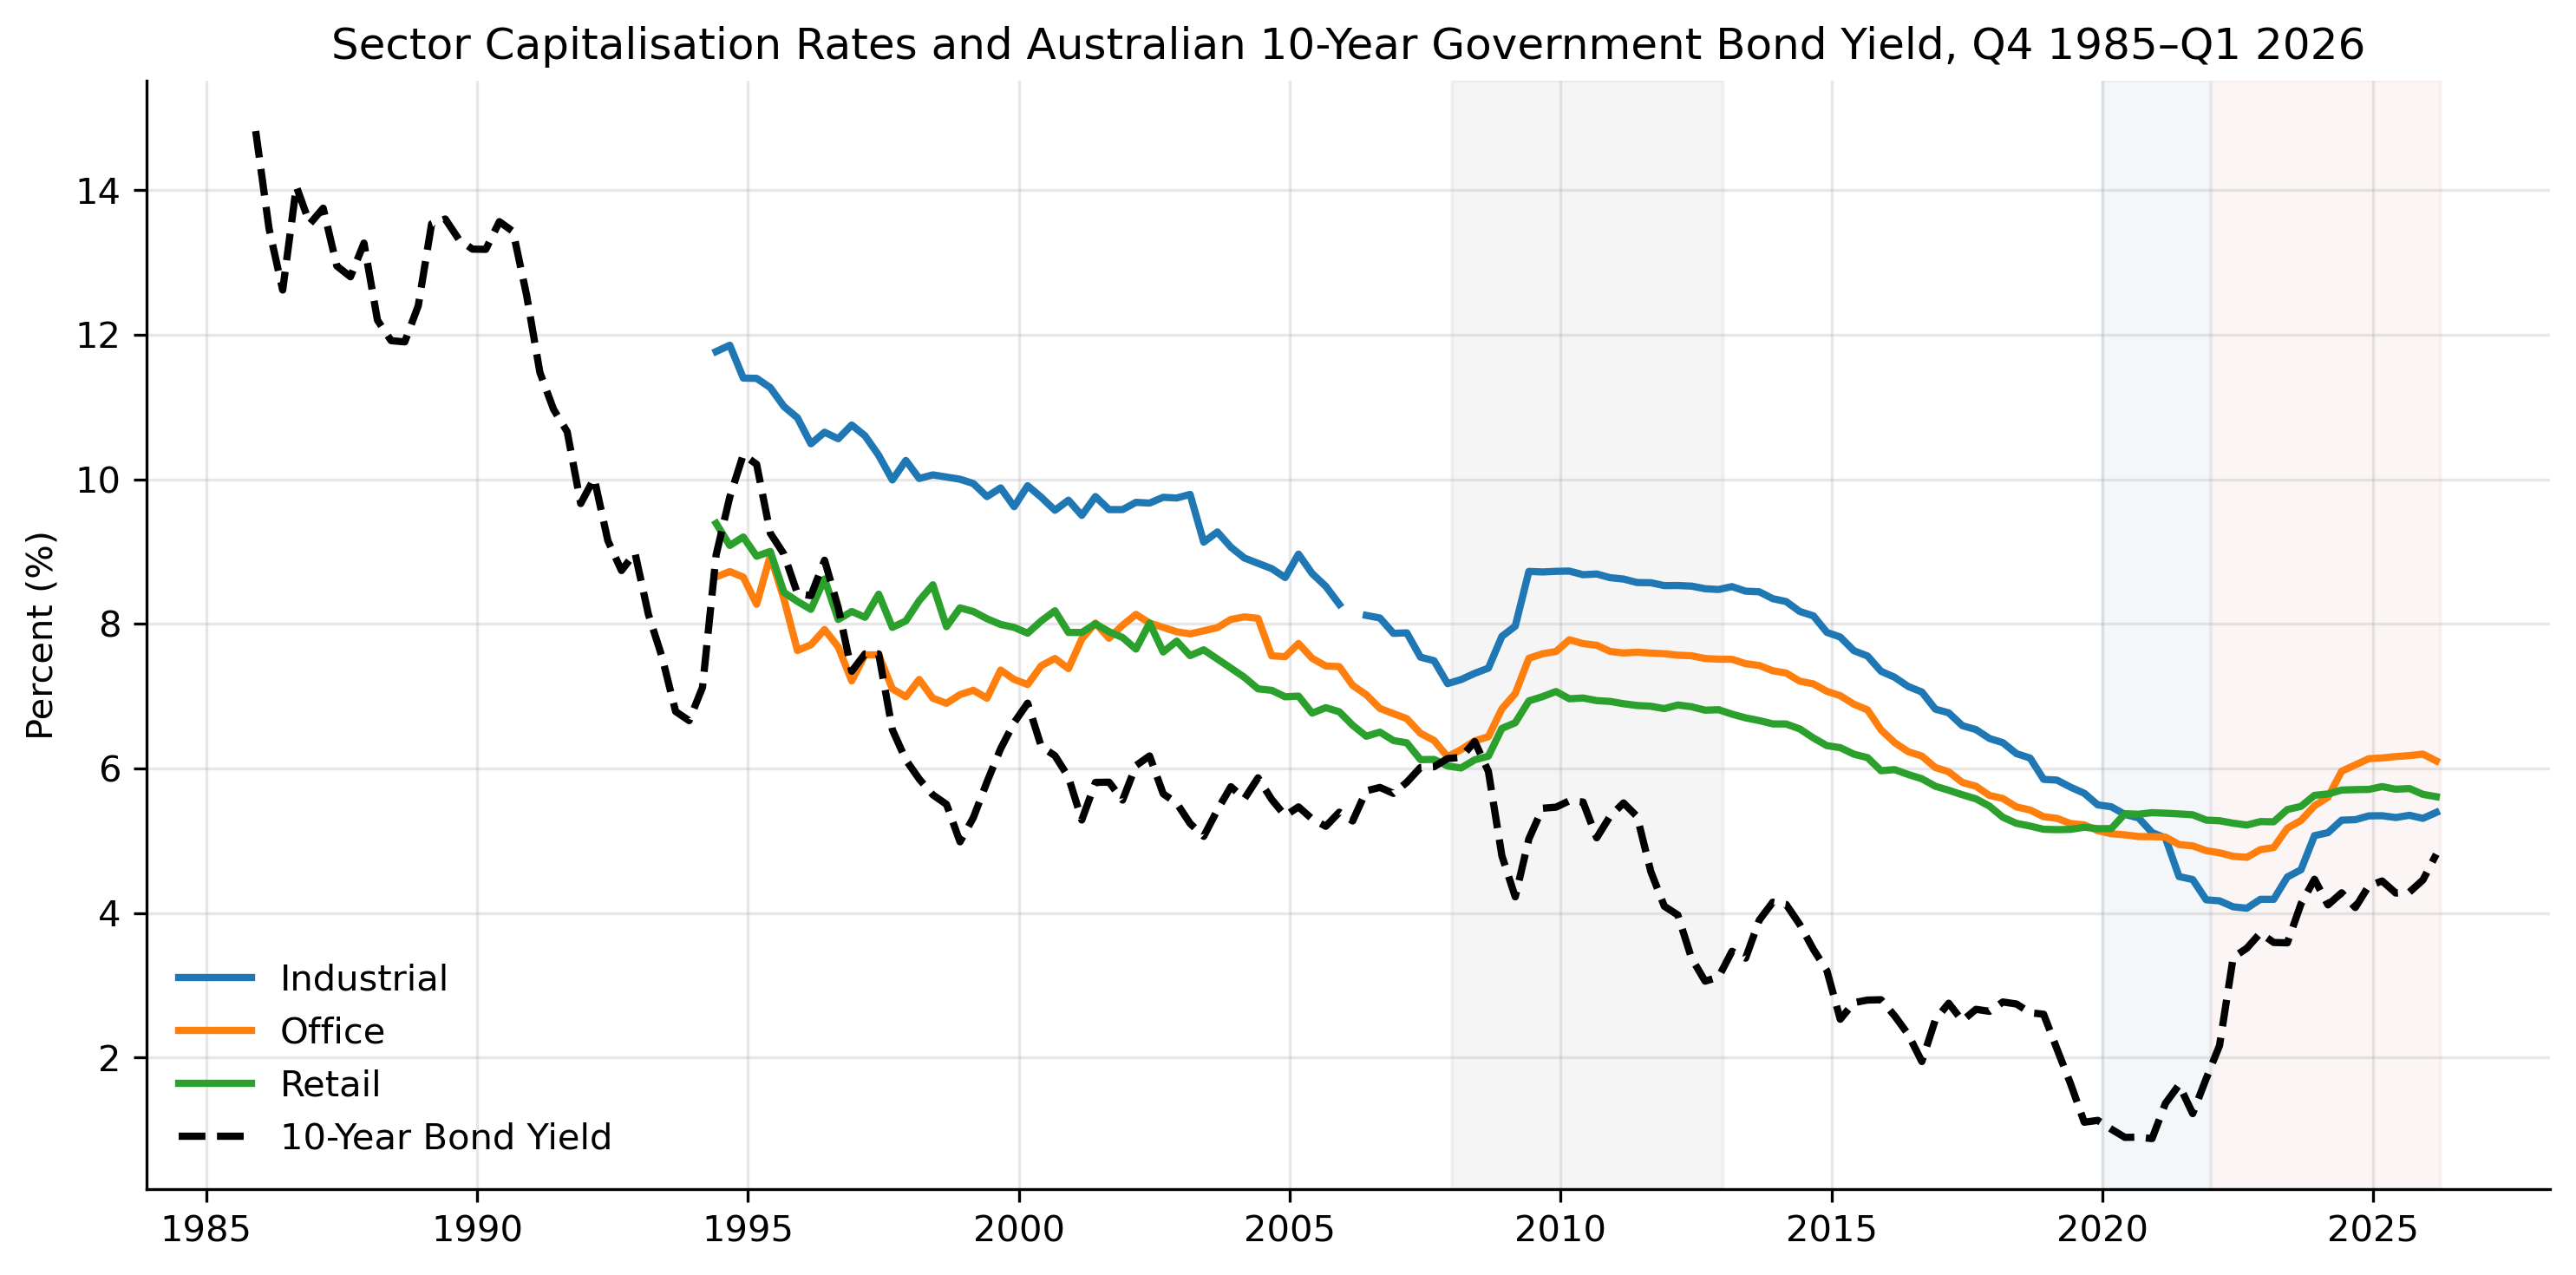

In [11]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=300)

# Plot cap rates
for sector in pivot.columns:
    ax.plot(
        pivot.index,
        pivot[sector],
        linewidth=2,
        label=sector.title()
    )

# Plot bond yield
ax.plot(
    bond.index,
    bond.values,
    color='black',
    linestyle='--',
    linewidth=2,
    label='10-Year Bond Yield'
)

# Regime shading
ax.axvspan(
    pd.Timestamp('2008-01-01'),
    pd.Timestamp('2012-12-31'),
    color='grey',
    alpha=0.08,
    zorder=0
)

ax.axvspan(
    pd.Timestamp('2020-01-01'),
    pd.Timestamp('2021-12-31'),
    color='steelblue',
    alpha=0.06,
    zorder=0
)

ax.axvspan(
    pd.Timestamp('2022-01-01'),
    pd.Timestamp('2026-03-31'),
    color='indianred',
    alpha=0.06,
    zorder=0
)

ax.set_title(
    'Sector Capitalisation Rates and Australian 10-Year Government Bond Yield, Q4 1985–Q1 2026'
)

ax.set_ylabel('Percent (%)')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(alpha=0.3)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [12]:
regimes = [
    ('1985-10-01', '2007-12-31', 'Pre-GFC Expansion', 'lightgrey'),
    ('2008-01-01', '2012-12-31', 'GFC & Recovery', '#D9D9D9'),
    ('2013-01-01', '2019-12-31', 'Low-Rate Expansion', '#E8F4EA'),
    ('2020-01-01', '2021-12-31', 'COVID', '#DDEBF7'),
    ('2022-01-01', '2026-03-31', 'Rate Shock', '#FCE4D6')
]

for start, end, label, colour in regimes:
    ax.axvspan(
        pd.Timestamp(start),
        pd.Timestamp(end),
        color=colour,
        alpha=0.25,
        zorder=0
    )

In [13]:
regimes = [
    ('1985-10-01', '2007-12-31', 'Pre-GFC Expansion', 'lightgrey'),
    ('2008-01-01', '2012-12-31', 'GFC & Recovery', '#D9D9D9'),
    ('2013-01-01', '2019-12-31', 'Low-Rate Expansion', '#E8F4EA'),
    ('2020-01-01', '2021-12-31', 'COVID', '#DDEBF7'),
    ('2022-01-01', '2026-03-31', 'Rate Shock', '#FCE4D6')
]

for start, end, label, colour in regimes:
    ax.axvspan(
        pd.Timestamp(start),
        pd.Timestamp(end),
        color=colour,
        alpha=0.25,
        zorder=0
    )

In [14]:
print(df['quarter_end'].min())
print(df['quarter_end'].max())

1985-12-01 00:00:00
2026-03-01 00:00:00


In [15]:
pivot = df.pivot(
    index='quarter_end',
    columns='sector',
    values='cap_rate'
)

print(pivot.head())

sector       Industrial  Office  Retail
quarter_end                            
1985-12-01          NaN     NaN     NaN
1986-03-01          NaN     NaN     NaN
1986-06-01          NaN     NaN     NaN
1986-09-01          NaN     NaN     NaN
1986-12-01          NaN     NaN     NaN


In [16]:
df[df['cap_rate'].notna()]['quarter_end'].min()


Timestamp('1994-06-01 00:00:00')

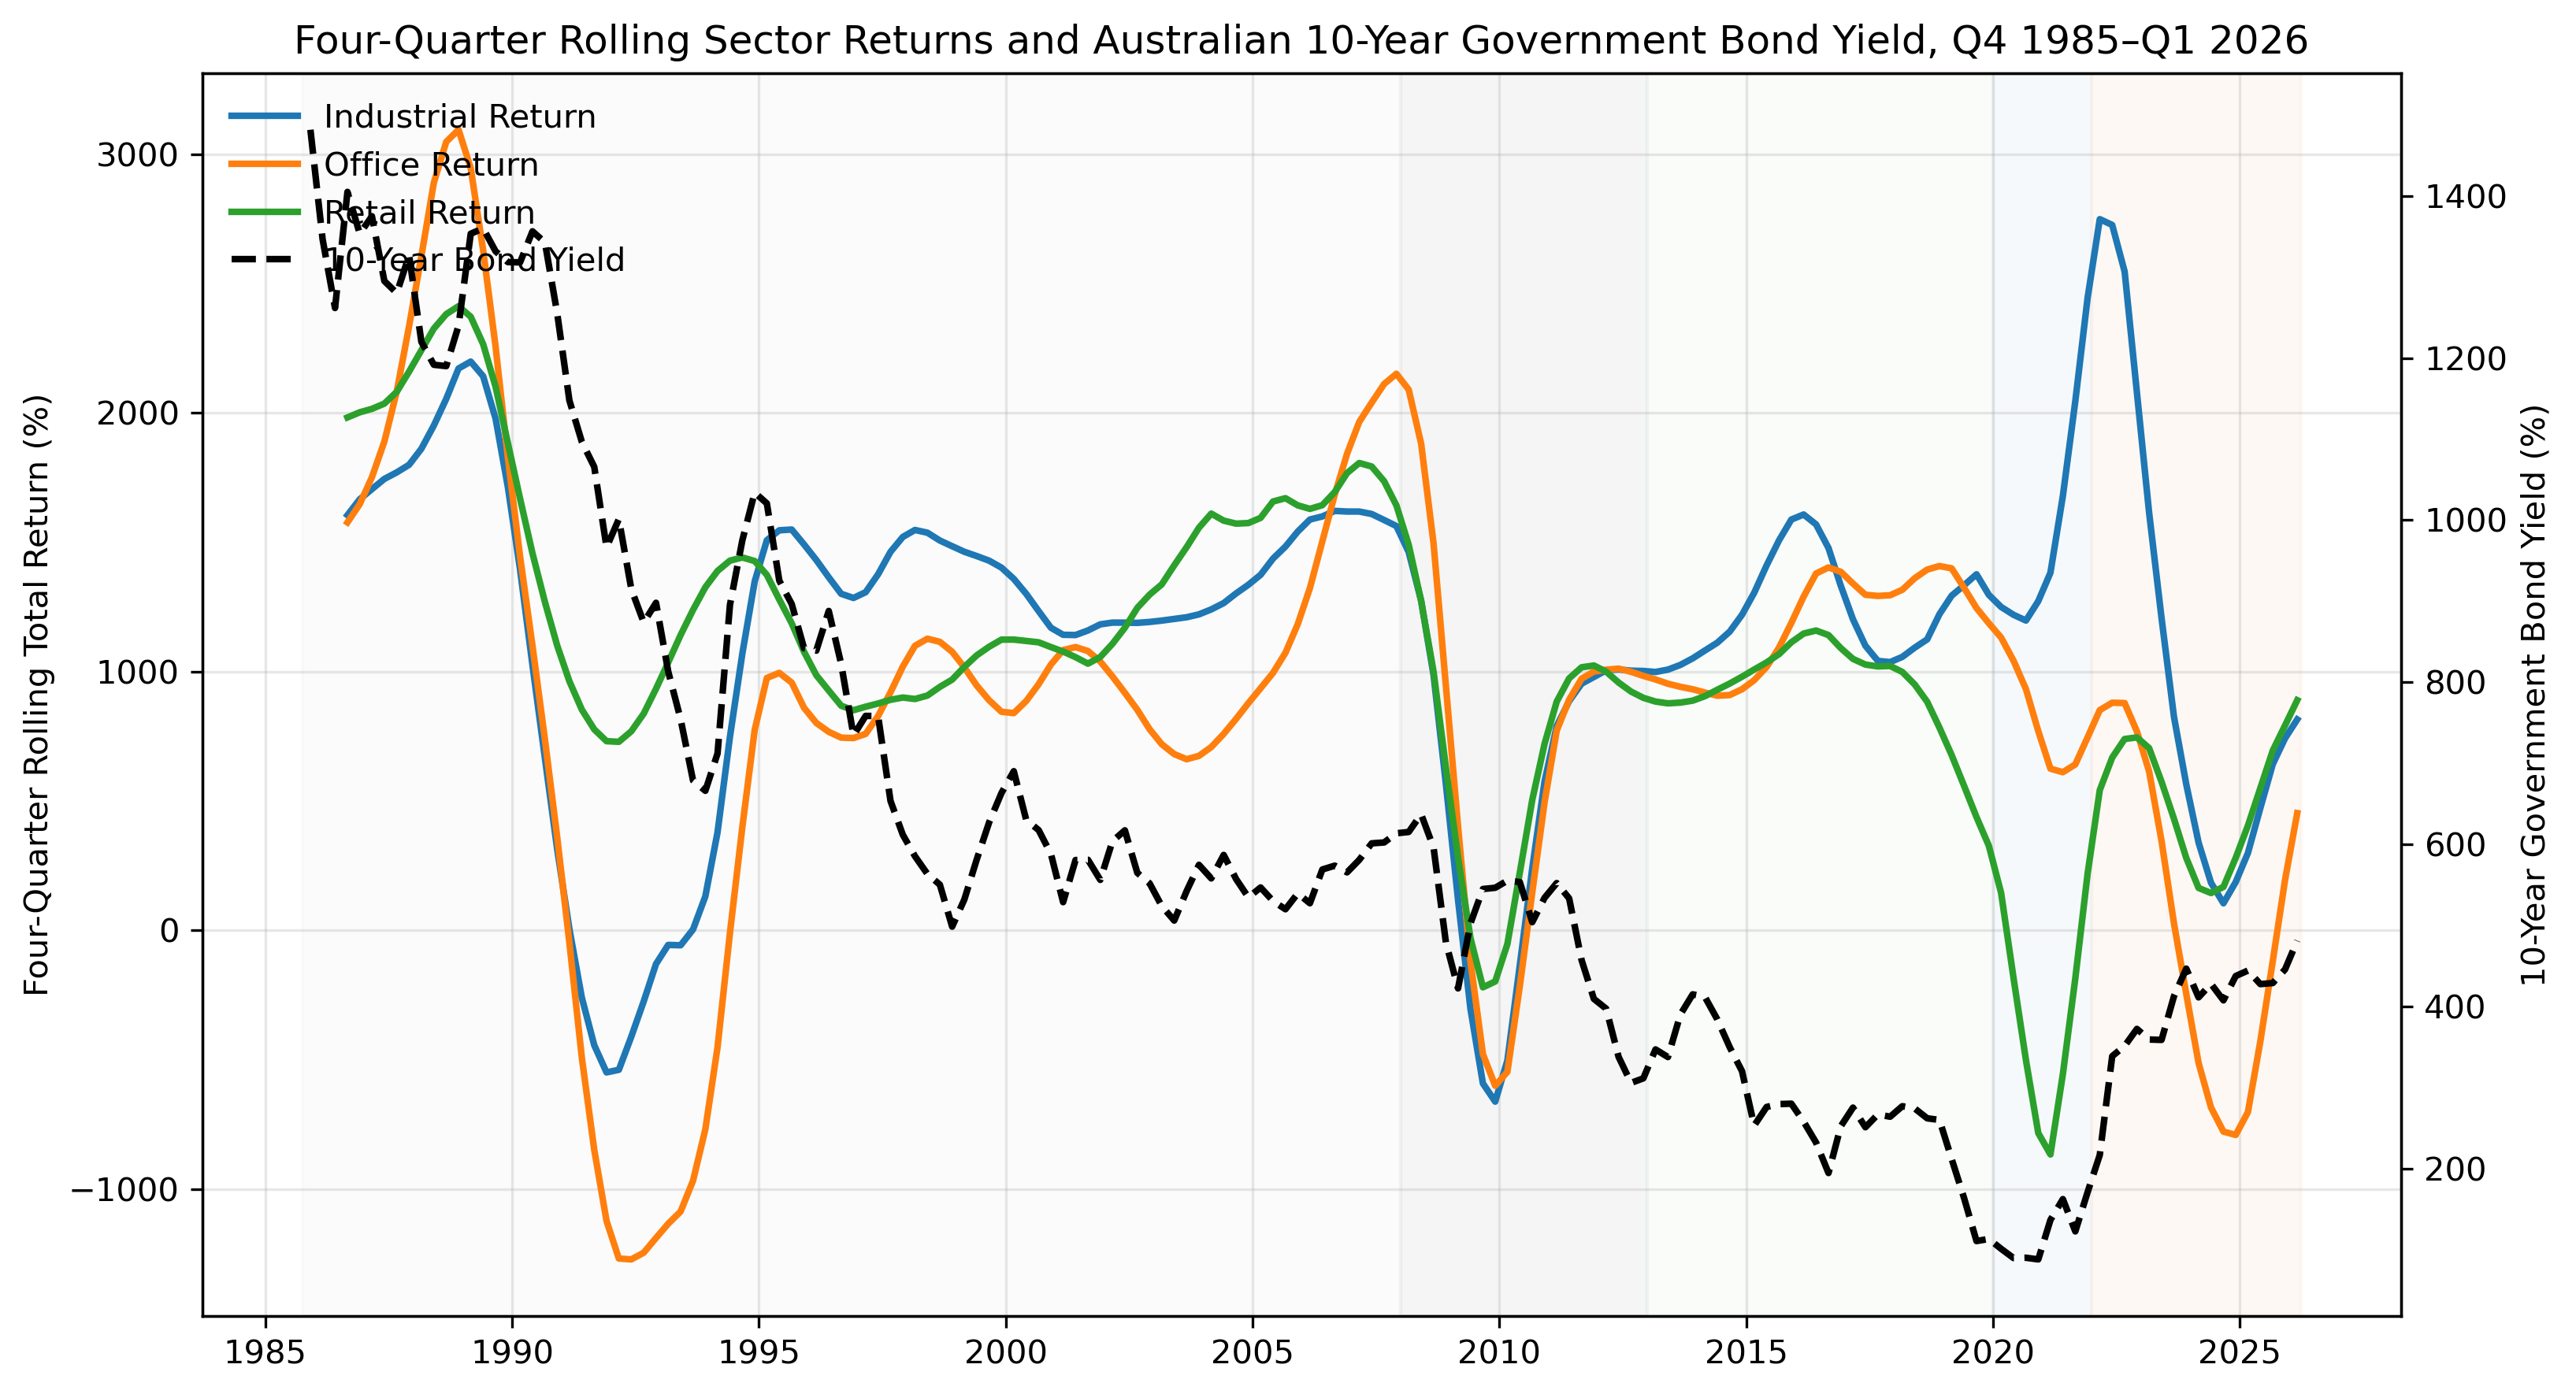

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Prepare data ---

df['quarter_end'] = pd.to_datetime(df['quarter_end'])

returns = df.pivot(
    index='quarter_end',
    columns='sector',
    values='total_return'
)

# 4-quarter rolling returns
returns_rolling = returns.rolling(4).mean() * 100

# Bond yield series
bond = (
    df.groupby('quarter_end')['bond_10y']
    .first()
    * 100
)

# --- Plot ---

fig, ax1 = plt.subplots(figsize=(11, 6), dpi=300)

# Property returns
for sector in returns_rolling.columns:
    ax1.plot(
        returns_rolling.index,
        returns_rolling[sector],
        linewidth=2,
        label=f'{sector.title()} Return'
    )

ax1.set_ylabel('Four-Quarter Rolling Total Return (%)')
ax1.set_xlabel('')
ax1.grid(alpha=0.3)

# Secondary axis for bond yield
ax2 = ax1.twinx()

ax2.plot(
    bond.index,
    bond,
    color='black',
    linestyle='--',
    linewidth=2,
    label='10-Year Bond Yield'
)

ax2.set_ylabel('10-Year Government Bond Yield (%)')

# Regime shading
regimes = [
    ('1985-10-01', '2007-12-31', '#F2F2F2'),
    ('2008-01-01', '2012-12-31', '#D9D9D9'),
    ('2013-01-01', '2019-12-31', '#E8F4EA'),
    ('2020-01-01', '2021-12-31', '#DDEBF7'),
    ('2022-01-01', '2026-03-31', '#FCE4D6')
]

for start, end, colour in regimes:
    ax1.axvspan(
        pd.Timestamp(start),
        pd.Timestamp(end),
        color=colour,
        alpha=0.25,
        zorder=0
    )

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    frameon=False,
    loc='upper left'
)

ax1.set_title(
    'Four-Quarter Rolling Sector Returns and Australian 10-Year Government Bond Yield, Q4 1985–Q1 2026'
)

plt.tight_layout()

plt.savefig(
    'Figure_Returns_vs_Bond_Yield.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

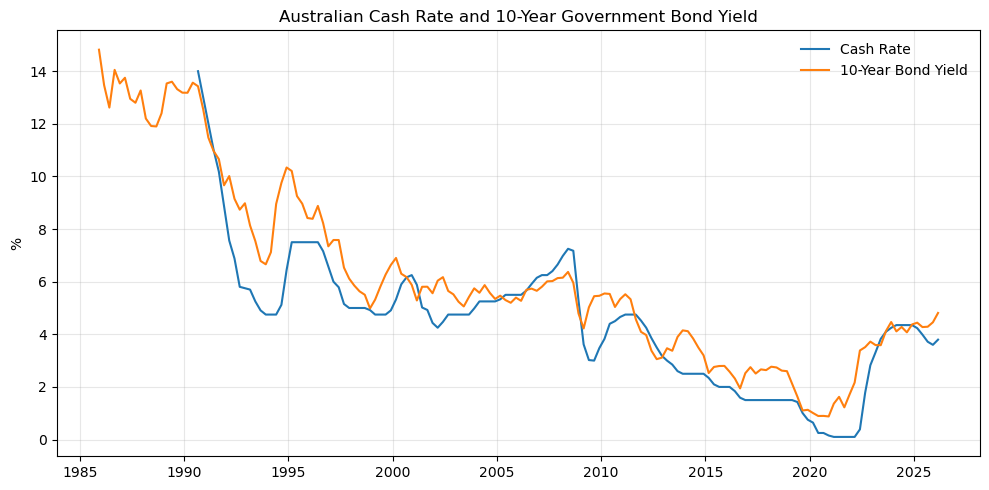

In [18]:
fig, ax = plt.subplots(figsize=(10,5))

rates = df.groupby('quarter_end')[['cash_rate','bond_10y']].first()

ax.plot(rates.index, rates['cash_rate'], label='Cash Rate')
ax.plot(rates.index, rates['bond_10y'], label='10-Year Bond Yield')

ax.set_title('Australian Cash Rate and 10-Year Government Bond Yield')
ax.set_ylabel('%')
ax.legend(frameon=False)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [1]:
Background and Motivation
Commercial real estate (CRE) is a heterogeneous asset class in which office, retail and industrial sectors can exhibit different return, risk, persistence and diversification characteristics rather than behaving as a single uniform market (Eichholtz et al., 1995; Sivitanides, 1996; Chambers, Spaenjers and Steiner, 2021; Candelon et al., 2021).
Office, retail and industrial sectors are shaped by distinct occupier-demand conditions, lease structures, spatial dynamics, supply constraints and economic exposures. Office performance may reflect service-sector employment, workplace-location decisions and agglomeration effects; retail performance may reflect consumer access, tenancy mix and the interaction between physical stores and online distribution; and industrial performance may reflect logistics networks, supply-chain organisation, e-commerce fulfilment and transport connectivity (Glaeser, 2011; Barrero, Bloom and Davis, 2021; Fields, 2020; Jorge and Wendt, 2022). This raises the central question of why benchmark-relative excess returns differ across Australian commercial property sectors.
Sector-level excess returns are defined as sector returns minus the MSCI Australia All Property Index return for the same period. This benchmark-relative measure is relevant because institutional investors allocate capital across property sectors as well as across asset classes, geographies and vehicles. In Australia, large superannuation funds manage long-horizon retirement savings within liquidity, governance, performance-assessment and portfolio-construction constraints, including prudential obligations relating to strategy, member outcomes, performance testing and transparency (Australian Prudential Regulation Authority, 2025a, 2025b; Bernstein, Lerner and Schoar, 2013).
Understanding why sector-level excess returns differ is therefore relevant to portfolio construction, sector weighting and benchmark-relative performance assessment. The empirical focus is whether observable return and valuation measures are associated with cross-sectional variation and persistence in sector-level excess returns.
Land and urban economics provide theoretical context for sector-specific performance differences. Classical land theory emphasises that physically fixed land supply allows population growth, technological change and public infrastructure to be capitalised into location values (George, 1879). Modern urban economics similarly views major metropolitan areas as engines of value supported by density, human capital and knowledge spillovers (Glaeser, 2011).
In commercial property markets, these spatial foundations are likely to be expressed unevenly across sectors. Office assets may reflect service-sector agglomeration and workplace-location decisions, retail assets may reflect consumer access and store-network positioning, and industrial logistics assets may reflect distribution-network efficiencies, supply-chain connectivity and proximity to consumers (Glaeser, 2011; Barrero, Bloom and Davis, 2021; Fields, 2020; Jorge and Wendt, 2022). These mechanisms are consistent with prior literature indicating that property types vary in occupier demand, lease structures, rental-growth dynamics, supply constraints, market depth, structural change and exposure to macroeconomic and capital-market conditions (Eichholtz et al., 1995; Sivitanides, 1996; Candelon et al., 2021; Wong et al., 2023). The theoretical point is therefore not that land economics alone explains sector returns, but that spatial and market foundations help frame the sector-level excess-return problem.
Analysing these dynamics requires looking beyond publicly traded real estate securities. Listed Real Estate Investment Trusts (REITs) provide useful evidence on investor expectations and discount-rate movements, but public and private real estate markets do not necessarily adjust synchronously (Ling and Naranjo, 2015). REIT prices may incorporate capital-market information more quickly and behave more like listed equities in the short run, whereas direct property values are formed through less frequent appraisal- and transaction-based processes (Bond, Hwang and Marcato, 2006; Pagliari, Scherer and Monopoli, 2005; Jenett et al., 2025). A sector-level analysis of direct property therefore requires attention to fundamentals, valuation lags and return persistence beyond listed-market evidence alone.
Direct property returns are shaped by sector-specific space-market fundamentals, including rental income, occupancy, lease duration, capital expenditure and capitalisation rates. Valuation frameworks model property prices as a function of expected cash flows, rental growth and discount rates, supporting the examination of income returns, capital returns, capitalisation rates and discount rates as valuation-chain measures associated with sector-level excess-return variation and persistence (Clayton, Ling and Naranjo, 2009; Ghysels, Plazzi and Valkanov, 2007; Peng, 2016; Wong et al., 2023). These relationships should be interpreted in the context of transaction costs, illiquidity and valuation lags, which may slow portfolio adjustment and measured price discovery in direct-property markets (Bond, Hwang and Marcato, 2006; Cheng, Lin and Liu, 2010; Ling and Naranjo, 2015).
Because the MSCI Australia All Property Index is a market-value-weighted institutional benchmark, benchmark-relative sector performance should be interpreted in the context of the benchmark’s sector composition. This is a measurement and interpretation issue rather than an explanatory mechanism for excess returns.
Macroeconomic conditions provide a further reason to examine sector-level performance. Inflation, interest rates, bond yields, risk premiums and credit conditions may affect real estate through income, discount-rate and financing channels, although these effects are unlikely to be uniform across regimes or property types (West and Worthington, 2006; Jiang et al., 2023; Muckenhaupt, Hoesli and Zhu, 2023; Wong et al., 2023). Australian evidence links commercial property capitalisation rates to bond yields, risk premiums and macroeconomic variables, while international evidence on monetary tightening suggests that valuation pressure and refinancing risk can vary across property types (Jiang et al., 2023; Wong et al., 2023).
For institutional allocators, aggregate CRE exposure may therefore conceal sector-level sensitivities to macroeconomic and financing conditions (West and Worthington, 2006; Wong et al., 2023).
Sector performance may also reflect structural changes in occupier behaviour, consumer activity and supply-chain organisation. Prior literature suggests that remote and hybrid working may have affected office lease decisions, rental expectations and valuation assumptions, with outcomes varying across building quality segments (Barrero, Bloom and Davis, 2021; Fiorentino et al., 2022; Gupta, Mittal and Van Nieuwerburgh, 2022). Retail and industrial sectors may also be influenced by e-commerce, consumer behaviour and supply-chain reorganisation, although these channels are not directly observed in the present dataset and are interpreted through observable valuation-chain measures (Fields, 2020; Jorge and Wendt, 2022).
Existing empirical evidence also suggests that the sector-level excess-return question is economically meaningful. International studies indicate that commercial property sectors exhibit different return, risk and diversification characteristics, suggesting that sector performance cannot be fully understood through aggregate property-market exposure alone (Eichholtz et al., 1995; Sivitanides, 1996; Chambers, Spaenjers and Steiner, 2021). Australian evidence further suggests that persistence, volatility dynamics and macroeconomic sensitivity may vary across office, retail and industrial property markets (Graff, Harrington and Young, 1999; West and Worthington, 2006), while valuation measures such as capitalisation rates and discount rates contain information relevant to commercial property return behaviour (Clayton, Ling and Naranjo, 2009; Ghysels, Plazzi and Valkanov, 2007; Wong et al., 2023). However, it remains less clear how these relationships interact within Australian direct-property markets when performance is evaluated through benchmark-relative sector excess returns.
Taken together, these considerations suggest that Australian commercial real estate performance reflects the interaction of sector heterogeneity, property-market fundamentals, macroeconomic conditions and structural change (Eichholtz et al., 1995; West and Worthington, 2006; Clayton, Ling and Naranjo, 2009; Wong et al., 2023). They motivate an empirical focus on whether observable valuation-chain measures are associated with systematic differences in sector-level excess returns rather than with generic exposure to commercial real estate as a single asset class.
This study therefore asks: to what extent do observable return and valuation measures explain cross-sectional variation and persistence in excess returns across Australian office, retail and industrial property sectors? The question matters because institutional investors allocate across property sectors relative to benchmarks, so sector-level excess-return differences may affect portfolio construction, sector weighting and benchmark-relative performance assessment. The following literature review evaluates four substantive strands that inform this question: sector heterogeneity, property-market fundamentals, macroeconomic and capital-market influences, and structural change. Across these strands, it examines the mechanisms through which excess-return variation and persistence may arise.
Literature Review
This review evaluates the empirical and theoretical literature relevant to cross-sectional variation and persistence in sector-level excess returns, measured against the MSCI Australia All Property Index. It distinguishes total return components from benchmark-relative sector performance: income returns reflect rental cash flows and operating conditions, capital returns reflect changes in asset values, and sector excess returns measure the difference between a sector’s total return and the broad all-property benchmark in the same period (Clayton, Ling and Naranjo, 2009; Ghysels, Plazzi and Valkanov, 2007). Income and capital returns are therefore interpreted as valuation-chain and relative-performance measures rather than as mechanically independent causes of excess returns.
Because direct property performance is typically measured through appraisal- and transaction-based processes in informationally segmented and illiquid markets, sector fundamentals may be incorporated into measured returns with a lag (Clayton, Ling and Naranjo, 2009; Bond, Hwang and Marcato, 2006; Fisher, Geltner and Pollakowski, 2007; Ling and Naranjo, 2015).
On this basis, the review is organised around four strands: sector heterogeneity; property-market fundamentals; macroeconomic and capital-market influences; and structural change. Across these strands, it examines how excess-return variation and persistence may arise in Australian direct property markets and builds toward a unified valuation-chain framework. Structural-change mechanisms are treated as literature-based context rather than directly observed variables in the empirical dataset.
Sector Heterogeneity and Cross-Sectional Return Variation
Commercial real estate is widely recognised as a heterogeneous asset class in which investment returns can vary materially across property types, locations and individual assets (Eichholtz et al., 1995; Sivitanides, 1996; Chambers, Spaenjers and Steiner, 2021; Candelon et al., 2021). Rather than operating as a single unified market, office, retail and industrial assets are shaped by different occupier-demand drivers, lease structures, operating cost characteristics and risk profiles.
As a result, aggregate property indices can mask important differences in performance and in the mechanisms through which returns are generated (Eichholtz et al., 1995; Candelon et al., 2021). This directly informs the present study because sector-level excess returns, measured relative to the MSCI Australia All Property Index, may reflect divergence in underlying fundamentals rather than random deviations from an aggregate market benchmark.
Foundational portfolio research provides early empirical support for differences in property-sector returns. Eichholtz et al. (1995) find that correlations between property types are generally lower than correlations between broad geographic regions, suggesting that property-type effects explain an important component of real estate return outcomes. Similarly, Sivitanides (1996) documents statistically different risk–return characteristics across real estate sectors and shows that optimal portfolio allocations vary depending on the chosen return measure and investment horizon. Collectively, these early studies indicate that office, retail and industrial properties are better understood as separate exposures with their own return dynamics and risk profiles, rather than as interchangeable assets within a broader real estate portfolio.
Subsequent empirical evidence using expanded datasets reinforces these cross-sectional differences. Using a long-run property-level financial dataset from institutional portfolios, Chambers et al. (2021) document substantial historical variation in gross income yields, capital appreciation and total returns across property categories. Their findings suggest that differences in income generation, cost profiles and asset characteristics can produce divergent long-term investment outcomes across property sectors.
Candelon et al. (2021), using direct real estate market data across 16 OECD countries, also show that return correlations differ by sector and market, indicating that property-type influences remain empirically relevant even within internationally diversified portfolios. While these studies primarily address portfolio diversification, they also indicate that return dispersion may reflect underlying economic differences between sectors rather than simple random fluctuation around a common market mean.
Australian evidence provides more direct support for sector-level return differences. Graff et al. (1999) examine disaggregated Australian commercial real estate returns and find statistically significant differences in performance persistence across sectors. Their analysis indicates that office and retail returns exhibit serial persistence, with performance tending to remain clustered within similar return quartiles over time, whereas industrial returns display weaker continuity.
A related implication is that sector classifications may still contain internal variation. Graff et al. (1999) identify intra-sector differences, noting that central business district office markets exhibit patterns not evident in non-CBD office assets. These findings suggest that excess returns may be shaped by localised conditions and market structure, rather than by broad commercial property exposure alone.
Australian evidence also indicates that macroeconomic conditions may be transmitted unevenly across property sectors. West and Worthington (2006), employing a GARCH-in-Mean framework, find that macroeconomic variables, including interest rates, inflation, construction activity and industrial production, are statistically significant determinants of Australian property returns.
Their modelling also shows that volatility shocks decay at different rates across sectors, with retail and industrial property displaying longer half-lives than office property. These findings suggest that macroeconomic innovations may pass through property markets via different structural channels, contributing to variation and persistence in sector-level excess returns.
While observed persistence can reflect genuine economic processes, the literature also highlights important measurement and econometric considerations. Commercial real estate returns are frequently derived from periodic appraisal-based valuations rather than continuous market transactions, so measured returns may not adjust fully to new information within a single period.
Bond et al. (2006) argue that appraisal smoothing can understate true volatility and create an appearance of serial correlation that may not fully reflect underlying market movements. Comparative studies of appraisal-based and transaction-based indices similarly find that transaction-based measures exhibit higher short-term volatility and faster price adjustment to new information (Fisher, Geltner and Pollakowski, 2007; Ling and Naranjo, 2015).
A further implication of sector heterogeneity is that behavioural and informational influences may affect property types asymmetrically. Cheung and Lee (2021) find that both occupier sentiment and investor sentiment contribute to explaining time-series variation in Australian commercial real estate returns, even after controlling for prevailing macroeconomic conditions.
Their empirical results suggest that sentiment metrics contain incremental information relevant to return forecasting and that behavioural influences may vary across property markets. This is consistent with broader evidence indicating that information does not necessarily diffuse through all sectors simultaneously.
For this dissertation, the implication is that sector excess returns may reflect variation in observable valuation-chain outcomes associated with cash-flow generation, income expectations and capital-market pricing, as well as differences in how market participants process information.
In summary, the empirical literature supports treating office, retail and industrial markets as distinct sector exposures whose return, risk, persistence and information-processing characteristics may differ. This provides a rationale for examining sector-level excess returns relative to the MSCI Australia All Property Index.
Property Market Fundamentals and Return Persistence
Commercial real estate returns can be understood through an income-capital valuation chain. Sector fundamentals first influence income expectations through occupier demand, vacancy, lease structures, tenant quality, operating costs, incentives and supply conditions. These expectations are then reflected in capital values through capitalisation rates and discount rates, which translate expected cash flows, risk premia and required returns into observed property prices (Clayton, Ling and Naranjo, 2009; Ghysels, Plazzi and Valkanov, 2007; Peng, 2016).
The resulting income and capital components describe total-return formation, while sector excess returns measure benchmark-relative performance against the MSCI Australia All Property Index. This sequence—sector fundamentals to rental-income expectations, capital values, cap rates, discount rates and benchmark-relative returns—provides the theoretical basis for linking property-market fundamentals to cross-sectional excess-return variation without implying that income return and capital return mechanically cause excess return.
This framework distinguishes return variation from persistence. Cross-sectional variation arises because sectors differ in income bases, rental-growth expectations, capital values and required returns. Clayton, Ling and Naranjo (2009) show that commercial property pricing remains connected to expected rental growth, equity risk premia and bond yields, indicating that space-market and capital-market conditions are embedded in valuations.
Ghysels, Plazzi and Valkanov (2007) similarly show that cap rates forecast commercial real estate returns, while also finding that only part of cap-rate variation is explained by local state variables and rent growth. This suggests that cap rates contain information about both local cash-flow fundamentals and broader pricing forces.
Peng’s (2016) property-level evidence reinforces this interpretation by showing that acquisition cap rates, treated as discount-rate proxies, predict subsequent realised returns and abnormal performance, especially over shorter horizons. Together, these studies support the view that sector excess returns may arise because sectors differ in income expectations, valuation levels and required-return conditions.
Australian evidence is especially useful because it illustrates how valuation channels may operate through both space-market and capital-market conditions. Wong et al. (2023) clarify a plausible mechanism through which Australian commercial property valuations adjust: rental growth, vacancy and income expectations shape expected cash flows, while interest rates, risk premia and financial-market conditions influence the rate at which those cash flows are capitalised.
Cap rates and discount rates can therefore be interpreted as observable valuation proxies for the interaction between space-market cash-flow conditions and capital-market pricing conditions. This interpretation supports the dissertation’s focus on explaining why sector-level excess returns differ through observable valuation-chain measures.
Return persistence follows a related but distinct logic. Whereas cross-sectional variation reflects differences in income expectations, capital values, cap rates and discount rates across sectors, persistence may arise from economic adjustment processes and measurement effects that should be separated analytically.
Persistence may arise from gradual economic adjustment and transaction frictions. Slow-moving occupier demand, lease structures, supply constraints, financing conditions and investor risk perceptions can delay sector adjustment, while high transaction costs, illiquidity, limited arbitrage and periodic valuation can slow the incorporation of new information into prices and returns (Clayton, Ling and Naranjo, 2009; Cheng, Lin and Liu, 2010; Ling and Naranjo, 2015). Fisher, Geltner and Pollakowski (2007) further show that transaction-based measures can reveal different timing and volatility characteristics from appraisal-based measures, suggesting that observed adjustment depends partly on how market information is recorded.
Information delays provide a related mechanism. Ling and Naranjo (2015) argue that public real estate securities incorporate latent asset-pricing information more quickly than private markets because of greater liquidity and price revelation. In direct property markets, information about rents, vacancies, investor risk appetite and financing conditions may therefore be transmitted gradually, generating delayed market adjustment and persistence in excess returns.
The Australian persistence evidence established under sector heterogeneity also helps interpret these mechanisms. Graff, Harrington and Young (1999) are most relevant here not simply because they document persistence, but because their sectoral pattern is consistent with differences in how information is incorporated into values.
Office, retail and industrial assets may differ in lease structures, tenant profiles, transaction depth and valuation evidence. These differences may affect the speed with which rental conditions, investor demand and risk perceptions are reflected in appraisals and transactions, creating a pathway through which persistence can appear in sector-level excess returns.
Appraisal smoothing and valuation lags further help explain why measured excess returns may persist even when underlying fundamentals are changing. Appraisal-based commercial real estate indices may understate volatility and create serial correlation in measured returns (Bond, Hwang and Marcato, 2006).
Because this dissertation analyses excess returns, defined as sector return minus the all-property benchmark return, appraisal smoothing is more subtle than in a simple sector-return analysis. Both components are derived from appraisal-based direct-property valuations, so common smoothing may partly cancel in the excess-return calculation. However, because the MSCI Australia All Property Index is market-value weighted, appraisal lag and smoothing may not affect benchmark-relative sector returns uniformly where sector weights, transaction evidence or appraisal timing differ across office, retail and industrial property. Benchmark construction therefore does not drive persistence, but it remains a measurement consideration when interpreting benchmark-relative sector returns.
Persistence should therefore be interpreted cautiously as an observed association in direct-property returns, rather than as definitive evidence of market inefficiency, active management skill, structural sector advantage or fully contemporaneous changes in underlying asset values.
This valuation-chain framework also clarifies how the literature can be interpreted using the variables available in the MSCI Australia direct property dataset. Net income, rental growth and capital values remain important theoretical constructs because they describe how space-market fundamentals and expectations about future cash flows are translated into asset prices.
However, the empirical evidence available for sector-level analysis is more consistently observed through returns and valuation proxies. Income return and capital return describe components of realised sector total return, while cap rates and discount rates provide observable indicators of broader income, growth, risk-premium and required-return processes. Sector, location and quality classifications provide additional structure for examining whether these valuation-chain measures vary systematically across office, retail and industrial property.
The persistence of excess returns is therefore unlikely to be explained by the contemporaneous level of any single valuation measure alone. Instead, observable MSCI return and valuation measures are treated as proxies for broader, partly unobservable cash-flow, pricing and valuation processes.
Within this framework, benchmark-relative performance is a measurable outcome that may be associated with sector-specific fundamentals, valuation conditions and lagged adjustment in direct property markets. The empirical analysis can therefore examine whether valuation-chain measures help explain why excess returns differ across sectors and whether their lagged values are associated with persistence over time.
Macroeconomic and Capital-Market Influences
Interest rates and bond yields provide an important capital-market channel through which macroeconomic conditions affect direct commercial property returns. In this study, these influences matter primarily through capitalisation rates, discount rates, required returns, capital values and sector returns, rather than as standalone explanatory variables. Wong et al. (2023) show that bond rates, market risk premia, stock market excess returns and other macroeconomic variables are associated with Australian capitalisation rates, indicating that monetary and capital-market conditions are reflected in the pricing of future income streams.
This interpretation is consistent with Duca (2019), who links CRE valuations to interest rates, credit conditions and capital-market pricing, and with Devaney et al. (2019), whose international office-market evidence identifies government bond yields, yield spreads and rents as core determinants of cap rates. These studies support the view that bond yields matter because they shift required returns and contribute to repricing through the income-capital valuation chain.
Property-type evidence suggests that monetary transmission may not be uniform. Peng and Thibodeau (2011) find a non-monotonic interest-rate effect for office and retail property, but not for industrial assets. This supports the dissertation’s emphasis on explaining why sector-level excess returns may differ through valuation-chain measures rather than assuming a common macroeconomic response across property sectors.
Inflation is closely related to the interest-rate channel, but its effect on commercial property performance is contingent. Australian evidence does not support a universal inflation hedge; instead, hedging capacity appears regime-dependent and sector-specific. Leung (2010) finds that Australian commercial property at an aggregate level can hedge both expected and unexpected inflation, while Newell (1996) reports strong inflation-hedging evidence across office, retail and industrial property, although the office result weakens once vacancy is considered.
International evidence is more mixed: Huang and Hudson-Wilson (2007) find stronger protection for office and warehouse property than retail, while other studies suggest that hedging capacity can weaken in lower-inflation, inflation-targeting regimes. Where inflation protection exists, it may operate through lease indexation, rental growth, replacement-cost effects and asset repricing. Inflation should therefore be treated as a conditional support to real estate performance rather than a stable defensive characteristic.
Credit conditions influence direct commercial property through leverage availability, refinancing risk and investor risk appetite. Duca (2019) links CRE valuations to interest rates, credit conditions and capital requirements, and notes that office prices and valuations are vulnerable to mean reversion in long-term interest rates. Peyton (2009) similarly reports that cap rates did not adjust immediately to the 2007 credit shock, widening only later.
Rollover risk can reinforce this channel. Properties facing imminent loan maturities experience sharper declines in net operating income and occupancy, and higher refinancing costs can depress sale prices and curtail investment. Debt repricing, covenant tightening and lender caution may therefore weigh on sector-level returns even after policy-rate changes have occurred.
Another capital-market channel operates through institutional debt constraints. In a rising-rate or risk-premium environment, expanding capitalisation rates compress capital values and can pressure loan-to-value covenants, while higher interest costs can weaken interest-cover ratios even where rental income remains comparatively stable.
Sector resilience therefore depends on both leverage and lease profile. Assets with CPI-linked escalations, shorter rent-review cycles or stronger tenant demand may better protect income coverage, whereas assets with fixed-step leases, weak releasing prospects or elevated vacancy may face greater pressure on income returns and capital values. Debt covenants and refinancing risk therefore reinforce the income-capital valuation chain.
Exchange rates and foreign capital flows are secondary to interest rates, bond yields and credit conditions, but remain relevant in a small open economy such as Australia. Tarbert and McAllister (1998) find that exchange-rate movements exacerbate risk for non-domestic investors without offering compensating return. Foreign capital may also influence pricing, with McAllister and Nanda (2014) finding that greater foreign participation may affect commercial real estate capitalisation rates, and Lane and Orsmond (2014) noting that foreign demand has supported Australian commercial-building market activity.
Broader exchange-rate evidence suggests the effect is indirect and sector-specific. Allayannis and Ihrig (2001) show that exposure depends on competitive structure, export share and imported inputs, while Campbell and Lapham (2004) find that real exchange rates affect retail industries through cross-border shopping and local demand shifts. Exchange rates therefore matter mainly through overseas investor demand and trade-exposed sector conditions, rather than as direct determinants of commercial property pricing.
Overall, the literature suggests that macroeconomic forces affect commercial property mainly through valuation-chain measures: interest rates and bond yields influence discount rates and required returns; credit conditions affect leverage and refinancing risk; inflation may affect cash flows and capital values; and exchange rates and foreign capital flows can transmit international conditions into local pricing. These channels provide a theoretical basis for examining sector-level excess returns through capitalisation rates, discount rates, capital values and income returns.
Structural Change and Sector Transformation
Structural change matters for direct commercial property because broader shifts in occupier behaviour, consumer activity and supply-chain organisation may alter the assumptions embedded in rental expectations and valuations. In office markets, prior evidence suggests that remote and hybrid working arrangements have remained above pre-pandemic levels in some labour markets and may be associated with changes in lease decisions, space requirements and workplace-density preferences (Barrero, Bloom and Davis, 2021; Fiorentino et al., 2022; Hansen et al., 2023).
For the present study, these developments provide contextual and theoretical motivation rather than directly observed explanatory variables. If comparable office-market pressures are reflected in Australian direct-property valuations, they would be observed indirectly through rental-growth expectations, income returns, capital returns, capitalisation rates, discount rates and benchmark-relative excess returns. Gupta, Mittal and Van Nieuwerburgh (2022) provide a relevant example, finding that remote work was associated with lower lease revenues, occupancy and market rents, with larger valuation effects for lower-quality buildings and some buffering for higher-quality buildings through flight-to-quality dynamics.
The stronger structural consequence identified in the office literature may be internal bifurcation rather than uniform decline. Matsuo, Tsutsumi, Imazeki and Kudoh (2024) provide evidence that modern amenities are associated with higher rents and lower vacancy, and also report that the vacancy advantage for higher-quality offices widened after 2020.
Sustainability-related evidence reinforces this sorting process. Studies show that sustainable-labelled and energy-efficient office buildings may attract stronger tenant demand, rental premiums and investor attention (Eichholtz, Holtermans and Kok, 2019; Hutchison, Liu, Zhao and Yan, 2024). These findings provide theoretical context for interpreting any post-COVID office underperformance or repricing observed through income returns, capital returns, cap rates, discount rates and excess returns.
Retail appears less as a simple secular decline than as structural adaptation of the rent base. Studies of experiential retail describe expanding online sales, large-scale closure of traditional formats and the growth of experiential concepts in major cities (Fields, 2020). Demand may therefore shift from undifferentiated retail space toward convenience-led, service-rich and experience-oriented formats that complement online fulfilment. Assets supporting brand experience, local service provision and last-mile engagement may continue to generate rental growth, while commoditised retail space faces weaker occupancy and pricing power.
Industrial and logistics property may be supported by multiple structural drivers that appear mutually reinforcing rather than merely defensive. Supply-chain and logistics evidence indicates that resilience, shorter lead times, inventory buffers and alternative capacity may increase the strategic value of flexible distribution networks and transport-connected warehousing (Jorge and Wendt, 2022). E-commerce fulfilment adds a further potential occupier-demand channel, with online retail growth increasing demand for last-mile logistics, inventory positioning and distribution capacity (Jorge and Wendt, 2022).
Industrial property is therefore plausibly favoured by structural change within this framework, although any empirical support must be inferred only from observable valuation-chain outcomes and remains dependent on location, asset specification, power availability and transport connectivity.
These structural changes are relevant to the valuation-chain framework because they may alter vacancy, lease demand, rental-growth expectations, future cash flows and pricing assumptions (Clayton, Ling and Naranjo, 2009; Gupta, Mittal and Van Nieuwerburgh, 2022). In the present dataset, they are observed only indirectly if capitalised into income returns, capital returns, capitalisation rates, discount rates and excess returns; the study therefore does not directly test the underlying occupier-demand mechanisms.
Taken together, the literature suggests that structural transformation is a sector-specific reallocation of demand, risk and valuation assumptions rather than a uniform shock to commercial real estate. Office faces structural uncertainty, retail is undergoing adaptation and industrial and logistics property may be supported by e-commerce fulfilment, supply-chain resilience and transport-connected distribution capacity (Gupta, Mittal and Van Nieuwerburgh, 2022; Fields, 2020; Jorge and Wendt, 2022). These forces provide context for interpreting cross-sectional variation and persistence in sector-level excess returns relative to the MSCI Australia All Property Index.
Conceptual Framework
The literature reviewed above supports a valuation-chain framework in which sector characteristics influence property fundamentals, which are reflected in income returns, capital returns, capitalisation rates and discount rates (Clayton, Ling and Naranjo, 2009; Ghysels, Plazzi and Valkanov, 2007; Peng, 2016; Wong et al., 2023). These mechanisms translate into sector-level benchmark-relative excess returns, while persistence may arise from direct-property adjustment frictions and appraisal-based measurement effects (Bond, Hwang and Marcato, 2006; Cheng, Lin and Liu, 2010; Ling and Naranjo, 2015). The conceptual sequence is as follows:
	Sector characteristics;
	Property fundamentals;
	Income returns and capital returns;
	Capitalisation rates and discount rates;
	Sector excess returns; and
	Return persistence.
This framework provides the conceptual bridge between sector-level real estate characteristics and the empirical testing of cross-sectional variation and persistence in Australian direct-property excess returns (Eichholtz et al., 1995; Graff, Harrington and Young, 1999; Clayton, Ling and Naranjo, 2009). Because the MSCI dataset does not directly observe many upstream property-market mechanisms, including lease-level demand, vacancy, tenant quality, incentives, capital expenditure, rental-growth expectations or occupier-behaviour change, the empirical analysis operationalises the framework through observable valuation-chain outcomes. Income returns, capital returns, capitalisation rates, discount rates and benchmark-relative excess returns are therefore used to test whether the sector-characteristics-to-property-fundamentals sequence is reflected in measurable return, valuation and persistence patterns.
Existing Empirical Evidence
Empirical research provides consistent evidence that commercial real estate sectors differ in their return and risk characteristics. Eichholtz et al. (1995) show that property-type effects are relevant to portfolio diversification because correlations across property types differ from correlations across regions. Sivitanides (1996) similarly documents differences in risk–return outcomes across real estate sectors and indicates that optimal portfolio allocations vary depending on the return measure and holding period. Longer-run institutional evidence from Chambers, Spaenjers and Steiner (2021) suggests that income yields, capital appreciation and total returns vary across property categories, while Candelon et al. (2021) provide international evidence that sector and market differences remain relevant in direct real estate portfolios. Taken together, these findings indicate that sector-level performance is unlikely to be fully explained by aggregate commercial property exposure alone.
Australian evidence reinforces this sector-level interpretation. Graff, Harrington and Young (1999) provide evidence of performance persistence in Australian commercial property and show that persistence differs across sectors, with office and retail returns displaying stronger continuity than industrial returns in their analysis. West and Worthington (2006) find that Australian property returns are associated with macroeconomic variables and that volatility dynamics differ by sector, suggesting that broader economic conditions may be transmitted unevenly across property markets. Cheung and Lee (2021) further indicate that occupier and investor sentiment contain information relevant to Australian commercial real estate return behaviour after accounting for macroeconomic conditions. This evidence suggests that Australian office, retail and industrial markets may differ not only in average performance but also in persistence, volatility adjustment and information transmission.
A related empirical literature indicates that valuation-related variables are associated with commercial property return behaviour. Clayton, Ling and Naranjo (2009) show that commercial property pricing is connected to expected rental growth, equity risk premia and bond yields, consistent with a valuation framework in which space-market and capital-market conditions are reflected in property prices. Ghysels, Plazzi and Valkanov (2007) provide evidence that capitalisation rates forecast commercial real estate returns, although only part of cap-rate variation is explained by local state variables and rent growth. Peng (2016) finds that acquisition capitalisation rates, interpreted as discount-rate proxies, predict subsequent realised returns and abnormal performance. Australian evidence from Wong et al. (2023) further indicates that capitalisation rates are associated with bond yields, risk premiums and macroeconomic variables. These studies collectively support the use of income returns, capital returns, capitalisation rates and discount rates as observable valuation-chain measures relevant to sector-level excess returns.
Empirical evidence also indicates that persistence is a feature of direct property markets, although its interpretation requires caution. Graff, Harrington and Young (1999) document persistence in Australian commercial property returns, while Bond, Hwang and Marcato (2006) show that appraisal-based measurement can understate volatility and create serial correlation in measured returns. Cheng, Lin and Liu (2010) indicate that transaction frictions may influence holding periods and gradual adjustment in illiquid property markets. Ling and Naranjo (2015) further suggest that public real estate securities may incorporate pricing information more rapidly than private direct-property markets. This literature indicates that persistence may be associated with genuine slow-moving fundamentals, market frictions, information delays and appraisal-based valuation processes, rather than with a single explanatory mechanism.
Overall, existing empirical research supports three findings: commercial property sectors exhibit heterogeneous return, risk and persistence characteristics; valuation-related measures are relevant to return behaviour; and persistence may reflect slow-moving fundamentals, information frictions and appraisal-based valuation processes. These findings provide the empirical foundation for identifying what remains less resolved.
Research Gap & Contribution
What remains less resolved is how the empirical themes reviewed above connect within Australian direct property when the outcome of interest is benchmark-relative sector excess returns. Existing studies commonly examine sector heterogeneity, valuation relationships, macroeconomic influences or persistence effects separately. Relatively little Australian direct-property evidence integrates these themes within a single framework, and limited evidence examines whether observable valuation-chain measures jointly explain both cross-sectional variation and persistence in sector-level excess returns relative to an institutional benchmark.
This unresolved issue matters because institutional investors allocate capital across sectors relative to benchmarks rather than treating commercial property as a homogeneous asset class. If excess returns differ because sectors vary in income conditions, valuation levels, discount-rate exposure or persistence, then benchmark-relative performance assessment and portfolio construction require a sector-level interpretation.
This dissertation contributes by examining sector-level excess returns within an Australian direct-property framework. It links benchmark-relative sector performance to observable valuation-chain measures, including income returns, capital returns, capitalisation rates and discount rates. Using MSCI Australian direct-property data, it complements evidence from listed real estate markets, international datasets and single-sector studies by evaluating cross-sectional variation and persistence across office, retail and industrial property markets.
Methodological Scope and Interpretation
The empirical analysis is observational and is designed to examine cross-sectional variation, persistence and predictive relationships in sector-level excess returns across Australian direct-property sectors. The valuation-chain framework and broader literature provide plausible theoretical mechanisms linking sector characteristics, valuation measures and benchmark-relative performance. H2 is therefore interpreted as a contemporaneous valuation-chain attribution analysis, while H4 evaluates whether lagged valuation-chain measures are associated with subsequent excess returns. However, because the study relies on observational sector-level data and does not employ a formal causal-identification strategy such as instrumental variables, natural experiments, difference-in-differences or regression discontinuity, estimated relationships should be interpreted as attributional associations and within-sample predictive relationships rather than definitive evidence of causal effects.
This distinction is particularly relevant when interpreting structural-change narratives. The MSCI Australian Direct Property Database does not directly observe remote work, workplace utilisation, leasing decisions or occupier demand. Consequently, the study cannot identify the causal effects of workplace transformation or other structural shocks on sector performance. Instead, it evaluates whether broader developments discussed in the literature are reflected in observable valuation-chain measures and sector-level excess returns.
Formal Hypotheses
These considerations lead directly to the following hypotheses:
H1: Sector-level excess returns exhibit significant cross-sectional variation across the office, retail and industrial property sectors.
H2: Observable sector-level valuation-chain measures, including income returns, capital returns, capitalisation rates and discount rates, are significantly associated with variation in sector-level excess returns.
H3: Sector-level excess returns exhibit statistically significant persistence over time, reflecting gradual adjustment in direct property markets rather than necessarily indicating simple market inefficiency.
H4: Lagged sector-level valuation-chain measures are significantly associated with subsequent excess returns, consistent with gradual valuation adjustment in Australian direct property markets.
H5: Following the COVID-19 period, office-sector excess-return underperformance is more strongly associated with valuation repricing, reflected in capital returns, capitalisation rates and discount rates, than with deterioration in income returns.
Data and Methodology
Data, Variable Construction and Descriptive Analysis
The empirical design operationalises the valuation-chain framework at the level of observable sector-quarter outcomes. The literature develops a sequence in which sector characteristics shape property fundamentals, property fundamentals influence income returns and capital returns, valuation assumptions are reflected in capitalisation rates and discount rates, and these observable measures are associated with sector excess returns and persistence. The MSCI dataset does not directly observe all upstream mechanisms, including lease-level demand, vacancy, tenant quality, incentives, capital expenditure, rental-growth expectations or occupier-behaviour change. The methodology therefore begins at the observable valuation-chain stage and tests whether income returns, capital returns, capitalisation rates, discount rates and benchmark-relative excess returns are systematically related across sectors and over time. The empirical analysis should consequently be read as a test of valuation-chain alignment in Australian direct-property data, not as a direct measurement of every underlying property-market mechanism.
Data Source and Sample Construction
This study uses quarterly sector-level data from the MSCI Australia Direct Property Database for the Australian institutional direct property market from Q4 1985 to Q1 2026. The unit of analysis is a sector-quarter observation across industrial, office and retail property. The database provides direct-property investment performance measures, including total returns, income returns, capital returns, capitalisation rates and discount rates. These measures are derived from professionally managed portfolios using independently appraised market valuations and property-level income, expenditure and capital-value information. Accordingly, the data capture institutional commercial-property investment performance rather than housing-market prices, rent indices or occupier affordability conditions. Appraisal-based smoothing is considered when interpreting return persistence and valuation dynamics.
The dataset is a balanced quarterly sector panel comprising approximately 162 observations for each of the office, retail and industrial sectors. However, the cross-sectional dimension is very small because only three sectors are observed. This limits statistical power for identifying sector-specific heterogeneity and means the findings should be interpreted as evidence for the three largest Australian institutional property sectors, rather than as general panel evidence across a broad universe of property types.
The database primarily represents institutional-quality real estate: large, professionally managed commercial assets held by institutional investors, listed property vehicles, superannuation funds or specialist managers. These assets typically have formal governance, established tenant covenants, systematic reporting and independent valuation processes. The findings may not generalise to smaller private-market properties, where ownership, reporting standards, transaction evidence, tenant risk and valuation frequency may differ. Results are therefore interpreted within the Australian institutional direct property market.
The sector-level focus is intentional. Prior research shows that property sectors differ materially in returns, volatility and diversification benefits, so aggregate market analysis may obscure heterogeneity across office, retail and industrial assets (Eichholtz, Hoesli, MacGregor and Nanthakumaran, 1995; Sivitanides, 1996; Chambers, Spaenjers and Steiner, 2021).
Return Measures and Excess-Return Construction
Returns are value-weighted and reported as total, income and capital return components in accordance with MSCI methodology (MSCI, n.d.; MSCI, 2026). The dependent variable is sector excess return, defined as the difference between a sector’s total return and the MSCI Australia All Property Index return in the same quarter:
 
ER_{i,t}=TR_{i,t}-R_{AllProperty,t}
where  ER_{i,t}\  is the excess return for sector i in quarter t, TR_{i,t}\ is the sector total return, and R_{AllProperty,t} is the MSCI Australia All Property Index return in the same quarter.
Return Decomposition Framework
This study analyses sector-level performance through a return-decomposition framework that separates total return into income-return and capital-return components. At a conceptual level, total return can be understood as the combined effect of recurring property income and changes in appraised capital value over the quarter:
TR_{i,t}=IR_{i,t}+CR_{i,t}
IR_{i,t}=\frac{NI_{i,t}}{CV_{i,t-1}}
CR_{i,t}=\frac{CV_{i,t}-CV_{i,t-1}}{CV_{i,t-1}}
where TR_{\left(i,t\right)} is total return,IR_{\left(i,t\right)} is income return, CRi,t is capital return, NI_{\left(i,t\right)} is net property income for sector i during quarter t, and CV_{i,t} is the appraised capital value of sector i at the end of quarter t. These expressions are simplified representations of the MSCI return components used in the study and are intended to clarify the economic content of each index rather than reproduce every adjustment in MSCI’s proprietary calculation process.
The decomposition identifies whether benchmark-relative performance is associated primarily with recurring cash-flow generation or valuation re-pricing. Income return captures the income generated by directly held properties relative to capital value, while capital return captures changes in appraised asset values associated with rental expectations, capitalisation rates, discount rates and broader pricing conditions (MSCI, n.d.).
The MSCI Australia All Property Index is a market-value-weighted benchmark. Its quarterly return is constructed from the returns of the sectors included in the institutional property universe, with each sector weighted by its share of aggregate market value. Benchmark returns can therefore be expressed as follows:
R_{\mathrm{AllProperty},t}=\sum_{i=1}^{n} w_{i,t}TR_{i,t}
where R_{\text{AllProperty},t} is the MSCI Australia All Property Index return in quarter t, w_{i,t}\ is sector i’s market-value weight in quarter t, TR_{i,t}\ is sector i’s total return, and n is the number of sectors included in the benchmark.
Because the benchmark is market-value weighted and partly constructed from the same sectors analysed in this study, sector excess returns are interpreted as benchmark-relative deviations within the institutional property composite rather than abnormal returns against an independent asset-pricing benchmark.
Benchmark Construction and Sector Weights
Figure 1 illustrates the evolution of benchmark sector weights and changes in sector representation within the MSCI Australia All Property Index over the sample period.
Office declined from approximately 71% of benchmark value in 1986 to 42.5% by the end of the sample period, while industrial increased from 3.9% to 25.3%. These changes show a material shift in benchmark composition over time and motivate the equal-weight benchmark robustness analysis.

Figure 1. Evolution of Sector Weights in the MSCI Australia All Property Index, Q4 1985–Q1 2026
 
Notes: The figure shows each sector’s quarterly share of total capital value across the office, retail and industrial sectors. Sector weights illustrate the changing composition of the Australian institutional commercial property market and the market-value-weighted structure of the MSCI Australia All Property Index.
Source: Author calculations using MSCI Australia Direct Property Database.

Macroeconomic and Valuation Variables
The empirical framework includes valuation-chain variables and macro-financial controls. Capitalisation rates and discount rates are treated as valuation-chain measures because they summarise pricing and required-return assumptions embedded in sector-level property appraisals. Capitalisation rates capture the relationship between current property income and appraised capital value, while discount rates capture the return assumptions used to convert expected future cash flows into present values. Their inclusion helps distinguish excess-return variation associated with cash-flow performance and capital-value repricing from variation associated with observable valuation conditions.
Cap-rate spreads and discount-rate spreads over the Australian 10-year Commonwealth Government bond yield are included to separate property-specific valuation conditions from broader interest-rate movements. These spreads capture direct-property pricing relative to long-term government bond yields, while the cash rate and 10-year bond yield are included as macro-financial controls for monetary-policy settings and long-term capital-market conditions. Their inclusion improves specification transparency and reduces the risk that estimated relationships reflect omitted common interest-rate conditions, but does not imply causal identification.
Sector classifications follow MSCI methodology: industrial includes logistics, warehousing, distribution and manufacturing-related assets; office includes CBD, suburban and business-park properties; and retail includes shopping centres, neighbourhood centres, supermarkets, retail warehouses and other consumer-facing assets (MSCI, n.d.). The data are observed at the sector rather than property-subtype level, so subtypes are incorporated within MSCI’s sector measures but not estimated as separate regression units. Results are therefore interpreted as sector-level relationships for office, retail and industrial property.
Quarterly frequency is used because the MSCI Australia Direct Property Database reports direct-property performance through periodic appraisal-based observations. Quarterly commercial-property data are widely used in institutional real-estate research based on appraisal and fund-level performance series, including NCREIF and MSCI datasets (Ling and Naranjo, 1997; Graff, Harrington and Young, 1999; Pagliari, Scherer and Monopoli, 2005; Bond, Hwang and Marcato, 2006; Fisher, Geltner and Pollakowski, 2007). The empirical design is observational and theory-informed; regression results are interpreted as descriptive, attributional, contemporaneous or within-sample predictive associations, not causal effects.
Interest-rate data were obtained from the Reserve Bank of Australia. Australian Government 10-year bond yields were sourced from RBA Statistical Table F2.1 and the historical F2 series, then merged to create a continuous monthly series covering the sample period (Reserve Bank of Australia, n.d.; Reserve Bank of Australia, 2026). Monthly observations were averaged within each quarter and aligned with the corresponding MSCI reporting period.
Variable Definitions
Table 1 defines the principal return, valuation and macro-financial variables used in the empirical analysis. The definitions are consistent with the valuation-chain framework developed in the literature review, in which sector-level excess returns are interpreted through observable cash-flow, valuation and capital-market measures.
Table 1. Variable Definitions, Measurement and Data Sources
Variable	Definition	Measurement	Data Source
Excess Return (ER)	Sector total return in excess of the MSCI Australia All Property Index return in the same quarter.	Sector total return less benchmark total return, measured quarterly.	Author calculations using MSCI Australia Direct Property Database.
Total Return (TR)	Overall sector-level property return combining income return and capital return.	Quarterly sector total return, consistent with MSCI methodology.	MSCI Australia Direct Property Database.
Income Return (IR)	Return component attributable to recurring property income after relevant property-level income and expenditure adjustments.	Quarterly sector income return.	MSCI Australia Direct Property Database.
Capital Return (CR)	Return component attributable to changes in appraised property capital values.	Quarterly sector capital return.	MSCI Australia Direct Property Database.
Capitalisation Rate (CAP)	Observed sector-level capitalisation rate reflecting the relationship between income and appraised capital value.	Quarterly sector capitalisation rate.	MSCI Australia Direct Property Database.
Discount Rate (DISC)	Observed sector-level discount rate reflecting valuation assumptions and required-return conditions used in property appraisal.	Quarterly sector discount rate.	MSCI Australia Direct Property Database.
Australian Cash Rate	Short-term monetary-policy rate set by the Reserve Bank of Australia.	Quarterly average of available cash-rate observations.	Reserve Bank of Australia.
Australian 10-Year Government Bond Yield	Long-term Commonwealth Government bond yield used as a proxy for risk-free capital-market conditions.	Quarterly average of monthly 10-year bond-yield observations.	Reserve Bank of Australia Statistical Table F2.1 and historical F2 series.
Cap Rate Spread	Spread between sector capitalisation rates and the Australian 10-year Government bond yield.	Sector capitalisation rate less 10-year Government bond yield.	Author calculations using MSCI Australia Direct Property Database and Reserve Bank of Australia data.
Discount Rate Spread	Spread between sector discount rates and the Australian 10-year Government bond yield.	Sector discount rate less 10-year Government bond yield.	Author calculations using MSCI Australia Direct Property Database and Reserve Bank of Australia data.
Notes: Variables are measured quarterly unless otherwise stated. Returns, rates and spreads are reported in percentage terms, with descriptive tables annualised where indicated. Regression models use the underlying quarterly observations.
The variables in Table 1 are observable operational proxies rather than complete measures of the theoretical constructs discussed in the literature review. Excess return directly measures benchmark-relative sector performance. Income return and capital return capture realised cash-flow and appraised capital-value components of sector total return. Capitalisation rates and discount rates proxy the valuation assumptions through which income expectations, growth expectations, required returns and risk premia are capitalised into appraised values. Lagged versions of these variables are used to test whether observed valuation-chain information is associated with subsequent excess returns. These measures do not directly observe lease-level demand, vacancy, tenant quality, incentives, capital expenditure or occupier-behaviour change, so the empirical results are interpreted as evidence of valuation-chain associations rather than direct tests of every underlying mechanism.
Graphical Analysis of Sector-Level Property Variables
Before summary statistics are presented, Figures 2–4 describe the evolution of key sector-level property variables across industrial, office and retail property. The figures highlight long-run trends, variation, valuation dynamics and market-cycle patterns that may be obscured in full-sample averages.
Figure 2. Four-Quarter Rolling Total Returns by Sector, Q4 1985–Q1 2026
 

Notes: The figure plots four-quarter rolling average total returns for industrial, office and retail property. Returns are based on quarterly MSCI Australia Direct Property Database sector total returns and are reported in annualised percentage terms. Rolling averages are used to highlight long-run trends and sector-level variation.
Source: Author calculations using MSCI Australia Direct Property Database.
Figure 2 illustrates long-run trends and variation in sector-level total returns across Australian institutional direct property. The rolling-average series highlights periods of sector divergence and major market cycles, including the early-1990s downturn, the Global Financial Crisis, COVID and the subsequent Rate Shock period. Industrial performance appears relatively stronger in later years, while office and retail show greater sensitivity to cyclical and structural market conditions.
Figure 3. Income Return and Capital Return by Sector, Q4 1985–Q1 2026
 


Notes: Panel A plots sector-level income returns for industrial, office and retail property. Panel B plots sector-level capital returns for the same sectors. Returns are measured quarterly and reported in percentage terms. The figure illustrates the decomposition of total return into recurring income and appraised capital-value changes.
Source: Author calculations using MSCI Australia Direct Property Database.
Figure 3 separates sector performance into income-return and capital-return components. Income returns are expected to vary more gradually because they reflect recurring property cash flows, while capital returns may display greater cyclical variation around valuation shocks such as the GFC, COVID and the Rate Shock period. The figure therefore helps distinguish income-based sector differences from valuation-based variation.
Figure 4. Capitalisation Rates by Sector, Q4 1985–Q1 2026
 

Notes: The figure plots sector-level capitalisation rates for industrial, office and retail property. Rates are reported in percentage terms and are based on MSCI Australia Direct Property Database valuation measures. The figure provides descriptive evidence on sector-level valuation dynamics and required-return conditions over time.
Source: Author calculations using MSCI Australia Direct Property Database.
Figure 4 provides context for sector valuation dynamics by showing capitalisation-rate movements through time. Declining capitalisation rates during low-rate periods may be associated with capital-value support, while increases during the Rate Shock period may be consistent with valuation repricing as required returns rise. Sector differences in capitalisation-rate movements may reflect variation in investor demand, occupier conditions and expectations for long-term rental growth.
Descriptive Statistics
Table 2 reports pooled summary statistics across sector-quarter observations over Q4 1985–Q1 2026. Average total returns were approximately 10.0%, comprising average income returns of 7.22% and capital returns of 2.64%. Capital returns were substantially more volatile than income returns, indicating that valuation changes account for much of total-return variability.
Capitalisation rates averaged 7.16% and discount rates averaged 9.39%, while average cap-rate and discount-rate spreads over bond yields were 2.41% and 4.44%, respectively. The cash rate and 10-year Commonwealth Government bond yield show materially different macro-financial conditions across the sample. These patterns provide descriptive context for the empirical analysis without implying any particular regression result.

Table 2. Descriptive Statistics

Variable	Mean	Median	Std Dev	Minimum	Maximum
Total Return	10.03	10.36	7.57	-13.66	32.69
Capital Return	2.64	2.88	7.04	-19.60	25.56
Income Return	7.22	7.31	1.50	3.88	10.76
Capitalisation Rate	7.16	7.10	1.56	4.07	11.85
Discount Rate	9.39	9.21	2.23	5.56	15.78
10-Year Bond Yield	6.17	5.52	3.48	0.88	14.82
Cash Rate	4.42	4.75	2.48	0.10	14.00
Cap-Rate Spread	2.41	2.43	1.46	-1.94	5.43
Discount-Rate Spread	4.44	4.59	1.26	1.73	8.84

Notes: Reported statistics are calculated using quarterly observations from the MSCI Australia Direct Property Database. Returns, rates and spreads are reported in annualised percentage terms for descriptive purposes. Regression analysis is conducted using the underlying quarterly observations. Std Dev denotes standard deviation.
Source: Author calculations using MSCI Australia Direct Property Database.

Correlation and Diagnostic Overview
Correlation analysis forms part of the descriptive data review because it characterises relationships among the variables before the regression results are reported. Its role is diagnostic and expectation-forming rather than hypothesis-testing. The main model-design implication is that high correlations among income returns, capitalisation rates and discount rates motivate separate return-based and valuation-based predictive specifications.
Equal-Weight Benchmark Specification
To assess sensitivity to benchmark-weighting conventions, the study constructs an equal-weight benchmark in which office, retail and industrial each receive a one-third weight in every quarter. Unlike the market-value-weighted MSCI Australia All Property Index, this specification removes time-varying sector weights and provides a complementary benchmark for calculating sector excess returns.
Economic Regime Definitions and Descriptive Context
Regime motivation. Full-sample averages may conceal economically meaningful variation across market environments. Regime analysis is therefore used to interpret whether benchmark-relative sector performance differs across phases of the Australian property and capital-market cycle, rather than merely to present additional summary tables. This approach is consistent with evidence that real estate return drivers and valuation relationships can vary across macroeconomic environments and market cycles (West and Worthington, 2006; Jenett et al., 2025). The regime framework remains descriptive and comparative: it supports interpretation of how observed relationships differ across recognisable market environments, but it is not designed to identify the causal effect of any regime or macroeconomic event.
Regime definitions. The sample is divided into five regimes based on major macroeconomic and financial-market turning points rather than statistical break tests. This ex-ante classification is economically motivated and appropriate where the objective is interpretation across recognisable market environments rather than formal structural-break identification. The classification is supported descriptively by observed differences in bond yields and valuation measures.
The five regimes are Pre-GFC Expansion (Q4 1985–Q4 2007), GFC and Recovery (Q1 2008–Q4 2012), Low-Rate Expansion (Q1 2013–Q4 2019), COVID (Q1 2020–Q4 2021) and Rate Shock (Q1 2022–Q1 2026). Each quarterly observation is assigned to one regime only.
Differences in average cash rates, government bond yields, capitalisation rates and discount rates across regimes indicate that the classifications correspond to materially different monetary-policy, financing and valuation environments. These differences matter because sector excess returns are shaped not only by property cash flows, but also by valuation repricing and changes in required returns. The regime analysis therefore focuses on the most economically significant contrasts across periods, rather than describing every reported cell in the supporting tables.
Table 4. Economic Regime Definitions

Regime	Period	Primary Characteristic
Pre-GFC Expansion	Q4 1985 – Q4 2007	High-rate expansion
GFC and Recovery	Q1 2008 – Q4 2012	Financial crisis and recovery
Low-Rate Expansion	Q1 2013 – Q4 2019	Low-rate growth environment
COVID	Q1 2020 – Q4 2021	Pandemic disruption
Rate Shock	Q1 2022 – Q1 2026	Monetary tightening and repricing

Notes: Regimes are defined using major macroeconomic and financial-market turning points. Each quarterly observation is assigned to one regime only. The regime definitions are used to construct indicator variables for comparative analysis.
Source: Author classification based on Australian macroeconomic and financial-market conditions.
Regime indicators and comparison methodology. Each sector-quarter observation is assigned to one mutually exclusive regime, preserving the balanced panel while enabling regime-based comparison. Regime comparisons use excess returns, total returns, income returns, capital returns, capitalisation rates and discount rates to connect benchmark-relative performance to the valuation chain. The purpose is to identify whether the most important cross-regime differences arise from recurring income performance, capital-value repricing, or changes in market pricing and required-return assumptions.
Table 5. Economic Regime Characteristics
Regime	Cash Rate (%)	10Y Bond Yield (%)	Cap Rate (%)	Discount Rate (%)	Cap-Rate Spread (%)	Discount-Rate Spread (%)
COVID	0.21	1.20	5.09	6.34	3.89	5.14
GFC & Recovery	4.54	4.90	7.48	9.19	2.59	4.29
Low-Rate Expansion	1.89	2.75	6.42	7.95	3.67	5.20
Pre-GFC Expansion	6.14	8.39	8.29	11.21	1.82	4.55
Rate Shock	3.37	3.98	5.32	6.61	1.34	2.63

Notes: This table reports average cash rates, 10-year bond yields, capitalisation rates, discount rates, cap-rate spreads and discount-rate spreads across the five economic regimes. Returns, rates and spreads are expressed in annualised percentage terms.
Source: Author calculations using MSCI Australia Direct Property Database and Reserve Bank of Australia data.
The regime classifications capture distinct monetary-policy, financing and valuation environments. In expansionary periods, sector differences may reflect income stability, rental-growth expectations and occupier demand; in stressed periods, they may be associated more strongly with capital returns and valuation measures as appraised values respond to changes in discount rates, capitalisation rates and financing conditions.
Three regime patterns warrant particular attention. Industrial strength during the post-2013 and post-COVID periods is consistent with stronger demand for logistics, warehousing and distribution assets, supported by e-commerce growth, supply-chain reconfiguration and institutional allocation to industrial real estate. This pattern may reflect both income-return resilience and favourable capital-return outcomes.
Office weakness during the COVID and Rate Shock regimes is consistent with valuation repricing rather than immediate income deterioration alone. Remote-work adoption, weaker tenant-demand expectations and higher bond yields, capitalisation rates and discount rates may have placed downward pressure on appraised capital values.
Retail outcomes appear to balance income resilience with valuation repricing. Stable lease structures and recurring cash flows may support income returns, while capital returns may be affected by reassessments of tenant risk, rental growth and structural changes in consumer behaviour.
Overall, the regime framework provides descriptive context for interpreting sector excess-return differences across market environments. Figure 5 summarises the main sector-regime patterns without relying on multiple detailed tables.
Figure 5. Mean Excess Returns by Sector and Economic Regime
 
Notes: The figure presents a heatmap of average sector excess returns across the five economic regimes. Excess returns are calculated relative to the MSCI Australia All Property Index and reported in percentage terms.
Source: Author calculations using MSCI Australia Direct Property Database.
Methodology
Empirical Strategy and Estimation Framework
The empirical framework follows the data-description and variable-construction sections by specifying the formal tests used to evaluate the dissertation hypotheses. The design proceeds from a general pooled-estimation strategy to hypothesis-specific model specifications, linking each hypothesis to the relevant empirical test.
The empirical framework combines descriptive comparison, contemporaneous attribution regressions, persistence models, predictive regressions and post-COVID office-sector analysis. Each component addresses a distinct aspect of sector-level benchmark-relative performance in Australian institutional direct property.
Given the small cross-sectional dimension, pooled regression models are adopted as the primary specification. This preserves economically meaningful variation across office, retail and industrial property, avoids over-parameterising a panel with only three sectors, and retains statistical power for estimating average sector-quarter associations (Wooldridge, 2010). Sector fixed effects would absorb much of the persistent cross-sector variation central to the hypotheses, while separate sector regressions would produce less stable estimates and weaken comparability. Coefficients are therefore interpreted as average pooled associations rather than sector-specific structural estimates, and may not fully capture sector-specific slope heterogeneity. Given the limited cross-sectional dimension, inference is driven primarily by the quarterly time-series variation in the data.
Classification of Hypotheses by Empirical Type
The five hypotheses are evaluated using different empirical approaches because they address different aspects of sector-level benchmark-relative performance. H1 is a descriptive-comparative hypothesis, evaluated through sector-level excess-return comparisons and economic-regime analysis. H2 is a contemporaneous attribution hypothesis, evaluated through a valuation-chain specification that relates same-quarter excess-return variation to income-return, capital-return and valuation-chain measures. H3 is a persistence hypothesis, evaluated using autoregressive specifications of sector excess returns. H4 is a within-sample predictive hypothesis, evaluated using lagged return-based and valuation-based variables. H5 is a structured regime/event assessment focused on post-COVID office-sector valuation repricing. This classification clarifies that the empirical framework does not rely on a single uniform regression design. Instead, each hypothesis is matched to the form of evidence most appropriate to the question being examined, while all results are interpreted as descriptive, attributional, persistence-based, within-sample predictive or structured regime evidence rather than causal estimates.
H1: Sector Excess-Return Differences and Economic Regime Comparisons
Hypothesis H1 is evaluated through sector-level excess-return comparisons, descriptive statistics and economic-regime analysis. Because H1 concerns whether benchmark-relative sector performance differs across industrial, office and retail property, it is assessed primarily through comparative empirical evidence rather than a single formal regression equation. The descriptive and regime-based analysis identifies whether sector differences are economically meaningful, whether they vary across macro-financial environments, and whether the observed patterns are consistent with sector-specific income, valuation and capital-return dynamics.
Evidence is considered consistent with H1 where sector excess returns show economically meaningful differences across office, retail and industrial property, either over the full sample or across economic regimes. Support for H1 is assessed using the magnitude and direction of average excess returns, differences in return volatility, differences in income-return and capital-return composition, and the extent to which sector rankings vary across macro-financial regimes. H1 would receive weaker support if sector excess returns are similar in magnitude across sectors, if differences are unstable and economically small, or if observed sector variation is not reflected in the valuation-chain components used elsewhere in the study. Because H1 is descriptive comparative, the emphasis is on economically interpretable sector contrasts rather than causal identification.
H2: Valuation-Chain Attribution of Contemporaneous Excess Returns
H2 is specified as a contemporaneous valuation-chain attribution analysis rather than a causal, explanatory or predictive regression. The purpose of the model is to assess how sector excess-return variation is associated with identifiable components of the direct-property valuation chain, including income-return, capital-return and valuation-chain measures.
This distinction is important because the variables occupy different positions in the empirical chain. Income return and capital return decompose realised sector total return, while capitalisation rates and discount rates summarise valuation assumptions and required-return conditions embedded in appraised values. H2 therefore tests whether contemporaneous benchmark-relative performance is aligned with observable components of the valuation chain, rather than whether each variable is an independent causal determinant of excess returns.
H2: Contemporaneous sector excess-return variation is associated with identifiable valuation-chain components, including income-return, capital-return and valuation-chain measures.
ER_{\left(i,t\right)}=\alpha +{\beta }_{1}IR_{\left(i,t\right)}+{\beta }_{2}CR_{\left(i,t\right)}+{\beta }_{3}CAP_{\left(i,t\right)}+{\beta }_{4}DISC_{\left(i,t\right)}+{\varepsilon }_{\left(i,t\right)}
This specification identifies where contemporaneous excess-return variation is concentrated within the observable valuation chain. The interpretation is deliberately restricted because sector excess return is calculated from sector total return relative to the MSCI Australia All Property Index, while income return and capital return are components of sector total return. Accordingly, the coefficients on income return and capital return are not interpreted as independent structural relationships. Instead, they are interpreted as attributional associations indicating whether same-quarter benchmark-relative variation is associated with recurring income performance or capital-value movement. Capitalisation rates and discount rates are interpreted as valuation-chain measures that describe contemporaneous appraisal and required-return conditions. Their coefficients are therefore read as associations between excess-return variation and valuation-chain measures, not as causal or predictive effects.
H3: Persistence in Sector Excess Returns
Persistence is evaluated using AR(1) specifications, in which current sector excess returns are regressed on one-quarter lagged excess returns:
ER_{\left(i,t\right)}=\alpha +\beta ER_{\left(i,t-1\right)}+{\varepsilon }_{\left(i,t\right)}
A positive persistence coefficient is interpreted as evidence of continuation in observed appraisal-based returns, while a negative coefficient is interpreted as evidence of mean reversion in those reported returns. Because MSCI direct-property returns are appraisal-based, measured persistence may partly reflect smoothing, valuation lags and reporting dynamics rather than transaction-based market momentum. Appraisal-based indices can increase measured serial correlation and reduce observed volatility relative to transaction-based measures (Pagliari, Scherer and Monopoli, 2005; Bond, Hwang and Marcato, 2006; Fisher, Geltner and Pollakowski, 2007).
AR(2) specifications are estimated as robustness tests to assess whether continuation or reversal effects persist beyond one quarter:
ER_{\left(i,t\right)}=\alpha +{\beta }_{1}ER_{\left(i,t-1\right)}+{\beta }_{2}ER_{\left(i,t-2\right)}+{\varepsilon }_{\left(i,t\right)}
The AR(2) model tests whether return continuation or reversal patterns extend beyond one quarter; it does not attribute persistence to a specific causal mechanism. Persistence results therefore relate to appraisal-based reported returns and should not be interpreted as direct evidence of transaction-based momentum or tradable predictability.
H4: Predictive Content of Lagged Return and Valuation Variables
H4 extends the persistence analysis in H3 by asking whether subsequent excess returns are associated not only with prior benchmark-relative performance, but also with prior observable valuation-chain conditions. Whereas H3 tests whether sector excess returns exhibit persistence or reversal, H4 examines whether lagged income-return, capital-return, capitalisation-rate and discount-rate measures contain information about subsequent sector-level excess returns. This approach is motivated by information transmission lags, valuation adjustment processes and time-varying expected returns in private real estate markets (Ling and Naranjo, 2015; Peng, 2016). The return-based and valuation-based models reflect the multicollinearity diagnostics discussed above. Estimating these specifications separately is an empirical-design choice rather than a departure from the valuation-chain framework. The framework treats income performance, capital-value change and valuation rates as related expressions of the same underlying adjustment process. Because those measures are highly correlated in the observed data, separate specifications preserve interpretability and reduce coefficient instability while still testing whether lagged return-based and valuation-based information is associated with subsequent benchmark-relative performance. Statistically significant lagged coefficients are interpreted as within-sample predictive content rather than identified causal channels.
Return-Based Predictive Model: ER_{\left(i,t\right)}=\alpha +{\beta }_{1}IR_{\left(i,t-1\right)}+{\beta }_{2}CR_{\left(i,t-1\right)}+{\varepsilon }_{\left(i,t\right)}
This model evaluates whether lagged income and capital returns contain predictive information for subsequent benchmark-relative performance.
Valuation-Based Predictive Model: ER_{\left(i,t\right)}=\alpha +\beta 1CAPi,t-1+\beta 2DISCi,t-1+\varepsilon i,t
This model evaluates whether lagged capitalisation rates and discount rates contain predictive information for subsequent sector-level excess returns. Coefficient signs are interpreted within the valuation-chain framework: positive lagged income- and capital-return coefficients indicate continuation, negative coefficients indicate reversal or adjustment, and valuation-rate coefficients are interpreted cautiously because higher rates may reflect either weaker valuation conditions or higher prospective required returns following repricing. These interpretations concern within-sample predictive content and are not causal estimates.
The H4 regressions do not establish out-of-sample forecasting performance. No claim is made that the estimated relationships necessarily improve real-time allocation decisions or forecasting accuracy outside the sample period. The term predictive content is therefore used in the restricted empirical sense that lagged valuation-chain variables are tested for association with subsequent excess returns within the available historical dataset.
H5: Post-COVID Office Valuation Repricing Analysis
H5 is evaluated as a structured post-COVID office-sector regime assessment rather than as a separate predictive-regression equation. Evidence is considered consistent with H5 where office-sector underperformance during the COVID and Rate Shock regimes is accompanied by weak or negative capital returns, adverse movements in capitalisation rates or discount rates, and comparatively less deterioration in income returns. The hypothesis receives stronger support if these patterns are more pronounced for office than for retail or industrial property, and if the timing of office underperformance aligns with valuation repricing during the post-COVID and monetary-tightening periods. H5 would receive weaker support if office underperformance is primarily associated with income-return deterioration, if valuation-chain measures do not move adversely, or if similar patterns are observed across all sectors without a distinct office-sector pattern. The analysis is therefore interpreted as a valuation-chain assessment of post-COVID office performance, not as evidence that any single structural mechanism is independently associated with office-sector outcomes.
Statistical Inference and Diagnostic Testing
Statistical inference. Statistical inference is assessed at the 1%, 5% and 10% significance levels using two-tailed tests. Coefficients are interpreted by sign, magnitude and statistical significance, with economic significance considered where estimated relationships are large enough to be meaningful for sector-level benchmark-relative performance.
Regression models use heteroskedasticity- and autocorrelation-consistent standard errors following Newey and West (1987), reflecting potential serial correlation and heteroskedasticity in quarterly appraisal-based real-estate returns. This correction is appropriate because appraisal-based property indices may display persistence, smoothing and time-series dependence. The pooled sector-quarter structure also raises the possibility of cross-sector dependence, as office, retail and industrial returns may respond to common macro-financial and valuation conditions in the same quarter. Newey-West standard errors do not eliminate this potential cross-sector dependence. However, with only three sectors, cluster-robust inference by sector would be unreliable, and separate sector regressions would reduce statistical precision. The reported inference is therefore interpreted cautiously as evidence on average pooled sector-quarter associations, with emphasis placed on coefficient signs, magnitudes, robustness patterns and economic plausibility rather than statistical significance alone.
Diagnostic testing. Correlation analysis and Variance Inflation Factors were used to assess multicollinearity before estimating predictive regressions, consistent with standard regression-diagnostic practice for identifying sources of collinearity (Belsley, Kuh and Welsch, 1980). Income return and capitalisation rate were highly correlated at approximately 0.97, income return and discount rate at 0.89, and capitalisation rate and discount rate at 0.91. Because including these variables in a single predictive model could destabilise coefficient estimates, separate return-based and valuation-based specifications are estimated to preserve interpretability within the valuation-chain framework.
Summary of Empirical Testing Framework
Table 9 summarises the relationship between the dissertation hypotheses and the empirical tests used throughout the study.
Table 9. Alignment of Hypotheses and Empirical Tests
Hypothesis	Empirical Test	Purpose of Test
H1	Descriptive statistics and economic regime analysis.	Assesses whether sector-level excess returns differ across office, retail and industrial property and whether those differences vary across macroeconomic regimes.
H2	Contemporaneous valuation-chain regression.	Attributes contemporaneous excess-return variation across income-return, capital-return and valuation-chain components.
H3	Persistence regressions using lagged excess returns.	Assesses whether benchmark-relative sector performance shows persistence or reversal in observed appraisal-based returns over subsequent quarters.
H4	Predictive regressions using lagged return-based and valuation-based variables.	Evaluates whether observable valuation-chain measures contain within-sample predictive information regarding subsequent sector-level excess returns.
H5	Post-COVID and Rate Shock regime analysis using office-sector capital returns, capitalisation rates and discount rates.	Assesses whether post-COVID office-sector underperformance is more closely associated with valuation repricing and required-return conditions than with immediate income-return deterioration.







SyntaxError: invalid decimal literal (1060424352.py, line 4)

In [2]:
import pandas as pd

file = "Final_Regression_Dataset.xlsx"

xls = pd.ExcelFile(file)

print("Sheets:")
print(xls.sheet_names)

df = pd.read_excel(file)

print("\nRows:", len(df))
print("Columns:", len(df.columns))

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
print(df.head())

Sheets:
['Sheet1']

Rows: 486
Columns: 27

Columns:
['quarter_end', 'sector', 'total_return', 'capital_return', 'income_return', 'capital_value_m', 'num_investments', 'cap_rate', 'discount_rate', 'year', 'quarter', 'quarter_label', 'cap_rate_spread', 'capital_value_growth_qoq', 'capital_value_growth_yoy', 'investment_growth_yoy', 'log_capital_value', 'return_check', 'return_difference', 'return_check_geometric', 'return_difference_geometric', 'cash_rate', 'bond_10y', 'cap_rate_spread_bond', 'discount_rate_spread_bond', 'excess_return', 'ER_L1']

First 5 Rows:
  quarter_end      sector  total_return  capital_return  income_return  \
0  1985-12-01  Industrial     14.753422        6.211565       8.084208   
1  1986-03-01  Industrial     15.954124        6.794845       8.625343   
2  1986-06-01  Industrial     16.367541        7.225124       8.578112   
3  1986-09-01  Industrial     17.133640        7.556796       8.960349   
4  1986-12-01  Industrial     17.209568        7.706414       8.

In [3]:
import pandas as pd

df = pd.read_excel("Final_Regression_Dataset.xlsx")

sector_stats = (
    df.groupby("sector")["excess_return"]
      .agg(
          Observations="count",
          Mean="mean",
          Median="median",
          StdDev="std",
          Minimum="min",
          Maximum="max"
      )
      .round(3)
)

print(sector_stats)

            Observations   Mean  Median  StdDev  Minimum  Maximum
sector                                                           
Industrial           162  1.760   1.244   4.212   -8.906   18.112
Office               162 -1.043  -0.710   2.845   -9.013    5.692
Retail               162  0.901   0.269   4.741  -11.814   14.202


In [4]:
volatility = (
    df.groupby("sector")["excess_return"]
      .std()
      .sort_values(ascending=False)
      .round(3)
)

print(volatility)

sector
Retail        4.741
Industrial    4.212
Office        2.845
Name: excess_return, dtype: float64


In [5]:
from scipy.stats import f_oneway

industrial = df.loc[
    df["sector"]=="Industrial",
    "excess_return"
]

office = df.loc[
    df["sector"]=="Office",
    "excess_return"
]

retail = df.loc[
    df["sector"]=="Retail",
    "excess_return"
]

F,p = f_oneway(
    industrial,
    office,
    retail
)

print("F Statistic:", round(F,4))
print("P Value:", round(p,6))

F Statistic: 20.7455
P Value: 0.0


In [6]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=df["excess_return"],
    groups=df["sector"],
    alpha=0.05
)

print(tukey)

  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1   group2 meandiff p-adj   lower   upper  reject
--------------------------------------------------------
Industrial Office  -2.8032    0.0 -3.8514 -1.7549   True
Industrial Retail  -0.8598 0.1319 -1.9081  0.1885  False
    Office Retail   1.9434    0.0  0.8951  2.9917   True
--------------------------------------------------------


In [7]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols(
    "excess_return ~ C(sector)",
    data=df
).fit()

anova_table = sm.stats.anova_lm(
    model,
    typ=2
)

eta_squared = (
    anova_table["sum_sq"][0]
    /
    anova_table["sum_sq"].sum()
)

print("Eta Squared:", round(eta_squared,4))

KeyError: 0

In [8]:
print(anova_table)

                sum_sq     df        F        PR(>F)
C(sector)   668.184834    2.0  20.7455  2.272456e-09
Residual   7778.392342  483.0      NaN           NaN


In [9]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols(
    "excess_return ~ C(sector)",
    data=df
).fit()

anova_table = sm.stats.anova_lm(
    model,
    typ=2
)

print(anova_table)

eta_squared = (
    anova_table.loc["C(sector)", "sum_sq"]
    /
    anova_table["sum_sq"].sum()
)

print(f"\nEta Squared = {eta_squared:.4f}")

if eta_squared < 0.01:
    interpretation = "Negligible"
elif eta_squared < 0.06:
    interpretation = "Small"
elif eta_squared < 0.14:
    interpretation = "Medium"
else:
    interpretation = "Large"

print("Effect Size:", interpretation)

                sum_sq     df        F        PR(>F)
C(sector)   668.184834    2.0  20.7455  2.272456e-09
Residual   7778.392342  483.0      NaN           NaN

Eta Squared = 0.0791
Effect Size: Medium


In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
df = pd.read_excel("Final_Regression_Dataset.xlsx")

# Create figure
plt.figure(figsize=(9,6))

sns.boxplot(
    data=df,
    x="sector",
    y="excess_return",
    palette=["#1f77b4", "#d62728", "#2ca02c"]
)

plt.axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.title(
    "Distribution of Excess Returns by Property Sector",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Sector")
plt.ylabel("Excess Return (%)")

plt.tight_layout()

# Save figure
plt.savefig(
    "H1_Boxplot_Excess_Returns.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

ModuleNotFoundError: No module named 'seaborn'

<Figure size 900x600 with 0 Axes>

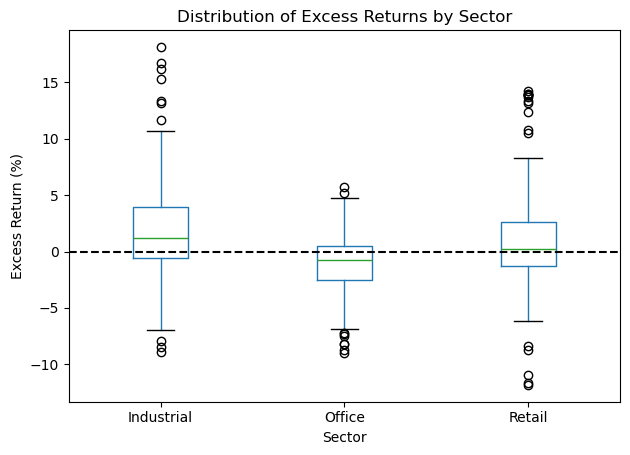

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_excel("Final_Regression_Dataset.xlsx")

# Create figure
plt.figure(figsize=(9,6))

df.boxplot(
    column="excess_return",
    by="sector",
    grid=False
)

plt.axhline(
    y=0,
    linestyle="--",
    color="black"
)

plt.title("Distribution of Excess Returns by Sector")
plt.suptitle("")  # Removes default pandas title
plt.xlabel("Sector")
plt.ylabel("Excess Return (%)")

plt.tight_layout()

plt.savefig(
    "H1_Boxplot_Excess_Returns.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 1000x600 with 0 Axes>

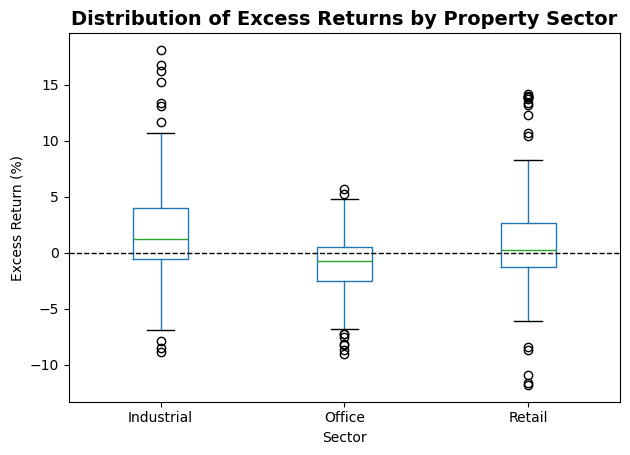

In [12]:
plt.figure(figsize=(10,6))

df.boxplot(
    column="excess_return",
    by="sector",
    grid=False
)

plt.axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.title(
    "Distribution of Excess Returns by Property Sector",
    fontsize=14,
    fontweight="bold"
)

plt.suptitle("")

plt.xlabel("Sector")
plt.ylabel("Excess Return (%)")

plt.tight_layout()

plt.savefig(
    "Figure_H1_Boxplot_Excess_Returns.png",
    dpi=600,
    bbox_inches="tight"
)

In [1]:
X1 = sm.add_constant(
    df[
        [
            "income_return",
            "capital_return"
        ]
    ]
)

m1 = sm.OLS(
    df["excess_return"],
    X1
).fit(
    cov_type="HAC",
    cov_kwds={"maxlags":4}
)

print(m1.summary())

NameError: name 'sm' is not defined

In [2]:
import pandas as pd
import statsmodels.api as sm

In [3]:
import pandas as pd
import statsmodels.api as sm

df = pd.read_excel("regression_dataset.xlsx")


In [4]:
X1 = sm.add_constant(
    df[
        [
            "income_return",
            "capital_return"
        ]
    ]
)

m1 = sm.OLS(
    df["excess_return"],
    X1
).fit(
    cov_type="HAC",
    cov_kwds={"maxlags":4}
)

print(m1.summary())

                            OLS Regression Results                            
Dep. Variable:          excess_return   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.143
Method:                 Least Squares   F-statistic:                     6.967
Date:                Wed, 05 Aug 2026   Prob (F-statistic):            0.00104
Time:                        17:26:00   Log-Likelihood:                -1344.9
No. Observations:                 486   AIC:                             2696.
Df Residuals:                     483   BIC:                             2708.
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -2.5775      2.098     -1.

In [5]:
X2 = sm.add_constant(
    df[
        [
            "cap_rate",
            "discount_rate"
        ]
    ].dropna()
)

y2 = df.loc[
    X2.index,
    "excess_return"
]

m2 = sm.OLS(
    y2,
    X2
).fit(
    cov_type="HAC",
    cov_kwds={"maxlags":4}
)

print(m2.summary())

                            OLS Regression Results                            
Dep. Variable:          excess_return   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.004
Method:                 Least Squares   F-statistic:                   0.06301
Date:                Wed, 05 Aug 2026   Prob (F-statistic):              0.939
Time:                        17:26:29   Log-Likelihood:                -1031.2
No. Observations:                 383   AIC:                             2068.
Df Residuals:                     380   BIC:                             2080.
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.2130      2.822      0.075

In [6]:
import statsmodels.api as sm

model3_df = df[
    [
        "excess_return",
        "income_return",
        "capital_return",
        "cap_rate",
        "discount_rate"
    ]
].dropna()

X3 = sm.add_constant(
    model3_df[
        [
            "income_return",
            "capital_return",
            "cap_rate",
            "discount_rate"
        ]
    ]
)

y3 = model3_df["excess_return"]

m3 = sm.OLS(
    y3,
    X3
).fit(
    cov_type="HAC",
    cov_kwds={"maxlags":4}
)

print(m3.summary())

                            OLS Regression Results                            
Dep. Variable:          excess_return   R-squared:                       0.336
Model:                            OLS   Adj. R-squared:                  0.329
Method:                 Least Squares   F-statistic:                     5.304
Date:                Wed, 05 Aug 2026   Prob (F-statistic):           0.000364
Time:                        17:27:11   Log-Likelihood:                -952.88
No. Observations:                 383   AIC:                             1916.
Df Residuals:                     378   BIC:                             1935.
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -1.3839      1.989     -0.

In [7]:
df = df.sort_values(["sector", "quarter_end"])

df["lag_excess_return"] = (
    df.groupby("sector")["excess_return"]
      .shift(1)
)

h3 = df[
    ["excess_return", "lag_excess_return"]
].dropna()

X = sm.add_constant(h3["lag_excess_return"])

m_h3 = sm.OLS(
    h3["excess_return"],
    X
).fit(
    cov_type="HAC",
    cov_kwds={"maxlags":4}
)

print(m_h3.summary())
``

SyntaxError: invalid syntax (3043358100.py, line 23)

In [8]:
df = df.sort_values(["sector", "quarter_end"])

df["lag_excess_return"] = (
    df.groupby("sector")["excess_return"]
      .shift(1)
)

h3 = df[
    ["excess_return", "lag_excess_return"]
].dropna()

X = sm.add_constant(h3["lag_excess_return"])

m_h3 = sm.OLS(
    h3["excess_return"],
    X
).fit(
    cov_type="HAC",
    cov_kwds={"maxlags":4}
)

print(m_h3.summary())

                            OLS Regression Results                            
Dep. Variable:          excess_return   R-squared:                       0.950
Model:                            OLS   Adj. R-squared:                  0.949
Method:                 Least Squares   F-statistic:                     1514.
Date:                Wed, 05 Aug 2026   Prob (F-statistic):          1.12e-150
Time:                        17:27:52   Log-Likelihood:                -654.49
No. Observations:                 483   AIC:                             1313.
Df Residuals:                     481   BIC:                             1321.
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.0137      0.06

In [9]:
corr = model3_df[
    [
        "excess_return",
        "income_return",
        "capital_return",
        "cap_rate",
        "discount_rate"
    ]
].corr()

print(corr.round(3))

                excess_return  income_return  capital_return  cap_rate  \
excess_return           1.000          0.102           0.571     0.025   
income_return           0.102          1.000           0.056     0.967   
capital_return          0.571          0.056           1.000    -0.065   
cap_rate                0.025          0.967          -0.065     1.000   
discount_rate           0.017          0.892          -0.022     0.910   

                discount_rate  
excess_return           0.017  
income_return           0.892  
capital_return         -0.022  
cap_rate                0.910  
discount_rate           1.000  


In [10]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()

vif["Variable"] = X3.columns

vif["VIF"] = [
    variance_inflation_factor(X3.values, i)
    for i in range(X3.shape[1])
]

print(vif)

         Variable        VIF
0           const  23.736784
1   income_return  20.034061
2  capital_return   1.293113
3        cap_rate  23.442080
4   discount_rate   5.929750


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = model3_df[
    [
        "excess_return",
        "income_return",
        "capital_return",
        "cap_rate",
        "discount_rate"
    ]
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="RdBu_r",
    center=0,
    square=True,
    fmt=".2f"
)

plt.title("Correlation Matrix of Valuation-Chain Variables")
plt.tight_layout()

plt.savefig(
    "H2_Correlation_Heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


ModuleNotFoundError: No module named 'seaborn'

In [12]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [13]:
import seaborn as sns

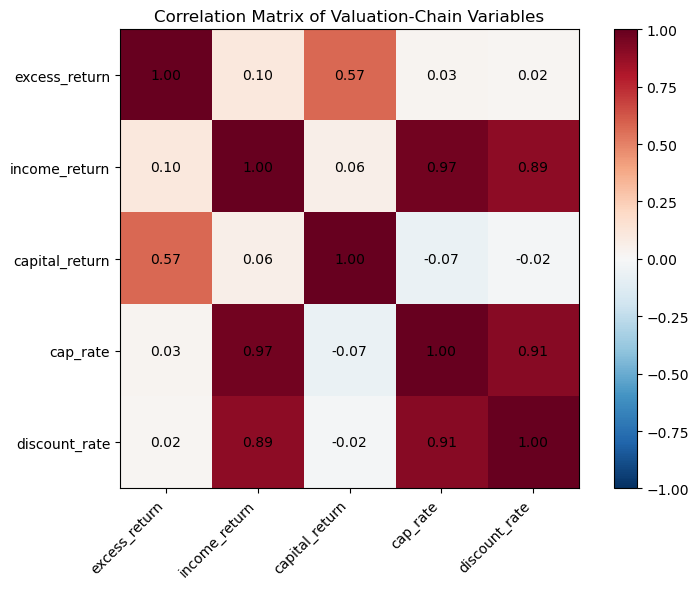

In [14]:
import matplotlib.pyplot as plt
import numpy as np

corr = model3_df[
    [
        "excess_return",
        "income_return",
        "capital_return",
        "cap_rate",
        "discount_rate"
    ]
].corr()

fig, ax = plt.subplots(figsize=(8,6))

im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")

ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)

for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(
            j,
            i,
            f"{corr.iloc[i,j]:.2f}",
            ha="center",
            va="center"
        )

plt.colorbar(im)

plt.title("Correlation Matrix of Valuation-Chain Variables")

plt.tight_layout()

plt.savefig(
    "H2_Correlation_Heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

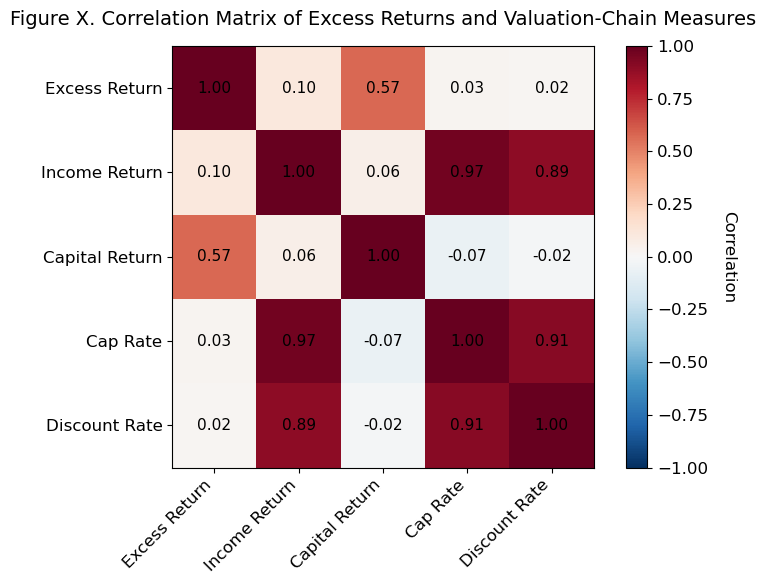

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Correlation matrix
corr = model3_df[
    [
        "excess_return",
        "income_return",
        "capital_return",
        "cap_rate",
        "discount_rate"
    ]
].corr()

# Publication labels
labels = [
    "Excess Return",
    "Income Return",
    "Capital Return",
    "Cap Rate",
    "Discount Rate"
]

# Dissertation formatting
plt.rcParams.update({
    "font.size": 12
})

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(
    corr,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1
)

# Axis labels
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))

ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)

# Correlation values
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=11,
            color="black"
        )

# Colour bar
cbar = plt.colorbar(im)
cbar.ax.set_ylabel("Correlation", rotation=270, labelpad=20)

# Title
plt.title(
    "Figure X. Correlation Matrix of Excess Returns and Valuation-Chain Measures",
    pad=15,
    fontsize=14
)

plt.tight_layout()

# High-resolution export
plt.savefig(
    "Figure_H2_Correlation_Matrix.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

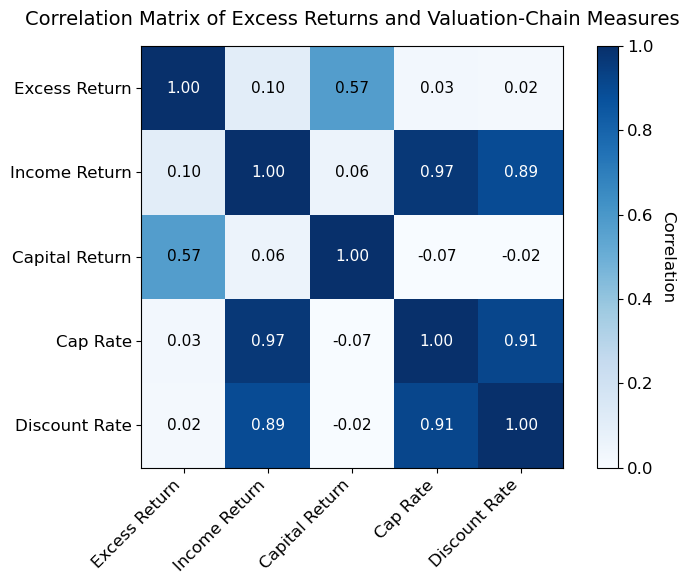

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Correlation matrix
corr = model3_df[
    [
        "excess_return",
        "income_return",
        "capital_return",
        "cap_rate",
        "discount_rate"
    ]
].corr()

labels = [
    "Excess Return",
    "Income Return",
    "Capital Return",
    "Cap Rate",
    "Discount Rate"
]

# Academic formatting
plt.rcParams.update({
    "font.size": 12
})

fig, ax = plt.subplots(figsize=(8, 6))

# Clean blue colour scale
im = ax.imshow(
    corr,
    cmap="Blues",
    vmin=0,
    vmax=1
)

# Axis labels
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))

ax.set_xticklabels(
    labels,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(labels)

# Correlation values
for i in range(len(corr)):
    for j in range(len(corr)):
        value = corr.iloc[i, j]

        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=11,
            color="white" if value > 0.75 else "black"
        )

# Colour bar
cbar = plt.colorbar(im)
cbar.ax.set_ylabel(
    "Correlation",
    rotation=270,
    labelpad=15
)

# Title
plt.title(
    "Correlation Matrix of Excess Returns and Valuation-Chain Measures",
    fontsize=14,
    pad=15
)

plt.tight_layout()

# Export high-quality image
plt.savefig(
    "H2_Correlation_Matrix.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Correlation matrix
corr = model3_df[
    [
        "excess_return",
        "income_return",
        "capital_return",
        "cap_rate",
        "discount_rate"
    ]
].corr()

labels = [
    "Excess Return",
    "Income Return",
    "Capital Return",
    "Cap Rate",
    "Discount Rate"
]

# Academic formatting
plt.rcParams.update({
    "font.size": 12
})

fig, ax = plt.subplots(figsize=(9, 7))

# Heatmap
im = ax.imshow(
    corr,
    cmap="Blues",
    vmin=0,
    vmax=1
)

# Axis labels
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))

ax.set_xticklabels(
    labels,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(labels)

# Correlation values
for i in range(len(corr)):
    for j in range(len(corr)):
        value = corr.iloc[i, j]

        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=11,
            color="white" if value >= 0.75 else "black"
        )

# Colour bar
cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.ax.set_ylabel(
    "Correlation",
    rotation=270,
    labelpad=20
)

# Title
ax.set_title(
    "Correlation Matrix of Excess Returns and Valuation Variables",
    fontsize=15,
    pad=15
)

plt.tight_layout()

# Export
plt.savefig(
    "Figure_H2_Correlation_Matrix.png",
    dpi

_IncompleteInputError: incomplete input (2016408972.py, line 85)

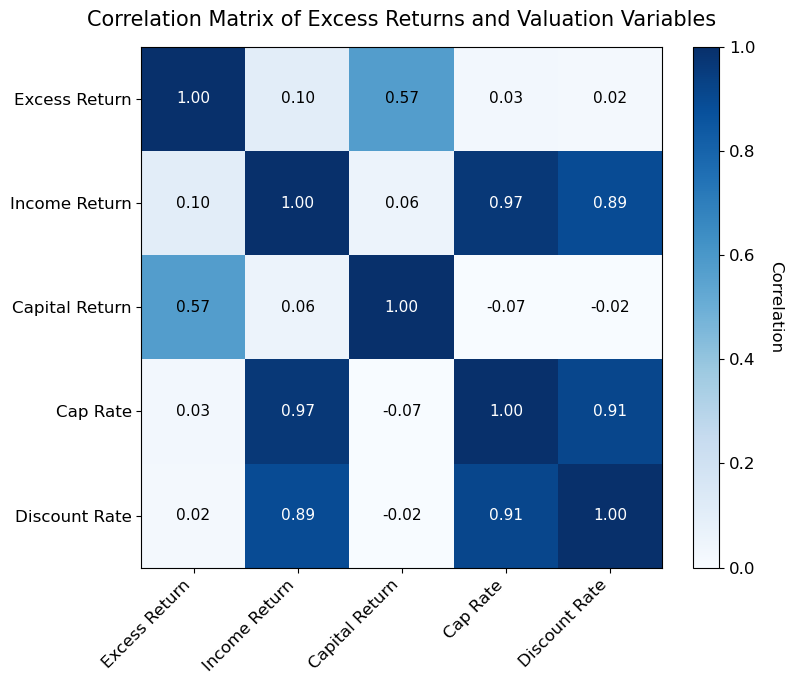

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Correlation matrix
corr = model3_df[
    [
        "excess_return",
        "income_return",
        "capital_return",
        "cap_rate",
        "discount_rate"
    ]
].corr()

labels = [
    "Excess Return",
    "Income Return",
    "Capital Return",
    "Cap Rate",
    "Discount Rate"
]

# Academic formatting
plt.rcParams.update({
    "font.size": 12
})

fig, ax = plt.subplots(figsize=(9, 7))

# Heatmap
im = ax.imshow(
    corr,
    cmap="Blues",
    vmin=0,
    vmax=1
)

# Axis labels
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))

ax.set_xticklabels(
    labels,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(labels)

# Correlation values
for i in range(len(corr)):
    for j in range(len(corr)):
        value = corr.iloc[i, j]

        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=11,
            color="white" if value >= 0.75 else "black"
        )

# Colour bar
cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.ax.set_ylabel(
    "Correlation",
    rotation=270,
    labelpad=20
)

# Title
ax.set_title(
    "Correlation Matrix of Excess Returns and Valuation Variables",
    fontsize=15,
    pad=15
)

plt.tight_layout()

# Export
plt.savefig(
    "Figure_H2_Correlation_Matrix.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

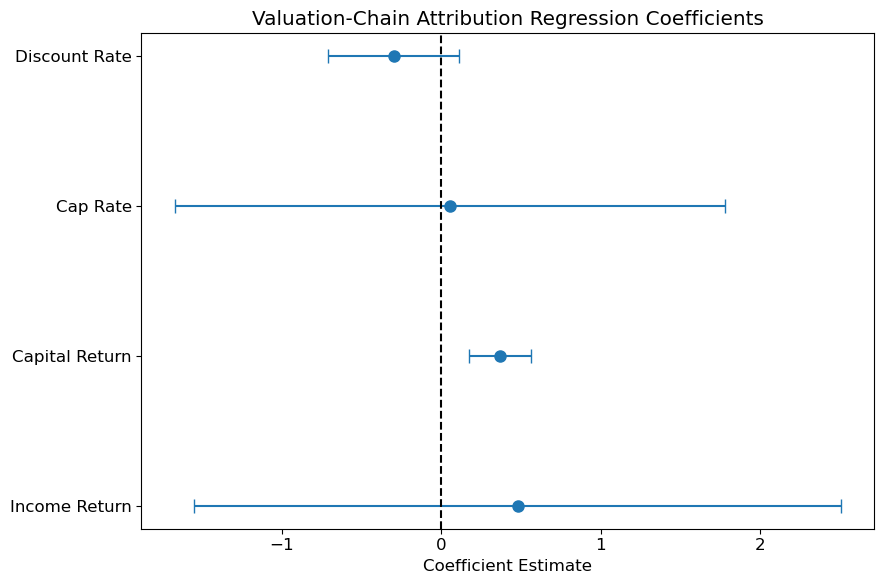

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract coefficients
coef = m3.params
ci = m3.conf_int()

coef_df = pd.DataFrame({
    "Coefficient": coef,
    "Lower": ci[0],
    "Upper": ci[1]
})

# Remove intercept
coef_df = coef_df.drop("const")

# Pretty labels
coef_df.index = [
    "Income Return",
    "Capital Return",
    "Cap Rate",
    "Discount Rate"
]

plt.figure(figsize=(9,6))

plt.errorbar(
    coef_df["Coefficient"],
    coef_df.index,
    xerr=[
        coef_df["Coefficient"] - coef_df["Lower"],
        coef_df["Upper"] - coef_df["Coefficient"]
    ],
    fmt='o',
    capsize=5,
    markersize=8
)

plt.axvline(
    0,
    color='black',
    linestyle='--'
)

plt.xlabel("Coefficient Estimate")
plt.ylabel("")

plt.title(
    "Valuation-Chain Attribution Regression Coefficients"
)

plt.tight_layout()

plt.savefig(
    "Figure_H2_Coefficient_Plot.png",
    dpi=600,
    bbox_inches='tight'
)

plt.show()

In [1]:
# ============================================================
# H3: Persistence in Sector Excess Returns
# ============================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Load Dataset
# ------------------------------------------------------------

df = pd.read_excel("Final_Regression_Dataset.xlsx")

# ------------------------------------------------------------
# Prepare Data
# ------------------------------------------------------------

df["quarter_end"] = pd.to_datetime(df["quarter_end"])

df = df.sort_values(
    ["sector", "quarter_end"]
).reset_index(drop=True)

# ------------------------------------------------------------
# Create Lagged Excess Returns
# ------------------------------------------------------------

df["ER_L1"] = (
    df.groupby("sector")["excess_return"]
      .shift(1)
)

df["ER_L2"] = (
    df.groupby("sector")["excess_return"]
      .shift(2)
)

# ============================================================
# AR(1) MODEL
# ER_t = α + βER_t−1 + ε
# ============================================================

ar1_df = df.dropna(
    subset=["excess_return", "ER_L1"]
).copy()

X_ar1 = sm.add_constant(ar1_df["ER_L1"])
y_ar1 = ar1_df["excess_return"]

ar1_model = sm.OLS(
    y_ar1,
    X_ar1
).fit(
    cov_type="HAC",
    cov_kwds={"maxlags": 4}
)

print("="*70)
print("H3: AR(1) PERSISTENCE MODEL")
print("="*70)

print(ar1_model.summary())

# ============================================================
# AR(2) MODEL
# ER_t = α + β1ER_t−1 + β2ER_t−2 + ε
# ============================================================

ar2_df = df.dropna(
    subset=["excess_return", "ER_L1", "ER_L2"]
).copy()

X_ar2 = sm.add_constant(
    ar2_df[["ER_L1", "ER_L2"]]
)

y_ar2 = ar2_df["excess_return"]

ar2_model = sm.OLS(
    y_ar2,
    X_ar2
).fit(
    cov_type="HAC",
    cov_kwds={"maxlags": 4}
)

print("\n")
print("="*70)
print("H3: AR(2) ROBUSTNESS MODEL")
print("="*70)

print(ar2_model.summary())

# ============================================================
# RESULTS TABLE
# ============================================================

results = pd.DataFrame(
    {
        "Variable": [
            "Intercept",
            "ER_L1 (AR1)",
            "Intercept",
            "ER_L1 (AR2)",
            "ER_L2 (AR2)"
        ],

        "Coefficient": [
            ar1_model.params["const"],
            ar1_model.params["ER_L1"],
            ar2_model.params["const"],
            ar2_model.params["ER_L1"],
            ar2_model.params["ER_L2"]
        ],

        "HAC Std Error": [
            ar1_model.bse["const"],
            ar1_model.bse["ER_L1"],
            ar2_model.bse["const"],
            ar2_model.bse["ER_L1"],
            ar2_model.bse["ER_L2"]
        ],

        "p-value": [
            ar1_model.pvalues["const"],
            ar1_model.pvalues["ER_L1"],
            ar2_model.pvalues["const"],
            ar2_model.pvalues["ER_L1"],
            ar2_model.pvalues["ER_L2"]
        ]
    }
)

print("\n")
print("="*70)
print("PUBLICATION TABLE")
print("="*70)

print(results

_IncompleteInputError: incomplete input (74352758.py, line 141)

In [2]:
# ============================================================
# H3: Persistence in Sector Excess Returns
# ============================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Load Dataset
# ------------------------------------------------------------

df = pd.read_excel("Final_Regression_Dataset.xlsx")

# ------------------------------------------------------------
# Prepare Data
# ------------------------------------------------------------

df["quarter_end"] = pd.to_datetime(df["quarter_end"])

df = df.sort_values(
    ["sector", "quarter_end"]
).reset_index(drop=True)

# ------------------------------------------------------------
# Create Lagged Excess Returns
# ------------------------------------------------------------

df["ER_L1"] = (
    df.groupby("sector")["excess_return"]
      .shift(1)
)

df["ER_L2"] = (
    df.groupby("sector")["excess_return"]
      .shift(2)
)

# ============================================================
# AR(1) MODEL
# ER_t = α + βER_t−1 + ε
# ============================================================

ar1_df = df.dropna(
    subset=["excess_return", "ER_L1"]
).copy()

X_ar1 = sm.add_constant(ar1_df["ER_L1"])
y_ar1 = ar1_df["excess_return"]

ar1_model = sm.OLS(
    y_ar1,
    X_ar1
).fit(
    cov_type="HAC",
    cov_kwds={"maxlags": 4}
)

print("="*70)
print("H3: AR(1) PERSISTENCE MODEL")
print("="*70)

print(ar1_model.summary())

# ============================================================
# AR(2) MODEL
# ER_t = α + β1ER_t−1 + β2ER_t−2 + ε
# ============================================================

ar2_df = df.dropna(
    subset=["excess_return", "ER_L1", "ER_L2"]
).copy()

X_ar2 = sm.add_constant(
    ar2_df[["ER_L1", "ER_L2"]]
)

y_ar2 = ar2_df["excess_return"]

ar2_model = sm.OLS(
    y_ar2,
    X_ar2
).fit(
    cov_type="HAC",
    cov_kwds={"maxlags": 4}
)

print("\n")
print("="*70)
print("H3: AR(2) ROBUSTNESS MODEL")
print("="*70)

print(ar2_model.summary())

# ============================================================
# RESULTS TABLE
# ============================================================

results = pd.DataFrame(
    {
        "Variable": [
            "Intercept",
            "ER_L1 (AR1)",
            "Intercept",
            "ER_L1 (AR2)",
            "ER_L2 (AR2)"
        ],

        "Coefficient": [
            ar1_model.params["const"],
            ar1_model.params["ER_L1"],
            ar2_model.params["const"],
            ar2_model.params["ER_L1"],
            ar2_model.params["ER_L2"]
        ],

        "HAC Std Error": [
            ar1_model.bse["const"],
            ar1_model.bse["ER_L1"],
            ar2_model.bse["const"],
            ar2_model.bse["ER_L1"],
            ar2_model.bse["ER_L2"]
        ],

        "p-value": [
            ar1_model.pvalues["const"],
            ar1_model.pvalues["ER_L1"],
            ar2_model.pvalues["const"],
            ar2_model.pvalues["ER_L1"],
            ar2_model.pvalues["ER_L2"]
        ]
    }
)

print("\n")
print("="*70)
print("PUBLICATION TABLE")
print("="*70)

print(results)

H3: AR(1) PERSISTENCE MODEL
                            OLS Regression Results                            
Dep. Variable:          excess_return   R-squared:                       0.950
Model:                            OLS   Adj. R-squared:                  0.949
Method:                 Least Squares   F-statistic:                     1514.
Date:                Fri, 07 Aug 2026   Prob (F-statistic):          1.12e-150
Time:                        17:12:25   Log-Likelihood:                -654.49
No. Observations:                 483   AIC:                             1313.
Df Residuals:                     481   BIC:                             1321.
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0137   

In [3]:
df[["sector","quarter_end","excess_return","ER_L1"]].head(20)


,sector,quarter_end,excess_return,ER_L1
0,Industrial,1985-12-01,-1.270779,NaN
1,Industrial,1986-03-01,-0.642015,-1.270779
2,Industrial,1986-06-01,-0.576101,-0.642015
3,Industrial,1986-09-01,-0.593717,-0.576101
4,Industrial,1986-12-01,-1.076831,-0.593717
5,Industrial,1987-03-01,-2.178731,-1.076831
6,Industrial,1987-06-01,-3.178379,-2.178731
7,Industrial,1987-09-01,-5.668770,-3.178379
8,Industrial,1987-12-01,-7.919527,-5.668770
9,Industrial,1988-03-01,-8.468272,-7.919527


In [4]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df["excess_return"].dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -5.334876429305312
p-value: 4.634625081048463e-06


In [5]:
from statsmodels.tsa.stattools import adfuller

for sector in df["sector"].unique():

    temp = df[df["sector"] == sector]["excess_return"].dropna()

    result = adfuller(temp)

    print("\n" + sector)
    print("ADF Statistic:", round(result[0],4))
    print("p-value:", round(result[1],6))


Industrial
ADF Statistic: -3.1694
p-value: 0.021829

Office
ADF Statistic: -3.0004
p-value: 0.034857

Retail
ADF Statistic: -3.0918
p-value: 0.027166


In [6]:
for sector in df["sector"].unique():

    temp = df[df["sector"] == sector].copy()

    X = sm.add_constant(temp["ER_L1"])
    y = temp["excess_return"]

    model = sm.OLS(
        y.dropna(),
        X.loc[y.dropna().index]
    ).fit(
        cov_type="HAC",
        cov_kwds={"maxlags":4}
    )

    print("\n")
    print("="*50)
    print(sector)
    print("="*50)

    print(model.summary())


MissingDataError: exog contains inf or nans

In [7]:
for sector in df["sector"].unique():

    temp = df[df["sector"] == sector].copy()

    # Keep only observations where lag exists
    temp = temp.dropna(subset=["ER_L1", "excess_return"])

    X = sm.add_constant(temp["ER_L1"])
    y = temp["excess_return"]

    model = sm.OLS(
        y,
        X
    ).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": 4}
    )

    print("\n")
    print("=" * 50)
    print(sector)
    print("=" * 50)

    print(model.summary())



Industrial
                            OLS Regression Results                            
Dep. Variable:          excess_return   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.935
Method:                 Least Squares   F-statistic:                     364.9
Date:                Fri, 07 Aug 2026   Prob (F-statistic):           5.10e-43
Time:                        17:15:09   Log-Likelihood:                -238.75
No. Observations:                 161   AIC:                             481.5
Df Residuals:                     159   BIC:                             487.7
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0707      0.119      0

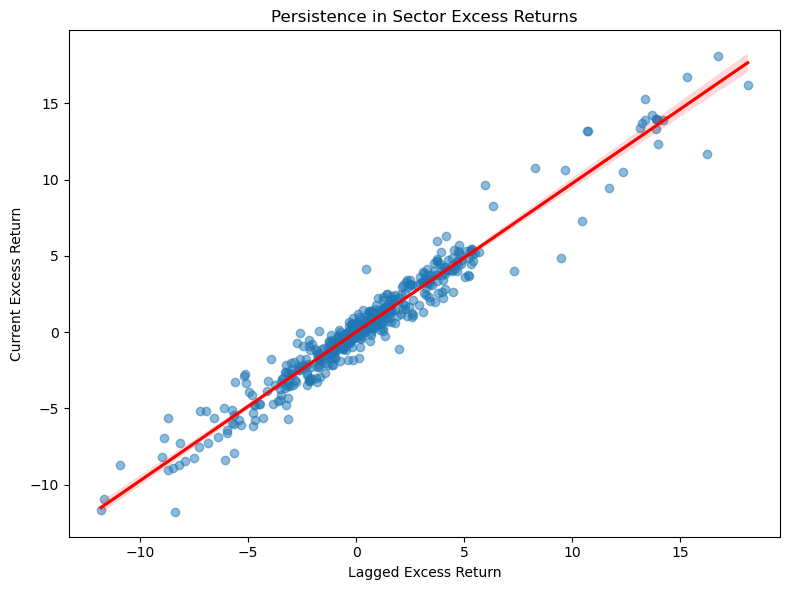

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.regplot(
    data=ar1_df,
    x="ER_L1",
    y="excess_return",
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)

plt.xlabel("Lagged Excess Return")
plt.ylabel("Current Excess Return")
plt.title("Persistence in Sector Excess Returns")

plt.tight_layout()
plt.show()


In [9]:
plt.savefig(
    "Figure_H3_Persistence_Scatterplot.png",
    dpi=600,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [10]:
import os

print(os.getcwd())

C:\Users\DanielKrivan


In [11]:
plt.tight_layout()

plt.savefig(
    "Figure_H3_Persistence_Scatterplot.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

Saved successfully:
C:\Users\DanielKrivan\Figure_H3_Persistence_Scatterplot.png

File exists:
True

Files in current folder:
Figure_1_Benchmark_Evolution.png
Figure_2_Mean_Excess_Returns_by_Regime.png
Figure_2_Total_Returns_by_Sector.png
Figure_3_Income_Capital_Returns.png
Figure_4_Capitalisation_Rates_by_Sector.png
Figure_5_Cap_Rates_vs_Bond_Yield.png
Figure_5_Heatmap_Improved.png
Figure_Excess_Return_Heatmap_Chronological.png
Figure_H1_Boxplot_Excess_Returns.png
Figure_H3_Persistence_Scatterplot.png
Figure_Returns_vs_Bond_Yield.png
H1_Boxplot_Excess_Returns.png
H2_Correlation_Heatmap.png
H2_Correlation_Matrix.png
Table_1_Benchmark_Weights.png
Table_2_Benchmark_Robustness.png
Table_2_Descriptive_Statistics_Final.png
Table_3_Benchmark_Robustness.png
Table_3_Descriptive_Statistics.png
Table_4_Economic_Regime_Definitions.png
Table_5_Economic_Regime_Characteristics.png
Table_5_Economic_Regime_Characteristics_Final.png
Table_6_Excess_Returns.png
Table_7_Income_Returns.png
Table_8_Capital_R

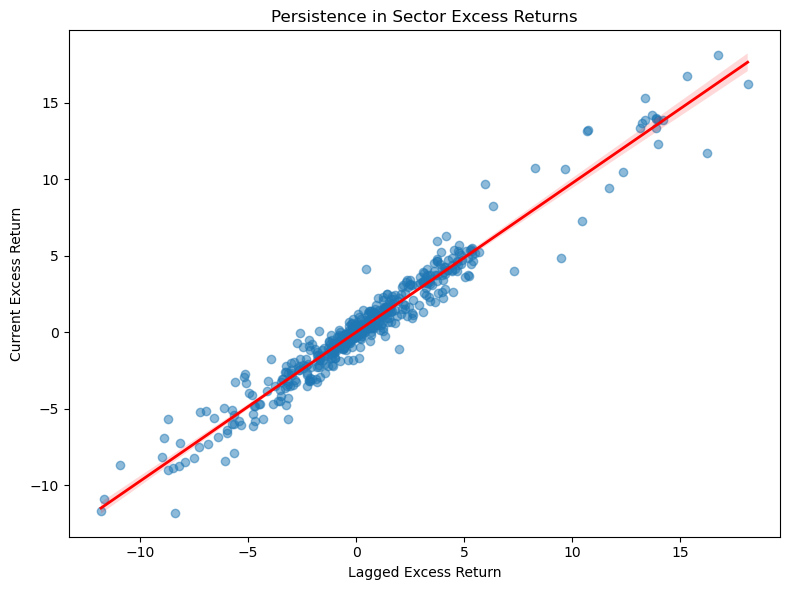

In [12]:
import os
import seaborn as sns
import matplotlib.pyplot as plt

# ----------------------------------------------------
# Create figure
# ----------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 6))

sns.regplot(
    data=ar1_df,
    x="ER_L1",
    y="excess_return",
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red", "linewidth": 2},
    ax=ax
)

ax.set_title("Persistence in Sector Excess Returns")
ax.set_xlabel("Lagged Excess Return")
ax.set_ylabel("Current Excess Return")

# ----------------------------------------------------
# Save file
# ----------------------------------------------------

output_file = os.path.join(
    os.getcwd(),
    "Figure_H3_Persistence_Scatterplot.png"
)

fig.tight_layout()

fig.savefig(
    output_file,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

# ----------------------------------------------------
# Verify save worked
# ----------------------------------------------------

print("Saved successfully:")
print(output_file)

print("\nFile exists:")
print(os.path.exists(output_file))

print("\nFiles in current folder:")
for file in os.listdir():
    if file.endswith(".png"):
        print(file)

# ----------------------------------------------------
# Display chart
# ----------------------------------------------------

plt.show()

In [13]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox, acorr_breusch_godfrey

# ==========================================================
# DATA PREP
# ==========================================================

df = df.sort_values(['Sector', 'Date']).copy()

# Lag excess returns within sector
df['ER_L1'] = df.groupby('Sector')['Excess_Return'].shift(1)

analysis_df = df.dropna(subset=['ER_L1']).copy()

print("="*70)
print("SECTOR-SPECIFIC AR(1) REGRESSIONS")
print("="*70)

# ==========================================================
# 1. SECTOR-SPECIFIC AR(1)
# ==========================================================

for sector in analysis_df['Sector'].unique():

    temp = analysis_df[analysis_df['Sector'] == sector]

    X = sm.add_constant(temp['ER_L1'])
    y = temp['Excess_Return']

    model = sm.OLS(y, X).fit(
        cov_type='HAC',
        cov_kwds={'maxlags':4}
    )

    rho = model.params['ER_L1']

    if 0 < rho < 1:
        half_life = np.log(0.5) / np.log(rho)
    else:
        half_life = np.nan

    print(f"\n{sector}")
    print(model.summary())

    print(f"\nPersistence coefficient: {rho:.4f}")

    if not np.isnan(half_life):
        print(f"Half-life: {half_life:.2f} quarters")
        print(f"Half-life: {half_life/4:.2f} years")
    else:
        print("Half-life not defined")

# ==========================================================
# 2. FIXED EFFECTS PANEL MODEL
# ==========================================================

print("\n")
print("="*70)
print("FIXED EFFECTS PANEL AR(1)")
print("="*70)

sector_dummies = pd.get_dummies(
    analysis_df['Sector'],
    drop_first=True
)

X_fe = pd.concat(
    [analysis_df[['ER_L1']], sector_dummies],
    axis=1
)

X_fe = sm.add_constant(X_fe)

fe_model = sm.OLS(
    analysis_df['Excess_Return'],
    X_fe.astype(float)
).fit(
    cov_type='HAC',
    cov_kwds={'maxlags':4}
)

print(fe_model.summary())

rho_fe = fe_model.params['ER_L1']

if 0 < rho_fe < 1:
    hl_fe = np.log(0.5) / np.log(rho_fe)

    print(f"\nFixed-effects persistence coefficient: {rho_fe:.4f}")
    print(f"Half-life: {hl_fe:.2f} quarters")
    print(f"Half-life: {hl_fe/4:.2f} years")

# ==========================================================
# 3. POOLED AR(1) FOR RESIDUAL TESTS
# ==========================================================

print("\n")
print("="*70)
print("RESIDUAL DIAGNOSTICS")
print("="*70)

X = sm.add_constant(analysis_df['ER_L1'])
y = analysis_df['Excess_Return']

pooled_model = sm.OLS(y, X).fit()

# Ljung-Box test
ljung_box = acorr_ljungbox(
    pooled_model.resid,
    lags=[4,8],
    return_df=True
)

print("\nLJUNG-BOX TEST")
print(ljung_box)

# Breusch-Godfrey test
bg = acorr_breusch_godfrey(
    pooled_model,
    nlags=4
)

print("\nBREUSCH-GODFREY TEST")
print(f"LM Statistic: {bg.4f}")
print(f"LM p-value:   {bg.4f}")
print(f"F Statistic:  {bg[2]:")
print(f"F p-value:    {bg.4f}")

# ==========================================================
# 4. INTERPRETATION FLAGS
# ==========================================================

print("\n")
print("="*70)
print("QUICK INTERPRETATION")
print("="*70)

print(
"""
Sector AR(1):
- Persistence should remain significant within each sector.
- Large drops vs pooled AR(1) suggest pooling inflated persistence.

Fixed Effects:
- If ER_L1 remains strongly significant, persistence is not
  simply driven by differences between sectors.

Ljung-Box:
- p < 0.05 => residual autocorrelation remains.

Breusch-Godfrey:
- p < 0.05 => additional serial dependence remains.

Half-life:
- < 4 quarters = modest persistence
- 4-12 quarters = strong persistence
- > 20 quarters = extremely persistent and likely deserves
  discussion of appraisal smoothing.
"""
)

SyntaxError: invalid decimal literal (2557320308.py, line 126)

In [14]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox, acorr_breusch_godfrey

# ==========================================================
# DATA PREP
# ==========================================================

df = df.sort_values(['Sector', 'Date']).copy()

# Create lagged excess returns within sector
df['ER_L1'] = df.groupby('Sector')['Excess_Return'].shift(1)

analysis_df = df.dropna(subset=['ER_L1']).copy()

print("=" * 70)
print("SECTOR-SPECIFIC AR(1) REGRESSIONS")
print("=" * 70)

# ==========================================================
# 1. SECTOR-SPECIFIC AR(1)
# ==========================================================

for sector in analysis_df['Sector'].unique():

    temp = analysis_df[analysis_df['Sector'] == sector]

    X = sm.add_constant(temp['ER_L1'])
    y = temp['Excess_Return']

    model = sm.OLS(y, X).fit(
        cov_type='HAC',
        cov_kwds={'maxlags': 4}
    )

    rho = model.params['ER_L1']

    if 0 < rho < 1:
        half_life = np.log(0.5) / np.log(rho)
    else:
        half_life = np.nan

    print(f"\n{sector}")
    print("-" * 50)
    print(model.summary())

    print(f"\nPersistence coefficient: {rho:.4f}")

    if not np.isnan(half_life):
        print(f"Half-life: {half_life:.2f} quarters")
        print(f"Half-life: {half_life/4:.2f} years")
    else:
        print("Half-life not defined")

# ==========================================================
# 2. FIXED EFFECTS PANEL MODEL
# ==========================================================

print("\n")
print("=" * 70)
print("FIXED EFFECTS PANEL AR(1)")
print("=" * 70)

sector_dummies = pd.get_dummies(
    analysis_df['Sector'],
    drop_first=True
)

X_fe = pd.concat(
    [analysis_df[['ER_L1']], sector_dummies],
    axis=1
)

X_fe = sm.add_constant(X_fe)

fe_model = sm.OLS(
    analysis_df['Excess_Return'],
    X_fe.astype(float)
).fit(
    cov_type='HAC',
    cov_kwds={'maxlags': 4}
)

print(fe_model.summary())

rho_fe = fe_model.params['ER_L1']

if 0 < rho_fe < 1:
    hl_fe = np.log(0.5) / np.log(rho_fe)

    print(f"\nFixed-effects persistence coefficient: {rho_fe:.4f}")
    print(f"Half-life: {hl_fe:.2f} quarters")
    print(f"Half-life: {hl_fe/4:.2f} years")

# ==========================================================
# 3. POOLED AR(1) FOR RESIDUAL TESTS
# ==========================================================

print("\n")
print("=" * 70)
print("RESIDUAL DIAGNOSTICS")
print("=" * 70)

X = sm.add_constant(analysis_df['ER_L1'])
y = analysis_df['Excess_Return']

pooled_model = sm.OLS(y, X).fit()

# ----------------------------------------------------------
# Ljung-Box Test
# ----------------------------------------------------------

ljung_box = acorr_ljungbox(
    pooled_model.resid,
    lags=[4, 8],
    return_df=True
)

print("\nLJUNG-BOX TEST")
print(ljung_box)

# ----------------------------------------------------------
# Breusch-Godfrey Test
# ----------------------------------------------------------

bg = acorr_breusch_godfrey(
    pooled_model,
    nlags=4
)

print("\nBREUSCH-GODFREY TEST")
print(f"LM Statistic: {bg.4f}")
print(f"LM p-value:   {bg.4f}")
print(f"F Statistic:  {bg.4f}")
print(f"F p-value:    {bg.4f}")

# ==========================================================
# 4. POOLED HALF-LIFE
# ==========================================================

rho_pooled = pooled_model.params['ER_L1']

print("\n")
print("=" * 70)
print("POOLED AR(1) PERSISTENCE")
print("=" * 70)

print(f"AR(1) coefficient: {rho_pooled:.4f}")

if 0 < rho_pooled < 1:
    pooled_half_life = np.log(0.5) / np.log(rho_pooled)

    print(f"Half-life: {pooled_half_life:.2f} quarters")
    print(f"Half-life: {pooled_half_life/4:.2f} years")

# ==========================================================
# INTERPRETATION GUIDE
# ==========================================================

print("\n")
print("=" * 70)
print("INTERPRETATION GUIDE")
print("=" * 70)

print("""
Sector-specific AR(1)
---------------------
If persistence remains significant within each sector,
the result is unlikely to be driven solely by pooling.

Fixed-effects AR(1)
-------------------
If the ER_L1 coefficient remains large and significant
after controlling for sector fixed effects, persistence
is not simply due to structural differences between sectors.

Ljung-Box Test
--------------
p < 0.05  -> residual autocorrelation remains.
p > 0.05  -> no evidence of remaining autocorrelation.

Breusch-Godfrey Test
--------------------
p < 0.05  -> additional serial dependence remains.
p > 0.05  -> AR(1) adequately captures persistence.

Half-life
---------
< 4 quarters   = modest persistence
4-12 quarters  = strong persistence
> 20 quarters  = extremely persistent and may indicate
                 appraisal smoothing effects.
""")

SyntaxError: invalid decimal literal (25396791.py, line 133)

In [15]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox, acorr_breusch_godfrey

# ==========================================================
# DATA PREP
# ==========================================================

df = df.sort_values(['Sector', 'Date']).copy()

# Create sector-specific lag
df['ER_L1'] = df.groupby('Sector')['Excess_Return'].shift(1)

analysis_df = df.dropna(subset=['ER_L1']).copy()

# ==========================================================
# 1. SECTOR AR(1) MODELS
# ==========================================================

print("=" * 70)
print("SECTOR-SPECIFIC AR(1) REGRESSIONS")
print("=" * 70)

for sector in analysis_df['Sector'].unique():

    temp = analysis_df[analysis_df['Sector'] == sector]

    X = sm.add_constant(temp['ER_L1'])
    y = temp['Excess_Return']

    model = sm.OLS(y, X).fit(
        cov_type='HAC',
        cov_kwds={'maxlags': 4}
    )

    rho = model.params['ER_L1']

    print(f"\n{sector}")
    print("-" * 50)

    print(f"Coefficient: {rho:.4f}")
    print(f"P-value: {model.pvalues['ER_L1']:.4g}")
    print(f"R-squared: {model.rsquared:.4f}")

    if 0 < rho < 1:
        half_life = np.log(0.5) / np.log(rho)
        print(f"Half-life: {half_life:.2f} quarters")
        print(f"Half-life: {half_life/4:.2f} years")

# ==========================================================
# 2. FIXED EFFECTS PANEL MODEL
# ==========================================================

print("\n")
print("=" * 70)
print("FIXED EFFECTS PANEL AR(1)")
print("=" * 70)

sector_dummies = pd.get_dummies(
    analysis_df['Sector'],
    drop_first=True
)

X_fe = pd.concat(
    [analysis_df[['ER_L1']], sector_dummies],
    axis=1
)

X_fe = sm.add_constant(X_fe).astype(float)

fe_model = sm.OLS(
    analysis_df['Excess_Return'],
    X_fe
).fit(
    cov_type='HAC',
    cov_kwds={'maxlags': 4}
)

print(fe_model.summary())

rho_fe = fe_model.params['ER_L1']

print("\nFixed Effects Result")
print(f"AR(1) coefficient: {rho_fe:.4f}")
print(f"P-value: {fe_model.pvalues['ER_L1']:.4g}")

if 0 < rho_fe < 1:
    hl = np.log(0.5) / np.log(rho_fe)
    print(f"Half-life: {hl:.2f} quarters")
    print(f"Half-life: {hl/4:.2f} years")

# ==========================================================
# 3. POOLED AR(1)
# ==========================================================

print("\n")
print("=" * 70)
print("POOLED AR(1)")
print("=" * 70)

X_pool = sm.add_constant(analysis_df['ER_L1'])
y_pool = analysis_df['Excess_Return']

pooled_model = sm.OLS(
    y_pool,
    X_pool
).fit(
    cov_type='HAC',
    cov_kwds={'maxlags': 4}
)

print(pooled_model.summary())

rho_pool = pooled_model.params['ER_L1']

if 0 < rho_pool < 1:
    hl_pool = np.log(0.5) / np.log(rho_pool)

    print(f"\nPooled AR(1): {rho_pool:.4f}")
    print(f"Half-life: {hl_pool:.2f} quarters")
    print(f"Half-life: {hl_pool/4:.2f} years")

# ==========================================================
# 4. LJUNG-BOX TEST
# ==========================================================

print("\n")
print("=" * 70)
print("LJUNG-BOX TEST")
print("=" * 70)

lb = acorr_ljungbox(
    pooled_model.resid,
    lags=[4, 8],
    return_df=True
)

print(lb)

# ==========================================================
# 5. BREUSCH-GODFREY TEST
# ==========================================================

print("\n")
print("=" * 70)
print("BREUSCH-GODFREY TEST")
print("=" * 70)

lm_stat, lm_pvalue, f_stat, f_pvalue = acorr_breusch_godfrey(
    pooled_model,
    nlags=4
)

print(f"LM Statistic: {lm_stat:.4f}")
print(f"LM p-value:   {lm_pvalue:.4f}")
print(f"F Statistic:  {f_stat:.4f}")
print(f"F p-value:    {f_pvalue:.4f}")

# ==========================================================
# 6. FINAL SUMMARY
# ==========================================================

print("\n")
print("=" * 70)
print("SUMMARY")
print("=" * 70)

print("""
Questions to answer:

1. Do all three sectors have significant AR(1) coefficients?

2. Does the fixed-effects coefficient remain similar to the pooled coefficient?

3. Are Ljung-Box p-values > 0.05?

4. Is the Breusch-Godfrey p-value > 0.05?

Interpretation:
- If persistence remains after fixed effects, it is not merely a pooled-sector artifact.
- If residual autocorrelation remains, AR(1) may be insufficient.
- Extremely long half-lives (>20 quarters) warrant discussion of appraisal smoothing.
""")

KeyError: 'Sector'

In [16]:
print(df.columns.tolist())

['quarter_end', 'sector', 'total_return', 'capital_return', 'income_return', 'capital_value_m', 'num_investments', 'cap_rate', 'discount_rate', 'year', 'quarter', 'quarter_label', 'cap_rate_spread', 'capital_value_growth_qoq', 'capital_value_growth_yoy', 'investment_growth_yoy', 'log_capital_value', 'return_check', 'return_difference', 'return_check_geometric', 'return_difference_geometric', 'cash_rate', 'bond_10y', 'cap_rate_spread_bond', 'discount_rate_spread_bond', 'excess_return', 'ER_L1', 'ER_L2']


In [17]:
print(df['sector'].unique())
print(df['sector'].value_counts())


<StringArray>
['Industrial', 'Office', 'Retail']
Length: 3, dtype: str
sector
Industrial    162
Office        162
Retail        162
Name: count, dtype: int64


In [18]:
import statsmodels.api as sm

temp = df[df['sector'] == 'Industrial'].dropna(subset=['ER_L1'])

X = sm.add_constant(temp['ER_L1'])
y = temp['excess_return']

model = sm.OLS(
    y,
    X
).fit(
    cov_type='HAC',
    cov_kwds={'maxlags':4}
)

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          excess_return   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.935
Method:                 Least Squares   F-statistic:                     364.9
Date:                Fri, 07 Aug 2026   Prob (F-statistic):           5.10e-43
Time:                        17:32:24   Log-Likelihood:                -238.75
No. Observations:                 161   AIC:                             481.5
Df Residuals:                     159   BIC:                             487.7
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0707      0.119      0.592      0.5

In [19]:
import numpy as np

rho = 0.9661
half_life = np.log(0.5) / np.log(rho)

print(half_life)

20.098253833773587


In [20]:
for sector_name in ['Office', 'Retail']:
    
    temp = df[df['sector'] == sector_name].dropna(subset=['ER_L1'])

    X = sm.add_constant(temp['ER_L1'])
    y = temp['excess_return']

    model = sm.OLS(
        y,
        X
    ).fit(
        cov_type='HAC',
        cov_kwds={'maxlags':4}
    )

    print(f"\n{sector_name}")
    print(f"Coefficient: {model.params['ER_L1']:.4f}")
    print(f"P-value: {model.pvalues['ER_L1']:.6f}")
    print(f"R²: {model.rsquared:.4f}")



Office
Coefficient: 0.9695
P-value: 0.000000
R²: 0.9395

Retail
Coefficient: 0.9767
P-value: 0.000000
R²: 0.9551


In [21]:
import pandas as pd
import statsmodels.api as sm

# ==========================================================
# CREATE 1-QUARTER LAGS WITHIN SECTOR
# ==========================================================

df = df.sort_values(['sector', 'quarter_end']).copy()

df['IR_L1'] = df.groupby('sector')['income_return'].shift(1)
df['CR_L1'] = df.groupby('sector')['capital_return'].shift(1)
df['CAP_L1'] = df.groupby('sector')['cap_rate'].shift(1)
df['DISC_L1'] = df.groupby('sector')['discount_rate'].shift(1)

analysis_df = df.dropna(
    subset=['IR_L1', 'CR_L1', 'CAP_L1', 'DISC_L1']
).copy()

# ==========================================================
# SIMPLE PREDICTIVE REGRESSIONS
# ==========================================================

models = {
    'Lagged Income Return': 'IR_L1',
    'Lagged Capital Return': 'CR_L1',
    'Lagged Cap Rate': 'CAP_L1',
    'Lagged Discount Rate': 'DISC_L1'
}

for name, variable in models.items():

    print("\n")
    print("=" * 70)
    print(name)
    print("=" * 70)

    X = sm.add_constant(analysis_df[variable])
    y = analysis_df['excess_return']

    model = sm.OLS(
        y,
        X
    ).fit(
        cov_type='HAC',
        cov_kwds={'maxlags':4}
    )

    print(model.summary())

    print("\nKey Results")
    print(f"Coefficient: {model.params.4f}")
    print(f['excess_return'"Pel.pvalues.6f}")
    print(f"R-squared:   {model.rsquared:.4f}")

SyntaxError: invalid decimal literal (2392016340.py, line 51)

In [22]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# ==========================================================
# DATA PREPARATION
# ==========================================================

df = df.sort_values(['sector', 'quarter_end']).copy()

# Create 1-quarter lagged variables within each sector
df['IR_L1'] = df.groupby('sector')['income_return'].shift(1)
df['CR_L1'] = df.groupby('sector')['capital_return'].shift(1)
df['CAP_L1'] = df.groupby('sector')['cap_rate'].shift(1)
df['DISC_L1'] = df.groupby('sector')['discount_rate'].shift(1)

analysis_df = df.dropna(
    subset=['IR_L1', 'CR_L1', 'CAP_L1', 'DISC_L1']
).copy()

print("=" * 70)
print("SAMPLE INFORMATION")
print("=" * 70)
print(f"Observations: {len(analysis_df)}")

# ==========================================================
# UNIVARIATE PREDICTIVE REGRESSIONS
# ==========================================================

models = {
    'Lagged Income Return': 'IR_L1',
    'Lagged Capital Return': 'CR_L1',
    'Lagged Cap Rate': 'CAP_L1',
    'Lagged Discount Rate': 'DISC_L1'
}

results_summary = []

for model_name, variable in models.items():

    X = sm.add_constant(analysis_df[[variable]])
    y = analysis_df['excess_return']

    model = sm.OLS(
        y,
        X
    ).fit(
        cov_type='HAC',
        cov_kwds={'maxlags': 4}
    )

    coef = model.params[variable]
    pval = model.pvalues[variable]

    results_summary.append([
        model_name,
        coef,
        pval,
        model.rsquared
    ])

    print("\n")
    print("=" * 70)
    print(model_name.upper())
    print("=" * 70)

    print(model.summary())

    print("\nKey Results")
    print(f"Coefficient: {coef:.4f}")
    print(f"P-value:     {pval:.6f}")
    print(f"R-squared:   {model.rsquared:.4f}")

# ==========================================================
# SUMMARY TABLE
# ==========================================================

summary_df = pd.DataFrame(
    results_summary,
    columns=[
        'Model',
        'Coefficient',
        'P-value',
        'R-squared'
    ]
)

print("\n")
print("=" * 70)
print("UNIVARIATE MODEL SUMMARY")
print("=" * 70)
print(summary_df)

# ==========================================================
# RETURN-BASED H4 MODEL
# ER_t = f(IR_t-1, CR_t-1)
# ==========================================================

print("\n")
print("=" * 70)
print("RETURN-BASED PREDICTIVE MODEL")
print("=" * 70)

X_return = sm.add_constant(
    analysis_df[['IR_L1', 'CR_L1']]
)

y = analysis_df['excess_return']

return_model = sm.OLS(
    y,
    X_return
).fit(
    cov_type='HAC',
    cov_kwds={'maxlags': 4}
)

print(return_model.summary())

print("\nReturn-Based Model Coefficients")
print(return_model.params)

print("\nReturn-Based Model P-values")
print(return_model.pvalues)

# ==========================================================
# VALUATION-BASED H4 MODEL
# ER_t = f(CAP_t-1, DISC_t-1)
# ==========================================================

print("\n")
print("=" * 70)
print("VALUATION-BASED PREDICTIVE MODEL")
print("=" * 70)

X_val = sm.add_constant(
    analysis_df[['CAP_L1', 'DISC_L1']]
)

valuation_model = sm.OLS(
    y,
    X_val
).fit(
    cov_type='HAC',
    cov_kwds={'maxlags': 4}
)

print(valuation_model.summary())

print("\nValuation-Based Model Coefficients")
print(valuation_model.params)

print("\nValuation-Based Model P-values")
print(valuation_model.pvalues)

# ==========================================================
# QUICK COMPARISON
# ==========================================================

print("\n")
print("=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

comparison = pd.DataFrame({
    'Model': [
        'Return-Based',
        'Valuation-Based'
    ],
    'R-squared': [
        return_model.rsquared,
        valuation_model.rsquared
    ],
    'Adj R-squared': [
        return_model.rsquared_adj,
        valuation_model.rsquared_adj
    ]
})

print(comparison)

SAMPLE INFORMATION
Observations: 380


LAGGED INCOME RETURN
                            OLS Regression Results                            
Dep. Variable:          excess_return   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                    0.6652
Date:                Fri, 07 Aug 2026   Prob (F-statistic):              0.415
Time:                        17:40:37   Log-Likelihood:                -1020.8
No. Observations:                 380   AIC:                             2046.
Df Residuals:                     378   BIC:                             2053.
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------

In [23]:
import statsmodels.api as sm

# ==========================================================
# H4 ROBUSTNESS TEST
# ER_t = f(ER_t-1, CR_t-1)
# ==========================================================

test_df = df.dropna(
    subset=['ER_L1', 'CR_L1', 'excess_return']
).copy()

X = sm.add_constant(
    test_df[['ER_L1', 'CR_L1']]
)

y = test_df['excess_return']

model = sm.OLS(
    y,
    X
).fit(
    cov_type='HAC',
    cov_kwds={'maxlags': 4}
)

print("=" * 70)
print("H4 ROBUSTNESS TEST")
print("ER_t ~ ER_L1 + CR_L1")
print("=" * 70)

print(model.summary())

print("\nCoefficients")
print(model.params)

print("\nP-values")
print(model.pvalues)

print("\nR-squared")
print(model.rsquared)
print("Adjusted R-squared")
print(model.rsquared_adj)

H4 ROBUSTNESS TEST
ER_t ~ ER_L1 + CR_L1
                            OLS Regression Results                            
Dep. Variable:          excess_return   R-squared:                       0.950
Model:                            OLS   Adj. R-squared:                  0.950
Method:                 Least Squares   F-statistic:                     771.8
Date:                Fri, 07 Aug 2026   Prob (F-statistic):          1.05e-150
Time:                        17:42:00   Log-Likelihood:                -653.76
No. Observations:                 483   AIC:                             1314.
Df Residuals:                     480   BIC:                             1326.
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       

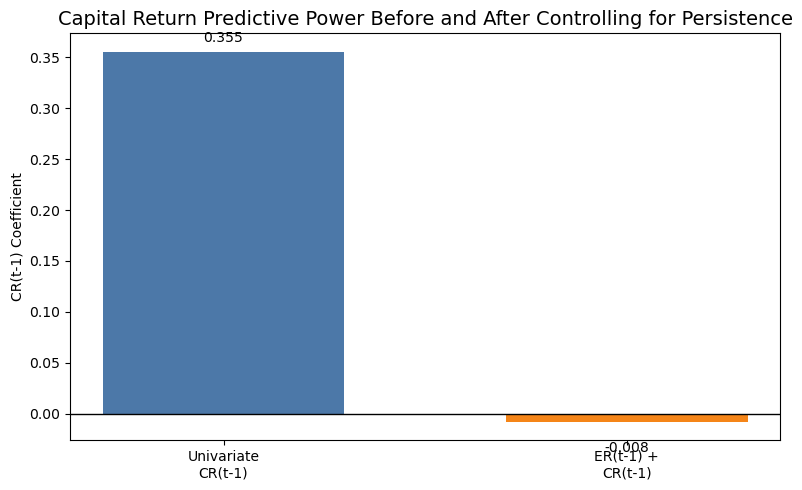

In [24]:
import matplotlib.pyplot as plt

models = [
    'Univariate\nCR(t-1)',
    'ER(t-1) +\nCR(t-1)'
]

coefficients = [
    0.3555,
    -0.0078
]

colors = [
    '#4C78A8',
    '#F58518'
]

plt.figure(figsize=(8,5))

bars = plt.bar(
    models,
    coefficients,
    color=colors,
    width=0.6
)

plt.axhline(
    y=0,
    color='black',
    linewidth=1
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01 if height >= 0 else height - 0.03,
        f'{height:.3f}',
        ha='center'
    )

plt.title(
    'Capital Return Predictive Power Before and After Controlling for Persistence',
    fontsize=14
)

plt.ylabel('CR(t-1) Coefficient')

plt.tight_layout()

plt.savefig(
    'H4_Persistence_Robustness.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [25]:
import matplotlib.pyplot as plt

variables = [
    'IR(t-1)',
    'CR(t-1)',
    'CAP(t-1)',
    'DISC(t-1)'
]

coefficients = [
    0.2827,
    0.3555,
    0.0873,
    0.0365
]

p_values = [
    0.4147,
    0.00003,
    0.8001,
    0.8882
]

colors = [
    'lightgrey',
    'darkgreen',
    'lightgrey',
    'lightgrey'
]

plt.figure(figsize=(8,5))

bars = plt.bar(
    variables,
    coefficients,
    color=colors
)

plt.axhline(0, color='black')

for i, bar in enumerate(bars):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f"p={p_values.3f}",
        ha='center'
    )

plt.title('Predictive Content of Lagged Variables')
plt.ylabel('Coefficient')

plt.tight_layout()
plt.savefig('H4_Bar_Chart.png', dpi=300)
plt.show()

SyntaxError: invalid decimal literal (1962969636.py, line 45)

In [26]:
import matplotlib.pyplot as plt

variables = [
    'IR(t-1)',
    'CR(t-1)',
    'CAP(t-1)',
    'DISC(t-1)'
]

coefficients = [
    0.2827,
    0.3555,
    0.0873,
    0.0365
]

p_values = [
    0.4147,
    0.00003,
    0.8001,
    0.8882
]

colors = [
    'lightgrey',
    'darkgreen',
    'lightgrey',
    'lightgrey'
]

plt.figure(figsize=(8,5))

bars = plt.bar(
    variables,
    coefficients,
    color=colors
)

plt.axhline(
    y=0,
    color='black',
    linewidth=1
)

for i, bar in enumerate(bars):

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"p={p_values.3f}",
        ha='center'
    )

plt.title(
    'Predictive Content of Lagged Valuation-Chain Variables'
)

plt.ylabel('Coefficient')

plt.tight_layout()

plt.savefig(
    'H4_Bar_Chart.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

SyntaxError: invalid decimal literal (4249823003.py, line 52)

<function matplotlib.pyplot.title(label: 'str', fontdict: 'dict[str, Any] | None' = None, loc: "Literal['left', 'center', 'right'] | None" = None, pad: 'float | None' = None, *, y: 'float | None' = None, **kwargs) -> 'Text'>

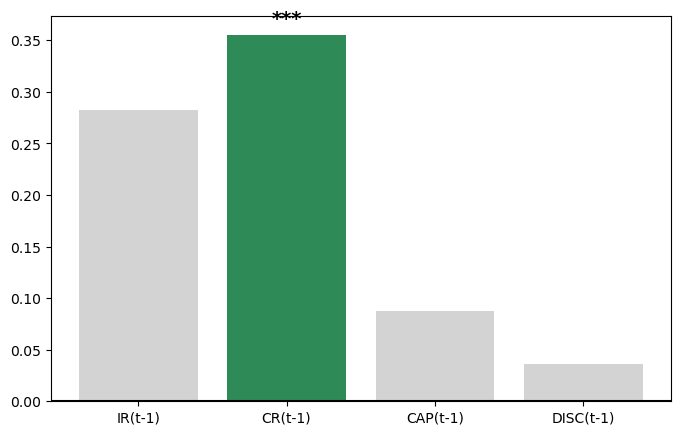

In [27]:
import matplotlib.pyplot as plt

variables = ['IR(t-1)','CR(t-1)','CAP(t-1)','DISC(t-1)']
coefficients = [0.2827,0.3555,0.0873,0.0365]
p_values = [0.4147,0.00003,0.8001,0.8882]

colors = [
    '#D3D3D3',
    '#2E8B57',
    '#D3D3D3',
    '#D3D3D3'
]

plt.figure(figsize=(8,5))

bars = plt.bar(
    variables,
    coefficients,
    color=colors
)

plt.axhline(0, color='black')

for i, bar in enumerate(bars):

    star = '***' if p_values[i] < 0.01 else ''

    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()+0.01,
        star,
        ha='center',
        fontsize=14,
        fontweight='bold'
    )

plt.title

In [28]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Build dataframe from your actual regression results

coef_df = pd.DataFrame({
    'Variable': [
        'Income Return (t-1)',
        'Capital Return (t-1)',
        'Cap Rate (t-1)',
        'Discount Rate (t-1)'
    ],
    'Coefficient': [
        0.282720,
        0.355471,
        0.087277,
        0.036457
    ],
    'Std_Error': [
        0.347,
        0.085,
        0.345,
        0.259
    ]
})

coef_df['Lower'] = coef_df['Coefficient'] - 1.96 * coef_df['Std_Error']
coef_df['['Std_ErrorUpper'] = coef_df[''] + 1.96 * coef_df['Std_Error']

# Sort for presentation

coef_df = coef_df.iloc[::-1]

fig, ax = plt.subplots(figsize=(10,6))

ax.errorbar(
    coef_df['Coefficient'],
    coef_df['Variable'],
    xerr=[
        coef_df['Coefficient'] - coef_df['Lower'],
        coef_df['Upper'] - coef_df['Coefficient']
    ],
    fmt='o',
    color='darkblue',
    capsize=5,
    markersize=8
)

ax.axvline(
    x=0,
    color='red',
    linestyle='--',
    linewidth=1.5
)

ax.set_title(
    'Figure X. Predictive Content of Lagged Valuation-Chain Measures',
    fontsize=14,
    fontweight='bold'
)

ax.set_xlabel(
    'Coefficient Estimate (95% Confidence Interval)',
    fontsize=11
)

ax.set_ylabel('')

ax.grid(
    axis='x',
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    'H4_Coefficient_Plot.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

SyntaxError: unterminated string literal (detected at line 30) (634523996.py, line 30)

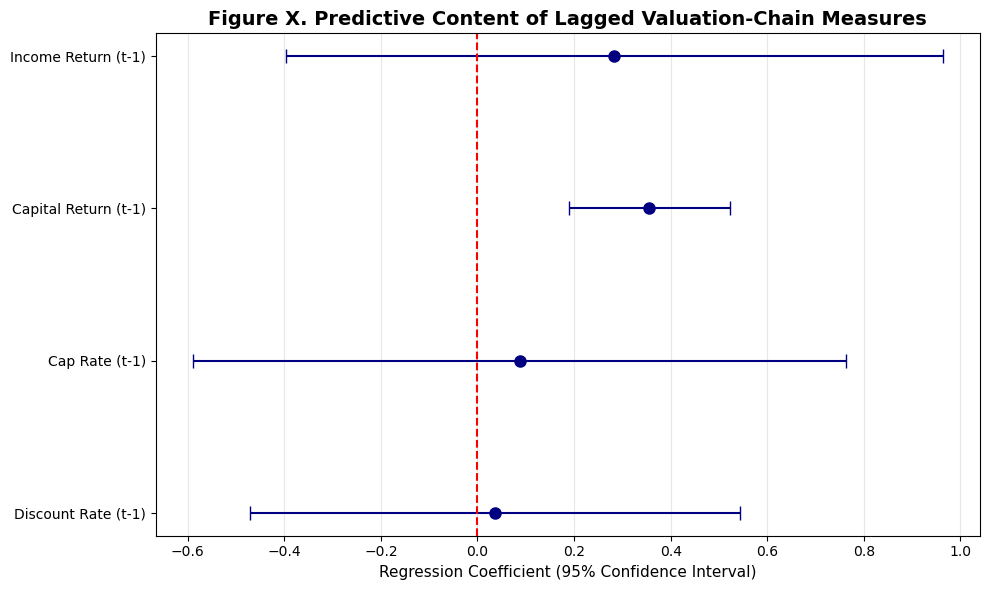

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# H4 Univariate Results

variables = [
    'Income Return (t-1)',
    'Capital Return (t-1)',
    'Cap Rate (t-1)',
    'Discount Rate (t-1)'
]

coefficients = [
    0.2827,
    0.3555,
    0.0873,
    0.0365
]

std_errors = [
    0.347,
    0.085,
    0.345,
    0.259
]

# 95% confidence intervals
ci95 = [1.96 * x for x in std_errors]

# Reverse order so best variable appears at top
variables = variables[::-1]
coefficients = coefficients[::-1]
ci95 = ci95[::-1]

y = np.arange(len(variables))

plt.figure(figsize=(10,6))

plt.errorbar(
    coefficients,
    y,
    xerr=ci95,
    fmt='o',
    color='navy',
    capsize=5,
    markersize=8
)

plt.axvline(
    0,
    color='red',
    linestyle='--',
    linewidth=1.5
)

plt.yticks(y, variables)

plt.title(
    'Figure X. Predictive Content of Lagged Valuation-Chain Measures',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    'Regression Coefficient (95% Confidence Interval)',
    fontsize=11
)

plt.ylabel('')

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()

plt.savefig(
    'H4_Coefficient_Plot_Final.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [1]:
df['negative_ER_L1'] = np.where(df['ER_L1'] < 0, df['ER_L1'], 0)
df['positive_ER_L1'] = np.where(df['ER_L1'] > 0, df['ER_L1'], 0)

NameError: name 'np' is not defined

In [2]:
import numpy as np

In [3]:
df['negative_ER_L1'] = np.where(
    df['ER_L1'] < 0,
    df['ER_L1'],
    0
)

df['positive_ER_L1'] = np.where(
    df['ER_L1'] > 0,
    df['ER_L1'],
    0
)

NameError: name 'df' is not defined

In [4]:
globals().keys()

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__session__', '_i', '_ii', '_iii', '_i1', '_i2', 'np', '_i3', '_i4'])

In [5]:
import pandas as pd

df = pd.read_csv("yFinal_Regression_Dataset.xlsx")

FileNotFoundError: [Errno 2] No such file or directory: 'yFinal_Regression_Dataset.xlsx'

In [6]:
import pandas as pd

df = pd.read_excel(
    "Final_Regression_Dataset.xlsx"
)

In [7]:
import numpy as np
import statsmodels.api as sm

df['positive_ER_L1'] = np.where(
    df['ER_L1'] > 0,
    df['ER_L1'],
    0
)

df['negative_ER_L1'] = np.where(
    df['ER_L1'] < 0,
    df['ER_L1'],
    0
)

test_df = df.dropna(
    subset=[
        'excess_return',
        'ER_L1'
    ]
)

X = sm.add_constant(
    test_df[
        [
            'positive_ER_L1',
            'negative_ER_L1'
        ]
    ]
)

y = test_df['excess_return']

model = sm.OLS(
    y,
    X
).fit(
    cov_type='HAC',
    cov_kwds={'maxlags':4}
)

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          excess_return   R-squared:                       0.950
Model:                            OLS   Adj. R-squared:                  0.949
Method:                 Least Squares   F-statistic:                     864.8
Date:                Fri, 07 Aug 2026   Prob (F-statistic):          7.32e-160
Time:                        18:23:42   Log-Likelihood:                -654.42
No. Observations:                 483   AIC:                             1315.
Df Residuals:                     480   BIC:                             1327.
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.0011      0.076     -0.

In [1]:
office = df[df["sector"] == "Office"].copy()

office["period"] = np.where(
    office["quarter_end"] >= "2020-01-01",
    "Post-COVID",
    "Pre-COVID"
)

summary = (
    office.groupby("period")
    [
        [
            "excess_return",
            "income_return",
            "capital_return",
            "cap_rate",
            "discount_rate"
        ]
    ]
    .agg(["mean", "std"])
)

summary

NameError: name 'df' is not defined

In [2]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_excel("Final_Regression_Dataset.xlsx")

# Convert date column
df["quarter_end"] = pd.to_datetime(df["quarter_end"])

print(df.shape)
df.head()

(486, 27)


,quarter_end,sector,total_return,capital_return,income_return,capital_value_m,num_investments,cap_rate,discount_rate,year,...,return_check,return_difference,return_check_geometric,return_difference_geometric,cash_rate,bond_10y,cap_rate_spread_bond,discount_rate_spread_bond,excess_return,ER_L1
0,1985-12-01,Industrial,14.753422,6.211565,8.084208,255.164609,49,NaN,NaN,1985,...,14.295772,0.457650,14.797928,-0.044506,NaN,14.816667,NaN,NaN,-1.270779,NaN
1,1986-03-01,Industrial,15.954124,6.794845,8.625343,259.752100,49,NaN,NaN,1986,...,15.420188,0.533936,16.006266,-0.052142,NaN,13.466667,NaN,NaN,-0.642015,-1.270779
2,1986-06-01,Industrial,16.367541,7.225124,8.578112,328.465496,63,NaN,NaN,1986,...,15.803236,0.564306,16.423015,-0.055474,NaN,12.616667,NaN,NaN,-0.576101,-0.642015
3,1986-09-01,Industrial,17.133640,7.556796,8.960349,334.334900,63,NaN,NaN,1986,...,16.517145,0.616495,17.194260,-0.060620,NaN,14.050000,NaN,NaN,-0.593717,-0.576101
4,1986-12-01,Industrial,17.209568,7.706414,8.880107,391.922357,70,NaN,NaN,1986,...,16.586521,0.623047,17.270858,-0.061291,NaN,13.533333,NaN,NaN,-1.076831,-0.593717


In [3]:
df.columns.tolist()

['quarter_end',
 'sector',
 'total_return',
 'capital_return',
 'income_return',
 'capital_value_m',
 'num_investments',
 'cap_rate',
 'discount_rate',
 'year',
 'quarter',
 'quarter_label',
 'cap_rate_spread',
 'capital_value_growth_qoq',
 'capital_value_growth_yoy',
 'investment_growth_yoy',
 'log_capital_value',
 'return_check',
 'return_difference',
 'return_check_geometric',
 'return_difference_geometric',
 'cash_rate',
 'bond_10y',
 'cap_rate_spread_bond',
 'discount_rate_spread_bond',
 'excess_return',
 'ER_L1']

In [4]:
import pandas as pd
import numpy as np

# Ensure date field is datetime
df["quarter_end"] = pd.to_datetime(df["quarter_end"])

# Office only
office = df[df["sector"] == "Office"].copy()

# Post-COVID indicator
office["period"] = np.where(
    office["quarter_end"] >= pd.Timestamp("2020-01-01"),
    "Post-COVID",
    "Pre-COVID"
)

# Summary statistics
summary = office.groupby("period")[
    [
        "excess_return",
        "income_return",
        "capital_return",
        "cap_rate",
        "discount_rate"
    ]
].agg(["mean", "std"])

summary.round(3)

excess_return        income_return        capital_return         \
                    mean    std          mean    std           mean    std   
period                                                                       
Post-COVID        -1.879  3.489         4.936  0.327         -2.272  6.228   
Pre-COVID         -0.890  2.698         6.933  0.759          2.466  8.833   

           cap_rate        discount_rate         
               mean    std          mean    std  
period                                           
Post-COVID    5.388  0.546         6.465  0.459  
Pre-COVID     7.172  0.839         9.712  1.683

In [5]:
import numpy as np

conditions = [
    office["quarter_end"] < "2020-01-01",
    (office["quarter_end"] >= "2020-01-01") &
    (office["quarter_end"] < "2022-01-01"),
    office["quarter_end"] >= "2022-01-01"
]

choices = [
    "Pre-COVID",
    "COVID",
    "Rate Shock"
]

office["regime"] = np.select(
    conditions,
    choices,
    default="Other"
)

office.groupby("regime")[
    [
        "excess_return",
        "income_return",
        "capital_return",
        "cap_rate",
        "discount_rate"
    ]
].mean().round(3)

,excess_return,income_return,capital_return,cap_rate,discount_rate
regime,,,,,
COVID,1.862,4.938,2.529,5.009,6.239
Pre-COVID,-0.890,6.933,2.466,7.172,9.712
Rate Shock,-3.639,4.935,-4.531,5.566,6.571


In [6]:
h5_table = office.groupby("regime")[
    [
        "excess_return",
        "income_return",
        "capital_return",
        "cap_rate",
        "discount_rate"
    ]
].mean().round(3)

h5_table

,excess_return,income_return,capital_return,cap_rate,discount_rate
regime,,,,,
COVID,1.862,4.938,2.529,5.009,6.239
Pre-COVID,-0.890,6.933,2.466,7.172,9.712
Rate Shock,-3.639,4.935,-4.531,5.566,6.571


In [7]:
post2020 = df[df["quarter_end"] >= "2020-01-01"].copy()

post2020.groupby("sector")[
    [
        "excess_return",
        "income_return",
        "capital_return",
        "cap_rate",
        "discount_rate"
    ]
].mean().round(3)

,excess_return,income_return,capital_return,cap_rate,discount_rate
sector,,,,,
Industrial,7.566,4.559,7.137,4.882,6.419
Office,-1.879,4.936,-2.272,5.388,6.465
Retail,-1.589,5.412,-2.461,5.466,6.681


In [8]:
conditions = [
    (df["quarter_end"] >= "2008-01-01") & (df["quarter_end"] < "2013-01-01"),
    (df["quarter_end"] >= "2020-01-01") & (df["quarter_end"] < "2022-01-01"),
    (df["quarter_end"] >= "2022-01-01")
]

choices = [
    "GFC",
    "COVID",
    "Rate_Shock"
]

office = df[df["sector"] == "Office"].copy()

office["event_period"] = np.select(
    conditions,
    choices,
    default="Other"
)

office.groupby("event_period")[
    [
        "excess_return",
        "income_return",
        "capital_return",
        "cap_rate",
        "discount_rate"
    ]
].mean().round(3)

ValueError: Length of values (486) does not match length of index (162)

In [9]:
office = df[df["sector"] == "Office"].copy()

conditions = [
    (office["quarter_end"] >= "2008-01-01") &
    (office["quarter_end"] < "2013-01-01"),

    (office["quarter_end"] >= "2020-01-01") &
    (office["quarter_end"] < "2022-01-01"),

    (office["quarter_end"] >= "2022-01-01")
]

choices = [
    "GFC",
    "COVID",
    "Rate_Shock"
]

office["event_period"] = np.select(
    conditions,
    choices,
    default="Other"
)

office.groupby("event_period")[
    [
        "excess_return",
        "income_return",
        "capital_return",
        "cap_rate",
        "discount_rate"
    ]
].mean().round(3)

,excess_return,income_return,capital_return,cap_rate,discount_rate
event_period,,,,,
COVID,1.862,4.938,2.529,5.009,6.239
GFC,-0.177,7.080,-1.347,7.351,9.069
Other,-1.012,6.908,3.118,7.129,9.850
Rate_Shock,-3.639,4.935,-4.531,5.566,6.571


In [10]:
office = df[df["sector"] == "Office"].copy()

office.groupby("year")[
    [
        "excess_return",
        "capital_return",
        "income_return"
    ]
].mean().round(2)

,excess_return,capital_return,income_return
year,,,
1985,-1.11,8.23,6.22
1986,-0.91,9.48,6.44
1987,0.62,16.21,6.24
1988,1.87,23.91,5.79
1989,-0.09,11.77,5.88
1990,-1.92,-2.48,6.22
1991,-5.59,-17.06,6.91
1992,-7.47,-18.27,7.67
1993,-8.29,-15.02,8.50


In [11]:
office_recent = office[
    office["year"] >= 2020
][
    [
        "year",
        "excess_return",
        "capital_return",
        "income_return"
    ]
]

office_recent

,year,excess_return,capital_return,income_return
299,2020,4.773425,5.363835,5.262241
300,2020,5.692221,2.739890,5.150948
301,2020,5.232660,1.800039,5.044432
302,2020,3.660657,0.036985,4.939218
303,2021,1.955829,0.226236,4.833279
304,2021,-1.113720,2.550337,4.810023
305,2021,-2.129151,3.232157,4.759882
306,2021,-3.175058,4.282562,4.707505
307,2022,-3.168927,4.436868,4.646745
308,2022,-2.666083,3.913284,4.540338


<Axes: title={'center': 'Office Relative Performance'}, xlabel='quarter_end'>

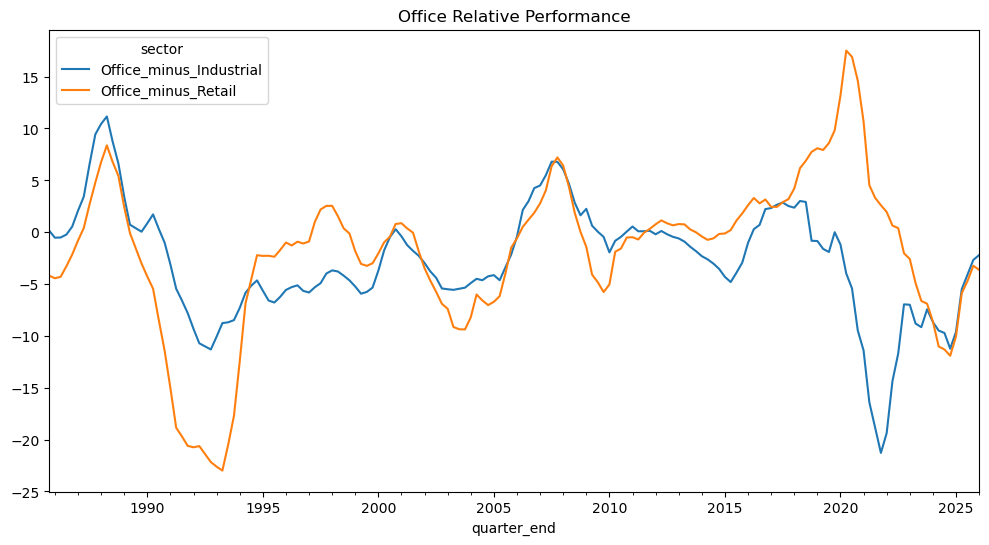

In [12]:
pivot = df.pivot(
    index="quarter_end",
    columns="sector",
    values="excess_return"
)

pivot["Office_minus_Industrial"] = (
    pivot["Office"] - pivot["Industrial"]
)

pivot["Office_minus_Retail"] = (
    pivot["Office"] - pivot["Retail"]
)

pivot[["Office_minus_Industrial",
       "Office_minus_Retail"]].plot(
    figsize=(12,6),
    title="Office Relative Performance"
)

In [13]:
office = df[df["sector"] == "Office"].copy()

office["post_covid"] = (
    office["quarter_end"] >= "2020-01-01"
).astype(int)

office["interaction"] = (
    office["ER_L1"] *
    office["post_covid"]
)

import statsmodels.api as sm

X = sm.add_constant(
    office[
        [
            "ER_L1",
            "post_covid",
            "interaction"
        ]
    ]
)

y = office["excess_return"]

model = sm.OLS(y, X).fit(
    cov_type="HAC",
    cov_kwds={"maxlags":4}
)

print(model.summary())

MissingDataError: exog contains inf or nans

In [14]:
office[
    ["ER_L1", "post_covid", "interaction"]
].isna().sum()

ER_L1          1
post_covid     0
interaction    1
dtype: int64

In [15]:
import statsmodels.api as sm

office = df[df["sector"] == "Office"].copy()

# Post-COVID dummy
office["post_covid"] = (
    office["quarter_end"] >= "2020-01-01"
).astype(int)

# Interaction term
office["interaction"] = (
    office["ER_L1"] *
    office["post_covid"]
)

# Keep only required variables and remove missing lag observation
reg_data = office[
    [
        "excess_return",
        "ER_L1",
        "post_covid",
        "interaction"
    ]
].dropna()

# Regression setup
X = sm.add_constant(
    reg_data[
        [
            "ER_L1",
            "post_covid",
            "interaction"
        ]
    ]
)

y = reg_data["excess_return"]

# Estimate model
model = sm.OLS(y, X).fit(
    cov_type="HAC",
    cov_kwds={"maxlags": 4}
)

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          excess_return   R-squared:                       0.942
Model:                            OLS   Adj. R-squared:                  0.941
Method:                 Least Squares   F-statistic:                     281.0
Date:                Sun, 09 Aug 2026   Prob (F-statistic):           6.97e-63
Time:                        15:06:27   Log-Likelihood:                -167.56
No. Observations:                 161   AIC:                             343.1
Df Residuals:                     157   BIC:                             355.5
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0229      0.080      0.288      

In [16]:
from scipy.stats import ttest_ind

pre = office[
    office["quarter_end"] < "2020-01-01"
]["excess_return"]

post = office[
    office["quarter_end"] >= "2020-01-01"
]["excess_return"]

ttest_ind(
    pre,
    post,
    equal_var=False
)

TtestResult(statistic=np.float64(1.3449496857576166), pvalue=np.float64(0.18890437894756276), df=np.float64(29.461186194736573))

<Axes: title={'center': 'Office Sector Excess Returns Since COVID'}, xlabel='year'>

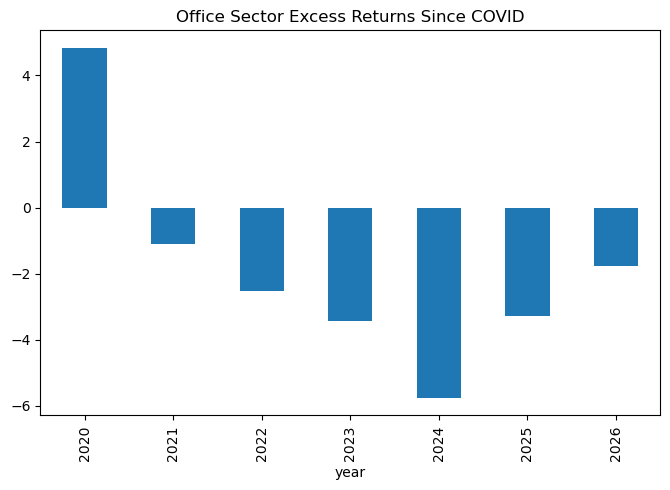

In [17]:
office = df[df["sector"]=="Office"]

annual = office.groupby("year")[
    "excess_return"
].mean()

annual.loc[2020:].plot(
    kind="bar",
    figsize=(8,5),
    title="Office Sector Excess Returns Since COVID"
)

<Axes: xlabel='year'>

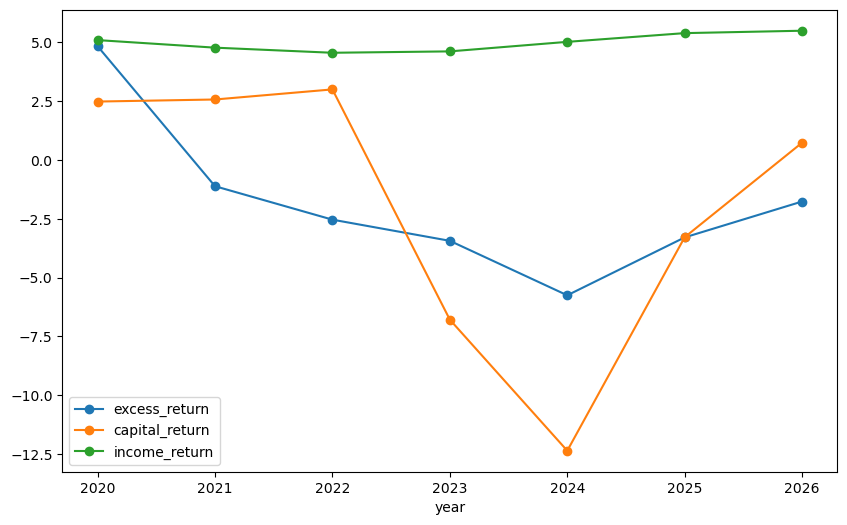

In [18]:
annual = office.groupby("year")[
    [
        "excess_return",
        "capital_return",
        "income_return"
    ]
].mean()

annual.loc[2020:].plot(
    figsize=(10,6),
    marker="o"
)


In [19]:
plt.figure(figsize=(10,6))

plt.plot(..., linewidth=3, label="Capital Return")
plt.plot(..., linewidth=2, label="Excess Return")
plt.plot(..., linewidth=2, label="Income Return")

NameError: name 'plt' is not defined

In [21]:
import matplotlib.pyplot as plt


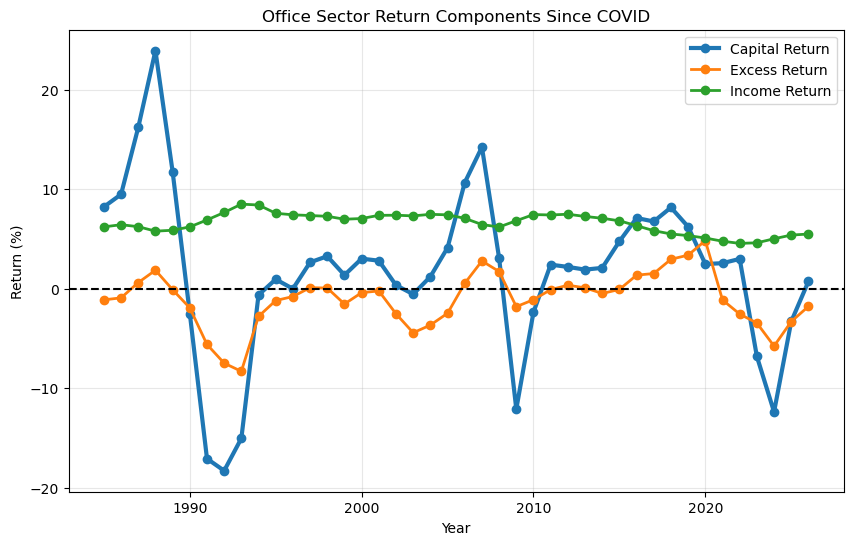

In [22]:
import matplotlib.pyplot as plt

annual = office.groupby("year")[
    [
        "excess_return",
        "capital_return",
        "income_return"
    ]
].mean()

plt.figure(figsize=(10,6))

plt.plot(
    annual.index,
    annual["capital_return"],
    marker="o",
    linewidth=3,
    label="Capital Return"
)

plt.plot(
    annual.index,
    annual["excess_return"],
    marker="o",
    linewidth=2,
    label="Excess Return"
)

plt.plot(
    annual.index,
    annual["income_return"],
    marker="o",
    linewidth=2,
    label="Income Return"
)

plt.axhline(0, color="black", linestyle="--")

plt.title("Office Sector Return Components Since COVID")
plt.xlabel("Year")
plt.ylabel("Return (%)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

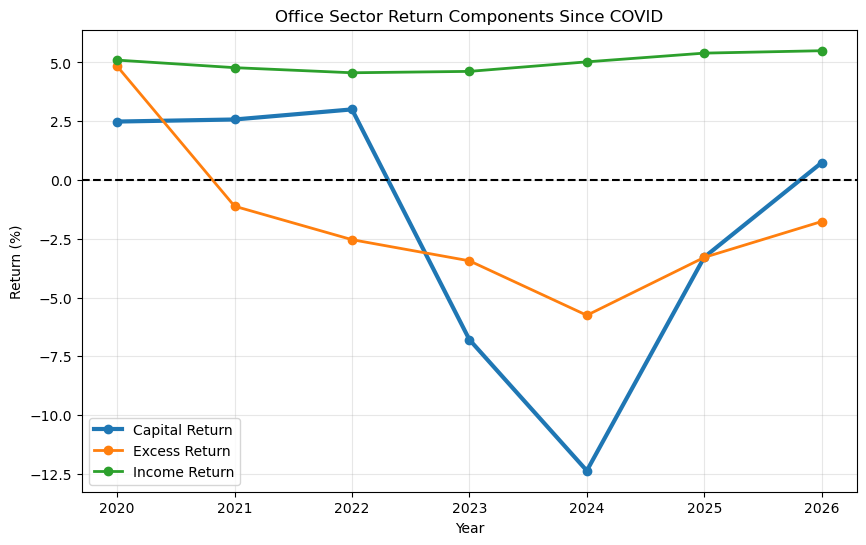

In [23]:
annual = office.groupby("year")[
    [
        "excess_return",
        "capital_return",
        "income_return"
    ]
].mean()

annual = annual.loc[2020:]

plt.figure(figsize=(10,6))

plt.plot(
    annual.index,
    annual["capital_return"],
    marker="o",
    linewidth=3,
    label="Capital Return"
)

plt.plot(
    annual.index,
    annual["excess_return"],
    marker="o",
    linewidth=2,
    label="Excess Return"
)

plt.plot(
    annual.index,
    annual["income_return"],
    marker="o",
    linewidth=2,
    label="Income Return"
)

plt.axhline(0, color="black", linestyle="--")

plt.title("Office Sector Return Components Since COVID")
plt.xlabel("Year")
plt.ylabel("Return (%)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

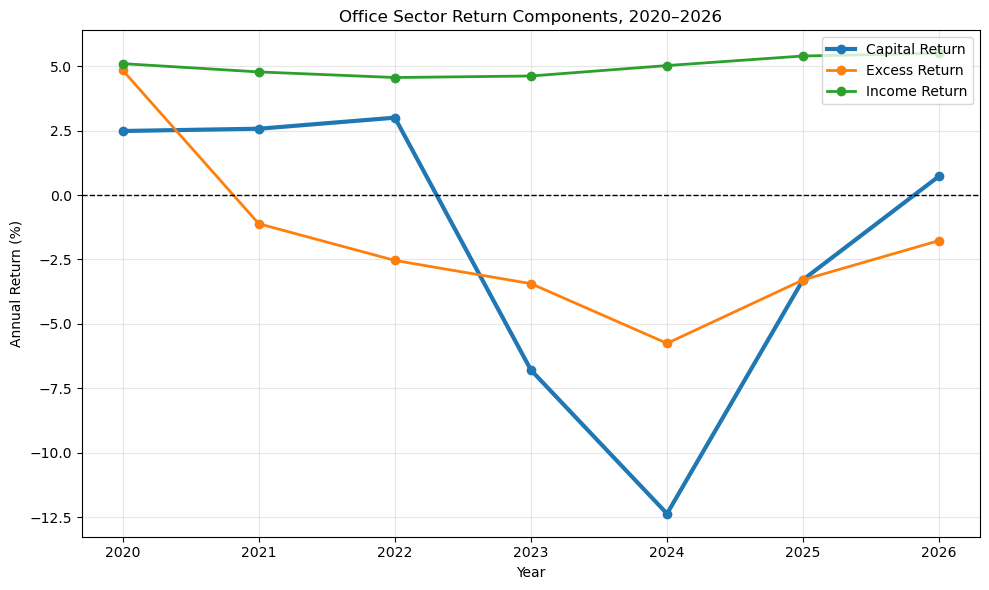

Saved: Office_Return_Components_2020_2026.png


In [24]:
import matplotlib.pyplot as plt

# Annual office-sector averages
annual = (
    office.groupby("year")[
        [
            "excess_return",
            "capital_return",
            "income_return"
        ]
    ]
    .mean()
)

# COVID onwards only
annual = annual.loc[2020:]

plt.figure(figsize=(10, 6))

# Capital return (main story)
plt.plot(
    annual.index,
    annual["capital_return"],
    marker="o",
    linewidth=3,
    label="Capital Return"
)

# Excess return
plt.plot(
    annual.index,
    annual["excess_return"],
    marker="o",
    linewidth=2,
    label="Excess Return"
)

# Income return
plt.plot(
    annual.index,
    annual["income_return"],
    marker="o",
    linewidth=2,
    label="Income Return"
)

# Zero-return reference line
plt.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.title("Office Sector Return Components, 2020–2026")
plt.xlabel("Year")
plt.ylabel("Annual Return (%)")

plt.legend(loc="upper right")
plt.grid(alpha=0.3)

plt.tight_layout()

# Save figure
plt.savefig(
    "Office_Return_Components_2020_2026.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: Office_Return_Components_2020_2026.png")

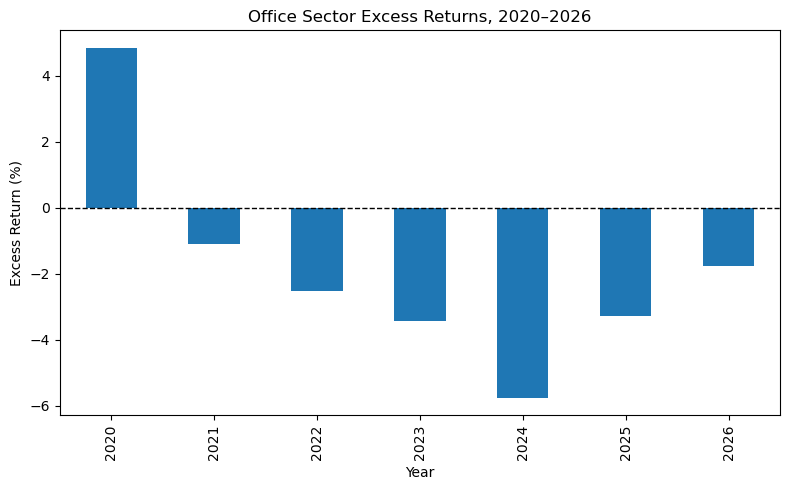

Saved: Office_Excess_Returns_2020_2026.png


In [25]:
import matplotlib.pyplot as plt

annual_er = (
    office.groupby("year")["excess_return"]
    .mean()
    .loc[2020:]
)

plt.figure(figsize=(8,5))

annual_er.plot(
    kind="bar",
    color="#1f77b4"
)

plt.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.title("Office Sector Excess Returns, 2020–2026")
plt.xlabel("Year")
plt.ylabel("Excess Return (%)")

plt.tight_layout()

plt.savefig(
    "Office_Excess_Returns_2020_2026.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: Office_Excess_Returns_2020_2026.png")

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================
# LOAD DATA
# ==========================

df = pd.read_excel(
    "MSCI_Data.xlsx",
    engine="openpyxl"
)

df["Date"] = pd.to_datetime(df["Date"])

# ==========================
# FIGURE 2
# FOUR-QUARTER ROLLING TOTAL RETURNS
# ==========================

rolling = pd.DataFrame()
rolling["Date"] = df["Date"]

rolling["Industrial"] = (
    df["Industrial_TR"]
    .rolling(4)
    .mean()
)

rolling["Office"] = (
    df["Office_TR"]
    .rolling(4)
    .mean()
)

rolling["Retail"] = (
    df["Retail_TR"]
    .rolling(4)
    .mean()
)

rolling["All Property"] = (
    df["AllProperty_TR"]
    .rolling(4)
    .mean()
)

plt.figure(figsize=(12, 6))

plt.plot(
    rolling["Date"],
    rolling["Industrial"],
    label="Industrial",
    linewidth=1.8
)

plt.plot(
    rolling["Date"],
    rolling["Office"],
    label="Office",
    linewidth=1.8
)

plt.plot(
    rolling["Date"],
    rolling["Retail"],
    label="Retail",
    linewidth=1.8
)

plt.plot(
    rolling["Date"],
    rolling["All Property"],
    label="All Property",
    linewidth=3.0,
    color="black"
)

plt.title(
    "Figure 2. Four-Quarter Rolling Total Returns by Sector and All Property Index"
)

plt.ylabel("Return (%)")
plt.xlabel("")
plt.legend()
plt.tight_layout()

plt.savefig(
    "Figure2_AllProperty.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# ==========================
# FIGURE 4
# CAPITALISATION RATES
# ==========================

plt.figure(figsize=(12, 6))

plt.plot(
    df["Date"],
    df["Industrial_CAP"],
    label="Industrial",
    linewidth=1.8
)

plt.plot(
    df["Date"],
    df["Office_CAP"],
    label="Office",
    linewidth=1.8
)

plt.plot(
    df["Date"],
    df["Retail_CAP"],
    label="Retail",
    linewidth=1.8
)

plt.plot(
    df["Date"],
    df["AllProperty_CAP"],
    label="All Property",
    linewidth=3.0,
    color="black"
)

plt.title(
    "Figure 4. Capitalisation Rates by Sector and All Property Index"
)

plt.ylabel("Capitalisation Rate (%)")
plt.xlabel("")
plt.legend()

plt.tight_layout()

plt.savefig(
    "Figure4_AllProperty.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("Figures created successfully.")
`

SyntaxError: invalid syntax (2694533561.py, line 150)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================
# LOAD DATA
# ==========================

df = pd.read_excel(
    "MSCI_Data.xlsx",
    engine="openpyxl"
)

df["Date"] = pd.to_datetime(df["Date"])

# ==========================
# FIGURE 2
# FOUR-QUARTER ROLLING TOTAL RETURNS
# ==========================

rolling = pd.DataFrame()
rolling["Date"] = df["Date"]

rolling["Industrial"] = (
    df["Industrial_TR"]
    .rolling(4)
    .mean()
)

rolling["Office"] = (
    df["Office_TR"]
    .rolling(4)
    .mean()
)

rolling["Retail"] = (
    df["Retail_TR"]
    .rolling(4)
    .mean()
)

rolling["All Property"] = (
    df["AllProperty_TR"]
    .rolling(4)
    .mean()
)

plt.figure(figsize=(12, 6))

plt.plot(
    rolling["Date"],
    rolling["Industrial"],
    label="Industrial",
    linewidth=1.8
)

plt.plot(
    rolling["Date"],
    rolling["Office"],
    label="Office",
    linewidth=1.8
)

plt.plot(
    rolling["Date"],
    rolling["Retail"],
    label="Retail",
    linewidth=1.8
)

plt.plot(
    rolling["Date"],
    rolling["All Property"],
    label="All Property",
    linewidth=3.0,
    color="black"
)

plt.title(
    "Figure 2. Four-Quarter Rolling Total Returns by Sector and All Property Index"
)

plt.ylabel("Return (%)")
plt.xlabel("")
plt.legend()
plt.tight_layout()

plt.savefig(
    "Figure2_AllProperty.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# ==========================
# FIGURE 4
# CAPITALISATION RATES
# ==========================

plt.figure(figsize=(12, 6))

plt.plot(
    df["Date"],
    df["Industrial_CAP"],
    label="Industrial",
    linewidth=1.8
)

plt.plot(
    df["Date"],
    df["Office_CAP"],
    label="Office",
    linewidth=1.8
)

plt.plot(
    df["Date"],
    df["Retail_CAP"],
    label="Retail",
    linewidth=1.8
)

plt.plot(
    df["Date"],
    df["AllProperty_CAP"],
    label="All Property",
    linewidth=3.0,
    color="black"
)

plt.title(
    "Figure 4. Capitalisation Rates by Sector and All Property Index"
)

plt.ylabel("Capitalisation Rate (%)")
plt.xlabel("")
plt.legend()

plt.tight_layout()

plt.savefig(
    "Figure4_AllProperty.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("Figures created successfully.")

FileNotFoundError: [Errno 2] No such file or directory: 'MSCI_Data.xlsx'

In [3]:
import os

for f in os.listdir():
    print(f)

.anaconda
.conda
.ipynb_checkpoints
.ipython
.jupyter
.matplotlib
.ms-ad
3D Objects
Air NZ Returns.xlsx
Anixemenes Vintage 2026.xlsx
AppData
Application Data
Aramco Data Book 1Q26.xlsx
aramco_prices.xlsx
Aware Real Estate
A_REIT_2016_2025_monthly_total_returns_survivorship_free.csv
benchmark_methodology_correlations.csv
benchmark_returns.csv
benchmark_weights_annual.csv
benchmark_weights_quarterly.csv
Contacts
Cookies
Correlation_Matrix.xlsx
Data Preparation Research Report.ipynb
Dissertation_Figures
Documents
Downloads
dynamic_erp_wacc_inputs.xlsx
equal_weight_benchmark.csv
equal_weight_excess_returns.csv
excess_return_comparison_table.csv
f01hist (2).xlsx
f02hist.xlsx
f02histhist.xls
Favorites
Figure_1_Benchmark_Evolution.png
Figure_2_Mean_Excess_Returns_by_Regime.png
Figure_2_Total_Returns_by_Sector.png
Figure_3_Income_Capital_Returns.png
Figure_4_Capitalisation_Rates_by_Sector.png
Figure_5_Cap_Rates_vs_Bond_Yield.png
Figure_5_Heatmap_Improved.png
Figure_Excess_Return_Heatmap_Chrono

In [4]:
import pandas as pd

file = "msci_research_dataset_v3.xlsx"

xls = pd.ExcelFile(file)

print(xls.sheet_names)

['Analysis_Master', 'Benchmark_Weights', 'Return_Attribution', 'Valuation_Summary', 'Bond_10Y_Quarterly', 'Cash_Rate_Quarterly']


In [5]:
import pandas as pd

file = "msci_research_dataset_v3.xlsx"

# Load the main analysis sheet
df = pd.read_excel(
    file,
    sheet_name="Analysis_Master"
)

print(df.columns.tolist())

['quarter_end', 'sector', 'total_return', 'capital_return', 'income_return', 'capital_value_m', 'num_investments', 'cap_rate', 'discount_rate', 'year', 'quarter', 'quarter_label', 'cap_rate_spread', 'capital_value_growth_qoq', 'capital_value_growth_yoy', 'investment_growth_yoy', 'log_capital_value', 'return_check', 'return_difference', 'return_check_geometric', 'return_difference_geometric', 'cash_rate', 'bond_10y', 'cap_rate_spread_bond', 'discount_rate_spread_bond']


In [6]:
import pandas as pd

df = pd.read_excel(
    "msci_research_dataset_v3.xlsx",
    sheet_name="Analysis_Master"
)

print(df["sector"].unique())

<StringArray>
['Industrial', 'Office', 'Retail']
Length: 3, dtype: str


In [7]:
import pandas as pd

file = "msci_research_dataset_v3.xlsx"

for sheet in ["Return_Attribution", "Valuation_Summary"]:
    
    print("\n" + "="*50)
    print("SHEET:", sheet)
    print("="*50)

    temp = pd.read_excel(
        file,
        sheet_name=sheet
    )

    print(temp.columns.tolist())

    print("\nFIRST 5 ROWS:")
    print(temp.head())


SHEET: Return_Attribution
['sector', 'observations', 'avg_total_return', 'avg_capital_return', 'avg_income_return', 'income_share', 'capital_share']

FIRST 5 ROWS:
       sector  observations  avg_total_return  avg_capital_return  \
0  Industrial           162             11.25                3.17   
1      Office           162              8.44                1.73   
2      Retail           162             10.39                3.01   

   avg_income_return  income_share  capital_share  
0               7.89          0.70           0.28  
1               6.62          0.78           0.20  
2               7.16          0.69           0.29  

SHEET: Valuation_Summary
['sector', 'observations', 'avg_cap_rate', 'avg_discount_rate', 'avg_bond_10y', 'avg_cap_rate_spread', 'avg_discount_rate_spread']

FIRST 5 ROWS:
       sector  observations  avg_cap_rate  avg_discount_rate  avg_bond_10y  \
0  Industrial           162          7.93               9.73          6.17   
1      Office         

In [8]:
import pandas as pd

benchmark = pd.read_csv("benchmark_returns.csv")

print(benchmark.columns.tolist())
print("\n")
print(benchmark.head())

['quarter_end', 'MSCI_Benchmark', 'EqualWeight_Benchmark']


  quarter_end  MSCI_Benchmark  EqualWeight_Benchmark
0  1985-12-01       16.024201              16.258199
1  1986-03-01       16.596139              17.078774
2  1986-06-01       16.943642              17.458570
3  1986-09-01       17.727357              18.075001
4  1986-12-01       18.286398              18.286687


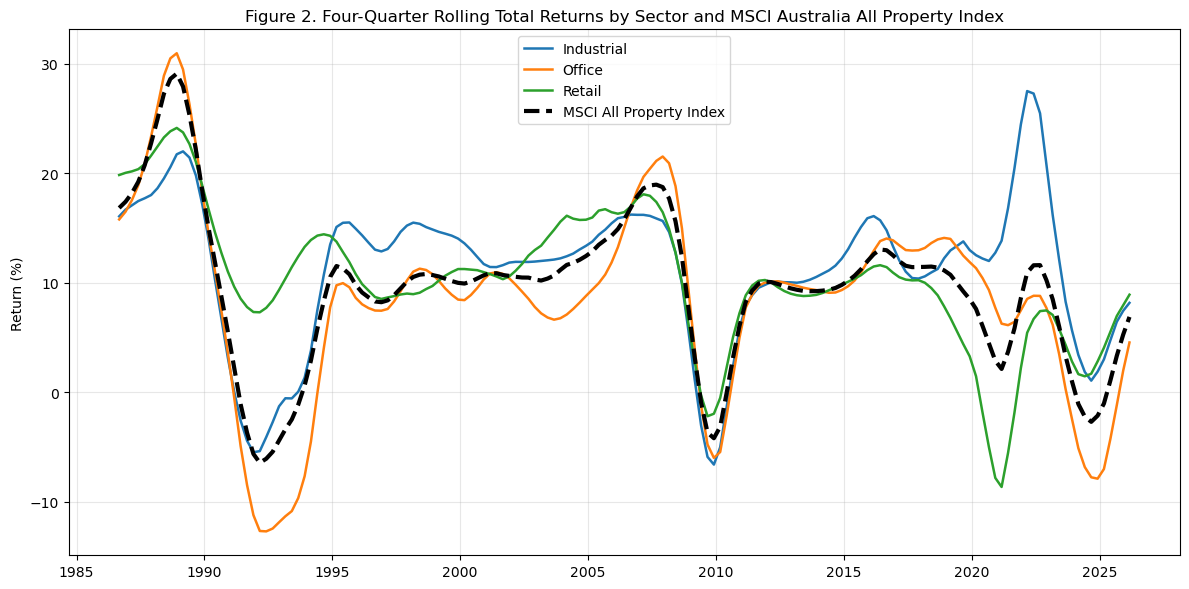

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------
# LOAD DATA
# --------------------------

df = pd.read_excel(
    "msci_research_dataset_v3.xlsx",
    sheet_name="Analysis_Master"
)

benchmark = pd.read_csv(
    "benchmark_returns.csv"
)

# --------------------------
# DATE FORMATTING
# --------------------------

df["quarter_end"] = pd.to_datetime(df["quarter_end"])
benchmark["quarter_end"] = pd.to_datetime(
    benchmark["quarter_end"]
)

# --------------------------
# CREATE WIDE FORMAT
# --------------------------

returns = (
    df.pivot(
        index="quarter_end",
        columns="sector",
        values="total_return"
    )
    .reset_index()
)

# --------------------------
# MERGE BENCHMARK
# --------------------------

returns = returns.merge(
    benchmark[["quarter_end", "MSCI_Benchmark"]],
    on="quarter_end",
    how="left"
)

# --------------------------
# FOUR-QUARTER ROLLING
# --------------------------

rolling = returns.copy()

for col in [
    "Industrial",
    "Office",
    "Retail",
    "MSCI_Benchmark"
]:
    rolling[col] = rolling[col].rolling(4).mean()

# --------------------------
# PLOT
# --------------------------

plt.figure(figsize=(12,6))

plt.plot(
    rolling["quarter_end"],
    rolling["Industrial"],
    label="Industrial",
    linewidth=1.8
)

plt.plot(
    rolling["quarter_end"],
    rolling["Office"],
    label="Office",
    linewidth=1.8
)

plt.plot(
    rolling["quarter_end"],
    rolling["Retail"],
    label="Retail",
    linewidth=1.8
)

plt.plot(
    rolling["quarter_end"],
    rolling["MSCI_Benchmark"],
    label="MSCI All Property Index",
    color="black",
    linewidth=3,
    linestyle="--"
)

plt.title(
    "Figure 2. Four-Quarter Rolling Total Returns by Sector and MSCI Australia All Property Index"
)

plt.ylabel("Return (%)")
plt.xlabel("")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "Figure_2_Total_Returns_With_Benchmark.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

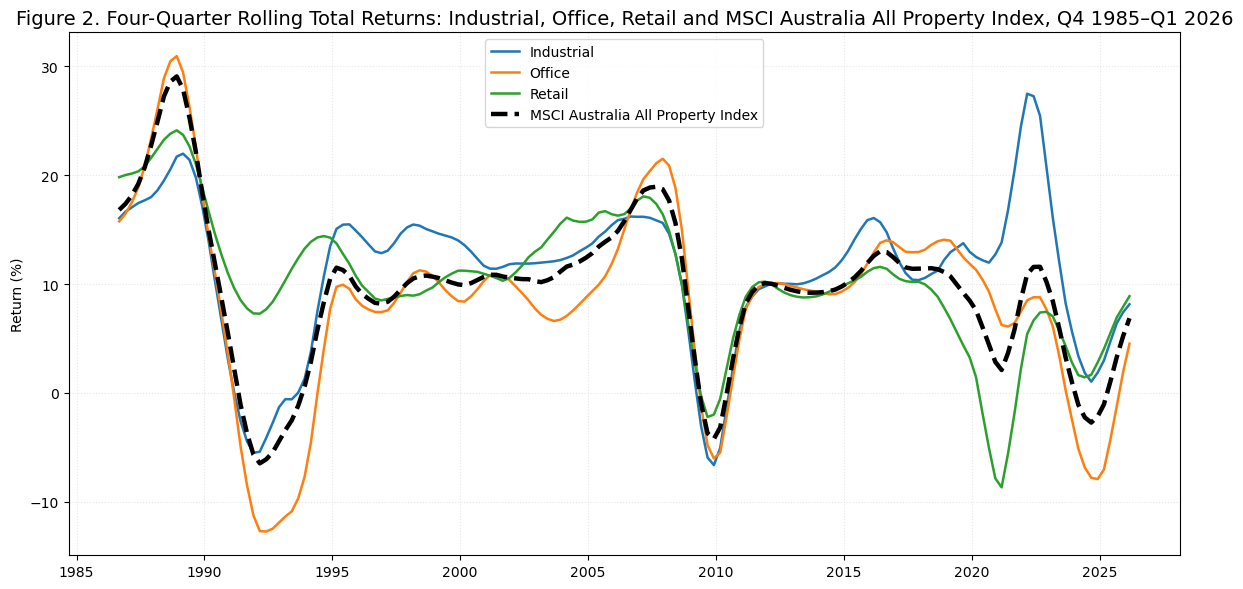

Saved: Figure_2_Total_Returns_MSCI_Benchmark_Final.png


In [10]:
# --------------------------
# PLOT
# --------------------------

plt.figure(figsize=(12,6))

plt.plot(
    rolling["quarter_end"],
    rolling["Industrial"],
    label="Industrial",
    linewidth=1.8
)

plt.plot(
    rolling["quarter_end"],
    rolling["Office"],
    label="Office",
    linewidth=1.8
)

plt.plot(
    rolling["quarter_end"],
    rolling["Retail"],
    label="Retail",
    linewidth=1.8
)

plt.plot(
    rolling["quarter_end"],
    rolling["MSCI_Benchmark"],
    label="MSCI Australia All Property Index",
    color="black",
    linewidth=3.2,
    linestyle="--"
)

plt.title(
    "Figure 2. Four-Quarter Rolling Total Returns: Industrial, Office, Retail and MSCI Australia All Property Index, Q4 1985–Q1 2026",
    fontsize=14
)

plt.ylabel("Return (%)")
plt.xlabel("")

plt.legend(
    frameon=True,
    loc="upper center"
)

plt.grid(
    alpha=0.3,
    linestyle=":"
)

plt.tight_layout()

# High-resolution export for dissertation

plt.savefig(
    "Figure_2_Total_Returns_MSCI_Benchmark_Final.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved: Figure_2_Total_Returns_MSCI_Benchmark_Final.png"
)

In [11]:
import pandas as pd

xls = pd.ExcelFile("Persistence_Analysis.xlsx")

print(xls.sheet_names)

for sheet in xls.sheet_names:
    print("\n")
    print("SHEET:", sheet)

    df = pd.read_excel(
        "Persistence_Analysis.xlsx",
        sheet_name=sheet
    )

    print(df.head())

['AR2_Model', 'Sector_Persistence']


SHEET: AR2_Model
           Variable  Coefficient     t_stat        p_value
0             const     0.020896   0.624824   5.323852e-01
1  excess_return_l1     1.595894  45.265279  9.040800e-175
2  excess_return_l2    -0.637750 -18.095521   4.185043e-56


SHEET: Sector_Persistence
       Sector  Persistence_Beta        R2        p_value
0  Industrial          0.966060  0.935734   1.120709e-96
1      Office          0.969492  0.939538   8.749751e-99
2      Retail          0.976746  0.955051  5.031482e-109


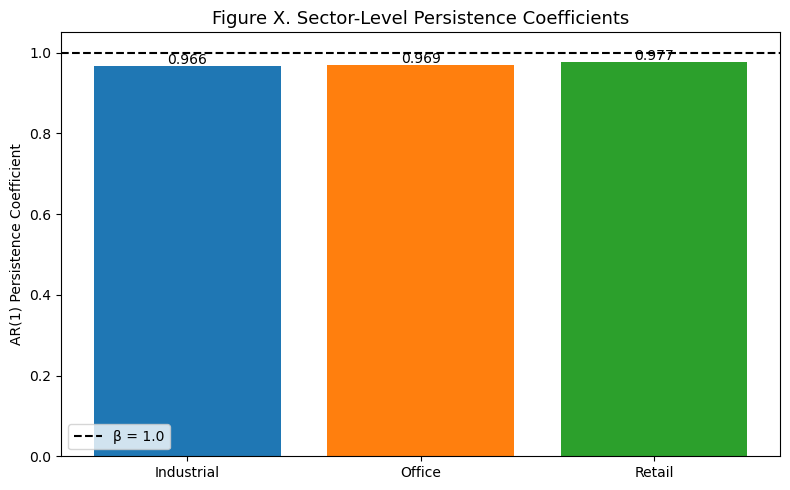

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------
# LOAD PERSISTENCE RESULTS
# ---------------------------------

df = pd.read_excel(
    "Persistence_Analysis.xlsx",
    sheet_name="Sector_Persistence"
)

# ---------------------------------
# PLOT
# ---------------------------------

plt.figure(figsize=(8,5))

bars = plt.bar(
    df["Sector"],
    df["Persistence_Beta"],
    color=["#1f77b4", "#ff7f0e", "#2ca02c"]
)

plt.axhline(
    y=1.0,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="β = 1.0"
)

plt.ylabel("AR(1) Persistence Coefficient")
plt.xlabel("")

plt.title(
    "Figure X. Sector-Level Persistence Coefficients",
    fontsize=13
)

# Value labels

for bar in bars:
    
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.005,
        f"{height:.3f}",
        ha="center"
    )

plt.ylim(0, 1.05)

plt.legend()

plt.tight_layout()

plt.savefig(
    "H3_Sector_Persistence_Coefficients.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from pathlib import Path

FILE = "The+Property+Council-MSCI+Australian+All+Property+Digest+Q12026+Old+Format.xlsx"

#############################################################
# Helper function
#############################################################

def estimate_ar1(series):

    series = pd.to_numeric(series, errors="coerce").dropna()

    if len(series) < 30:
        return None

    y = series.iloc[1:]
    x = series.shift(1).iloc[1:]

    X = sm.add_constant(x)

    model = sm.OLS(y, X).fit(
        cov_type="HAC",
        cov_kwds={"maxlags":4}
    )

    beta = model.params.iloc[1]

    if beta <= 0 or beta >= 1:
        half_life = np.nan
    else:
        half_life = np.log(0.5) / np.log(beta)

    return {
        "AR1": beta,
        "t_stat": model.tvalues.iloc[1],
        "p_value": model.pvalues.iloc[1],
        "R2": model.rsquared,
        "Half_Life_Quarters": half_life,
        "Obs": len(series)
    }

#############################################################
# Read sheet
#############################################################

df = pd.read_excel(
    FILE,
    sheet_name="Office Locations",
    header=None
)

print(df.head(30))

     0    1                              2    \
0    NaN  NaN                            NaN   
1    NaN  NaN                            NaN   
2    NaN  NaN                            NaN   
3    NaN  NaN                            NaN   
4    NaN  NaN                            NaN   
5    NaN  NaN                            NaN   
6    NaN  NaN                   Quick Links:   
7    NaN  NaN                            NaN   
8    NaN  NaN      CBD Office Market Returns   
9    NaN  NaN  Non-CBD Office Market Returns   
10   NaN  NaN                            NaN   
11   NaN  NaN                            NaN   
12   NaN  NaN                            NaN   
13   NaN  NaN                            NaN   
14   NaN  NaN                  Date / Period   
15  16.0  NaN            1984-12-01 00:00:00   
16  17.0  NaN            1985-03-01 00:00:00   
17  18.0  NaN            1985-06-01 00:00:00   
18  19.0  NaN            1985-09-01 00:00:00   
19  20.0  NaN            1985-12-01 00:0

In [2]:
for i in range(0, 40):
    row = df.iloc[i, :10].tolist()
    print(i, row)

0 [np.float64(nan), np.float64(nan), nan, nan, nan, nan, nan, nan, nan, nan]
1 [np.float64(nan), np.float64(nan), nan, nan, 'The Property Council of Australia/MSCI Australia All Property Digest', nan, nan, nan, nan, nan]
2 [np.float64(nan), np.float64(nan), nan, nan, nan, nan, nan, nan, nan, nan]
3 [np.float64(nan), np.float64(nan), nan, nan, 'Office Locations Module - Quarter Ending March 2026', nan, nan, nan, nan, nan]
4 [np.float64(nan), np.float64(nan), nan, nan, nan, nan, nan, nan, nan, nan]
5 [np.float64(nan), np.float64(nan), nan, nan, nan, nan, nan, nan, nan, nan]
6 [np.float64(nan), np.float64(nan), 'Quick Links:', nan, nan, nan, nan, nan, nan, nan]
7 [np.float64(nan), np.float64(nan), nan, nan, nan, nan, nan, nan, nan, nan]
8 [np.float64(nan), np.float64(nan), 'CBD Office Market Returns', nan, nan, 'CBD Office Market Indices', nan, nan, nan, nan]
9 [np.float64(nan), np.float64(nan), 'Non-CBD Office Market Returns', nan, nan, 'Non-CBD Office Markets Indices', nan, nan, nan, na

In [3]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

##################################################
# Build Office Location dataset
##################################################

header_row = 14
data_start = 15

headers = df.iloc[header_row]

office_cols = list(range(3,10))

office_names = headers[office_cols]

results = []

for col, market in zip(office_cols, office_names):

    series = (
        pd.to_numeric(
            df.iloc[data_start:, col]
            .replace("--", np.nan),
            errors="coerce"
        )
        .dropna()
    )

    if len(series) < 30:
        continue

    y = series.iloc[1:]
    x = series.shift(1).iloc[1:]

    X = sm.add_constant(x)

    model = sm.OLS(
        y,
        X
    ).fit(
        cov_type="HAC",
        cov_kwds={"maxlags":4}
    )

    beta = model.params.iloc[1]

    if 0 < beta < 1:
        half_life = np.log(0.5) / np.log(beta)
    else:
        half_life = np.nan

    results.append({
        "Market": market,
        "AR1": beta,
        "t_stat": model.tvalues.iloc[1],
        "p_value": model.pvalues.iloc[1],
        "R2": model.rsquared,
        "Half_Life_Qtrs": half_life,
        "Half_Life_Yrs": half_life / 4 if pd.notnull(half_life) else np.nan,
        "Obs": len(series)
    })

results = pd.DataFrame(results)

results.sort_values(
    "AR1",
    ascending=False,
    inplace=True
)

print(results)

                       Market       AR1     t_stat        p_value        R2  \
3          Perth - CBD Office  0.970716  23.052708  1.381719e-117  0.950101   
6  Rest of Australia - Office  0.968506  30.309384  8.623466e-202  0.938243   
4       Adelaide - CBD Office  0.965524  34.577807  5.447115e-262  0.944788   
1      Melbourne - CBD Office  0.965031  29.416562  3.372354e-190  0.938488   
0         Sydney - CBD Office  0.964805  21.532123  7.788292e-103  0.932398   
5    Canberra Region - Office  0.959330  29.609313  1.133834e-192  0.923348   
2       Brisbane - CBD Office  0.958942  23.638343  1.555667e-123  0.921272   

   Half_Life_Qtrs  Half_Life_Yrs  Obs  
3       23.321449       5.830362  167  
6       21.660173       5.415043  167  
4       19.756531       4.939133  132  
1       19.472921       4.868230  167  
0       19.345615       4.836404  167  
5       16.694116       4.173529  167  
2       16.532957       4.133239  167  


In [4]:
def estimate_ar1(series):

    series = pd.to_numeric(series, errors="coerce").dropna()

    y = series.iloc[1:]
    x = series.shift(1).iloc[1:]

    model = sm.OLS(
        y,
        sm.add_constant(x)
    ).fit(
        cov_type="HAC",
        cov_kwds={"maxlags":4}
    )

    beta = model.params.iloc[1]

    half_life = (
        np.log(0.5) / np.log(beta)
        if 0 < beta < 1
        else np.nan
    )

    return beta, half_life

In [5]:
pre = df[df["Date"] < "2020-01-01"]

covid = df[
    (df["Date"] >= "2020-01-01")
    & (df["Date"] < "2022-01-01")
]

rate_shock = df[
    df["Date"] >= "2022-01-01"
]

KeyError: 'Date'

In [6]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

##################################################
# Build clean dataframe
##################################################

office_df = df.iloc[19:, 2:10].copy()

office_df.columns = [
    "Date",
    "Sydney",
    "Melbourne",
    "Brisbane",
    "Perth",
    "Adelaide",
    "Canberra",
    "Rest_Australia"
]

office_df["Date"] = pd.to_datetime(office_df["Date"])

##################################################
# AR(1) function
##################################################

def estimate_ar1(series):

    series = pd.to_numeric(
        series,
        errors="coerce"
    ).dropna()

    if len(series) < 20:
        return None

    y = series.iloc[1:]
    x = series.shift(1).iloc[1:]

    model = sm.OLS(
        y,
        sm.add_constant(x)
    ).fit(
        cov_type="HAC",
        cov_kwds={"maxlags":4}
    )

    beta = model.params.iloc[1]

    if 0 < beta < 1:
        half_life_qtrs = np.log(0.5) / np.log(beta)
        half_life_yrs = half_life_qtrs / 4
    else:
        half_life_qtrs = np.nan
        half_life_yrs = np.nan

    return {
        "AR1": beta,
        "t_stat": model.tvalues.iloc[1],
        "p_value": model.pvalues.iloc[1],
        "R2": model.rsquared,
        "Half_Life_Qtrs": half_life_qtrs,
        "Half_Life_Yrs": half_life_yrs,
        "Obs": len(series)
    }

##################################################
# Regime definitions
##################################################

regimes = {
    "Pre_COVID":
        office_df[
            office_df["Date"] < "2020-01-01"
        ],

    "COVID":
        office_df[
            (office_df["Date"] >= "2020-01-01") &
            (office_df["Date"] < "2022-01-01")
        ],

    "Rate_Shock":
        office_df[
            office_df["Date"] >= "2022-01-01"
        ]
}

##################################################
# Run all markets
##################################################

markets = [
    "Sydney",
    "Melbourne",
    "Brisbane",
    "Perth",
    "Adelaide",
    "Canberra",
    "Rest_Australia"
]

results = []

for regime_name, sample in regimes.items():

    for market in markets:

        stats = estimate_ar1(
            sample[market]
        )

        if stats:

            stats["Regime"] = regime_name
            stats["Market"] = market

            results.append(stats)

##################################################
# Create results table
##################################################

regime_results = pd.DataFrame(results)

regime_results = regime_results[
    [
        "Regime",
        "Market",
        "AR1",
        "Half_Life_Yrs",
        "R2",
        "t_stat",
        "p_value",
        "Obs"
    ]
]

regime_results = regime_results.sort_values(
    ["Market", "Regime"]
)

print(regime_results)

##################################################
# Export
##################################################

regime_results.to_excel(
    "Office_Regime_Persistence.xlsx",
    index=False
)

print("\nSaved: Office_Regime_Persistence.xlsx")

DateParseError: Unknown datetime string format, unable to parse: 1 Year

In [7]:
print(office_df["Date"].tail(20))


167    2022-12-01 00:00:00
168    2023-03-01 00:00:00
169    2023-06-01 00:00:00
170    2023-09-01 00:00:00
171    2023-12-01 00:00:00
172    2024-03-01 00:00:00
173    2024-06-01 00:00:00
174    2024-09-01 00:00:00
175    2024-12-01 00:00:00
176    2025-03-01 00:00:00
177    2025-06-01 00:00:00
178    2025-09-01 00:00:00
179    2025-12-01 00:00:00
180    2026-03-01 00:00:00
181                    NaN
182                 1 Year
183                 3 Year
184                 5 Year
185                10 Year
186                15 Year
Name: Date, dtype: object


In [8]:
office_df = df.iloc[19:, 2:10].copy()

office_df.columns = [
    "Date",
    "Sydney",
    "Melbourne",
    "Brisbane",
    "Perth",
    "Adelaide",
    "Canberra",
    "Rest_Australia"
]

office_df["Date"] = pd.to_datetime(
    office_df["Date"],
    errors="coerce"
)

# Remove summary rows
office_df = office_df[
    office_df["Date"].notna()
]

print(office_df["Date"].min())
print(office_df["Date"].max())
print(len(office_df))

1985-12-01 00:00:00
2026-03-01 00:00:00
162


In [9]:
pre_covid = office_df[
    office_df["Date"] < "2020-01-01"
]

covid = office_df[
    ([19:, regimes202office_df["Date1")
    & (office_df["Date"] < "2022-01-01")
]

rate_shock = office_df[
    office_df["Date"] >= "2022-01-01"
]

print(len(pre_covid))
print(len(covid))
print(len(rate_shock))

SyntaxError: closing parenthesis ')' does not match opening parenthesis '[' (3414109990.py, line 6)

In [10]:
# Split into regimes

regimes = {
    "Pre_GFC": office_df[
        office_df["Date"] < "2008-01-01"
    ],

    "Post_GFC_Pre_COVID": office_df[
        (office["Date1")
 the line was pasted         (office_df["Date"] < "2020-01-01")
    ],

    "Post_COVID": office_df[
        office_df["Date"] >= "2020-01-01"
    ]
}

SyntaxError: closing parenthesis ')' does not match opening parenthesis '[' (668306595.py, line 9)

In [11]:
# Define regimes

regimes = {
    "Pre_GFC": office_df[
        office_df["Date"] < "2008-01-01"
    ],

    "Post_GFC_Pre_COVID": office_df[
        (office_df["Date"] >= "2008-01-01") &
        (office_df["Date"] < "2020-01-01")
    ],

    "Post_COVID": office_df[
        office_df["Date"] >= "2020-01-01"
    ]
}

for name, sample in regimes.items():
    print(name, len(sample))

Pre_GFC 89
Post_GFC_Pre_COVID 48
Post_COVID 25


In [12]:
for name, sample in regimes.items():

    stats = estimate_ar1(sample["Sydney"])

    print("\n", name)
    print(stats)
``

SyntaxError: invalid syntax (3556240557.py, line 7)

In [13]:
for name, sample in regimes.items():

    stats = estimate_ar1(sample["Sydney"])

    print("\n", name)
    print(stats)


 Pre_GFC
(np.float64(0.9772597038167323), np.float64(30.133107073972837))

 Post_GFC_Pre_COVID
(np.float64(0.9334170157745176), np.float64(10.05972178566607))

 Post_COVID
(np.float64(0.893187489680529), np.float64(6.136285030718832))


In [14]:
markets = [
    "Sydney",
    "Melbourne",
    "Brisbane",
    "Perth",
    "Adelaide",
    "Canberra",
    "Rest_Australia"
]

results = []

for regime_name, sample in regimes.items():

    for market in markets:

        stats = estimate_ar1(sample[market])

        if stats is not None:

            stats["Regime"] = regime_name
            stats["Market"] = market

            results.append(stats)

regime_results = pd.DataFrame(results)

regime_results = regime_results[
    [
        "Regime",
        "Market",
        "AR1",
        "Half_Life_Yrs",
        "R2",
        "t_stat",
        "p_value",
        "Obs"
    ]
]

print(regime_results)

TypeError: 'tuple' object does not support item assignment

In [15]:
print(estimate_ar1(pre_covid["Sydney"]))

NameError: name 'pre_covid' is not defined

In [16]:
print(estimate_ar1(office_df["Sydney"]))


(np.float64(0.9679617132312522), np.float64(21.286509535579416))


In [17]:
results = []

markets = [
    "Sydney",
    "Melbourne",
    "Brisbane",
    "Perth",
    "Adelaide",
    "Canberra",
    "Rest_Australia"
]

for regime_name, sample in regimes.items():

    for market in markets:

        result = estimate_ar1(sample[market])

        if result is not None:

            beta, half_life_qtrs = result

            results.append({
                "Regime": regime_name,
                "Market": market,
                "AR1": beta,
                "Half_Life_Qtrs": half_life_qtrs,
                "Half_Life_Yrs": half_life_qtrs / 4
            })

regime_results = pd.DataFrame(results)

print(regime_results)

                Regime          Market       AR1  Half_Life_Qtrs  \
0              Pre_GFC          Sydney  0.977260       30.133107   
1              Pre_GFC       Melbourne  0.983150       40.789389   
2              Pre_GFC        Brisbane  1.012407             NaN   
3              Pre_GFC           Perth  1.000468             NaN   
4              Pre_GFC        Adelaide  0.987984       57.338828   
5              Pre_GFC        Canberra  0.994149      118.119672   
6              Pre_GFC  Rest_Australia  0.982990       40.401585   
7   Post_GFC_Pre_COVID          Sydney  0.933417       10.059722   
8   Post_GFC_Pre_COVID       Melbourne  0.897713        6.423657   
9   Post_GFC_Pre_COVID        Brisbane  0.813723        3.362591   
10  Post_GFC_Pre_COVID           Perth  0.765697        2.596366   
11  Post_GFC_Pre_COVID        Adelaide  0.828871        3.693017   
12  Post_GFC_Pre_COVID        Canberra  0.822865        3.555273   
13  Post_GFC_Pre_COVID  Rest_Australia  0.934693

In [18]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

##################################################
# AR(1) function
##################################################

def estimate_ar1(series):

    series = pd.to_numeric(
        series,
        errors="coerce"
    ).dropna()

    if len(series) < 20:
        return np.nan

    y = series.iloc[1:]
    x = series.shift(1).iloc[1:]

    model = sm.OLS(
        y,
        sm.add_constant(x)
    ).fit()

    return model.params.iloc[1]

##################################################
# Rolling AR(1)
##################################################

window = 40      # 10 years quarterly

markets = [
    "Sydney",
    "Melbourne",
    "Brisbane",
    "Perth",
    "Adelaide",
    "Canberra",
    "Rest_Australia"
]

rolling_results = []

for market in markets:

    series = office_df[market]

    for i in range(window, len(office_df)):

        sample = series.iloc[i-window:i]

        beta = estimate_ar1(sample)

        rolling_results.append({
            "Date": office_df["Date"].iloc[i],
            "Market": market,
            "AR1": beta
        })

rolling_df = pd.DataFrame(rolling_results)

print(rolling_df.head())


        Date  Market       AR1
0 1995-12-01  Sydney  0.973867
1 1996-03-01  Sydney  0.973665
2 1996-06-01  Sydney  0.973297
3 1996-09-01  Sydney  0.972403
4 1996-12-01  Sydney  0.971077


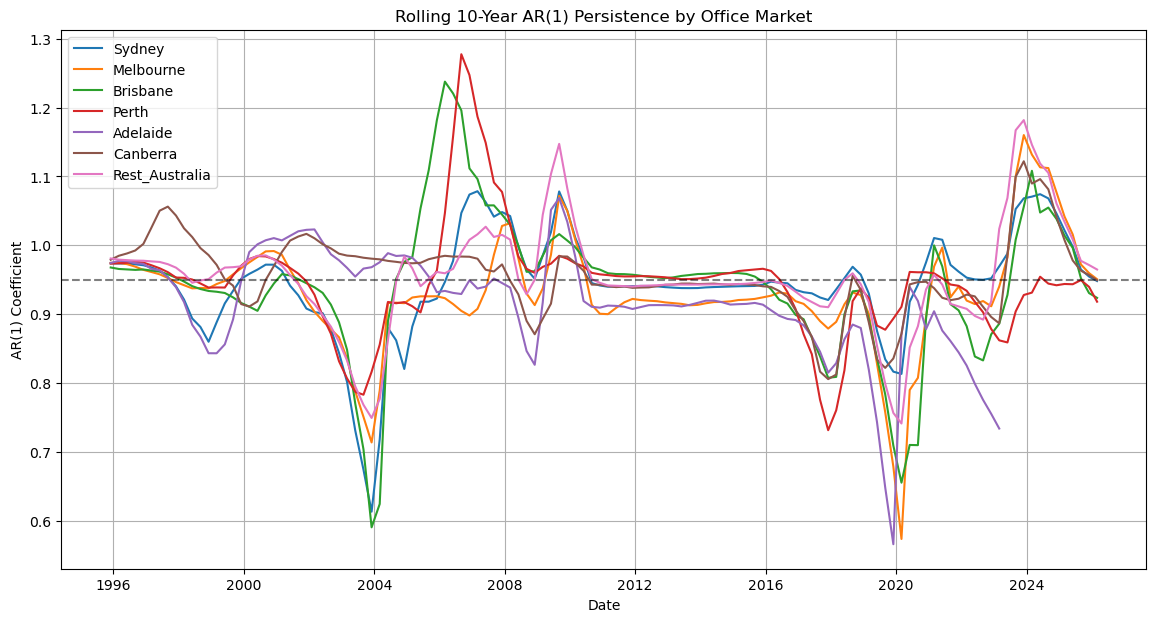

In [19]:
plt.figure(figsize=(14,7))

for market in markets:

    subset = rolling_df[
        rolling_df["Market"] == market
    ]

    plt.plot(
        subset["Date"],
        subset["AR1"],
        label=market
    )

plt.axhline(
    0.95,
    color="black",
    linestyle="--",
    alpha=0.5
)

plt.title(
    "Rolling 10-Year AR(1) Persistence by Office Market"
)

plt.ylabel("AR(1) Coefficient")
plt.xlabel("Date")

plt.legend()
plt.grid(True)

plt.show()

In [20]:
rolling_df["Decade"] = (
    rolling_df["Date"].dt.year // 10 * 10
)

decade_summary = (
    rolling_df
    .groupby(["Decade","Market"])
    ["AR1"]
    .mean()
    .reset_index()
)

print(decade_summary)

    Decade          Market       AR1
0     1990        Adelaide  0.926550
1     1990        Brisbane  0.948609
2     1990        Canberra  0.995215
3     1990       Melbourne  0.955601
4     1990           Perth  0.959730
5     1990  Rest_Australia  0.968031
6     1990          Sydney  0.937382
7     2000        Adelaide  0.969755
8     2000        Brisbane  0.971072
9     2000        Canberra  0.968764
10    2000       Melbourne  0.925609
11    2000           Perth  0.972687
12    2000  Rest_Australia  0.950655
13    2000          Sydney  0.931031
14    2010        Adelaide  0.880867
15    2010        Brisbane  0.922932
16    2010        Canberra  0.918136
17    2010       Melbourne  0.906398
18    2010           Perth  0.924455
19    2010  Rest_Australia  0.932670
20    2010          Sydney  0.935783
21    2020        Adelaide  0.844880
22    2020        Brisbane  0.925088
23    2020        Canberra  0.973264
24    2020       Melbourne  0.964809
25    2020           Perth  0.929702
2

In [21]:
trend_results = []

for market in markets:

    temp = rolling_df[
        rolling_df["Market"] == market
    ].copy()

    temp["Trend"] = np.arange(
        len(temp)
    )

    model = sm.OLS(
        temp["AR1"],
        sm.add_constant(
            temp["Trend"]
        )
    ).fit(
        cov_type="HAC",
        cov_kwds={"maxlags":4}
    )

    trend_results.append({
        "Market": market,
        "Trend_Coefficient":
            model.params["Trend"],
        "p_value":
            model.pvalues["Trend"],
        "R2":
            model.rsquared
    })

trend_results = pd.DataFrame(
    trend_results
)

print(trend_results)

           Market  Trend_Coefficient   p_value        R2
0          Sydney           0.000537  0.103214  0.064663
1       Melbourne           0.000127  0.779939  0.003179
2        Brisbane          -0.000327  0.465771  0.012810
3           Perth          -0.000459  0.082540  0.043596
4        Adelaide                NaN       NaN       NaN
5        Canberra          -0.000437  0.193119  0.076407
6  Rest_Australia           0.000205  0.619567  0.009311


In [22]:
with pd.ExcelWriter(
    "Rolling_Persistence_Analysis.xlsx"
) as writer:

    rolling_df.to_excel(
        writer,
        sheet_name="Rolling_AR1",
        index=False
    )

    decade_summary.to_excel(
        writer,
        sheet_name="Decade_Summary",
        index=False
    )

    trend_results.to_excel(
        writer,
        sheet_name="Trend_Tests",
        index=False
    )

print(
    "Saved: Rolling_Persistence_Analysis.xlsx"
)

Saved: Rolling_Persistence_Analysis.xlsx


In [23]:
import pandas as pd
import statsmodels.formula.api as smf

panel = office_df.melt(
    id_vars="Date",
    var_name="Market",
    value_name="Return"
)

panel = panel.sort_values(
    ["Market","Date"]
)

panel["Lagged_Return"] = (
    panel
    .groupby("Market")["Return"]
    .shift(1)
)

panel = panel.dropna()

In [24]:
model = smf.ols(
    "Return ~ Lagged_Return * C(Market)",
    data=panel
).fit()

print(model.summary())

ValueError: endog has evaluated to an array with multiple columns that has shape (1127, 1098). This occurs when the variable converted to endog is non-numeric (e.g., bool or str).

In [25]:
print(panel.dtypes)
print(panel["Return"].head())
print(panel["Return"].sample(20))

Date             datetime64[us]
Market                      str
Return                   object
Lagged_Return            object
dtype: object
649     19.10826
650    16.939092
651    16.310153
652    14.865911
653    14.529149
Name: Return, dtype: object
1120     3.599885
594     14.497161
788            --
859     -6.188193
607     -0.032708
105      9.168176
671     -6.095728
932     14.249286
997    -11.137376
845      8.456449
349     -2.160053
561      9.375043
1072     8.803145
814     19.327049
622      9.368334
869     14.769985
890     13.358237
434      8.482095
1071     6.798661
494      31.04147
Name: Return, dtype: object


In [26]:
panel = office_df.melt(
    id_vars="Date",
    var_name="Market",
    value_name="Return"
)

# convert to numeric
panel["Return"] = pd.to_numeric(
    panel["Return"].replace("--", np.nan),
    errors="coerce"
)

# remove bad rows
panel = panel.dropna(subset=["Return"])

# sort
panel = panel.sort_values(
    ["Market", "Date"]
)

# build lag
panel["Lagged_Return"] = (
    panel.groupby("Market")["Return"]
    .shift(1)
)

panel = panel.dropna(
    subset=["Lagged_Return"]
)

print(panel.dtypes)

Date             datetime64[us]
Market                      str
Return                  float64
Lagged_Return           float64
dtype: object


In [27]:
import statsmodels.formula.api as smf

model = smf.ols(
    "Return ~ Lagged_Return * C(Market)",
    data=panel
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Return   R-squared:                       0.942
Model:                            OLS   Adj. R-squared:                  0.941
Method:                 Least Squares   F-statistic:                     1347.
Date:                Fri, 21 Aug 2026   Prob (F-statistic):               0.00
Time:                        17:30:44   Log-Likelihood:                -2463.5
No. Observations:                1097   AIC:                             4955.
Df Residuals:                    1083   BIC:                             5025.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

In [28]:
quality = pd.read_excel(
    FILE,
    sheet_name="Quality Type",
    header=None
)

for i in range(10,25):
    print(i, quality.iloc[i,:15].tolist())

10 [np.float64(nan), np.float64(nan), 'Industrial by Grade Market Returns', nan, nan, np.float64(nan), 'Industrial by Grade Market Indices', nan, np.float64(nan), nan, nan, np.float64(nan), nan, nan, nan]
11 [np.float64(nan), np.float64(nan), nan, nan, nan, np.float64(nan), nan, nan, np.float64(nan), nan, nan, np.float64(nan), nan, nan, nan]
12 [np.float64(nan), np.float64(nan), nan, nan, nan, np.float64(nan), nan, nan, np.float64(nan), nan, nan, np.float64(nan), nan, nan, nan]
13 [np.float64(nan), np.float64(nan), nan, 'Total Return (%pa)', nan, np.float64(nan), 'Capital Return (%pa)', nan, np.float64(nan), 'Income Return (%pa)', nan, np.float64(nan), nan, 'Total Return (Rolling Annual %pa)', nan]
14 [np.float64(nan), np.float64(nan), 'Date / Period', 'Prime Office', 'Secondary Office', np.float64(nan), 'Prime Office', 'Secondary Office', np.float64(nan), 'Prime Office', 'Secondary Office', np.float64(nan), 'Date / Period', 'Premium CBD Office', 'Grade A - CBD Office']
15 [np.float64(

In [29]:
quality_df = quality.iloc[19:, 2:5].copy()

quality_df.columns = [
    "Date",
    "Prime_Office",
    "Secondary_Office"
]

quality_df["Date"] = pd.to_datetime(
    quality_df["Date"],
    errors="coerce"
)

quality_df["Prime_Office"] = pd.to_numeric(
    quality_df["Prime_Office"].replace("--", np.nan),
    errors="coerce"
)

quality_df["Secondary_Office"] = pd.to_numeric(
    quality_df["Secondary_Office"].replace("--", np.nan),
    errors="coerce"
)

quality_df = quality_df.dropna(subset=["Date"])

print(quality_df.head())

         Date  Prime_Office  Secondary_Office
19 1985-12-01     16.203239         13.920545
20 1986-03-01     16.958139         14.036452
21 1986-06-01     17.432232         14.354670
22 1986-09-01     18.797328         15.139313
23 1986-12-01     19.849795         15.811262


In [30]:
for col in ["Prime_Office", "Secondary_Office"]:

    beta, half_life = estimate_ar1(
        quality_df[col]
    )

    print(
        f"{col}: "
        f"AR1={beta:.4f}, "
        f"Half-Life={half_life/4:.2f} years"
    )

TypeError: cannot unpack non-iterable numpy.float64 object

In [31]:
print(estimate_ar1(quality_df["Prime_Office"]))

0.9672932591965689


In [32]:
print("Prime Office")
print(estimate_ar1(quality_df["Prime_Office"]))

print("Secondary Office")
print(estimate_ar1(quality_df["Secondary_Office"]))

Prime Office
0.9672932591965689
Secondary Office
0.9740252858425053


In [33]:
import statsmodels.formula.api as smf

panel = quality_df.melt(
    id_vars="Date",
    var_name="Segment",
    value_name="Return"
)

panel["Return"] = pd.to_numeric(
    panel["Return"],
    errors="coerce"
)

panel = panel.dropna()

panel = panel.sort_values(
    ["Segment", "Date"]
)

panel["Lagged_Return"] = (
    panel.groupby("Segment")["Return"]
    .shift(1)
)

panel = panel.dropna()

model = smf.ols(
    "Return ~ Lagged_Return * C(Segment)",
    data=panel
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Return   R-squared:                       0.944
Model:                            OLS   Adj. R-squared:                  0.944
Method:                 Least Squares   F-statistic:                     1798.
Date:                Fri, 21 Aug 2026   Prob (F-statistic):          5.01e-199
Time:                        17:33:50   Log-Likelihood:                -708.85
No. Observations:                 322   AIC:                             1426.
Df Residuals:                     318   BIC:                             1441.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

In [34]:
for i in range(14,18):
    print(quality.iloc[i,12:25].tolist())

['Date / Period', 'Premium CBD Office', 'Grade A - CBD Office', 'Grade B - CBD Office', 'Grade C & D - CBD Office', np.float64(nan), 'Premium CBD Office', 'Grade A - CBD Office', 'Grade B - CBD Office', 'Grade C & D - CBD Office', np.float64(nan), 'Premium CBD Office', 'Grade A - CBD Office']
[datetime.datetime(1984, 12, 1, 0, 0), '--', '--', '--', '--', np.float64(nan), '--', '--', '--', '--', np.float64(nan), '--', '--']
[datetime.datetime(1985, 3, 1, 0, 0), '--', '--', '--', '--', np.float64(nan), '--', '--', '--', '--', np.float64(nan), '--', '--']
[datetime.datetime(1985, 6, 1, 0, 0), '--', '--', '--', '--', np.float64(nan), '--', '--', '--', '--', np.float64(nan), '--', '--']


In [35]:
grade_df = quality.iloc[19:, 12:17].copy()

grade_df.columns = [
    "Date",
    "Premium_CBD",
    "Grade_A_CBD",
    "Grade_B_CBD",
    "Grade_CD_CBD"
]

grade_df["Date"] = pd.to_datetime(
    grade_df["Date"],
    errors="coerce"
)

for col in grade_df.columns[1:]:

    grade_df[col] = pd.to_numeric(
        grade_df[col].replace("--", np.nan),
        errors="coerce"
    )

grade_df = grade_df[
    grade_df["Date"].notna()
]

print(grade_df.head())


         Date  Premium_CBD  Grade_A_CBD  Grade_B_CBD  Grade_CD_CBD
19 1985-12-01          NaN    15.846465    11.896469     20.982225
20 1986-03-01          NaN    16.582432    12.514713     20.558465
21 1986-06-01          NaN    17.054175    13.660262     19.672267
22 1986-09-01          NaN    18.376916    14.818638     20.194116
23 1986-12-01          NaN    19.410483    16.013119     20.307076


In [36]:
print(grade_df.notna().sum())


Date            162
Premium_CBD     146
Grade_A_CBD     162
Grade_B_CBD     162
Grade_CD_CBD    134
dtype: int64


In [37]:
for col in [
    "Premium_CBD",
    "Grade_A_CBD",
    "Grade_B_CBD",
    "Grade_CD_CBD"
]:

    beta = estimate_ar1(
        grade_df[col]
    )

    print(
        f"{col}: {beta:.4f}"
    )

Premium_CBD: 0.9500
Grade_A_CBD: 0.9672
Grade_B_CBD: 0.9727
Grade_CD_CBD: 0.9663


In [38]:
panel = grade_df.melt(
    id_vars="Date",
    var_name="Segment",
    value_name="Return"
)

panel["Return"] = pd.to_numeric(
    panel["Return"],
    errors="coerce"
)

panel = panel.dropna()

panel = panel.sort_values(
    ["Segment","Date"]
)

panel["Lagged_Return"] = (
    panel.groupby("Segment")["Return"]
    .shift(1)
)

panel = panel.dropna()

In [39]:
import statsmodels.formula.api as smf

model = smf.ols(
    "Return ~ Lagged_Return * C(Segment)",
    data=panel
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Return   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.935
Method:                 Least Squares   F-statistic:                     1242.
Date:                Fri, 21 Aug 2026   Prob (F-statistic):               0.00
Time:                        17:35:51   Log-Likelihood:                -1378.1
No. Observations:                 600   AIC:                             2772.
Df Residuals:                     592   BIC:                             2807.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

In [40]:
for i in range(13,18):
    print(quality.iloc[i,:12].tolist())

[np.float64(nan), np.float64(nan), nan, 'Total Return (%pa)', nan, np.float64(nan), 'Capital Return (%pa)', nan, np.float64(nan), 'Income Return (%pa)', nan, np.float64(nan)]
[np.float64(nan), np.float64(nan), 'Date / Period', 'Prime Office', 'Secondary Office', np.float64(nan), 'Prime Office', 'Secondary Office', np.float64(nan), 'Prime Office', 'Secondary Office', np.float64(nan)]
[np.float64(nan), np.float64(nan), datetime.datetime(1984, 12, 1, 0, 0), '--', '--', np.float64(nan), '--', '--', np.float64(nan), '--', '--', np.float64(nan)]
[np.float64(nan), np.float64(nan), datetime.datetime(1985, 3, 1, 0, 0), '--', '--', np.float64(nan), '--', '--', np.float64(nan), '--', '--', np.float64(nan)]
[np.float64(nan), np.float64(nan), datetime.datetime(1985, 6, 1, 0, 0), '--', '--', np.float64(nan), '--', '--', np.float64(nan), '--', '--', np.float64(nan)]


In [41]:
vc_df = quality.iloc[19:, 2:11].copy()

vc_df.columns = [
    "Date",
    "TR_Prime",
    "TR_Secondary",
    "x1",
    "CR_Prime",
    "CR_Secondary",
    "x2",
    "IR_Prime",
    "IR_Secondary",
]

vc_df = vc_df.drop(columns=["x1","x2"])

vc_df["Date"] = pd.to_datetime(
    vc_df["Date"],
    errors="coerce"
)

for col in vc_df.columns[1:]:
    vc_df[col] = pd.to_numeric(
        vc_df[col].replace("--", np.nan),
        errors="coerce"
    )

In [42]:
for col in vc_df.columns[1:]:

    beta = estimate_ar1(vc_df[col])

    print(
        f"{col}: {beta:.4f}"
    )

TR_Prime: 0.9638
TR_Secondary: 0.9704
CR_Prime: 0.9639
CR_Secondary: 0.9705
IR_Prime: 0.9903
IR_Secondary: 0.9934


In [43]:
for i in range(12,18):
    print(i, cap.iloc[i,:20].tolist())

NameError: name 'cap' is not defined

In [44]:
cap = pd.read_excel(
    FILE,
    sheet_name="Cap Rates",
    header=None
)

In [45]:
for i in range(12,18):
    print(i, cap.iloc[i,:20].tolist())

12 [np.float64(nan), np.float64(nan), nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]
13 [np.float64(nan), np.float64(nan), nan, 'Weighted Average Cap Rate', nan, nan, nan, nan, nan, 'Weighted Average Cap Rate', nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]
14 [np.float64(nan), np.float64(nan), 'Date / Period', 'All Property    ', 'Retail', 'Office', 'Industrial', 'Other', nan, 'Office - CBD', 'Office - Non-CBD', 'Retail - Super and Major Regional', 'Retail - Regional', 'Retail - Sub Regional', 'Retail - Neighbourhood', 'Large Format Retail', 'Retail - Other', 'Industrial - Warehouse', 'Industrial - Distribution', 'Industrial - High Tech Business Park']
15 [np.float64(nan), np.float64(nan), datetime.datetime(1984, 12, 1, 0, 0), '--', '--', '--', '--', '--', nan, '--', '--', '--', '--', '--', '--', '--', '--', '--', '--', '--']
16 [np.float64(nan), np.float64(nan), datetime.datetime(1985, 3, 1, 0, 0), '--', '--', '--', '--', '--', nan, '--',

In [46]:
cap_df = cap.iloc[19:, 2:20].copy()

cap_df.columns = [
    "Date",
    "All_Property",
    "Retail",
    "Office",
    "Industrial",
    "Other",
    "Office_CBD",
    "Office_NonCBD",
    "Retail_SuperMajor",
    "Retail_Regional",
    "Retail_SubRegional",
    "Retail_Neighbourhood",
    "Retail_LFR",
    "Retail_Other",
    "Industrial_Warehouse",
    "Industrial_Distribution",
    "Industrial_HighTech"
]

cap_df["Date"] = pd.to_datetime(
    cap_df["Date"],
    errors="coerce"
)

for col in cap_df.columns[1:]:

    cap_df[col] = pd.to_numeric(
        cap_df[col].replace("--", np.nan),
        errors="coerce"
    )

cap_df = cap_df[
    cap_df["Date"].notna()
]

print(cap_df.head())

ValueError: Length mismatch: Expected axis has 18 elements, new values have 17 elements

In [47]:
cap_df = cap.iloc[19:, 2:20].copy()

print(cap_df.shape)
print(cap.iloc[14, 2:20].tolist())

(162, 18)
['Date / Period', 'All Property    ', 'Retail', 'Office', 'Industrial', 'Other', nan, 'Office - CBD', 'Office - Non-CBD', 'Retail - Super and Major Regional', 'Retail - Regional', 'Retail - Sub Regional', 'Retail - Neighbourhood', 'Large Format Retail', 'Retail - Other', 'Industrial - Warehouse', 'Industrial - Distribution', 'Industrial - High Tech Business Park']


In [48]:
cap_df = cap.iloc[19:, 2:20].copy()

cap_df.columns = cap.iloc[14, 2:20]

# remove blank separator column
cap_df = cap_df.loc[:, cap_df.columns.notna()]

# rename date column
cap_df.rename(
    columns={"Date / Period": "Date"},
    inplace=True
)

cap_df["Date"] = pd.to_datetime(
    cap_df["Date"],
    errors="coerce"
)

for col in cap_df.columns[1:]:

    cap_df[col] = pd.to_numeric(
        cap_df[col].replace("--", np.nan),
        errors="coerce"
    )

cap_df = cap_df[
    cap_df["Date"].notna()
]

In [49]:
results = []

for col in cap_df.columns[1:]:

    series = cap_df[col].dropna()

    if len(series) > 30:

        beta = estimate_ar1(series)

        results.append({
            "Segment": col,
            "AR1": beta,
            "Obs": len(series)
        })

cap_results = (
    pd.DataFrame(results)
    .sort_values(
        "AR1",
        ascending=False
    )
)

print(cap_results)

                                 Segment       AR1  Obs
4                                  Other  0.998352   80
10                Retail - Neighbourhood  0.991843   84
15  Industrial - High Tech Business Park  0.991346   82
13                Industrial - Warehouse  0.989913   85
14             Industrial - Distribution  0.988992   83
3                             Industrial  0.987537  127
6                       Office - Non-CBD  0.984017   85
9                  Retail - Sub Regional  0.979762   84
5                           Office - CBD  0.978063   85
0                       All Property      0.976969  128
2                                 Office  0.973846  128
12                        Retail - Other  0.972213   83
11                   Large Format Retail  0.971503   42
1                                 Retail  0.971330  128
7      Retail - Super and Major Regional  0.964001   85
8                      Retail - Regional  0.941813   82


In [50]:
disc = pd.read_excel(
    FILE,
    sheet_name="Discount Rates",
    header=None
)

In [51]:
for i in range(12,18):
    print(i, disc.iloc[i,:20].tolist())

12 [np.float64(nan), np.float64(nan), nan, nan, nan, nan, nan, nan, np.float64(nan), nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]
13 [np.float64(nan), np.float64(nan), nan, 'Weighted Average Discount Rate', nan, nan, nan, nan, np.float64(nan), 'Weighted Average Discount Rate', nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]
14 [np.float64(nan), np.float64(nan), 'Date / Period', 'All Property    ', 'Retail', 'Office', 'Industrial', 'Other', np.float64(nan), 'Office - CBD', 'Office - Non-CBD', 'Retail - Super and Major Regional', 'Retail - Regional', 'Retail - Sub Regional', 'Retail - Neighbourhood', 'Large Format Retail', 'Retail - Other', 'Industrial - Warehouse', 'Industrial - Distribution', 'Industrial - High Tech Business Park']
15 [np.float64(nan), np.float64(nan), datetime.datetime(1984, 12, 1, 0, 0), '--', '--', '--', '--', '--', np.float64(nan), '--', '--', '--', '--', '--', '--', '--', '--', '--', '--', '--']
16 [np.float64(nan), np.float64(nan), datetime.datetime(1

In [52]:
disc_df = disc.iloc[19:, 2:20].copy()

disc_df.columns = disc.iloc[14, 2:20]

# drop separator column
disc_df = disc_df.loc[:, disc_df.columns.notna()]

disc_df.rename(
    columns={"Date / Period": "Date"},
    inplace=True
)

disc_df["Date"] = pd.to_datetime(
    disc_df["Date"],
    errors="coerce"
)

for col in disc_df.columns[1:]:

    disc_df[col] = pd.to_numeric(
        disc_df[col].replace("--", np.nan),
        errors="coerce"
    )

disc_df = disc_df[
    disc_df["Date"].notna()
]

In [53]:
disc_results = []

for col in disc_df.columns[1:]:

    series = disc_df[col].dropna()

    if len(series) > 30:

        beta = estimate_ar1(series)

        disc_results.append({
            "Segment": col,
            "AR1": beta,
            "Obs": len(series)
        })

disc_results = (
    pd.DataFrame(disc_results)
    .sort_values(
        "AR1",
        ascending=False
    )
)

print(disc_results)

                                 Segment       AR1  Obs
0                       All Property      0.994804  138
2                                 Office  0.994733  138
5                           Office - CBD  0.994262  138
9                  Retail - Sub Regional  0.990796  136
4                                  Other  0.990505   87
10                Retail - Neighbourhood  0.990163  123
8                      Retail - Regional  0.989554  131
7      Retail - Super and Major Regional  0.988954  134
15  Industrial - High Tech Business Park  0.988821  118
14             Industrial - Distribution  0.984608  125
6                       Office - Non-CBD  0.982303  134
3                             Industrial  0.979578  134
13                Industrial - Warehouse  0.978805  129
1                                 Retail  0.970600  137
11                   Large Format Retail  0.967566   66
12                        Retail - Other  0.940049  107


In [54]:
summary = pd.DataFrame({
    "Variable":[
        "Capital Return (Prime)",
        "Capital Return (Secondary)",
        "Income Return (Prime)",
        "Income Return (Secondary)",
        "Cap Rate - Office",
        "Discount Rate - Office"
    ],
    "AR1":[
        estimate_ar1(vc_df["CR_Prime"]),
        estimate_ar1(vc_df["CR_Secondary"]),
        estimate_ar1(vc_df["IR_Prime"]),
        estimate_ar1(vc_df["IR_Secondary"]),
        estimate_ar1(cap_df["Office"]),
        estimate_ar1(disc_df["Office"])
    ]
})

print(summary)

                     Variable       AR1
0      Capital Return (Prime)  0.963944
1  Capital Return (Secondary)  0.970473
2       Income Return (Prime)  0.990266
3   Income Return (Secondary)  0.993435
4           Cap Rate - Office  0.973846
5      Discount Rate - Office  0.994733


In [55]:
def half_life(beta):

    if 0 < beta < 1:
        return np.log(0.5) / np.log(beta)

    return np.nan

summary["Half_Life_Qtrs"] = summary["AR1"].apply(
    half_life
)

summary["Half_Life_Yrs"] = (
    summary["Half_Life_Qtrs"] / 4
)

print(summary)

                     Variable       AR1  Half_Life_Qtrs  Half_Life_Yrs
0      Capital Return (Prime)  0.963944       18.875276       4.718819
1  Capital Return (Secondary)  0.970473       23.126850       5.781712
2       Income Return (Prime)  0.990266       70.858545      17.714636
3   Income Return (Secondary)  0.993435      105.227825      26.306956
4           Cap Rate - Office  0.973846       26.154624       6.538656
5      Discount Rate - Office  0.994733      131.260963      32.815241


In [56]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

valuation_panel = pd.DataFrame({
    "Capital_Return": vc_df["CR_Prime"],
    "Income_Return": vc_df["IR_Prime"],
    "Cap_Rate": cap_df["Office"],
    "Discount_Rate": disc_df["Office"]
})

valuation_panel["Date"] = vc_df["Date"]

panel = valuation_panel.melt(
    id_vars="Date",
    var_name="Variable",
    value_name="Value"
)

panel["Value"] = pd.to_numeric(
    panel["Value"],
    errors="coerce"
)

panel = panel.dropna()

panel = panel.sort_values(
    ["Variable", "Date"]
)

panel["Lagged"] = (
    panel.groupby("Variable")["Value"]
    .shift(1)
)

panel = panel.dropna()

In [57]:
model = smf.ols(
    "Value ~ Lagged * C(Variable)",
    data=panel
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       0.956
Model:                            OLS   Adj. R-squared:                  0.955
Method:                 Least Squares   F-statistic:                     1789.
Date:                Fri, 21 Aug 2026   Prob (F-statistic):               0.00
Time:                        17:43:37   Log-Likelihood:                -907.08
No. Observations:                 586   AIC:                             1830.
Df Residuals:                     578   BIC:                             1865.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


In [58]:
print(
    model.f_test("""
    Lagged:C(Variable)[T.Income_Return] = 0,
    Lagged:C(Variable)[T.Cap_Rate] = 0,
    Lagged:C(Variable)[T.Discount_Rate] = 0
    """)
)

PatsyError: unrecognized token in constraint
    
    Lagged:C(Variable)[T.Income_Return] = 0,
    Lagged:C(Variable)[T.Cap_Rate] = 0,
    Lagged:C(Variable)[T.Discount_Rate] = 0
    
                                                            ^

In [59]:
print(model.params.index.tolist())



['Intercept', 'C(Variable)[T.Capital_Return]', 'C(Variable)[T.Discount_Rate]', 'C(Variable)[T.Income_Return]', 'Lagged', 'Lagged:C(Variable)[T.Capital_Return]', 'Lagged:C(Variable)[T.Discount_Rate]', 'Lagged:C(Variable)[T.Income_Return]']


In [60]:
model.f_test([
    "Lagged:C(Variable)[T.Capital_Return] = 0",
    "Lagged:C(Variable)[T.Discount_Rate] = 0",
    "Lagged:C(Variable)[T.Income_Return] = 0"
])

<class 'statsmodels.stats.contrast.ContrastResults'>
<F test: F=0.11886111401731748, p=0.9490183202202607, df_denom=578, df_num=3>

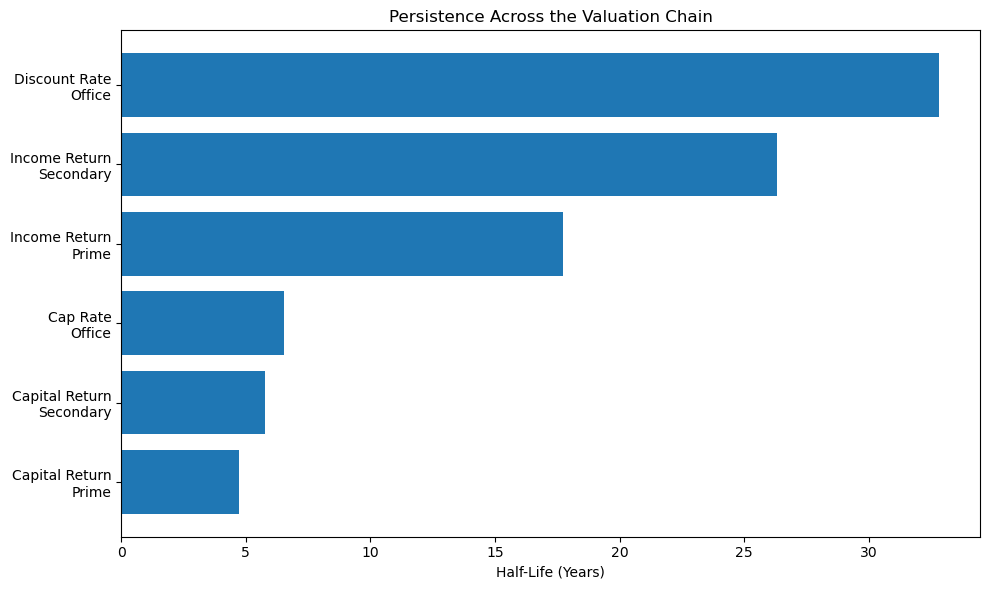

In [61]:
import matplotlib.pyplot as plt

summary = pd.DataFrame({
    "Variable": [
        "Capital Return\nPrime",
        "Capital Return\nSecondary",
        "Cap Rate\nOffice",
        "Income Return\nPrime",
        "Income Return\nSecondary",
        "Discount Rate\nOffice"
    ],
    "Half_Life_Yrs": [
        4.718819,
        5.781712,
        6.538656,
        17.714636,
        26.306956,
        32.815241
    ]
})

summary = summary.sort_values(
    "Half_Life_Yrs"
)

plt.figure(figsize=(10,6))

plt.barh(
    summary["Variable"],
    summary["Half_Life_Yrs"]
)

plt.xlabel("Half-Life (Years)")
plt.title(
    "Persistence Across the Valuation Chain"
)

plt.tight_layout()
plt.show()

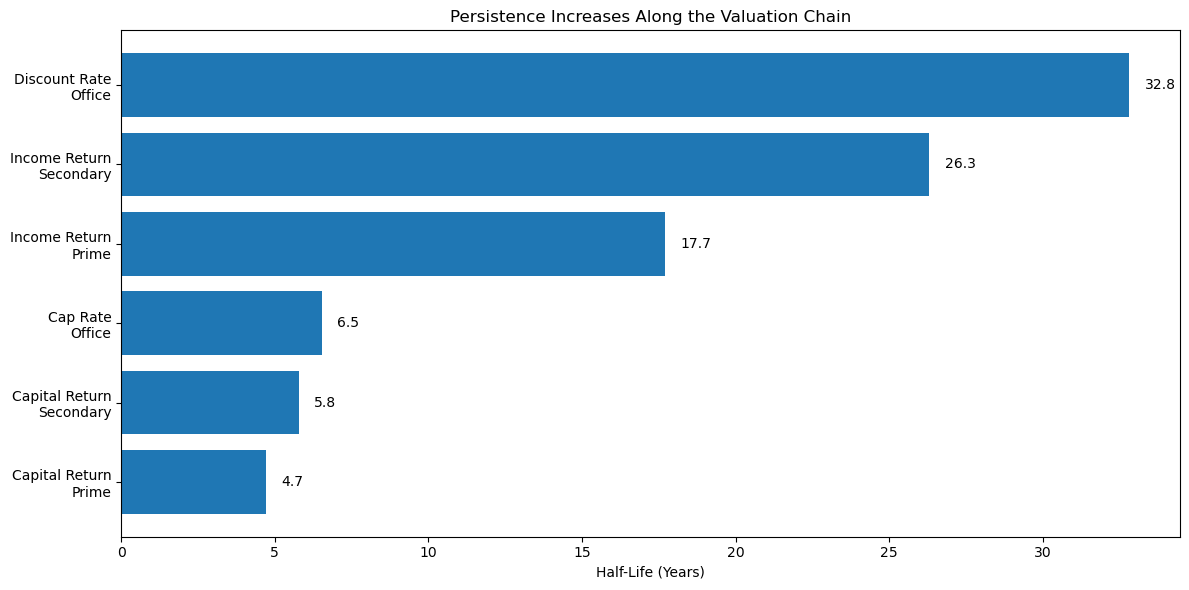

In [62]:
import matplotlib.pyplot as plt

summary = summary.sort_values("Half_Life_Yrs")

plt.figure(figsize=(12,6))

bars = plt.barh(
    summary["Variable"],
    summary["Half_Life_Yrs"]
)

for bar in bars:
    plt.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():.1f}",
        va="center"
    )

plt.xlabel("Half-Life (Years)")
plt.title(
    "Persistence Increases Along the Valuation Chain"
)

plt.tight_layout()
plt.show()


In [63]:
def estimate_ar1_stats(series):

    series = pd.to_numeric(
        series,
        errors="coerce"
    ).dropna()

    y = series.iloc[1:]
    x = series.shift(1).iloc[1:]

    model = sm.OLS(
        y,
        sm.add_constant(x)
    ).fit(
        cov_type="HAC",
        cov_kwds={"maxlags":4}
    )

    return {
        "beta": model.params.iloc[1],
        "se": model.bse.iloc[1]
    }

In [64]:
variables = {
    "Capital Return": vc_df["CR_Prime"],
    "Income Return": vc_df["IR_Prime"],
    "Cap Rate": cap_df["Office"],
    "Discount Rate": disc_df["Office"]
}

results = []

for name, series in variables.items():

    stats = estimate_ar1_stats(series)

    results.append({
        "Variable": name,
        "AR1": stats["beta"],
        "SE": stats["se"],
        "Lower": stats["beta"] - 1.96*stats["se"],
        "Upper": stats["beta"] + 1.96*stats["se"]
    })

results = pd.DataFrame(results)

print(results)

         Variable       AR1        SE     Lower     Upper
0  Capital Return  0.963944  0.039417  0.886687  1.041200
1   Income Return  0.990266  0.015390  0.960101  1.020430
2        Cap Rate  0.973846  0.017717  0.939121  1.008572
3   Discount Rate  0.994733  0.008802  0.977481  1.011985


                     Variable       AR1  Half_Life_Yrs
0      Capital Return (Prime)  0.963944       4.718819
1  Capital Return (Secondary)  0.970473       5.781712
2           Cap Rate (Office)  0.973846       6.538656
3       Income Return (Prime)  0.990266      17.714636
4   Income Return (Secondary)  0.993435      26.306956
5      Discount Rate (Office)  0.994733      32.815241


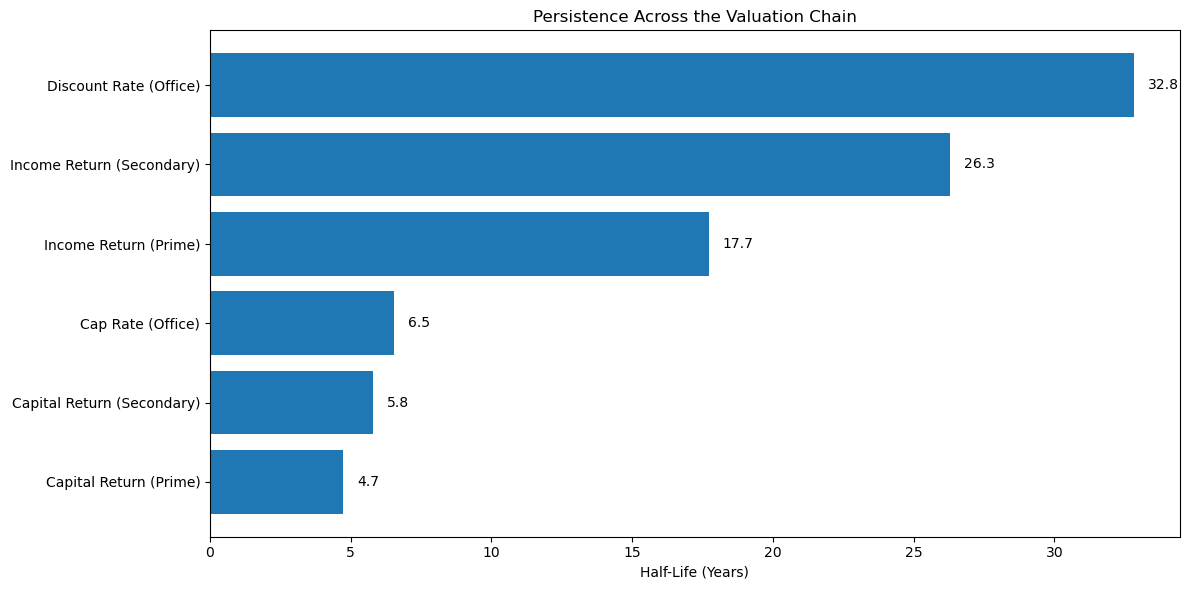

         Variable       AR1        SE     Lower     Upper
0  Capital Return  0.963944  0.039417  0.886687  1.041201
1   Income Return  0.990266  0.015390  0.960102  1.020430
2        Cap Rate  0.973846  0.017717  0.939121  1.008571
3   Discount Rate  0.994733  0.008802  0.977481  1.011985


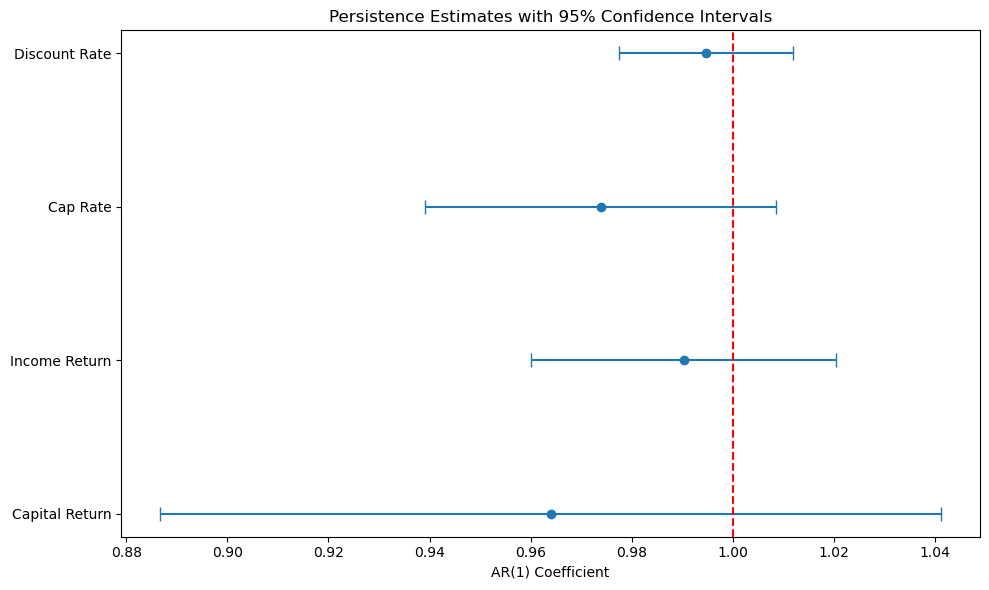


Saved files:
- Final_Persistence_Results.xlsx
- Valuation_Chain_Half_Life.png
- Persistence_Confidence_Intervals.png


In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#################################################
# FINAL VALUATION CHAIN SUMMARY
#################################################

summary = pd.DataFrame({
    "Variable": [
        "Capital Return (Prime)",
        "Capital Return (Secondary)",
        "Cap Rate (Office)",
        "Income Return (Prime)",
        "Income Return (Secondary)",
        "Discount Rate (Office)"
    ],
    "AR1": [
        0.963944,
        0.970473,
        0.973846,
        0.990266,
        0.993435,
        0.994733
    ],
    "Half_Life_Yrs": [
        4.718819,
        5.781712,
        6.538656,
        17.714636,
        26.306956,
        32.815241
    ]
})

summary = summary.sort_values(
    "Half_Life_Yrs"
)

print(summary)

#################################################
# FIGURE 1
# Persistence Across the Valuation Chain
#################################################

plt.figure(figsize=(12,6))

bars = plt.barh(
    summary["Variable"],
    summary["Half_Life_Yrs"]
)

for bar in bars:

    plt.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():.1f}",
        va="center"
    )

plt.xlabel("Half-Life (Years)")

plt.title(
    "Persistence Across the Valuation Chain"
)

plt.tight_layout()

plt.savefig(
    "Valuation_Chain_Half_Life.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#################################################
# CONFIDENCE INTERVAL TABLE
#################################################

ci_results = pd.DataFrame({
    "Variable": [
        "Capital Return",
        "Income Return",
        "Cap Rate",
        "Discount Rate"
    ],
    "AR1": [
        0.963944,
        0.990266,
        0.973846,
        0.994733
    ],
    "SE": [
        0.039417,
        0.015390,
        0.017717,
        0.008802
    ]
})

ci_results["Lower"] = (
    ci_results["AR1"]
    - 1.96 * ci_results["SE"]
)

ci_results["Upper"] = (
    ci_results["AR1"]
    + 1.96 * ci_results["SE"]
)

print(ci_results)

#################################################
# FIGURE 2
# AR(1) Confidence Intervals
#################################################

plt.figure(figsize=(10,6))

plt.errorbar(
    ci_results["AR1"],
    ci_results["Variable"],
    xerr=1.96 * ci_results["SE"],
    fmt="o",
    capsize=5
)

plt.axvline(
    1.0,
    color="red",
    linestyle="--"
)

plt.xlabel("AR(1) Coefficient")

plt.title(
    "Persistence Estimates with 95% Confidence Intervals"
)

plt.tight_layout()

plt.savefig(
    "Persistence_Confidence_Intervals.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#################################################
# EXPORT
#################################################

with pd.ExcelWriter(
    "Final_Persistence_Results.xlsx"
) as writer:

    summary.to_excel(
        writer,
        sheet_name="Half_Life_Summary",
        index=False
    )

    ci_results.to_excel(
        writer,
        sheet_name="Confidence_Intervals",
        index=False
    )

print(
    "\nSaved files:"
)
print(
    "- Final_Persistence_Results.xlsx"
)
print(
    "- Valuation_Chain_Half_Life.png"
)
print(
    "- Persistence_Confidence_Intervals.png"
)

In [66]:
import statsmodels.api as sm

predictors = {
    "Income_Return": vc_df["IR_Prime"],
    "Cap_Rate": cap_df["Office"],
    "Discount_Rate": disc_df["Office"]
}

future_capret = vc_df["CR_Prime"].shift(-1)

for name, predictor in predictors.items():

    temp = pd.DataFrame({
        "y": future_capret,
        "x": predictor
    }).dropna()

    model = sm.OLS(
        temp["y"],
        sm.add_constant(temp["x"])
    ).fit(
        cov_type="HAC",
        cov_kwds={"maxlags":4}
    )

    print("\n", name)
    print(model.summary())


 Income_Return
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                    0.1624
Date:                Fri, 21 Aug 2026   Prob (F-statistic):              0.687
Time:                        17:50:24   Log-Likelihood:                -591.35
No. Observations:                 165   AIC:                             1187.
Df Residuals:                     163   BIC:                             1193.
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.6992      9.935    

In [67]:
decomp = pd.DataFrame({
    "Prime_Office": [
        vc_df["IR_Prime"].mean(),
        vc_df["CR_Prime"].mean(),
        vc_df["TR_Prime"].mean()
    ],
    "Secondary_Office": [
        vc_df["IR_Secondary"].mean(),
        vc_df["CR_Secondary"].mean(),
        vc_df["TR_Secondary"].mean()
    ]
},
index=[
    "Income_Return",
    "Capital_Return",
    "Total_Return"
])

print(decomp.round(2))

                Prime_Office  Secondary_Office
Income_Return           6.31              7.08
Capital_Return          1.99              1.18
Total_Return            8.40              8.30


In [68]:
results = []

for name, ir, cr in [
    ("Prime", vc_df["IR_Prime"], vc_df["CR_Prime"]),
    ("Secondary", vc_df["IR_Secondary"], vc_df["CR_Primedary"])
]:

    income = ir.mean()
    capital = cr.mean()
    total = income + capital

    results.append({
        "Segment": name,
        "Income_%_of_Total": income/total,
        "Capital_%_of_Total": capital/total
    })

pd.DataFrame(results)

KeyError: 'CR_Primedary'

In [69]:
results = []

for name, ir, cr in [
    ("Prime", vc_df["IR_Prime"], vc_df["CR_Prime"]),
    ("Secondary", vc_df["IR_Secondary"], vc_df["CR_Secondary"])
]:

    income = ir.mean()
    capital = cr.mean()
    total = income + capital

    results.append({
        "Segment": name,
        "Income_Return": income,
        "Capital_Return": capital,
        "Income_%_of_Total": income / total,
        "Capital_%_of_Total": capital / total
    })

wealth_decomp = pd.DataFrame(results)

print(wealth_decomp)

     Segment  Income_Return  Capital_Return  Income_%_of_Total  \
0      Prime       6.313849        1.985536           0.760761   
1  Secondary       7.076200        1.183372           0.856727   

   Capital_%_of_Total  
0            0.239239  
1            0.143273  


In [70]:
results = []

for sector in ["Office", "Retail", "Industrial"]:

    ir = sector_df[f"{sector}_Income"]
    cr = sector_df[f"{sector}_Capital"]

    income = ir.mean()
    capital = cr.mean()

    total = income + capital

    results.append({
        "Sector": sector,
        "Income_Return": income,
        "Capital_Return": capital,
        "Income_%_of_Total": income / total,
        "Capital_%_of_Total": capital / total
    })

sector_decomp = pd.DataFrame(results)

print(sector_decomp.round(3))

NameError: name 'sector_df' is not defined

In [71]:
sector = pd.read_excel(
    FILE,
    sheet_name="Sector Returns",
    header=None
)

for i in range(12,20):
    print(i, sector.iloc[i,:20].tolist())


ValueError: Worksheet named 'Sector Returns' not found

In [72]:
xls = pd.ExcelFile(FILE)

print(xls.sheet_names)

['MSCI', 'Summary', 'Trends', 'Primary Sectors', 'Databank Profile', 'Sectors', 'Retail Locations', 'Office Locations', 'Industrial Locations', 'Quality Type', 'Pricing Summary', 'Cap Rates', 'Discount Rates', 'Asset Class', 'Risk', 'Information']


In [73]:
sectors = pd.read_excel(
    FILE,
    sheet_name="Sectors",
    header=None
)

for i in range(12,20):
    print(i, sectors.iloc[i,:20].tolist())

12 [np.float64(nan), np.float64(nan), nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, np.float64(nan), nan, nan]
13 [np.float64(nan), np.float64(nan), nan, 'Total Return (Rolling Annual %pa)', nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, np.float64(nan), 'Capital Return (Rolling Annual %pa)', nan]
14 [np.float64(nan), np.float64(nan), 'Date / Period', 'Office - CBD', 'Office - Non-CBD', 'Retail - Super and Major Regional', 'Retail - Regional', 'Retail - Sub Regional', 'Retail - Neighbourhood', 'Large Format Retail', 'Retail - Other', 'Industrial - Warehouse', 'Industrial - Distribution', 'Industrial - High Tech Business Park', 'Industrial - Industrial Estate', 'Industrial - Other', 'Other', np.float64(nan), 'Office - CBD', 'Office - Non-CBD']
15 [np.float64(nan), np.float64(nan), datetime.datetime(1984, 12, 1, 0, 0), '--', '--', '--', '--', '--', '--', '--', '--', '--', '--', '--', '--', '--', '--', np.float64(nan), '--', '--']
16 [np.floa

In [74]:
for i in range(13,16):
    print(sectors.iloc[i, :40].tolist())

[np.float64(nan), np.float64(nan), nan, 'Total Return (Rolling Annual %pa)', nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, np.float64(nan), 'Capital Return (Rolling Annual %pa)', nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, np.float64(nan), 'Income Return (Rolling Annual %pa)', nan, nan, nan, nan, nan, nan]
[np.float64(nan), np.float64(nan), 'Date / Period', 'Office - CBD', 'Office - Non-CBD', 'Retail - Super and Major Regional', 'Retail - Regional', 'Retail - Sub Regional', 'Retail - Neighbourhood', 'Large Format Retail', 'Retail - Other', 'Industrial - Warehouse', 'Industrial - Distribution', 'Industrial - High Tech Business Park', 'Industrial - Industrial Estate', 'Industrial - Other', 'Other', np.float64(nan), 'Office - CBD', 'Office - Non-CBD', 'Retail - Super and Major Regional', 'Retail - Regional', 'Retail - Sub Regional', 'Retail - Neighbourhood', 'Large Format Retail', 'Retail - Other', 'Industrial - Warehouse', 'Industrial - Distributio

In [75]:
sector_df = sectors.iloc[19:, :50].copy()

# Total Return block
tr_cols = list(range(3, 17))

# Capital Return block
cr_cols = list(range(18, 32))

# Income Return block
ir_cols = list(range(33, 47))

names = sectors.iloc[14, tr_cols].tolist()

print(names)

['Office - CBD', 'Office - Non-CBD', 'Retail - Super and Major Regional', 'Retail - Regional', 'Retail - Sub Regional', 'Retail - Neighbourhood', 'Large Format Retail', 'Retail - Other', 'Industrial - Warehouse', 'Industrial - Distribution', 'Industrial - High Tech Business Park', 'Industrial - Industrial Estate', 'Industrial - Other', 'Other']


In [76]:
results = []

for i, name in enumerate(names):

    total = pd.to_numeric(
        sector_df.iloc[:, tr_cols[i]],
        errors="coerce"
    )

    capital = pd.to_numeric(
        sector_df.iloc[:, cr_cols[i]],
        errors="coerce"
    )

    income = pd.to_numeric(
        sector_df.iloc[:, ir_cols[i]],
        errors="coerce"
    )

    avg_total = total.mean()
    avg_capital = capital.mean()
    avg_income = income.mean()

    results.append({
        "Segment": name,
        "Income_Return": avg_income,
        "Capital_Return": avg_capital,
        "Income_Share": avg_income / avg_total,
        "Capital_Share": avg_capital / avg_total,
        "Income_to_Capital":
            avg_income / avg_capital
    })

wealth_sources = pd.DataFrame(results)

wealth_sources = wealth_sources.sort_values(
    "Income_to_Capital",
    ascending=False
)

print(
    wealth_sources.round(3)
)

                                 Segment  Income_Return  Capital_Return  \
7                         Retail - Other          7.090           1.062   
1                       Office - Non-CBD          7.398           1.127   
4                  Retail - Sub Regional          8.174           2.015   
5                 Retail - Neighbourhood          8.266           2.084   
0                           Office - CBD          6.414           1.715   
9              Industrial - Distribution          7.859           2.236   
10  Industrial - High Tech Business Park          7.314           2.189   
3                      Retail - Regional          7.511           2.260   
6                    Large Format Retail          8.108           2.688   
12                    Industrial - Other          8.202           2.720   
11        Industrial - Industrial Estate          7.710           2.888   
13                                 Other          7.347           2.797   
8                 Industr

In [77]:
sector_df = sectors.iloc[19:, :50].copy()

# Total Return block
tr_cols = list(range(3, 17))

# Capital Return block
cr_cols = list(range(18, 32))

# Income Return block
ir_cols = list(range(33, 47))

names = sectors.iloc[14, tr_cols].tolist()

print(names)

['Office - CBD', 'Office - Non-CBD', 'Retail - Super and Major Regional', 'Retail - Regional', 'Retail - Sub Regional', 'Retail - Neighbourhood', 'Large Format Retail', 'Retail - Other', 'Industrial - Warehouse', 'Industrial - Distribution', 'Industrial - High Tech Business Park', 'Industrial - Industrial Estate', 'Industrial - Other', 'Other']


In [78]:
results = []

for i, name in enumerate(names):

    total = pd.to_numeric(
        sector_df.iloc[:, tr_cols[i]],
        errors="coerce"
    )

    capital = pd.to_numeric(
        sector_df.iloc[:, cr_cols[i]],
        errors="coerce"
    )

    income = pd.to_numeric(
        sector_df.iloc[:, ir_cols[i]],
        errors="coerce"
    )

    avg_total = total.mean()
    avg_capital = capital.mean()
    avg_income = income.mean()

    results.append({
        "Segment": name,
        "Income_Return": avg_income,
        "Capital_Return": avg_capital,
        "Income_Share": avg_income / avg_total,
        "Capital_Share": avg_capital / avg_total,
        "Income_to_Capital":
            avg_income / avg_capital
    })

wealth_sources = pd.DataFrame(results)

wealth_sources = wealth_sources.sort_values(
    "Income_to_Capital",
    ascending=False
)

print(
    wealth_sources.round(3)
)

                                 Segment  Income_Return  Capital_Return  \
7                         Retail - Other          7.090           1.062   
1                       Office - Non-CBD          7.398           1.127   
4                  Retail - Sub Regional          8.174           2.015   
5                 Retail - Neighbourhood          8.266           2.084   
0                           Office - CBD          6.414           1.715   
9              Industrial - Distribution          7.859           2.236   
10  Industrial - High Tech Business Park          7.314           2.189   
3                      Retail - Regional          7.511           2.260   
6                    Large Format Retail          8.108           2.688   
12                    Industrial - Other          8.202           2.720   
11        Industrial - Industrial Estate          7.710           2.888   
13                                 Other          7.347           2.797   
8                 Industr

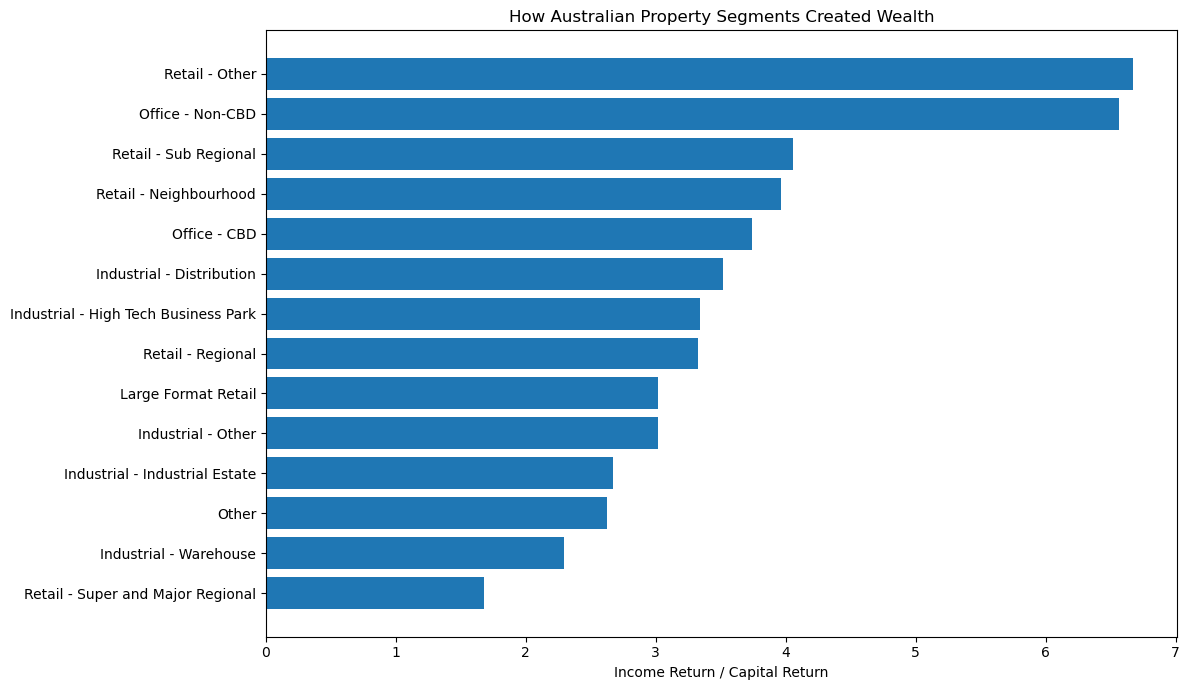

In [79]:
import matplotlib.pyplot as plt

top = wealth_sources.sort_values(
    "Income_to_Capital",
    ascending=True
)

plt.figure(figsize=(12,7))

plt.barh(
    top["Segment"],
    top["Income_to_Capital"]
)

plt.xlabel("Income Return / Capital Return")

plt.title(
    "How Australian Property Segments Created Wealth"
)

plt.tight_layout()
plt.show()

In [80]:
import pandas as pd
import numpy as np

wealth_results = []

for i, name in enumerate(names):

    total = pd.to_numeric(
        sector_df.iloc[:, tr_cols[i]],
        errors="coerce"
    ).dropna()

    capital = pd.to_numeric(
        sector_df.iloc[:, cr_cols[i]],
        errors="coerce"
    ).dropna()

    income = pd.to_numeric(
        sector_df.iloc[:, ir_cols[i]],
        errors="coerce"
    ).dropna()

    total_wealth = np.prod(1 + total/100)
    income_wealth = np.prod(1 + income/100)
    capital_wealth = np.prod(1 + capital/100)

    wealth_results.append({
        "Segment": name,
        "Total_Wealth_Multiple": total_wealth,
        "Income_Wealth_Multiple": income_wealth,
        "Capital_Wealth_Multiple": capital_wealth,
        "Income_to_Capital_Wealth":
            income_wealth / capital_wealth
    })

wealth_results = pd.DataFrame(
    wealth_results
)

wealth_results = wealth_results.sort_values(
    "Income_to_Capital_Wealth",
    ascending=False
)

print(
    wealth_results.round(2)
)

                                 Segment  Total_Wealth_Multiple  \
1                       Office - Non-CBD              597054.95   
4                  Retail - Sub Regional            10798486.86   
5                 Retail - Neighbourhood             7531649.37   
7                         Retail - Other              145573.33   
12                    Industrial - Other            15036616.29   
3                      Retail - Regional             4851891.27   
9              Industrial - Distribution             1787832.57   
0                           Office - CBD              288959.38   
11        Industrial - Industrial Estate            11155136.87   
10  Industrial - High Tech Business Park              922197.19   
8                 Industrial - Warehouse            59106688.34   
13                                 Other               52507.70   
2      Retail - Super and Major Regional            15759261.40   
6                    Large Format Retail                 999.1

In [81]:
final_df = pd.DataFrame({
    "Segment": [...],
    "Income_Share": [...],
    "Persistence": [...]
})

import statsmodels.api as sm

X = sm.add_constant(
    final_df["Income_Share"]
)

model = sm.OLS(
    final_df["Persistence"],
    X
).fit()

print(model.summary())

ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).

In [82]:
print(final_df.dtypes)


Segment         object
Income_Share    object
Persistence     object
dtype: object


In [83]:
final_df["Income_Share"] = pd.to_numeric(
    final_df["Income_Share"],
    errors="coerce"
)

final_df["Persistence"] = pd.to_numeric(
    final_df["Persistence"],
    errors="coerce"
)

final_df = final_df.dropna()

In [84]:
import statsmodels.api as sm

X = sm.add_constant(
    final_df["Income_Share"]
)

model = sm.OLS(
    final_df["Persistence"],
    X
).fit()

print(model.summary())

ValueError: zero-size array to reduction operation maximum which has no identity

In [85]:
print(final_df.shape)
print(final_df.head())
print(final_df.dtypes)

(0, 3)
Empty DataFrame
Columns: [Segment, Income_Share, Persistence]
Index: []
Segment          object
Income_Share    float64
Persistence     float64
dtype: object


In [86]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

#####################################################
# CLEAN SEGMENT NAMES
#####################################################

wealth_tmp = wealth_sources.copy()
persist_tmp = cap_results.copy()

wealth_tmp["Segment"] = (
    wealth_tmp["Segment"]
    .astype(str)
    .str.strip()
)

persist_tmp["Segment"] = (
    persist_tmp["Segment"]
    .astype(str)
    .str.strip()
)

#####################################################
# CHECK MATCHING SEGMENTS
#####################################################

print("Income-share segments")
print(sorted(wealth_tmp["Segment"].unique()))

print("\nPersistence segments")
print(sorted(persist_tmp["Segment"].unique()))

#####################################################
# MERGE
#####################################################

final_df = pd.merge(
    wealth_tmp[
        ["Segment", "Income_Share"]
    ],
    persist_tmp[
        ["Segment", "AR1"]
    ].rename(
        columns={"AR1": "Persistence"}
    ),
    on="Segment",
    how="inner"
)

print("\nMerged rows:")
print(len(final_df))

print(final_df)

#####################################################
# REGRESSION
#####################################################

final_df["Income_Share"] = pd.to_numeric(
    final_df["Income_Share"],
    errors="coerce"
)

final_df["Persistence"] = pd.to_numeric(
    final_df["Persistence"],
    errors="coerce"
)

final_df = final_df.dropna()

X = sm.add_constant(
    final_df["Income_Share"]
)

model = sm.OLS(
    final_df["Persistence"],
    X
).fit()

print(model.summary())

Income-share segments
['Industrial - Distribution', 'Industrial - High Tech Business Park', 'Industrial - Industrial Estate', 'Industrial - Other', 'Industrial - Warehouse', 'Large Format Retail', 'Office - CBD', 'Office - Non-CBD', 'Other', 'Retail - Neighbourhood', 'Retail - Other', 'Retail - Regional', 'Retail - Sub Regional', 'Retail - Super and Major Regional']

Persistence segments
['All Property', 'Industrial', 'Industrial - Distribution', 'Industrial - High Tech Business Park', 'Industrial - Warehouse', 'Large Format Retail', 'Office', 'Office - CBD', 'Office - Non-CBD', 'Other', 'Retail', 'Retail - Neighbourhood', 'Retail - Other', 'Retail - Regional', 'Retail - Sub Regional', 'Retail - Super and Major Regional']

Merged rows:
12
                                 Segment  Income_Share  Persistence
0                         Retail - Other      0.861669     0.972213
1                       Office - Non-CBD      0.862132     0.984017
2                  Retail - Sub Regional      0

In [87]:
analysis_df = final_df.copy()

analysis_df["Income_to_Capital"] = (
    wealth_sources["Income_to_Capital"].values[:len(analysis_df)]
)

print(analysis_df)

                                 Segment  Income_Share  Persistence  \
0                         Retail - Other      0.861669     0.972213   
1                       Office - Non-CBD      0.862132     0.984017   
2                  Retail - Sub Regional      0.790058     0.979762   
3                 Retail - Neighbourhood      0.786161     0.991843   
4                           Office - CBD      0.780906     0.978063   
5              Industrial - Distribution      0.769095     0.988992   
6   Industrial - High Tech Business Park      0.759004     0.991346   
7                      Retail - Regional      0.755242     0.941813   
8                    Large Format Retail      0.736561     0.971503   
9                                  Other      0.710099     0.998352   
10                Industrial - Warehouse      0.683841     0.989913   
11     Retail - Super and Major Regional      0.609850     0.964001   

    Income_to_Capital  
0            6.674712  
1            6.562720  
2   

In [88]:
temp = pd.DataFrame({
    "Capital_Return": vc_df["CR_Prime"],
    "Income_Return": vc_df["IR_Prime"],
    "Cap_Rate": cap_df["Office"],
    "Discount_Rate": disc_df["Office"]
})

print(temp.corr())

                Capital_Return  Income_Return  Cap_Rate  Discount_Rate
Capital_Return        1.000000      -0.130812 -0.087957      -0.250915
Income_Return        -0.130812       1.000000  0.899890       0.738458
Cap_Rate             -0.087957       0.899890  1.000000       0.882093
Discount_Rate        -0.250915       0.738458  0.882093       1.000000


In [89]:
temp = pd.DataFrame({
    "Capital_Return": vc_df["CR_Prime"],
    "Delta_Cap_Rate": cap_df["Office"].diff(),
    "Delta_Discount_Rate": disc_df["Office"].diff(),
    "Delta_Income_Return": vc_df["IR_Prime"].diff()
})

temp = temp.dropna()
``

SyntaxError: invalid syntax (1163672427.py, line 9)

In [90]:
temp = pd.DataFrame({
    "Capital_Return": vc_df["CR_Prime"],
    "Delta_Cap_Rate": cap_df["Office"].diff(),
    "Delta_Discount_Rate": disc_df["Office"].diff(),
    "Delta_Income_Return": vc_df["IR_Prime"].diff()
})

temp = temp.dropna()

In [91]:
import statsmodels.api as sm

X = sm.add_constant(
    temp[
        [
            "Delta_Cap_Rate",
            "Delta_Discount_Rate",
            "Delta_Income_Return"
        ]
    ]
)

model = sm.OLS(
    temp["Capital_Return"],
    X
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         Capital_Return   R-squared:                       0.552
Model:                            OLS   Adj. R-squared:                  0.541
Method:                 Least Squares   F-statistic:                     50.57
Date:                Fri, 21 Aug 2026   Prob (F-statistic):           2.29e-21
Time:                        18:03:55   Log-Likelihood:                -345.59
No. Observations:                 127   AIC:                             699.2
Df Residuals:                     123   BIC:                             710.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.9649    

In [92]:
temp = pd.DataFrame({
    "Delta_DR": disc_df["Office"].diff(),
    "Lagged_CR": vc_df["CR_Prime"].shift(1)
}).dropna()

X = sm.add_constant(temp["Lagged_CR"])

model = sm.OLS(
    temp["Delta_DR"],
    X
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               Delta_DR   R-squared:                       0.102
Model:                            OLS   Adj. R-squared:                  0.095
Method:                 Least Squares   F-statistic:                     15.35
Date:                Fri, 21 Aug 2026   Prob (F-statistic):           0.000141
Time:                        18:04:48   Log-Likelihood:                 93.803
No. Observations:                 137   AIC:                            -183.6
Df Residuals:                     135   BIC:                            -177.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0301      0.011     -2.848      0.0

In [93]:
temp = pd.DataFrame({
    "Delta_IR": vc_df["IR_Prime"].diff(),
    "Lagged_CR": vc_df["CR_Prime"].shift(1)
}).dropna()

X = sm.add_constant(
    temp["Lagged_CR"]
)

model = sm.OLS(
    temp["Delta_IR"],
    X
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               Delta_IR   R-squared:                       0.234
Model:                            OLS   Adj. R-squared:                  0.229
Method:                 Least Squares   F-statistic:                     49.79
Date:                Fri, 21 Aug 2026   Prob (F-statistic):           4.65e-11
Time:                        18:05:36   Log-Likelihood:                 133.17
No. Observations:                 165   AIC:                            -262.3
Df Residuals:                     163   BIC:                            -256.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0129      0.009      1.491      0.1

In [94]:
var_df = pd.DataFrame({
    "Capital_Return": vc_df["CR_Prime"],
    "Income_Return": vc_df["IR_Prime"],
    "Cap_Rate": cap_df["Office"],
    "Discount_Rate": disc_df["Office"]
})

var_df = var_df.apply(
    pd.to_numeric,
    errors="coerce"
)

var_df = var_df.dropna()

print(var_df.shape)
print(var_df.head())

(128, 4)
    Capital_Return  Income_Return  Cap_Rate  Discount_Rate
53        3.241529       7.581798   8.64788      11.735991
54        4.613953       7.301651   8.72242      11.739435
55        6.032693       6.996072   8.64592      12.192132
56        3.613494       6.864371   8.26918      12.134362
57        1.304589       6.775856   8.94455      12.344488


In [95]:
var_diff = var_df.diff().dropna()

print(var_diff.head())

    Capital_Return  Income_Return  Cap_Rate  Discount_Rate
54        1.372424      -0.280147   0.07454       0.003445
55        1.418740      -0.305579  -0.07650       0.452696
56       -2.419199      -0.131701  -0.37674      -0.057770
57       -2.308905      -0.088515   0.67537       0.210126
58       -0.129326      -0.066987  -0.59974       0.087165


In [96]:
from statsmodels.tsa.api import VAR

model = VAR(var_diff)

lag_selection = model.select_order(8)

print(lag_selection.summary())


 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -12.38      -12.28   4.216e-06      -12.34
1      -14.40      -13.93   5.593e-07      -14.21
2      -14.99     -14.15*   3.080e-07     -14.65*
3      -15.06      -13.85   2.883e-07      -14.57
4      -15.27      -13.68   2.365e-07      -14.62
5     -15.34*      -13.38  2.209e-07*      -14.54
6      -15.33      -13.00   2.250e-07      -14.38
7      -15.24      -12.53   2.517e-07      -14.14
8      -15.22      -12.13   2.618e-07      -13.96
-------------------------------------------------


In [97]:
p = lag_selection.selected_orders["bic"]

In [98]:
var_model = model.fit(p)

print(var_model.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 21, Aug, 2026
Time:                     18:07:36
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                   -13.6875
Nobs:                     125.000    HQIC:                  -14.1711
Log likelihood:           232.908    FPE:                5.03821e-07
AIC:                     -14.5020    Det(Omega_mle):     3.81502e-07
--------------------------------------------------------------------
Results for equation Capital_Return
                       coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------------
const                     0.022726         0.116295            0.195           0.845
L1.Capital_Return         0.621060         0.095290            6.518           0.000
L1.Income_Return          0.457326 

In [99]:
print(
    var_model.test_causality(
        "Capital_Return",
        ["Income_Return"]
    )
)

print(
    var_model.test_causality(
        "Capital_Return",
        ["Discount_Rate"]
    )
)

print(
    var_model.test_causality(
        "Capital_Return",
        ["Cap_Rate"]
    )
)

<statsmodels.tsa.vector_ar.hypothesis_test_results.CausalityTestResults object. H_0: Income_Return does not Granger-cause Capital_Return: reject at 5% significance level. Test statistic: 4.377, critical value: 3.015>, p-value: 0.013>
<statsmodels.tsa.vector_ar.hypothesis_test_results.CausalityTestResults object. H_0: Discount_Rate does not Granger-cause Capital_Return: fail to reject at 5% significance level. Test statistic: 0.179, critical value: 3.015>, p-value: 0.836>
<statsmodels.tsa.vector_ar.hypothesis_test_results.CausalityTestResults object. H_0: Cap_Rate does not Granger-cause Capital_Return: fail to reject at 5% significance level. Test statistic: 0.419, critical value: 3.015>, p-value: 0.658>


In [100]:
print(
    var_model.test_causality(
        "Income_Return",
        ["Capital_Return"]
    )
)

print(
    var_model.test_causality(
        "Discount_Rate",
        ["Capital_Return"]
    )
)

<statsmodels.tsa.vector_ar.hypothesis_test_results.CausalityTestResults object. H_0: Capital_Return does not Granger-cause Income_Return: fail to reject at 5% significance level. Test statistic: 1.127, critical value: 3.015>, p-value: 0.325>
<statsmodels.tsa.vector_ar.hypothesis_test_results.CausalityTestResults object. H_0: Capital_Return does not Granger-cause Discount_Rate: reject at 5% significance level. Test statistic: 4.598, critical value: 3.015>, p-value: 0.011>


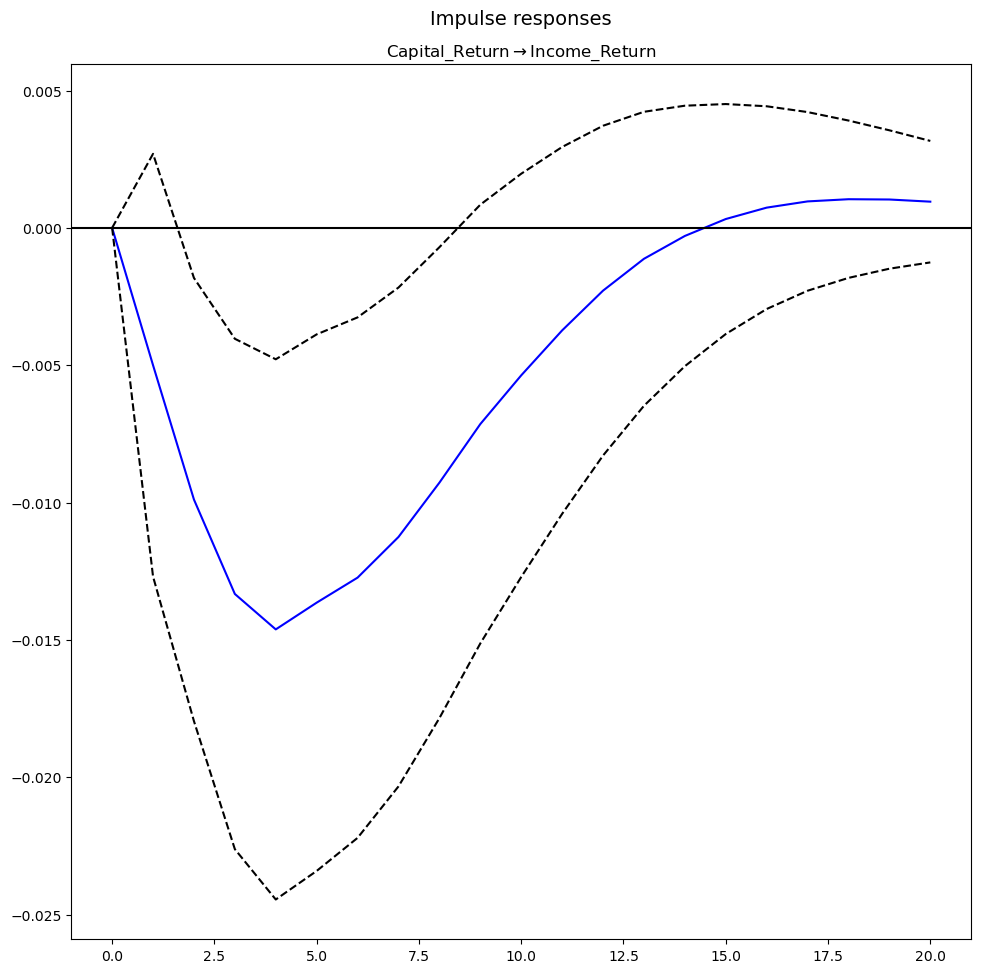

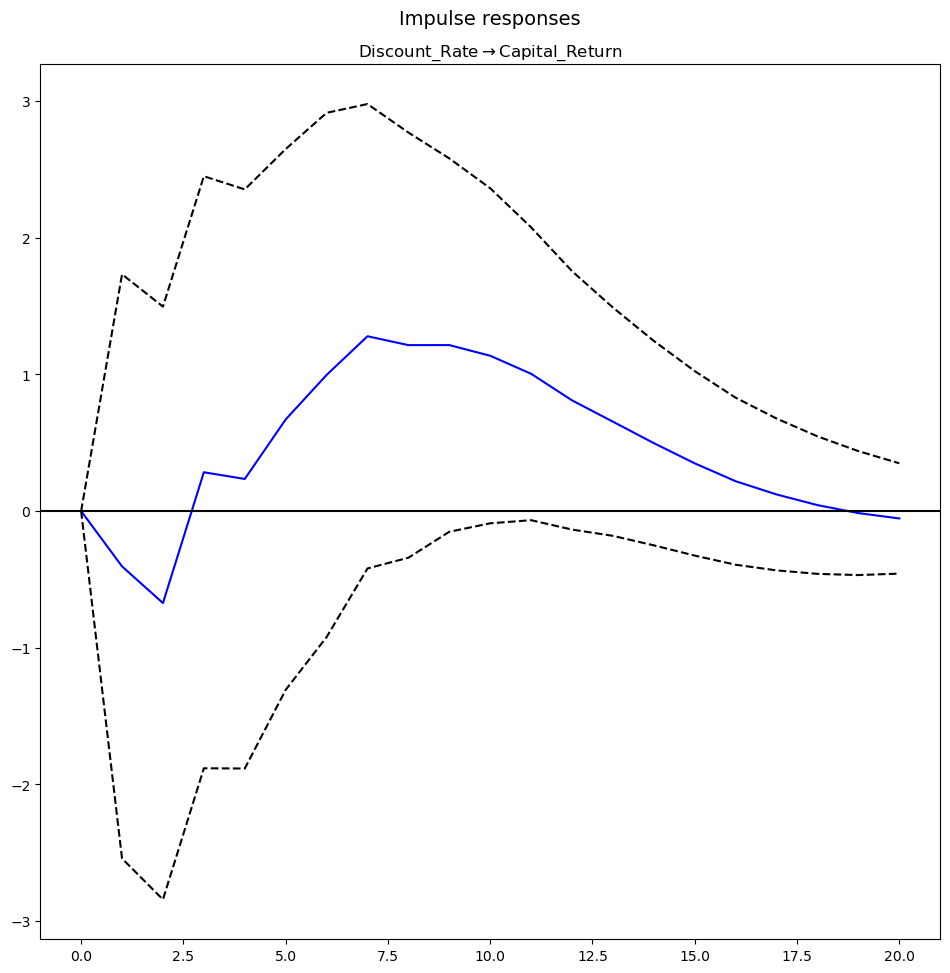

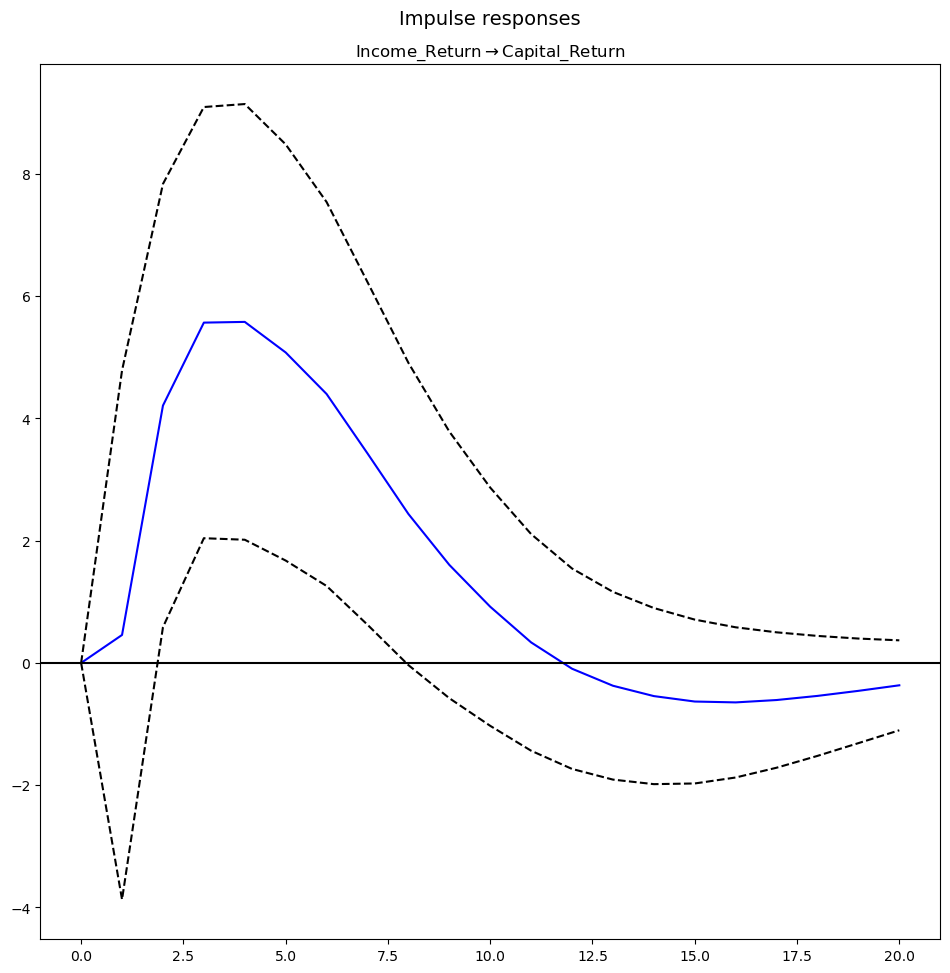

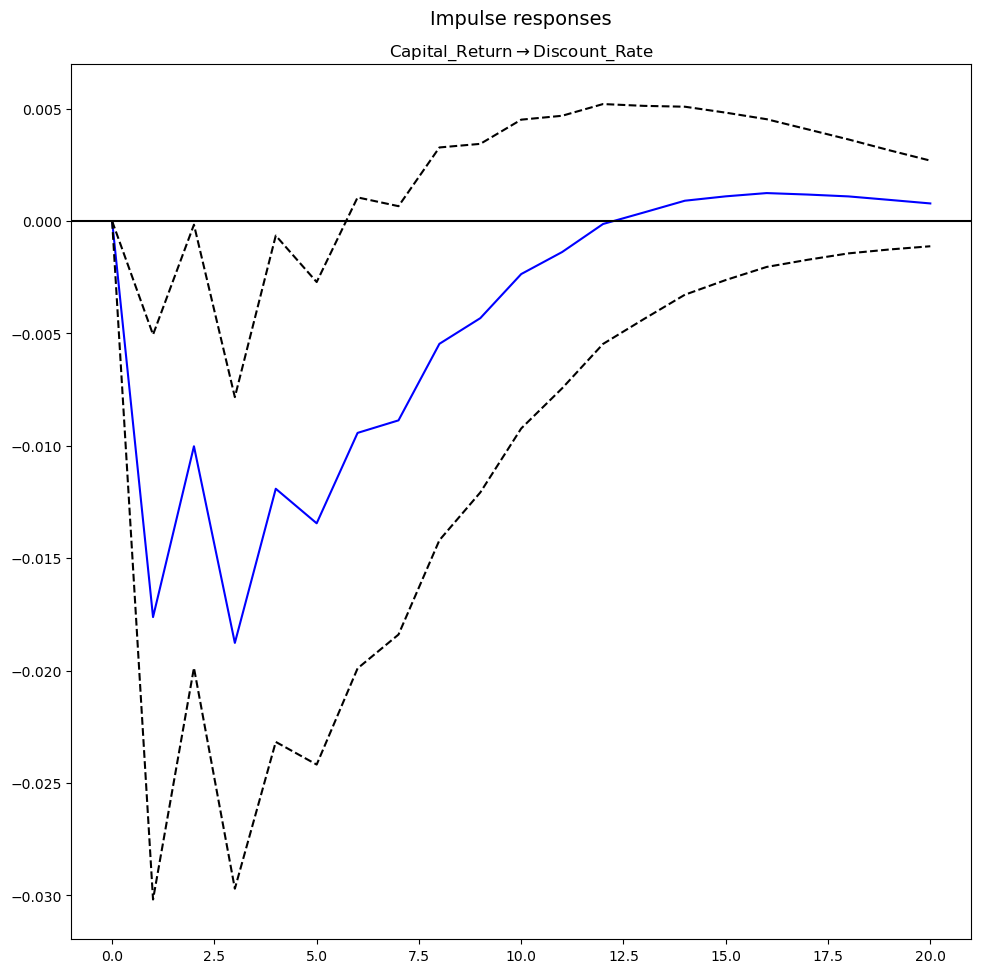

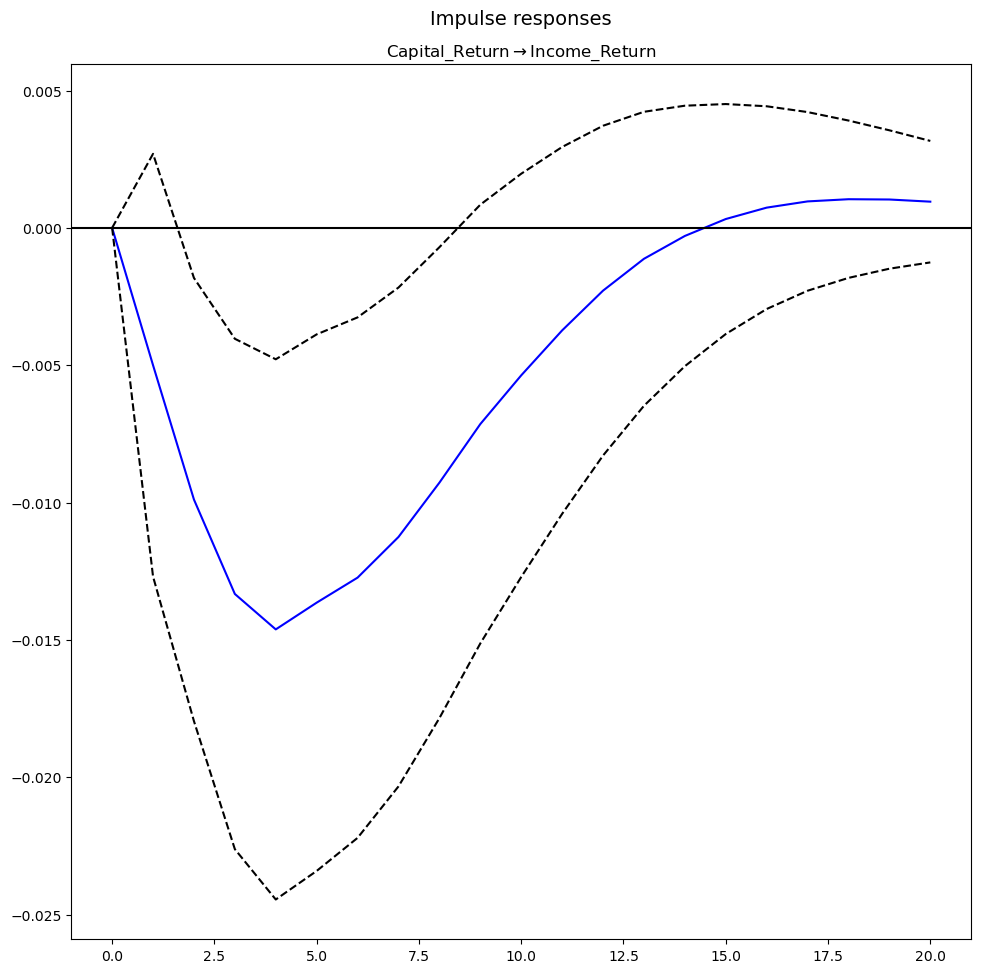

In [101]:
irf = var_model.irf(20)

irf.plot(
    impulse="Discount_Rate",
    response="Capital_Return"
)

irf.plot(
    impulse="Income_Return",
    response="Capital_Return"
)

irf.plot(
    impulse="Capital_Return",
    response="Discount_Rate"
)

irf.plot(
    impulse="Capital_Return",
    response="Income_Return"
)

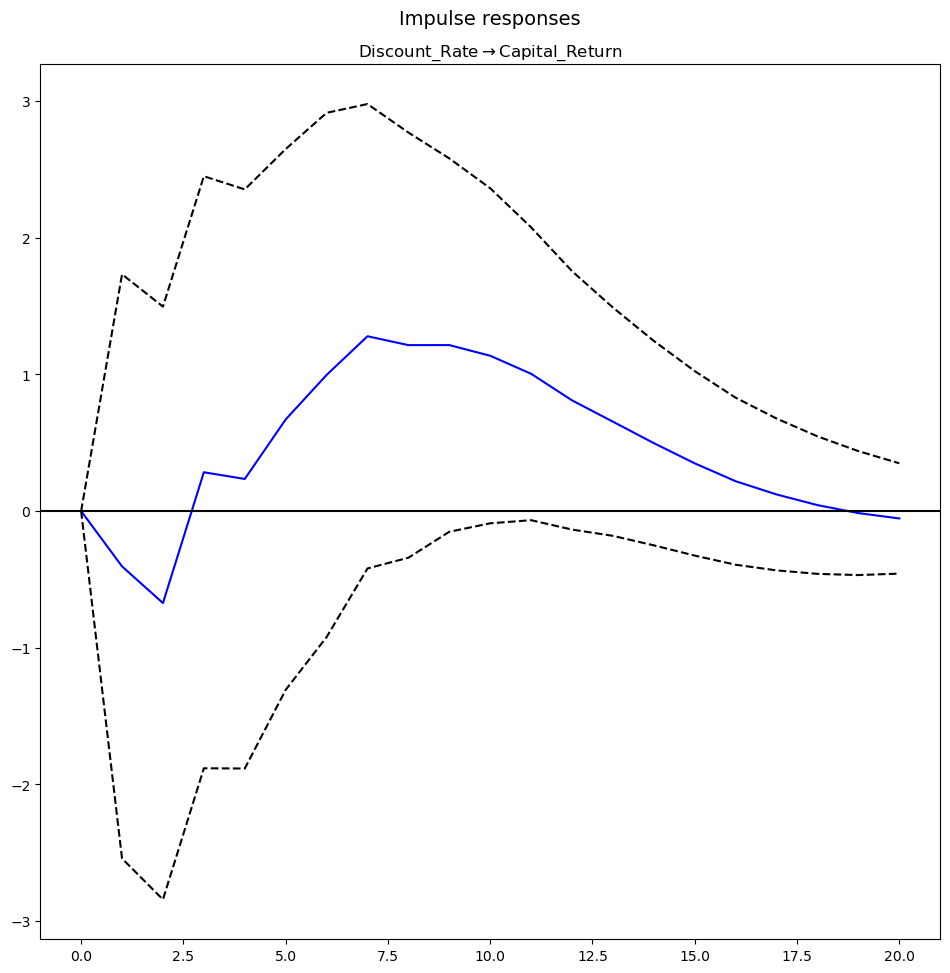

In [102]:
irf = var_model.irf(20)

fig = irf.plot(
    impulse="Discount_Rate",
    response="Capital_Return"
)


In [103]:
variables = [
    "Capital_Return",
    "Income_Return",
    "Cap_Rate",
    "Discount_Rate"
]

for caused in variables:

    for causing in variables:

        if caused != causing:

            result = var_model.test_causality(
                caused,
                [causing]
            )

            print(
                f"{causing} -> {caused}"
            )

            print(result.summary())
            print("-"*50)

Income_Return -> Capital_Return
Granger causality F-test. H_0: Income_Return does not Granger-cause Capital_Return. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value         df        
--------------------------------------------------------
         4.377          3.015   0.013 (2, np.int64(464))
--------------------------------------------------------
--------------------------------------------------
Cap_Rate -> Capital_Return
Granger causality F-test. H_0: Cap_Rate does not Granger-cause Capital_Return. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value         df        
--------------------------------------------------------
        0.4192          3.015   0.658 (2, np.int64(464))
--------------------------------------------------------
--------------------------------------------------
Discount_Rate -> Capital_Return
Granger causality F-test. H_0: Discount_Rate does not Granger-cause Capital_Return

In [104]:
horizons = [1, 4, 8, 12, 20, 40]  # quarters

results = []

for h in horizons:

    future_return = (
        vc_df["CR_Prime"]
        .rolling(h)
        .sum()
        .shift(-h)
    )

    temp = pd.DataFrame({
        "future": future_return,
        "income": vc_df["IR_Prime"],
        "disc": disc_df["Office"]
    }).dropna()

    import statsmodels.api as sm

    X = sm.add_constant(
        temp[["income", "disc"]]
    )

    model = sm.OLS(
        temp["future"],
        X
    ).fit()

    results.append({
        "Horizon_Qtrs": h,
        "R2": model.rsquared
    })

pd.DataFrame(results)

,Horizon_Qtrs,R2
0,1,0.151628
1,4,0.195862
2,8,0.262281
3,12,0.320922
4,20,0.352817
5,40,0.211936


In [105]:
cap_test = pd.DataFrame({
    "Date": cap_df["Date"],
    "Office_CapRate": cap_df["Office"]
})

cap_test["Multiple"] = (
    100 / cap_test["Office_CapRate"]
)

cap_test["Delta_Multiple"] = (
    cap_test["Multiple"].pct_change()
)

cap_test["Delta_CapRate"] = (
    cap_test["Office_CapRate"].diff()
)

print(cap_test.head())

         Date  Office_CapRate  Multiple  Delta_Multiple  Delta_CapRate
19 1985-12-01             NaN       NaN             NaN            NaN
20 1986-03-01             NaN       NaN             NaN            NaN
21 1986-06-01             NaN       NaN             NaN            NaN
22 1986-09-01             NaN       NaN             NaN            NaN
23 1986-12-01             NaN       NaN             NaN            NaN


In [106]:
import statsmodels.api as sm

temp = pd.DataFrame({
    "Capital_Return": vc_df["CR_Prime"],
    "Delta_Multiple": cap_test["Delta_Multiple"]
})

temp = temp.dropna()

X = sm.add_constant(
    temp["Delta_Multiple"]
)

model = sm.OLS(
    temp["Capital_Return"],
    X
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         Capital_Return   R-squared:                       0.194
Model:                            OLS   Adj. R-squared:                  0.188
Method:                 Least Squares   F-statistic:                     30.16
Date:                Fri, 21 Aug 2026   Prob (F-statistic):           2.13e-07
Time:                        18:17:09   Log-Likelihood:                -382.90
No. Observations:                 127   AIC:                             769.8
Df Residuals:                     125   BIC:                             775.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              1.7337      0.444      3.

In [107]:
temp = pd.DataFrame({
    "Capital_Return": vc_df["CR_Prime"],
    "Delta_Income": vc_df["IR_Prime"].diff(),
    "Delta_Multiple": cap_test["Delta_Multiple"]
}).dropna()

import statsmodels.api as sm

X = sm.add_constant(
    temp[
        [
            "Delta_Income",
            "Delta_Multiple"
        ]
    ]
)

model = sm.OLS(
    temp["Capital_Return"],
    X
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         Capital_Return   R-squared:                       0.486
Model:                            OLS   Adj. R-squared:                  0.478
Method:                 Least Squares   F-statistic:                     58.73
Date:                Fri, 21 Aug 2026   Prob (F-statistic):           1.14e-18
Time:                        18:17:39   Log-Likelihood:                -354.30
No. Observations:                 127   AIC:                             714.6
Df Residuals:                     124   BIC:                             723.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              1.3608      0.359      3.

In [108]:
irf = var_model.irf(40)

response = irf.irfs[:, 
                    var_names.index("Discount_Rate"),
                    var_names.index("Capital_Return")]

NameError: name 'var_names' is not defined

In [109]:
print(var_model.names)

['Capital_Return', 'Income_Return', 'Cap_Rate', 'Discount_Rate']


In [110]:
names = var_model.names

response = irf.irfs[
    :,
    names.index("Discount_Rate"),
    names.index("Capital_Return")
]

In [111]:
import numpy as np

irf = var_model.irf(40)

names = var_model.names

response = irf.irfs[
    :,
    names.index("Discount_Rate"),
    names.index("Capital_Return")
]

peak = np.max(np.abs(response))

half_level = peak / 2

half_life_qtrs = None

for i, x in enumerate(np.abs(response)):
    if x <= half_level:
        half_life_qtrs = i
        break

print("Half-life (quarters):", half_life_qtrs)
print("Half-life (years):", half_life_qtrs / 4)

Half-life (quarters): 0
Half-life (years): 0.0


In [112]:
import numpy as np

response = irf.irfs[
    :,
    names.index("Discount_Rate"),
    names.index("Capital_Return")
]

abs_resp = np.abs(response)

peak_idx = np.argmax(abs_resp)
peak_val = abs_resp[peak_idx]

half_level = peak_val / 2

duration_qtrs = None

for i in range(peak_idx + 1, len(abs_resp)):
    if abs_resp[i] <= half_level:
        duration_qtrs = i - peak_idx
        break

print("Peak quarter:", peak_idx)
print("Duration to half decay (quarters):", duration_qtrs)
print("Duration to half decay (years):", duration_qtrs / 4)

Peak quarter: 3
Duration to half decay (quarters): 4
Duration to half decay (years): 1.0


In [113]:
horizons = range(1,41)

results = []

for h in horizons:

    future_return = (
        vc_df["CR_Prime"]
        .rolling(h)
        .sum()
        .shift(-h)
    )

    temp = pd.DataFrame({
        "future": future_return,
        "income": vc_df["IR_Prime"],
        "discount": disc_df["Office"]
    }).dropna()

    X = sm.add_constant(
        temp[["income","discount"]]
    )

    model = sm.OLS(
        temp["future"],
        X
    ).fit()

    results.append({
        "Horizon_Qtrs": h,
        "R2": model.rsquared
    })

horizon_df = pd.DataFrame(results)


In [114]:
plt.plot(
    horizon_df["Horizon_Qtrs"]/4,
    horizon_df["R2"]
)
``

SyntaxError: invalid syntax (1619429157.py, line 5)

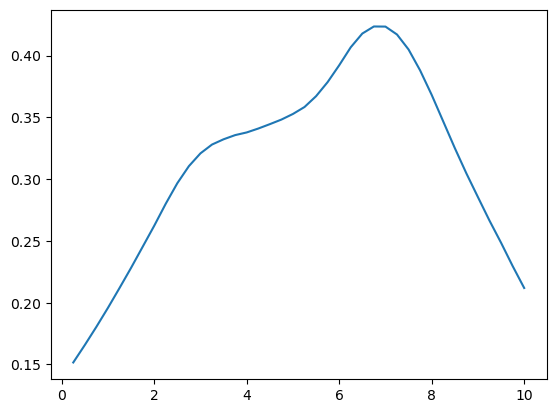

In [115]:
plt.plot(
    horizon_df["Horizon_Qtrs"]/4,
    horizon_df["R2"]
)

In [116]:
import numpy as np

cap_results["Half_Life_Qtrs"] = (
    np.log(0.5) / np.log(cap_results["AR1"])
)

cap_results["Half_Life_Yrs"] = (
    cap_results["Half_Life_Qtrs"] / 4
)

cap_results = cap_results.sort_values(
    "Half_Life_Yrs",
    ascending=False
)

print(
    cap_results[
        ["Segment","AR1","Half_Life_Yrs"]
    ]
)

                                 Segment       AR1  Half_Life_Yrs
4                                  Other  0.998352     105.037941
10                Retail - Neighbourhood  0.991843      21.157631
15  Industrial - High Tech Business Park  0.991346      19.936897
13                Industrial - Warehouse  0.989913      17.091810
14             Industrial - Distribution  0.988992      15.655648
3                             Industrial  0.987537      13.817007
6                       Office - Non-CBD  0.984017      10.754975
9                  Retail - Sub Regional  0.979762       8.475355
5                           Office - CBD  0.978063       7.812401
0                       All Property      0.976969       7.437195
2                                 Office  0.973846       6.538656
12                        Retail - Other  0.972213       6.149219
11                   Large Format Retail  0.971503       5.993866
1                                 Retail  0.971330       5.957172
7      Ret

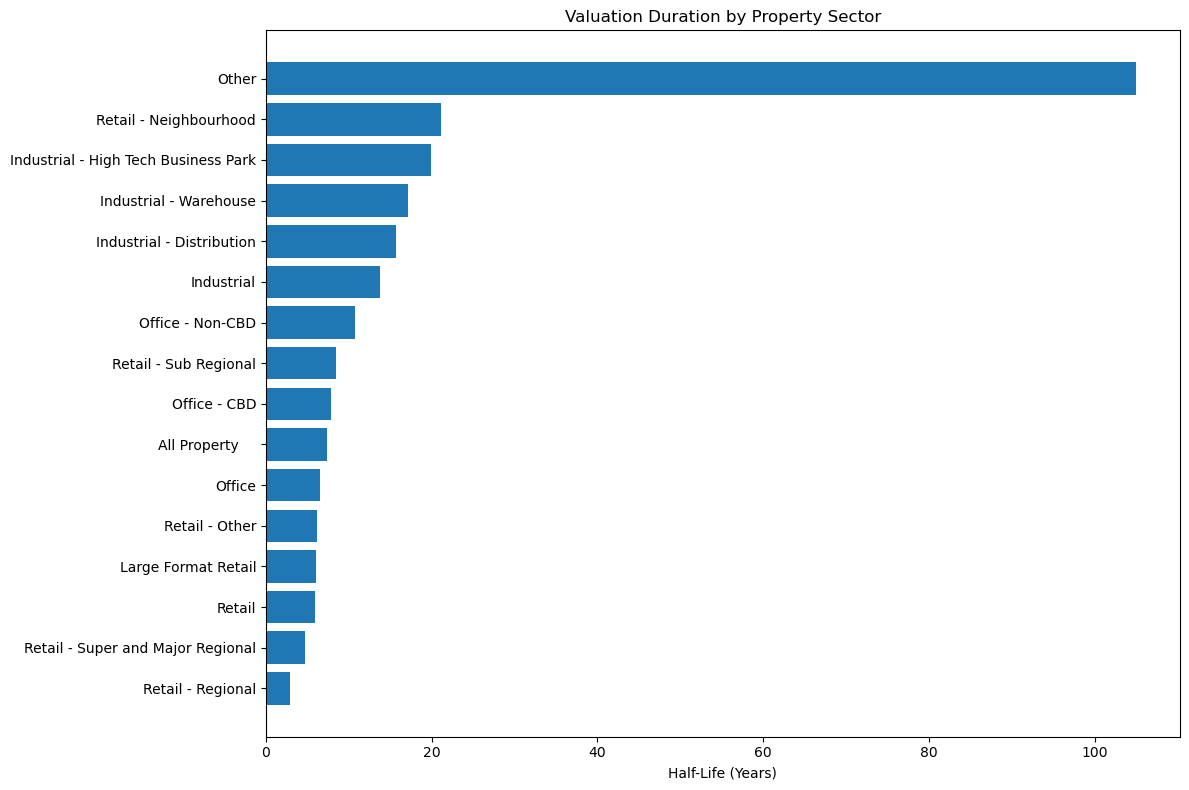

In [117]:
import matplotlib.pyplot as plt

plot_df = cap_results.sort_values(
    "Half_Life_Yrs"
)

plt.figure(figsize=(12,8))

plt.barh(
    plot_df["Segment"],
    plot_df["Half_Life_Yrs"]
)

plt.xlabel("Half-Life (Years)")
plt.title(
    "Valuation Duration by Property Sector"
)

plt.tight_layout()
plt.show()


In [118]:
def estimate_ar1_stats(series):

    series = pd.to_numeric(
        series,
        errors="coerce"
    ).dropna()

    y = series.iloc[1:]
    x = series.shift(1).iloc[1:]

    model = sm.OLS(
        y,
        sm.add_constant(x)
    ).fit(
        cov_type="HAC",
        cov_kwds={"maxlags":4}
    )

    return {
        "beta": model.params.iloc[1],
        "se": model.bse.iloc[1]
    }

In [119]:
sector_stats = []

for col in cap_df.columns[1:]:

    s = cap_df[col].dropna()

    if len(s) > 30:

        out = estimate_ar1_stats(s)

        sector_stats.append({
            "Segment": col,
            "AR1": out["beta"],
            "SE": out["se"]
        })

sector_stats = pd.DataFrame(sector_stats)

sector_stats["Lower"] = (
    sector_stats["AR1"]
    - 1.96 * sector_stats["SE"]
)

sector_stats["Upper"] = (
    sector_stats["AR1"]
    + 1.96 * sector_stats["SE"]
)

print(sector_stats)

                                 Segment       AR1        SE     Lower  \
0                       All Property      0.976969  0.014326  0.948890   
1                                 Retail  0.971330  0.010968  0.949832   
2                                 Office  0.973846  0.017717  0.939121   
3                             Industrial  0.987537  0.010266  0.967415   
4                                  Other  0.998352  0.016110  0.966776   
5                           Office - CBD  0.978063  0.019050  0.940726   
6                       Office - Non-CBD  0.984017  0.019686  0.945432   
7      Retail - Super and Major Regional  0.964001  0.025149  0.914709   
8                      Retail - Regional  0.941813  0.035587  0.872063   
9                  Retail - Sub Regional  0.979762  0.022062  0.936520   
10                Retail - Neighbourhood  0.991843  0.018272  0.956030   
11                   Large Format Retail  0.971503  0.047430  0.878540   
12                        Retail - Oth

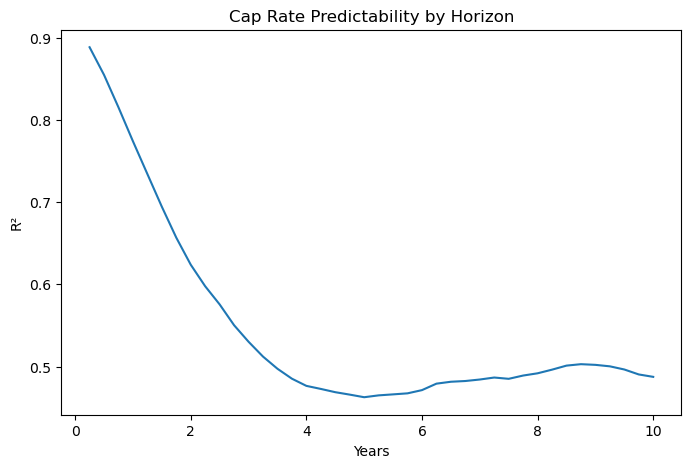

In [120]:
horizons = range(1, 41)

cap_results_h = []

for h in horizons:

    future_cap = (
        cap_df["Office"]
        .shift(-h)
    )

    temp = pd.DataFrame({
        "future": future_cap,
        "income": vc_df["IR_Prime"],
        "discount": disc_df["Office"]
    }).dropna()

    X = sm.add_constant(
        temp[["income", "discount"]]
    )

    model = sm.OLS(
        temp["future"],
        X
    ).fit()

    cap_results_h.append({
        "Horizon_Qtrs": h,
        "R2": model.rsquared
    })

cap_horizon = pd.DataFrame(cap_results_h)

plt.figure(figsize=(8,5))
plt.plot(
    cap_horizon["Horizon_Qtrs"]/4,
    cap_horizon["R2"]
)
plt.title("Cap Rate Predictability by Horizon")
plt.xlabel("Years")
plt.ylabel("R²")
plt.show()

In [121]:
import pandas as pd
import statsmodels.api as sm

# 5 years = 20 quarters
future_5y = (
    vc_df["CR_Prime"]
    .rolling(20)
    .sum()
    .shift(-20)
)

base = pd.DataFrame({
    "Future_Return": future_5y,
    "Income_Return": vc_df["IR_Prime"],
    "Cap_Rate": cap_df["Office"],
    "Discount_Rate": disc_df["Office"]
}).dropna()

results = []

predictors = {
    "Income": ["Income_Return"],
    "Cap Rate": ["Cap_Rate"],
    "Discount Rate": ["Discount_Rate"],
    "Income + Cap Rate + Discount Rate":
        ["Income_Return","Cap_Rate","Discount_Rate"]
}

for name, vars_ in predictors.items():

    X = sm.add_constant(
        base[vars_]
    )

    model = sm.OLS(
        base["Future_Return"],
        X
    ).fit()

    results.append({
        "Model": name,
        "R2": model.rsquared,
        "Adj_R2": model.rsquared_adj,
        "F_stat": model.fvalue,
        "p_value": model.f_pvalue
    })

forecast_results = pd.DataFrame(results)

print(
    forecast_results.sort_values(
        "R2",
        ascending=False
    )
)

                               Model        R2    Adj_R2     F_stat  \
3  Income + Cap Rate + Discount Rate  0.379150  0.361241  21.170782   
0                             Income  0.333381  0.327092  53.011447   
1                           Cap Rate  0.172386  0.164579  22.079092   
2                      Discount Rate  0.024650  0.015449   2.678966   

        p_value  
3  8.807140e-11  
0  6.089663e-11  
1  7.894485e-06  
2  1.046474e-01  


                                 Segment       AR1  Half_Life_Yrs  \
0                                  Other  0.998352     105.037941   
1                 Retail - Neighbourhood  0.991843      21.157631   
2   Industrial - High Tech Business Park  0.991346      19.936897   
3                 Industrial - Warehouse  0.989913      17.091810   
4              Industrial - Distribution  0.988992      15.655648   
5                       Office - Non-CBD  0.984017      10.754975   
6                  Retail - Sub Regional  0.979762       8.475355   
7                           Office - CBD  0.978063       7.812401   
8                         Retail - Other  0.972213       6.149219   
9                    Large Format Retail  0.971503       5.993866   
10     Retail - Super and Major Regional  0.964001       4.726469   
11                     Retail - Regional  0.941813       2.890569   

    Income_Share  Income_to_Capital  Income_Return  Capital_Return  
0       0.710099           2.6268

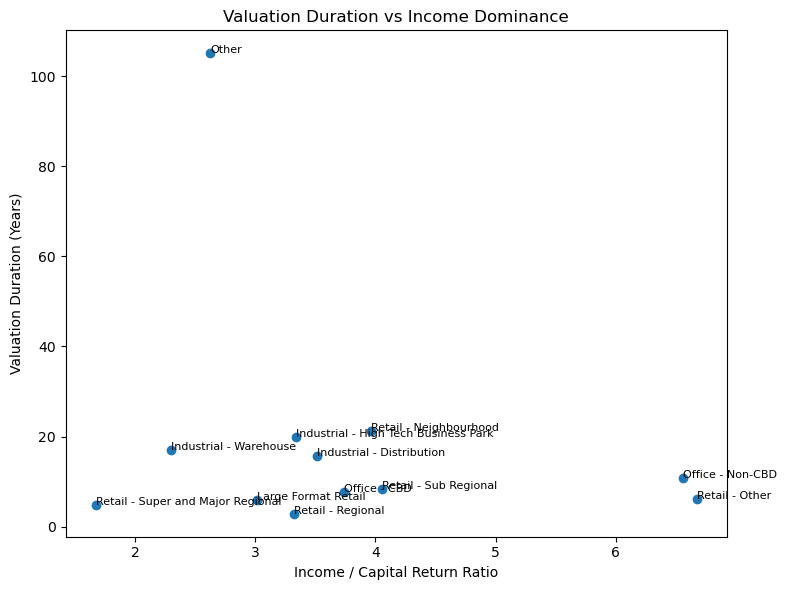

In [122]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

#################################################
# BUILD DURATION DATASET
#################################################

duration_df = cap_results.copy()

duration_df["Segment"] = (
    duration_df["Segment"]
    .astype(str)
    .str.strip()
)

wealth_tmp = wealth_sources.copy()

wealth_tmp["Segment"] = (
    wealth_tmp["Segment"]
    .astype(str)
    .str.strip()
)

#################################################
# HALF LIFE
#################################################

duration_df["Half_Life_Qtrs"] = (
    np.log(0.5) / np.log(duration_df["AR1"])
)

duration_df["Half_Life_Yrs"] = (
    duration_df["Half_Life_Qtrs"] / 4
)

#################################################
# MERGE
#################################################

analysis_df = pd.merge(
    duration_df[
        ["Segment","AR1","Half_Life_Yrs"]
    ],
    wealth_tmp[
        [
            "Segment",
            "Income_Share",
            "Income_to_Capital",
            "Income_Return",
            "Capital_Return"
        ]
    ],
    on="Segment",
    how="inner"
)

print(
    analysis_df.sort_values(
        "Half_Life_Yrs",
        ascending=False
    )
)

#################################################
# CORRELATIONS
#################################################

print("\nCorrelation Matrix\n")

print(
    analysis_df[
        [
            "Half_Life_Yrs",
            "Income_Share",
            "Income_to_Capital",
            "Income_Return",
            "Capital_Return"
        ]
    ].corr()
)

#################################################
# REGRESSION 1
#
# Valuation Duration ~ Income Share
#################################################

X = sm.add_constant(
    analysis_df["Income_Share"]
)

model1 = sm.OLS(
    analysis_df["Half_Life_Yrs"],
    X
).fit()

print("\nDuration ~ Income Share")
print(model1.summary())

#################################################
# REGRESSION 2
#
# Valuation Duration ~ Income/Capital
#################################################

X = sm.add_constant(
    analysis_df["Income_to_Capital"]
)

model2 = sm.OLS(
    analysis_df["Half_Life_Yrs"],
    X
).fit()

print("\nDuration ~ Income_to_Capital")
print(model2.summary())

#################################################
# SCATTER PLOT
#################################################

plt.figure(figsize=(8,6))

plt.scatter(
    analysis_df["Income_to_Capital"],
    analysis_df["Half_Life_Yrs"]
)

for _, row in analysis_df.iterrows():

    plt.annotate(
        row["Segment"],
        (
            row["Income_to_Capital"],
            row["Half_Life_Yrs"]
        ),
        fontsize=8
    )

plt.xlabel("Income / Capital Return Ratio")

plt.ylabel("Valuation Duration (Years)")

plt.title(
    "Valuation Duration vs Income Dominance"
)

plt.tight_layout()

plt.show()

In [123]:
sector_characteristics = pd.DataFrame({
    "Segment": analysis_df["Segment"],
    "Duration": analysis_df["Half_Life_Yrs"],
    "Income_Share": analysis_df["Income_Share"],
    "Income_Return": analysis_df["Income_Return"],
    "Cap_Rate": [
        cap_df["Office - CBD"].mean(),
        cap_df["Office - Non-CBD"].mean(),
        ...
    ]
})

ValueError: array length 3 does not match index length 12

In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#################################################
# BUILD SECTOR FAMILIES
#################################################

temp = analysis_df.copy()

temp["Family"] = "Other"

temp.loc[
    temp["Segment"].str.contains("Office", na=False),
    "Family"
] = "Office"

temp.loc[
    temp["Segment"].str.contains("Industrial", na=False),
    "Family"
] = "Industrial"

temp.loc[
    temp["Segment"].str.contains("Retail", na=False),
    "Family"
] = "Retail"

#################################################
# SUMMARY TABLE
#################################################

family_summary = (
    temp.groupby("Family")["Half_Life_Yrs"]
    .agg([
        "count",
        "mean",
        "median",
        "min",
        "max",
        "std"
    ])
    .round(2)
)

print("\nValuation Duration by Sector Family\n")
print(family_summary)

#################################################
# SEGMENT RANKING
#################################################

print("\nSegment Ranking\n")

print(
    temp[
        [
            "Segment",
            "Half_Life_Yrs",
            "Income_Share",
            "Income_to_Capital"
        ]
    ]
    .sort_values(
        "Half_Life_Yrs",
        ascending=False
    )
)

#################################################
# BOXPLOT
#################################################

plt.figure(figsize=(10,6))

temp.boxplot(
    column="Half_Life_Yrs",
    by="Family",
    grid=False
)

plt.suptitle("")
plt.title("Valuation Duration by Sector Family")
plt.ylabel("Half-Life (Years)")

plt.show()

#################################################
# SCATTER OF DURATION RANKING
#################################################

plot_df = temp.sort_values(
    "Half_Life_Yrs"
)

plt.figure(figsize=(12,7))

plt.barh(
    plot_df["Segment"],
    plot_df["Half_Life_Yrs"]
)

plt.xlabel("Valuation Duration (Years)")
plt.title("Sector Valuation Duration Ranking")

plt.tight_layout()

plt.show()

#################################################
# RETAIL SUB-TYPES ONLY
#################################################

retail = temp[
    temp["Family"] == "Retail"
].copy()

print("\

_IncompleteInputError: incomplete input (4243816272.py, line 117)


Valuation Duration by Sector Family

            count    mean  median     min     max   std
Family                                                 
Industrial      3   17.56   17.09   15.66   19.94  2.18
Office          2    9.28    9.28    7.81   10.75  2.08
Other           1  105.04  105.04  105.04  105.04   NaN
Retail          6    8.23    6.07    2.89   21.16  6.59

Segment Ranking

                                 Segment  Half_Life_Yrs  Income_Share  \
0                                  Other     105.037941      0.710099   
1                 Retail - Neighbourhood      21.157631      0.786161   
2   Industrial - High Tech Business Park      19.936897      0.759004   
3                 Industrial - Warehouse      17.091810      0.683841   
4              Industrial - Distribution      15.655648      0.769095   
5                       Office - Non-CBD      10.754975      0.862132   
6                  Retail - Sub Regional       8.475355      0.790058   
7                       

<Figure size 1000x600 with 0 Axes>

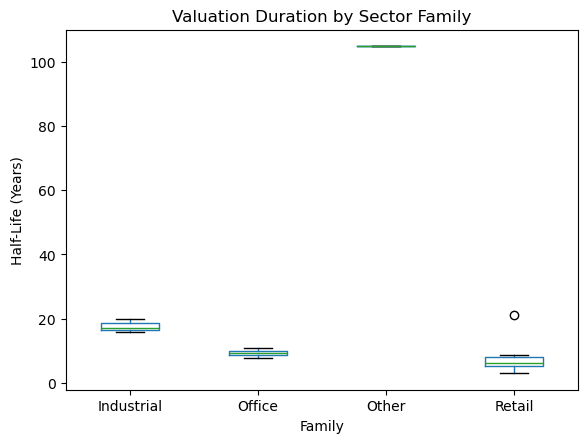

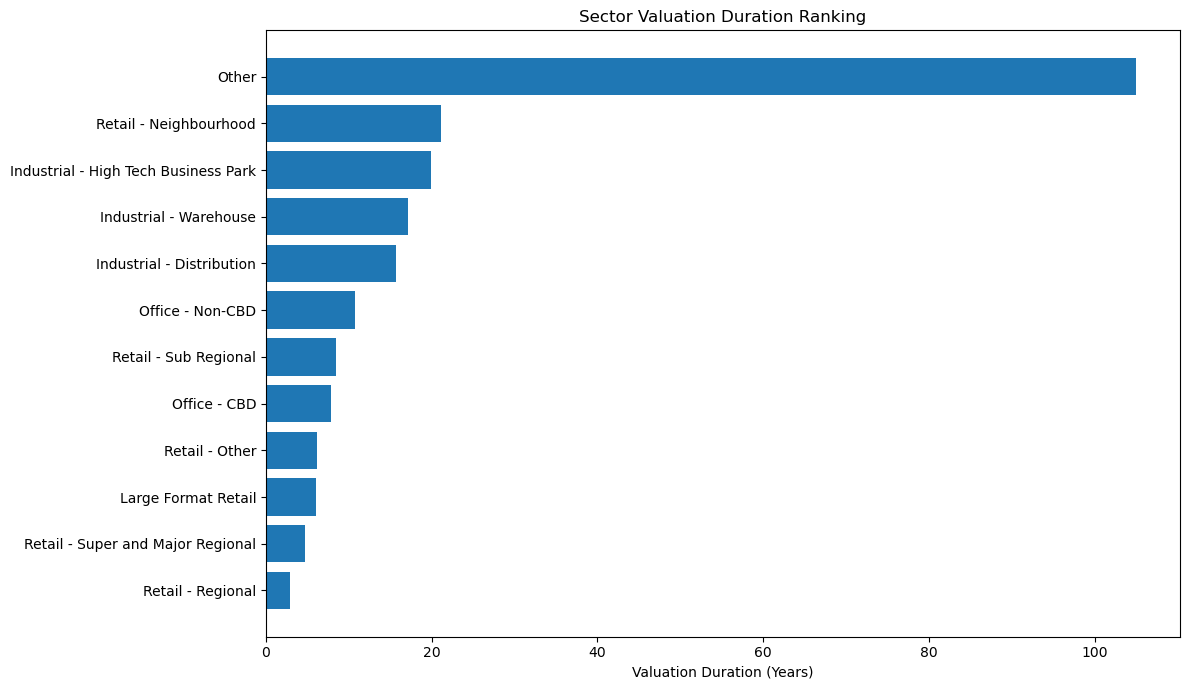


Retail Segments

                              Segment  Half_Life_Yrs
1              Retail - Neighbourhood      21.157631
6               Retail - Sub Regional       8.475355
8                      Retail - Other       6.149219
9                 Large Format Retail       5.993866
10  Retail - Super and Major Regional       4.726469
11                  Retail - Regional       2.890569


In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#################################################
# BUILD SECTOR FAMILIES
#################################################

temp = analysis_df.copy()

temp["Family"] = "Other"

temp.loc[
    temp["Segment"].str.contains("Office", na=False),
    "Family"
] = "Office"

temp.loc[
    temp["Segment"].str.contains("Industrial", na=False),
    "Family"
] = "Industrial"

temp.loc[
    temp["Segment"].str.contains("Retail", na=False),
    "Family"
] = "Retail"

#################################################
# SUMMARY TABLE
#################################################

family_summary = (
    temp.groupby("Family")["Half_Life_Yrs"]
    .agg([
        "count",
        "mean",
        "median",
        "min",
        "max",
        "std"
    ])
    .round(2)
)

print("\nValuation Duration by Sector Family\n")
print(family_summary)

#################################################
# SEGMENT RANKING
#################################################

print("\nSegment Ranking\n")

print(
    temp[
        [
            "Segment",
            "Half_Life_Yrs",
            "Income_Share",
            "Income_to_Capital"
        ]
    ]
    .sort_values(
        "Half_Life_Yrs",
        ascending=False
    )
)

#################################################
# BOXPLOT
#################################################

plt.figure(figsize=(10,6))

temp.boxplot(
    column="Half_Life_Yrs",
    by="Family",
    grid=False
)

plt.suptitle("")
plt.title("Valuation Duration by Sector Family")
plt.ylabel("Half-Life (Years)")

plt.show()

#################################################
# SCATTER OF DURATION RANKING
#################################################

plot_df = temp.sort_values(
    "Half_Life_Yrs"
)

plt.figure(figsize=(12,7))

plt.barh(
    plot_df["Segment"],
    plot_df["Half_Life_Yrs"]
)

plt.xlabel("Valuation Duration (Years)")
plt.title("Sector Valuation Duration Ranking")

plt.tight_layout()

plt.show()

#################################################
# RETAIL SUB-TYPES ONLY
#################################################

retail = temp[
    temp["Family"] == "Retail"
].copy()

print("\nRetail Segments\n")

print(
    retail[
        ["Segment","Half_Life_Yrs"]
    ]
    .sort_values(
        "Half_Life_Yrs",
        ascending=False
    )
)

In [126]:
sector_test = analysis_df.copy()

sector_test = sector_test[
    [
        "Segment",
        "Half_Life_Yrs",
        "Income_Return",
        "Capital_Return",
        "Income_Share",
        "Income_to_Capital"
    ]
].copy()

print(
    sector_test.sort_values(
        "Half_Life_Yrs",
        ascending=False
    )
)

                                 Segment  Half_Life_Yrs  Income_Return  \
0                                  Other     105.037941       7.347382   
1                 Retail - Neighbourhood      21.157631       8.265745   
2   Industrial - High Tech Business Park      19.936897       7.314020   
3                 Industrial - Warehouse      17.091810       7.983918   
4              Industrial - Distribution      15.655648       7.858740   
5                       Office - Non-CBD      10.754975       7.398263   
6                  Retail - Sub Regional       8.475355       8.174448   
7                           Office - CBD       7.812401       6.414468   
8                         Retail - Other       6.149219       7.090213   
9                    Large Format Retail       5.993866       8.107675   
10     Retail - Super and Major Regional       4.726469       6.507248   
11                     Retail - Regional       2.890569       7.510963   

    Capital_Return  Income_Share  Inc

In [127]:
vol_results = []

for seg in names:

    cr = pd.to_numeric(
        sector_df[
            f"{seg}_Capital"
        ],
        errors="coerce"
    )

    vol_results.append({
        "Segment": seg,
        "Capital_Return_Vol": cr.std()
    })

vol_df = pd.DataFrame(vol_results)

duration_vol = pd.merge(
    analysis_df[
        ["Segment", "Half_Life_Yrs"]
    ],
    vol_df,
    on="Segment",
    how="inner"
)

print(
    duration_vol.sort_values(
        "Half_Life_Yrs",
        ascending=False
    )
)

print(
    duration_vol[
        ["Half_Life_Yrs", "Capital_Return_Vol"]
    ].corr()
)

KeyError: 'Capital_Return_Capital'

In [128]:
print(names)

['Capital_Return', 'Income_Return', 'Cap_Rate', 'Discount_Rate']


In [129]:
['Office - CBD',
 'Office - Non-CBD',
 'Retail - Regional',
 ...]

['Office - CBD', 'Office - Non-CBD', 'Retail - Regional', Ellipsis]

In [130]:
scarcity = {
    "Retail - Regional": 1,
    "Retail - Super and Major Regional": 2,
    "Large Format Retail": 2,

    "Office - CBD": 3,
    "Office - Non-CBD": 3,

    "Industrial - Distribution": 4,
    "Industrial - Warehouse": 5,
    "Industrial - High Tech Business Park": 5,

    "Retail - Neighbourhood": 5
}

In [131]:
test = analysis_df.copy()

test["Scarcity"] = (
    test["Segment"]
    .map(scarcity)
)

print(
    test[
        ["Segment","Half_Life_Yrs","Scarcity"]
    ]
)

                                 Segment  Half_Life_Yrs  Scarcity
0                                  Other     105.037941       NaN
1                 Retail - Neighbourhood      21.157631       5.0
2   Industrial - High Tech Business Park      19.936897       5.0
3                 Industrial - Warehouse      17.091810       5.0
4              Industrial - Distribution      15.655648       4.0
5                       Office - Non-CBD      10.754975       3.0
6                  Retail - Sub Regional       8.475355       NaN
7                           Office - CBD       7.812401       3.0
8                         Retail - Other       6.149219       NaN
9                    Large Format Retail       5.993866       2.0
10     Retail - Super and Major Regional       4.726469       2.0
11                     Retail - Regional       2.890569       1.0


In [132]:
import statsmodels.api as sm

X = sm.add_constant(
    test["Scarcity"]
)

model = sm.OLS(
    test["Half_Life_Yrs"],
    X
).fit()

print(model.summary())

MissingDataError: exog contains inf or nans

In [133]:
print(
    test[
        test["Scarcity"].isna()
    ][["Segment"]]
)

                 Segment
0                  Other
6  Retail - Sub Regional
8         Retail - Other


In [134]:
print(test[["Segment","Scarcity"]])

test = test.dropna(
    subset["Segment","Scar=f_Life_Yrs"]
)

X = sm.add_constant(
    test["Scarcity"]
)

model = sm.OLS(
    test["Half_Life_Yrs"],
    X
).fit()

print(model.summary())

                                 Segment  Scarcity
0                                  Other       NaN
1                 Retail - Neighbourhood       5.0
2   Industrial - High Tech Business Park       5.0
3                 Industrial - Warehouse       5.0
4              Industrial - Distribution       4.0
5                       Office - Non-CBD       3.0
6                  Retail - Sub Regional       NaN
7                           Office - CBD       3.0
8                         Retail - Other       NaN
9                    Large Format Retail       2.0
10     Retail - Super and Major Regional       2.0
11                     Retail - Regional       1.0


KeyError: ('Segment', 'Scar=f_Life_Yrs')


Valuation Duration vs Scarcity

                                 Segment  Half_Life_Yrs  Scarcity
1                 Retail - Neighbourhood      21.157631       5.0
2   Industrial - High Tech Business Park      19.936897       5.0
3                 Industrial - Warehouse      17.091810       5.0
4              Industrial - Distribution      15.655648       4.0
5                       Office - Non-CBD      10.754975       3.0
6                  Retail - Sub Regional       8.475355       4.0
7                           Office - CBD       7.812401       3.0
8                         Retail - Other       6.149219       4.0
9                    Large Format Retail       5.993866       2.0
10     Retail - Super and Major Regional       4.726469       2.0
11                     Retail - Regional       2.890569       1.0

Correlation:
0.8572690241667955

Regression Results

                            OLS Regression Results                            
Dep. Variable:          Half_Life_Yrs   R-

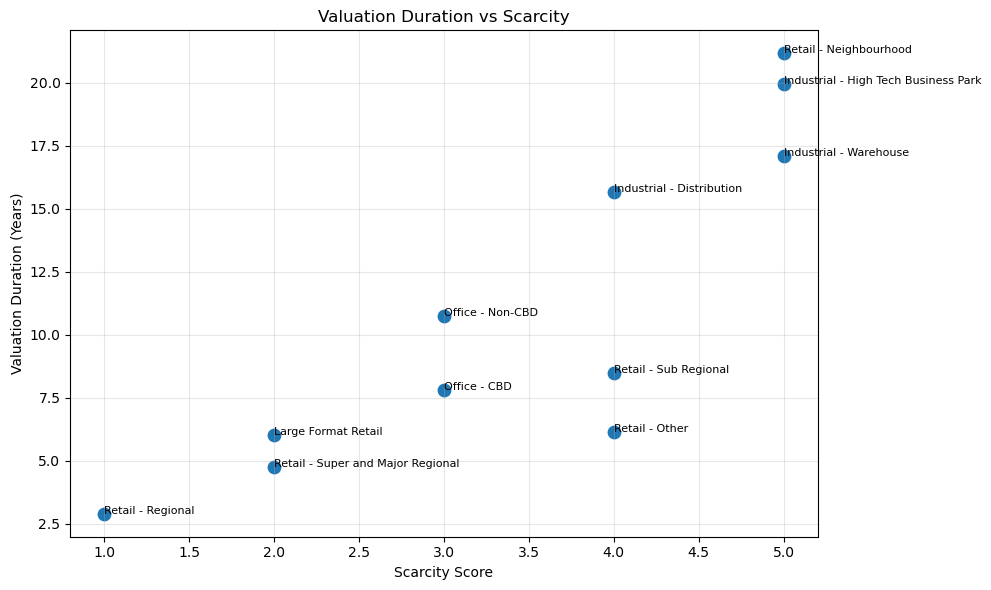

In [135]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

#################################################
# BUILD SCARCITY SCORE
#################################################

scarcity = {
    "Retail - Regional": 1,
    "Retail - Super and Major Regional": 2,
    "Large Format Retail": 2,

    "Office - CBD": 3,
    "Office - Non-CBD": 3,

    "Retail - Sub Regional": 4,
    "Retail - Other": 4,
    "Industrial - Distribution": 4,

    "Industrial - Warehouse": 5,
    "Industrial - High Tech Business Park": 5,
    "Retail - Neighbourhood": 5
}

#################################################
# CREATE TEST DATASET
#################################################

test = analysis_df.copy()

test["Scarcity"] = (
    test["Segment"]
    .map(scarcity)
)

test = test.dropna(
    subset=["Scarcity", "Half_Life_Yrs"]
)

#################################################
# VIEW DATA
#################################################

print("\nValuation Duration vs Scarcity\n")

print(
    test[
        ["Segment", "Half_Life_Yrs", "Scarcity"]
    ].sort_values(
        "Half_Life_Yrs",
        ascending=False
    )
)

#################################################
# CORRELATION
#################################################

corr = test["Half_Life_Yrs"].corr(
    test["Scarcity"]
)

print("\nCorrelation:")
print(corr)

#################################################
# REGRESSION
#################################################

X = sm.add_constant(
    test["Scarcity"]
)

model = sm.OLS(
    test["Half_Life_Yrs"],
    X
).fit()

print("\nRegression Results\n")
print(model.summary())

#################################################
# SCATTER PLOT
#################################################

plt.figure(figsize=(10,6))

plt.scatter(
    test["Scarcity"],
    test["Half_Life_Yrs"],
    s=80
)

for _, row in test.iterrows():

    plt.annotate(
        row["Segment"],
        (
            row["Scarcity"],
            row["Half_Life_Yrs"]
        ),
        fontsize=8
    )

plt.xlabel("Scarcity Score")
plt.ylabel("Valuation Duration (Years)")
plt.title(
    "Valuation Duration vs Scarcity"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [136]:
with open(
    "valuation_duration_scarcity_regression.txt",
    "w"
) as f:

    f.write(model.summary().as_text())

print("saved")

saved


In [137]:
test.to_csv(
    "valuation_duration_scarcity_data.csv",
    index=False
)

print("saved")

saved


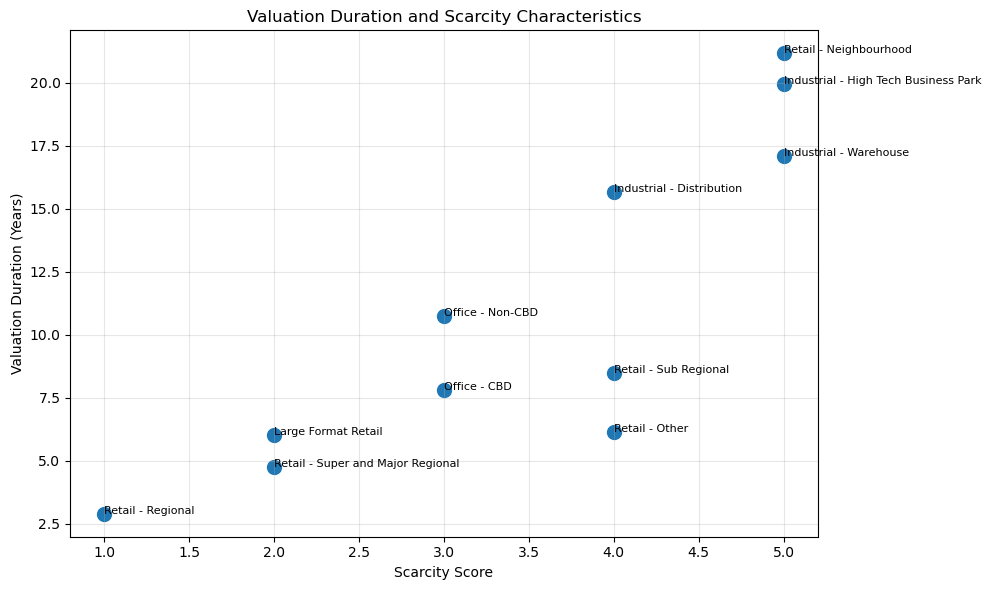

In [138]:
plt.figure(figsize=(10,6))

plt.scatter(
    test["Scarcity"],
    test["Half_Life_Yrs"],
    s=100
)

for _, row in test.iterrows():

    plt.annotate(
        row["Segment"],
        (
            row["Scarcity"],
            row["Half_Life_Yrs"]
        ),
        fontsize=8
    )

plt.xlabel("Scarcity Score")
plt.ylabel("Valuation Duration (Years)")
plt.title(
    "Valuation Duration and Scarcity Characteristics"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "valuation_duration_scarcity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [139]:
summary = test[
    [
        "Segment",
        "Half_Life_Yrs",
        "Scarcity"
    ]
].sort_values(
    "Half_Life_Yrs",
    ascending=False
)

summary.to_csv(
    "valuation_duration_ranking.csv",
    index=False
)

print(summary)

                                 Segment  Half_Life_Yrs  Scarcity
1                 Retail - Neighbourhood      21.157631       5.0
2   Industrial - High Tech Business Park      19.936897       5.0
3                 Industrial - Warehouse      17.091810       5.0
4              Industrial - Distribution      15.655648       4.0
5                       Office - Non-CBD      10.754975       3.0
6                  Retail - Sub Regional       8.475355       4.0
7                           Office - CBD       7.812401       3.0
8                         Retail - Other       6.149219       4.0
9                    Large Format Retail       5.993866       2.0
10     Retail - Super and Major Regional       4.726469       2.0
11                     Retail - Regional       2.890569       1.0


In [140]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# -----------------------------------
# INPUTS
# -----------------------------------

# dataframe should contain:
# Quarter
# Location
# Total_Return
# All_Property_Return

df = location_df.copy()

# -----------------------------------
# EXCESS RETURNS
# -----------------------------------

df["Excess_Return"] = (
    df["Total_Return"]
    - df["All_Property_Return"]
)

# -----------------------------------
# AR(1) ESTIMATION
# -----------------------------------

results = []

for location in df["Location"].unique():

    temp = (
        df[df["Location"] == location]
        .sort_values("Quarter")
        .copy()
    )

    temp["ER_Lag1"] = temp["Excess_Return"].shift(1)
    temp = temp.dropna()

    if len(temp) < 20:
        continue

    X = sm.add_constant(temp["ER_Lag1"])
    y = temp["Excess_Return"]

    model = sm.OLS(y, X).fit()

    beta = model.params["ER_Lag1"]

    # implied half-life
    if 0 < beta < 1:
        half_life_qtrs = np.log(0.5) / np.log(beta)
        half_life_years = half_life_qtrs / 4
    else:
        half_life_years = np.nan

    results.append({
        "Location": location,
        "AR1": beta,
        "R2": model.rsquared,
        "Half_Life_Years": half_life_years,
        "P_Value": model.pvalues["ER_Lag1"]
    })

results = pd.DataFrame(results)

results = results.sort_values(
    "Half_Life_Years",
    ascending=False
)

print(results)

NameError: name 'location_df' is not defined

In [141]:
import pandas as pd

file = "The+Property+Council-MSCI+Australian+All+Property+Digest+Q12026+Old+Format.xlsx"

for sheet in [
    "Office Locations",
    "Retail Locations",
    "Industrial Locations",
    "Quality Type"
]:
    print("\n" + "="*80)
    print(sheet)

    df = pd.read_excel(
        file,
        sheet_name=sheet,
        header=None
    )

    print(df.iloc[:50, :15])


Office Locations
      0   1                              2   \
0    NaN NaN                            NaN   
1    NaN NaN                            NaN   
2    NaN NaN                            NaN   
3    NaN NaN                            NaN   
4    NaN NaN                            NaN   
5    NaN NaN                            NaN   
6    NaN NaN                   Quick Links:   
7    NaN NaN                            NaN   
8    NaN NaN      CBD Office Market Returns   
9    NaN NaN  Non-CBD Office Market Returns   
10   NaN NaN                            NaN   
11   NaN NaN                            NaN   
12   NaN NaN                            NaN   
13   NaN NaN                            NaN   
14   NaN NaN                  Date / Period   
15  16.0 NaN            1984-12-01 00:00:00   
16  17.0 NaN            1985-03-01 00:00:00   
17  18.0 NaN            1985-06-01 00:00:00   
18  19.0 NaN            1985-09-01 00:00:00   
19  20.0 NaN            1985-12-01 00:00:0

In [142]:
import pandas as pd

file = "The+Property+Council-MSCI+Australian+All+Property+Digest+Q12026+Old+Format.xlsx"

df = pd.read_excel(
    file,
    sheet_name="Office Locations",
    header=None
)

for col in range(df.shape[1]):
    val = df.iloc[14, col]

    if pd.notna(val):
        print(col, val)

2 Date / Period
3 Sydney - CBD Office
4 Melbourne - CBD Office
5 Brisbane - CBD Office
6 Perth - CBD Office
7 Adelaide - CBD Office
8 Canberra Region - Office
9 Rest of Australia - Office
11 Sydney - CBD Office
12 Melbourne - CBD Office
13 Brisbane - CBD Office
14 Perth - CBD Office
15 Adelaide - CBD Office
16 Canberra Region - Office
17 Rest of Australia - Office
19 Sydney - CBD Office
20 Melbourne - CBD Office
21 Brisbane - CBD Office
22 Perth - CBD Office
23 Adelaide - CBD Office
24 Canberra Region - Office
25 Rest of Australia - Office
27 Date / Period
28 North Sydney - Office
29 Chatswood / Crows Nest / St Leonards - Office
30 Parramatta - Office
31 North Ryde - Office
32 Melbourne - Non-CBD Office
33 Brisbane Fringe - Office
34 Rest of Australia - Non-CBD Office
36 North Sydney - Office
37 Chatswood / Crows Nest / St Leonards - Office
38 Parramatta - Office
39 North Ryde - Office
40 Melbourne - Non-CBD Office
41 Brisbane Fringe - Office
42 Rest of Australia - Non-CBD Office
44 No

In [143]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

file = "The+Property+Council-MSCI+Australian+All+Property+Digest+Q12026+Old+Format.xlsx"

df = pd.read_excel(
    file,
    sheet_name="Office Locations",
    header=None
)

results = []

# Office-location total return block
date_col = 2

for col in range(3,10):

    market = str(df.iloc[14,col])

    series = pd.to_numeric(
        df.iloc[15:,col],
        errors="coerce"
    )

    series = series.dropna()

    tmp = pd.DataFrame({
        "ret": series
    })

    tmp["lag"] = tmp["ret"].shift(1)

    tmp = tmp.dropna()

    X = sm.add_constant(tmp["lag"])

    model = sm.OLS(
        tmp["ret"],
        X
    ).fit()

    beta = model.params["lag"]

    if 0 < beta < 1:

        half_life_qtrs = (
            np.log(0.5)
            /
            np.log(beta)
        )

        half_life_years = (
            half_life_qtrs
            /
            4
        )

    else:

        half_life_years = np.nan

    results.append([
        market,
        beta,
        half_life_years,
        model.rsquared
    ])

results = pd.DataFrame(
    results,
    columns=[
        "Market",
        "AR1",
        "HalfLifeYears",
        "R2"
    ]
)

results.sort_values(
    "HalfLifeYears",
    ascending=False
)

,Market,AR1,HalfLifeYears,R2
3,Perth - CBD Office,0.970716,5.830362,0.950101
6,Rest of Australia - Office,0.968506,5.415043,0.938243
4,Adelaide - CBD Office,0.965524,4.939133,0.944788
1,Melbourne - CBD Office,0.965031,4.868230,0.938488
0,Sydney - CBD Office,0.964805,4.836404,0.932398
5,Canberra Region - Office,0.959330,4.173529,0.923348
2,Brisbane - CBD Office,0.958942,4.133239,0.921272


In [144]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

file = "The+Property+Council-MSCI+Australian+All+Property+Digest+Q12026+Old+Format.xlsx"

df = pd.read_excel(
    file,
    sheet_name="Quality Type",
    header=None
)

# Prime Office = col 3
# Secondary Office = col 4

results = []

for col in [3,4]:

    name = str(df.iloc[14,col])

    series = pd.to_numeric(
        df.iloc[19:,col],
        errors="coerce"
    ).dropna()

    temp = pd.DataFrame({
        "y": series
    })

    temp["lag"] = temp["y"].shift(1)

    temp = temp.dropna()

    X = sm.add_constant(temp["lag"])

    model = sm.OLS(
        temp["y"],
        X
    ).fit()

    beta = model.params["lag"]

    half_life_qtrs = np.log(0.5) / np.log(beta)
    half_life_years = half_life_qtrs / 4

    results.append({
        "Market": name,
        "AR1": beta,
        "HalfLifeYears": half_life_years,
        "R2": model.rsquared
    })

results = pd.DataFrame(results)

print(results)

             Market       AR1  HalfLifeYears        R2
0      Prime Office  0.963768       4.695506  0.932919
1  Secondary Office  0.970377       5.762573  0.943667


In [145]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

file = "The+Property+Council-MSCI+Australian+All+Property+Digest+Q12026+Old+Format.xlsx"

df = pd.read_excel(
    file,
    sheet_name="Quality Type",
    header=None
)

results = []

for col in [13, 14]:

    name = str(df.iloc[14, col])

    series = pd.to_numeric(
        df.iloc[19:, col],
        errors="coerce"
    ).dropna()

    temp = pd.DataFrame({
        "y": series
    })

    temp["lag"] = temp["y"].shift(1)

    temp = temp.dropna()

    X = sm.add_constant(temp["lag"])

    model = sm.OLS(
        temp["y"],
        X
    ).fit()

    beta = model.params["lag"]

    if 0 < beta < 1:
        half_life_qtrs = np.log(0.5) / np.log(beta)
        half_life_years = half_life_qtrs / 4
    else:
        half_life_years = np.nan

    results.append({
        "Market": name,
        "AR1": beta,
        "HalfLifeYears": half_life_years,
        "R2": model.rsquared
    })

results = (
    pd.DataFrame(results)
    .sort_values("HalfLifeYears", ascending=False)
)

print(results)

                 Market       AR1  HalfLifeYears        R2
1  Grade A - CBD Office  0.963057       4.603509  0.931031
0    Premium CBD Office  0.945813       3.110464  0.900871


In [146]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

file = "The+Property+Council-MSCI+Australian+All+Property+Digest+Q12026+Old+Format.xlsx"

df = pd.read_excel(
    file,
    sheet_name="Office Locations",
    header=None
)

results = []

for col in range(28,35):

    market = str(df.iloc[14,col])

    series = pd.to_numeric(
        df.iloc[19:,col],
        errors="coerce"
    ).dropna()

    if len(series) < 30:
        continue

    temp = pd.DataFrame({
        "y": series
    })

    temp["lag"] = temp["y"].shift(1)

    temp = temp.dropna()

    X = sm.add_constant(temp["lag"])

    model = sm.OLS(
        temp["y"],
        X
    ).fit()

    beta = model.params["lag"]

    if 0 < beta < 1:
        half_life_years = (
            np.log(0.5) /
            np.log(beta)
        ) / 4
    else:
        half_life_years = np.nan

    results.append({
        "Market": market,
        "AR1": beta,
        "HalfLifeYears": half_life_years,
        "R2": model.rsquared
    })

results = pd.DataFrame(results)

results = results.sort_values(
    "HalfLifeYears",
    ascending=False
)

print(results)


                                          Market       AR1  HalfLifeYears  \
4                     Melbourne - Non-CBD Office  0.968914       5.487315   
1  Chatswood / Crows Nest / St Leonards - Office  0.968573       5.426866   
6             Rest of Australia - Non-CBD Office  0.963634       4.677847   
0                          North Sydney - Office  0.962101       4.485170   
2                            Parramatta - Office  0.955835       3.836343   
5                       Brisbane Fringe - Office  0.955175       3.778577   
3                            North Ryde - Office  0.923095       2.165464   

         R2  
4  0.933412  
1  0.917616  
6  0.935139  
0  0.925686  
2  0.920746  
5  0.917786  
3  0.849803  


In [147]:
import pandas as pd

file = "The+Property+Council-MSCI+Australian+All+Property+Digest+Q12026+Old+Format.xlsx"

df = pd.read_excel(
    file,
    sheet_name="Industrial Locations",
    header=None
)

for i in range(df.shape[0]):
    row = df.iloc[i].astype(str).tolist()

    if any("City" in x for x in row):
        print(i, row[:15])

TypeError: argument of type 'float' is not iterable

In [148]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

file = "The+Property+Council-MSCI+Australian+All+Property+Digest+Q12026+Old+Format.xlsx"

df = pd.read_excel(
    file,
    sheet_name="Industrial Locations",
    header=None
)

# Inspect row numbers first
for i in range(df.shape[0]):
    row = [str(x) for x in df.iloc[i].fillna("")]
    
    combined = " ".join(row)

    if (
        "Industrial by State Market Returns" in combined
        or "Industrial by City Market Returns" in combined
        or "Industrial by City Area Market Returns" in combined
    ):
        print("\nFOUND SECTION")
        print("ROW:", i)
        print(combined[:300])


# Dump rows around likely locations
for i in range(50, 250):
    vals = [str(x) for x in df.iloc[i, :20].fillna("")]
    txt = " | ".join(vals)

    if any(
        keyword in txt
        for keyword in [
            "Industrial",
            "Sydney",
            "Melbourne",
            "Brisbane",
            "Perth",
            "Date / Period"
        ]
    ):
        print(i, txt)


FOUND SECTION
ROW: 8
  Industrial by State Market Returns   Industrial by State Market Indices                                                                                                                         

FOUND SECTION
ROW: 9
  Industrial by City Market Returns   Industrial by City Market Indices                                                                                                                         

FOUND SECTION
ROW: 10
  Industrial by City Area Market Returns   Industrial by City Area Market Indices                                                                                                                         


IndexError: single positional indexer is out-of-bounds

       SegmentType                                         Market       AR1  \
3       CBD Office                             Perth - CBD Office  0.970716   
15  Office Quality                               Secondary Office  0.970377   
11  Non-CBD Office                     Melbourne - Non-CBD Office  0.968914   
8   Non-CBD Office  Chatswood / Crows Nest / St Leonards - Office  0.968573   
6       CBD Office                     Rest of Australia - Office  0.968506   
4       CBD Office                          Adelaide - CBD Office  0.965524   
1       CBD Office                         Melbourne - CBD Office  0.965031   
0       CBD Office                            Sydney - CBD Office  0.964805   
14  Office Quality                                   Prime Office  0.963768   
13  Non-CBD Office             Rest of Australia - Non-CBD Office  0.963634   
17     CBD Quality                           Grade A - CBD Office  0.963057   
7   Non-CBD Office                          North Sy

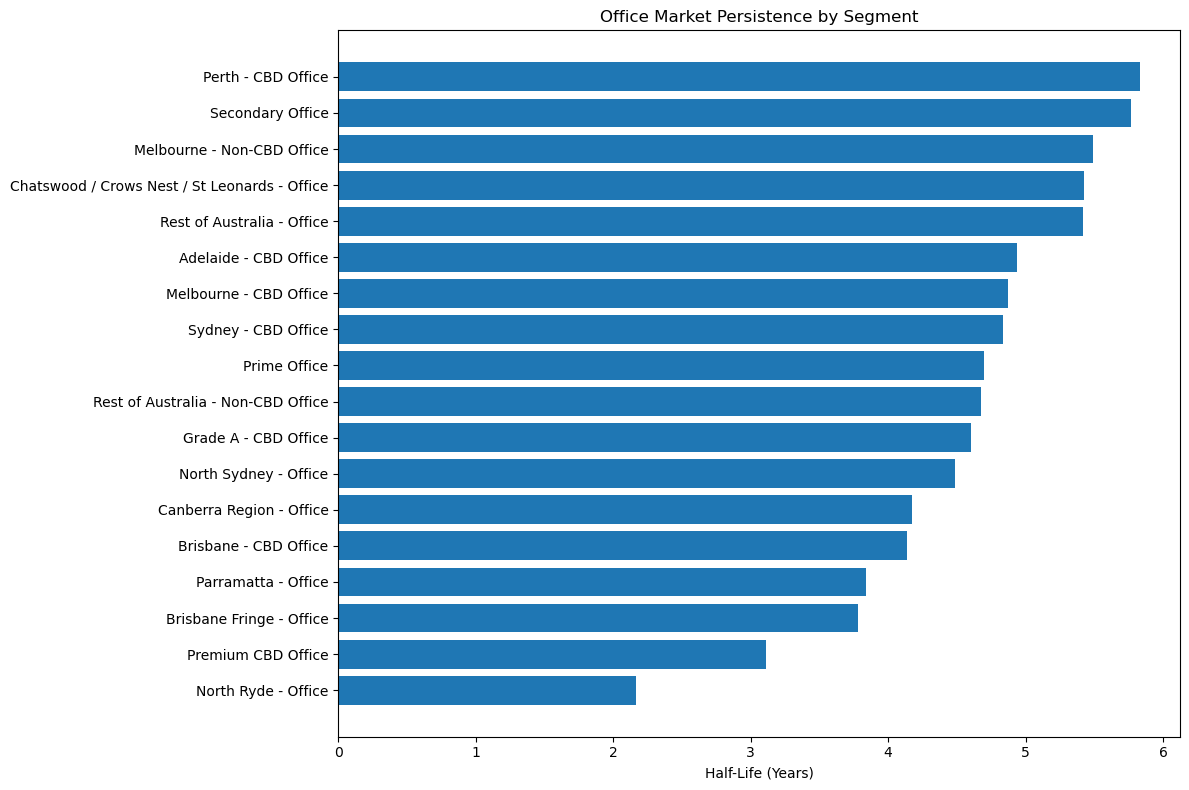

In [149]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

file = "The+Property+Council-MSCI+Australian+All+Property+Digest+Q12026+Old+Format.xlsx"

# --------------------------------------------------
# Persistence function
# --------------------------------------------------

def persistence(series):

    series = pd.to_numeric(
        series,
        errors="coerce"
    ).dropna()

    if len(series) < 20:
        return None

    temp = pd.DataFrame({
        "y": series
    })

    temp["lag"] = temp["y"].shift(1)

    temp = temp.dropna()

    X = sm.add_constant(temp["lag"])

    model = sm.OLS(
        temp["y"],
        X
    ).fit()

    beta = model.params["lag"]

    if 0 < beta < 1:

        half_life_qtrs = (
            np.log(0.5)
            /
            np.log(beta)
        )

        half_life_years = (
            half_life_qtrs
            / 4
        )

    else:

        half_life_years = np.nan

    return {
        "AR1": beta,
        "HalfLifeYears": half_life_years,
        "R2": model.rsquared
    }

# --------------------------------------------------
# OFFICE LOCATIONS SHEET
# --------------------------------------------------

office = pd.read_excel(
    file,
    sheet_name="Office Locations",
    header=None
)

results = []

# --------------------------------------------------
# CBD OFFICE MARKETS
# Row 14 labels
# Cols 3-9
# --------------------------------------------------

for col in range(3,10):

    market = str(office.iloc[14,col])

    r = persistence(
        office.iloc[19:,col]
    )

    if r:

        results.append({
            "SegmentType":"CBD Office",
            "Market":market,
            **r
        })

# --------------------------------------------------
# NON-CBD OFFICE MARKETS
# Row 14 labels
# Cols 28-34
# --------------------------------------------------

for col in range(28,35):

    market = str(office.iloc[14,col])

    r = persistence(
        office.iloc[19:,col]
    )

    if r:

        results.append({
            "SegmentType":"Non-CBD Office",
            "Market":market,
            **r
        })

# --------------------------------------------------
# QUALITY SHEET
# --------------------------------------------------

quality = pd.read_excel(
    file,
    sheet_name="Quality Type",
    header=None
)

# Prime / Secondary

for col in [3,4]:

    market = str(quality.iloc[14,col])

    r = persistence(
        quality.iloc[19:,col]
    )

    if r:

        results.append({
            "SegmentType":"Office Quality",
            "Market":market,
            **r
        })

# Premium CBD / Grade A CBD

for col in [13,14]:

    market = str(quality.iloc[14,col])

    r = persistence(
        quality.iloc[19:,col]
    )

    if r:

        results.append({
            "SegmentType":"CBD Quality",
            "Market":market,
            **r
        })

# --------------------------------------------------
# RESULTS TABLE
# --------------------------------------------------

results = pd.DataFrame(results)

results = results.sort_values(
    "HalfLifeYears",
    ascending=False
)

pd.set_option(
    "display.max_rows",
    None
)

print(results)

# --------------------------------------------------
# TOP PERSISTENCE RANKING
# --------------------------------------------------

print("\n")
print("="*80)
print("TOP PERSISTENCE MARKETS")
print("="*80)

print(
    results[
        [
            "Market",
            "HalfLifeYears",
            "AR1",
            "R2"
        ]
    ]
)

# --------------------------------------------------
# CHART
# --------------------------------------------------

plt.figure(figsize=(12,8))

plot_df = results.sort_values(
    "HalfLifeYears"
)

plt.barh(
    plot_df["Market"],
    plot_df["HalfLifeYears"]
)

plt.xlabel("Half-Life (Years)")
plt.ylabel("")
plt.title("Office Market Persistence by Segment")

plt.tight_layout()

plt.show()

In [150]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from datetime import datetime

# =====================================================
# CREATE OUTPUT FOLDER
# =====================================================

today = datetime.today().strftime("%Y%m%d")

output_dir = f"Persistence_Study_{today}"

os.makedirs(output_dir, exist_ok=True)

# =====================================================
# ASSUMES YOU ALREADY HAVE:
#
# office_results
# cbd_results
# quality_results
# combined_results
#
# AS DATAFRAMES
# =====================================================

# Example:
# combined_results = results

combined_results = results.copy()

# =====================================================
# SAVE MASTER RESULTS
# =====================================================

combined_results.to_excel(
    os.path.join(
        output_dir,
        "Persistence_Master.xlsx"
    ),
    index=False
)

combined_results.to_csv(
    os.path.join(
        output_dir,
        "Persistence_Master.csv"
    ),
    index=False
)

# =====================================================
# TOP PERSISTENCE
# =====================================================

top_persistence = (
    combined_results
    .sort_values(
        "HalfLifeYears",
        ascending=False
    )
)

top_persistence.to_excel(
    os.path.join(
        output_dir,
        "Persistence_Ranked.xlsx"
    ),
    index=False
)

# =====================================================
# SUMMARY STATISTICS
# =====================================================

summary = (
    combined_results
    .groupby("SegmentType")
    .agg(
        Mean_HalfLife=("HalfLifeYears","mean"),
        Min_HalfLife=("HalfLifeYears","min"),
        Max_HalfLife=("HalfLifeYears","max"),
        Mean_AR1=("AR1","mean")
    )
)

summary.to_excel(
    os.path.join(
        output_dir,
        "Persistence_Summary.xlsx"
    )
)

# =====================================================
# FULL HIERARCHY CHART
# =====================================================

plot_df = (
    combined_results
    .sort_values("HalfLifeYears")
)

plt.figure(figsize=(12,8))

plt.barh(
    plot_df["Market"],
    plot_df["HalfLifeYears"]
)

plt.xlabel("Half-Life (Years)")
plt.title(
    "Persistence Hierarchy Across Office Markets"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        output_dir,
        "Persistence_Hierarchy.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# =====================================================
# QUALITY HIERARCHY
# =====================================================

quality_plot = combined_results[
    combined_results["SegmentType"].isin(
        [
            "Office Quality",
            "CBD Quality"
        ]
    )
]

plt.figure(figsize=(10,6))

plt.bar(
    quality_plot["Market"],
    quality_plot["HalfLifeYears"]
)

plt.ylabel("Half-Life (Years)")
plt.title(
    "Persistence by Office Quality"
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    os.path.join(
        output_dir,
        "Quality_Persistence.png"
    ),
    dpi=300
)

plt.close()

# =====================================================
# LOCATION HIERARCHY
# =====================================================

location_plot = combined_results[
    combined_results["SegmentType"].isin(
        [
            "CBD Office",
            "Non-CBD Office"
        ]
    )
]

plt.figure(figsize=(12,6))

plt.bar(
    location_plot["Market"],
    location_plot["HalfLifeYears"]
)

plt.ylabel("Half-Life (Years)")
plt.title(
    "Persistence by Office Location"
)

plt.xticks(
    rotation=90
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        output_dir,
        "Location_Persistence.png"
    ),
    dpi=300
)

plt.close()

# =====================================================
# EXECUTIVE SUMMARY
# =====================================================

with open(
    os.path.join(
        output_dir,
        "Executive_Summary.txt"
    ),
    "w"
) as f:

    f.write(
"""
PERSISTENCE HETEROGENEITY ANALYSIS

Key Findings

1. Sector-level persistence masks substantial submarket variation.

2. Estimated half-lives range from approximately:

   - 2.17 years (North Ryde Office)
   - 5.83 years (Perth CBD Office)

3. Office quality exhibits a clear persistence hierarchy:

   Secondary Office : 5.76 years
   Prime Office     : 4.70 years
   Grade A CBD      : 4.60 years
   Premium CBD      : 3.11 years

4. Premium markets appear to adjust substantially
   faster than secondary markets.

5. Results are consistent with differences in
   information quality, liquidity, valuation
   efficiency and market depth.

"""
    )

print(f"Files saved to: {output_dir}")

Files saved to: Persistence_Study_20260821


In [151]:
import os

print(os.path.abspath("Persistence_Study_20260821"))

C:\Users\DanielKrivan\Persistence_Study_20260821


In [152]:
import os

print("Current Working Directory:")
print(os.getcwd())

Current Working Directory:
C:\Users\DanielKrivan


In [153]:
import os

folder = "Persistence_Study_20260821"

print("Exists:", os.path.exists(folder))

if os.path.exists(folder):
    print(os.path.abspath(folder))

Exists: True
C:\Users\DanielKrivan\Persistence_Study_20260821


In [154]:
import os

for root, dirs, files in os.walk(os.getcwd()):
    for f in files:
        if "Persistence" in f:
            print(os.path.join(root, f))


C:\Users\DanielKrivan\Final_Persistence_Results.xlsx
C:\Users\DanielKrivan\H3_Sector_Persistence_Coefficients.png
C:\Users\DanielKrivan\H4_Persistence_Robustness.png
C:\Users\DanielKrivan\Persistence_Analysis.xlsx
C:\Users\DanielKrivan\Persistence_Confidence_Intervals.png
C:\Users\DanielKrivan\Persistence_Regression.txt
C:\Users\DanielKrivan\Rolling_Persistence_Analysis.xlsx
C:\Users\DanielKrivan\AppData\Roaming\Microsoft\Windows\Recent\Persistence_Heterogeneity_Investigation_Report.docx.lnk
C:\Users\DanielKrivan\AppData\Roaming\Microsoft\Windows\Recent\Rolling_Persistence_Analysis.lnk
C:\Users\DanielKrivan\OneDrive - Aware Real Estate\Desktop\Research Report\Hypothesis 3\Figure_H3_Persistence_Scatterplot.png
C:\Users\DanielKrivan\OneDrive - Aware Real Estate\Desktop\Research Report\Persistance Focus\Persistence_Heterogeneity_Investigation_Report.docx.pdf
C:\Users\DanielKrivan\OneDrive - Aware Real Estate\Desktop\Research Report\Python Data\Persistence_Analysis.xlsx
C:\Users\DanielKriv

In [155]:
import os

folder = "Persistence_Study_20260821"

os.makedirs(folder, exist_ok=True)

results.to_excel(
    os.path.join(folder, "Office_Persistence_Hierarchy.xlsx"),
    index=False
)

print("Saved:", os.path.abspath(folder))

Saved: C:\Users\DanielKrivan\Persistence_Study_20260821


In [156]:
# Save the key results directly beside your notebook

results.to_excel(
    "Office_Persistence_Hierarchy.xlsx",
    index=False
)

results.to_csv(
    "Office_Persistence_Hierarchy.csv",
    index=False
)

print("Saved successfully")

Saved successfully


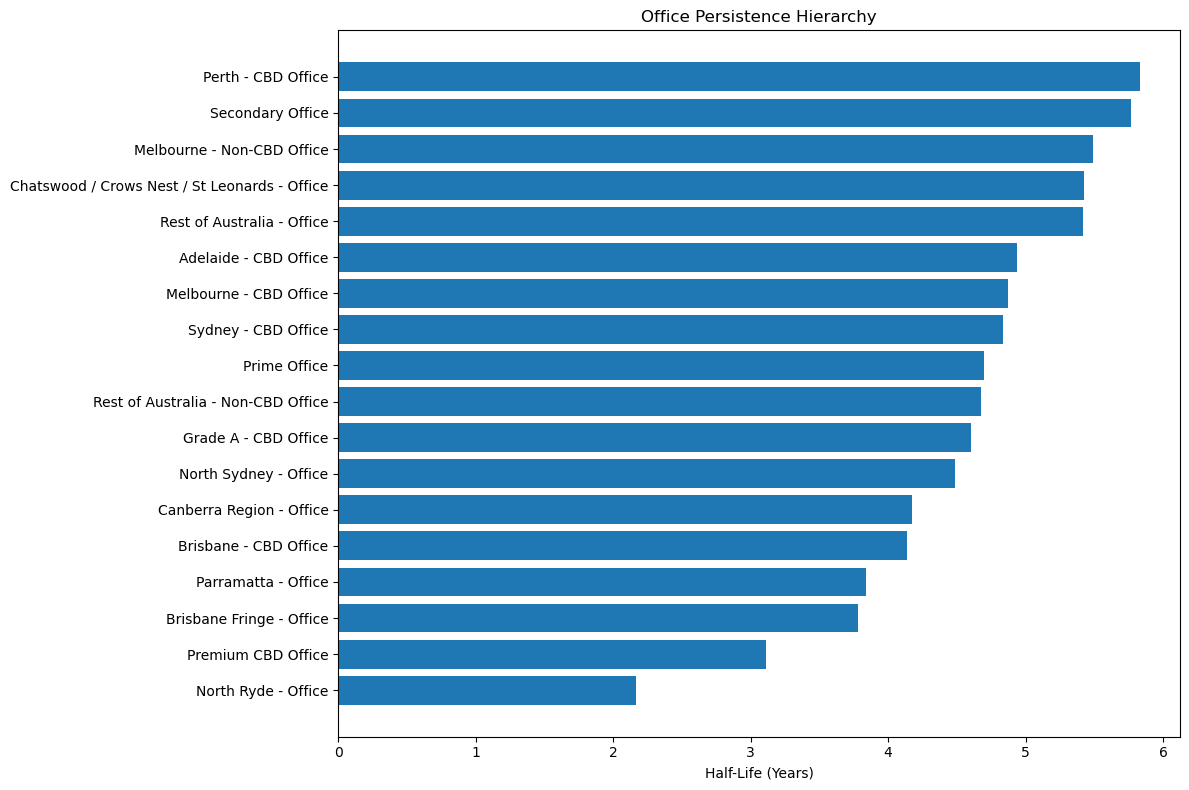

In [157]:
import matplotlib.pyplot as plt

plot_df = results.sort_values("HalfLifeYears")

plt.figure(figsize=(12,8))

plt.barh(
    plot_df["Market"],
    plot_df["HalfLifeYears"]
)

plt.xlabel("Half-Life (Years)")
plt.title("Office Persistence Hierarchy")

plt.tight_layout()

plt.savefig(
    "Office_Persistence_Hierarchy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [158]:
import os

for f in os.listdir():
    if "Persistence" in f:
        print(f)

Final_Persistence_Results.xlsx
H3_Sector_Persistence_Coefficients.png
H4_Persistence_Robustness.png
Office_Persistence_Hierarchy.csv
Office_Persistence_Hierarchy.png
Office_Persistence_Hierarchy.xlsx
Persistence_Analysis.xlsx
Persistence_Confidence_Intervals.png
Persistence_Regression.txt
Persistence_Study_20260821
Rolling_Persistence_Analysis.xlsx


In [159]:
summary = results[
    ["Market","HalfLifeYears","AR1","R2"]
].sort_values(
    "HalfLifeYears",
    ascending=False
)

summary.to_excel(
    "Office_Persistence_Summary.xlsx",
    index=False
)